# Topology — part 1 of 1

This notebook was automatically split from a larger notebook.

### Topological data analysis

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
<div style="width: 50%; margin-right: 20px;">
<h2>Introduction</h2>
<p>This analysis applies custom topological data analysis to 3D EEG delay-embedding trajectories. Instead of relying on GUDHI or another persistent homology library, the pipeline constructs a sparse Vietoris-Rips complex manually and performs persistent homology using binary column reduction over \(\mathbb{Z}_2\). The goal is to quantify loop-like, component-like, and higher-order geometric structure in each EEG channel after projection into two dimensions.</p>
<h2>Input Data</h2>
<p>Each EEG channel is loaded as a 3D embedded trajectory \(X \in \mathbb{R}^{N \times 3}\), where \(N\) is the number of embedded time points. Each row represents a point in reconstructed state space, and each channel is analyzed independently.</p>
<h2>Standardization</h2>
<p>The 3D trajectory is standardized column-wise so each coordinate contributes comparably to projection and topology.</p>
<p><strong>Formula:</strong></p>
\[
Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j + \epsilon}
\]
<p>where \(X_{ij}\) is the original embedded value, \(\mu_j\) is the mean of coordinate \(j\), \(\sigma_j\) is the standard deviation of coordinate \(j\), and \(\epsilon\) prevents division by zero.</p>
<h2>Projection</h2>
<p>The standardized 3D trajectory is projected to a 2D point cloud. If a previously saved UMAP embedding exists, it is reused. If no saved embedding exists, the code computes a new UMAP projection. If UMAP is unavailable, the code can fall back to PCA.</p>
<p><strong>Projection Form:</strong></p>
\[
Y = f(X), \quad Y \in \mathbb{R}^{N \times 2}
\]
<p>where \(f\) is either UMAP or PCA, and \(Y\) is the projected 2D point cloud used for topology.</p>
<h2>Topology Subsampling</h2>
<p>Persistent homology is expensive for large point clouds, so the projected trajectory is randomly subsampled before constructing the complex. This keeps the analysis computationally feasible while preserving a representative geometric sample.</p>
<p><strong>Subsample:</strong></p>
\[
Y_{\text{sub}} = \{y_i : i \in S\}, \quad |S| \leq N_{\max}
\]
<p>where \(S\) is a random subset of point indices and \(N_{\max}\) is the maximum number of topology points.</p>
<h2>Sparse Vietoris-Rips Graph</h2>
<p>The code constructs a sparse Rips graph using local nearest neighbors rather than all pairwise distances. This greatly reduces computational cost.</p>
<p><strong>Edge Rule:</strong></p>
\[
(i,j) \in E \quad \text{if} \quad d(y_i,y_j) \leq \epsilon \quad \text{and} \quad y_j \in kNN(y_i)
\]
<p>where \(d(y_i,y_j)\) is Euclidean distance, \(\epsilon\) is the maximum edge length, and \(kNN(y_i)\) is the set of nearest neighbors of point \(y_i\).</p>
<h2>Triangle Construction</h2>
<p>A triangle is added when all three pairwise edges between three points exist. The triangle enters the filtration at the largest edge length among its boundary edges.</p>
<p><strong>Triangle Rule:</strong></p>
\[
[i,j,k] \in K \quad \text{if} \quad [i,j], [i,k], [j,k] \in E
\]
<p><strong>Triangle Filtration:</strong></p>
\[
f([i,j,k]) = \max(d_{ij}, d_{ik}, d_{jk})
\]
<p>This lets loops die when they become filled by triangles.</p>
<h2>Boundary Operators</h2>
<p>The custom persistent homology implementation works over \(\mathbb{Z}_2\), meaning all addition is modulo 2. This allows boundaries to be represented as sets, where repeated terms cancel.</p>
<p><strong>Boundary of an Edge:</strong></p>
\[
\partial[i,j] = [i] + [j]
\]
<p><strong>Boundary of a Triangle:</strong></p>
\[
\partial[i,j,k] = [i,j] + [i,k] + [j,k]
\]
<p>Over \(\mathbb{Z}_2\), adding the same simplex twice cancels it.</p>
<h2>Column Reduction</h2>
<p>Persistent homology is computed by reducing the boundary matrix column by column. A simplex with an empty reduced boundary creates a topological feature. A simplex with a nonempty reduced boundary destroys the feature born at the lowest boundary index.</p>
<p><strong>Reduction Rule:</strong></p>
\[
R_j \leftarrow R_j + R_k \pmod{2}
\]
<p>where \(R_j\) is the current boundary column and \(R_k\) is a previous column with the same lowest nonzero row.</p>
</div>
<div style="width: 50%; margin-left: 20px;">
<h2>Persistence Intervals</h2>
<p>Each topological feature is represented as an interval \([b_i,d_i]\), where \(b_i\) is the birth scale and \(d_i\) is the death scale. Long intervals represent more persistent and potentially more meaningful structures.</p>
<p><strong>Lifetime:</strong></p>
\[
\ell_i = d_i - b_i
\]
<p>where \(\ell_i\) is the persistence lifetime of feature \(i\).</p>
<h2>Betti Numbers</h2>
<p>Betti numbers count surviving topological structures. \(\beta_0\) counts connected components, \(\beta_1\) counts loop-like structures, and \(\beta_2\) is treated as a conservative diagnostic because tetrahedra are not included in this implementation.</p>
<p><strong>Formula:</strong></p>
\[
\beta_k = \text{rank}(H_k)
\]
<p>where \(H_k\) is the \(k\)-th homology group.</p>
<h2>H0, H1, and H2 Interpretation</h2>
<p>\(H_0\) describes how separate connected components merge as the distance scale increases. \(H_1\) captures loop-like or recurrent structures in the projected trajectory. \(H_2\) is included as a diagnostic of higher-order void-like structure, but because the complex includes vertices, edges, and triangles only, \(H_2\) should be interpreted cautiously.</p>
<h2>Persistent Entropy</h2>
<p>Persistent entropy measures how evenly persistence lifetime is distributed across features. A low entropy means a few features dominate, while a high entropy means persistence is spread across many features.</p>
<p><strong>Formula:</strong></p>
\[
S = -\frac{1}{\log(n)} \sum_{i=1}^{n} p_i \log(p_i), \quad p_i = \frac{\ell_i}{\sum_j \ell_j}
\]
<p>where \(p_i\) is the normalized lifetime of feature \(i\).</p>
<h2>Topological Complexity Score</h2>
<p>The code summarizes each channel using a weighted complexity score based on loop persistence, higher-dimensional diagnostic persistence, and finite feature counts.</p>
<p><strong>Formula:</strong></p>
\[
C_{\text{topo}} = P_{H1} + 0.50P_{H2} + 0.10N_{H1} + 0.05N_{H2}
\]
<p>where \(P_{H1}\) and \(P_{H2}\) are total persistence values, and \(N_{H1}\) and \(N_{H2}\) are finite feature counts.</p>
<h2>Projection Geometry Metrics</h2>
<p>The code computes additional geometric descriptors of the projected point cloud, including bounding-box area, density, nearest-neighbor distance, and covariance anisotropy. These help distinguish true topology from projection artifacts or sampling density effects.</p>
<p><strong>Anisotropy:</strong></p>
\[
A = \frac{\lambda_{\max}}{\lambda_{\min}}
\]
<p>where \(\lambda_{\max}\) and \(\lambda_{\min}\) are eigenvalues of the 2D projection covariance matrix.</p>
<h2>Classifier Diagnostic</h2>
<p>A random forest classifier is trained on synthetic alternating temporal segment labels. This is not a clinical or biological label model. It is a diagnostic test of whether the projected trajectory separates temporal structure strongly enough for a nonlinear classifier to exploit.</p>
<h2>Quality Control</h2>
<p>The code records the number of vertices, edges, triangles, and simplices in the sparse Rips complex. It also records whether the triangle cap was reached. These diagnostics identify channels where topology may be limited by computational constraints.</p>
<h2>Expert Plots</h2>
<p>The notebook generates black-background cyan plots for topological complexity rankings, H1 persistence rankings, Betti heatmaps, runtime quality control, complexity versus sparse Rips size, projection geometry versus topology, classifier accuracy versus topology, metric correlations, H1 lifetime overlays, persistence diagram galleries, projection galleries, persistent feature counts, and triangle-cap quality control.</p>
<h2>Results and Conclusion</h2>
<p>This custom-math topology pipeline provides a self-contained way to analyze nonlinear EEG channel geometry without GUDHI. Channels with high \(H_1\) persistence and high topological complexity may contain stronger recurrent or loop-like state-space structure. Runtime and triangle-cap diagnostics help determine whether the sparse complex was sufficiently expressive. Together, the persistence intervals, Betti numbers, geometry metrics, classifier diagnostic, and expert plots provide a compact framework for comparing nonlinear EEG dynamics across channels.</p>
</div>
</div>

Running custom-math topology from 3D projection pipeline
FAST_OPTION: fast
GUDHI used: False
UMAP available: False
PCA fallback available: True
cKDTree available: True
Notebook plot display: True
Save plots to disk: True
Optional per-channel plots enabled: False
Persistence cache reuse: True
Channels to process: 32

[1/32] Processing Fp1 | 3D shape=(106936, 3)
Custom Betti numbers for Fp1: (2, 28, 4525)
H1 total persistence for Fp1: 18.8959
Topological complexity score for Fp1: 31.2959
Edges / triangles / simplices: 3693 / 7542 / 11885
Triangle cap hit: False
Model accuracy for Fp1: 0.5640
Persistence cache reused: False
Persistence time for Fp1: 0.126s
Channel elapsed time for Fp1: 0.412s

[2/32] Processing Fpz | 3D shape=(106936, 3)
Custom Betti numbers for Fpz: (2, 32, 4870)
H1 total persistence for Fpz: 18.0217
Topological complexity score for Fpz: 29.6217
Edges / triangles / simplices: 3717 / 7907 / 12274
Triangle cap hit: False
Model accuracy for Fpz: 0.5497
Persistence cache reu

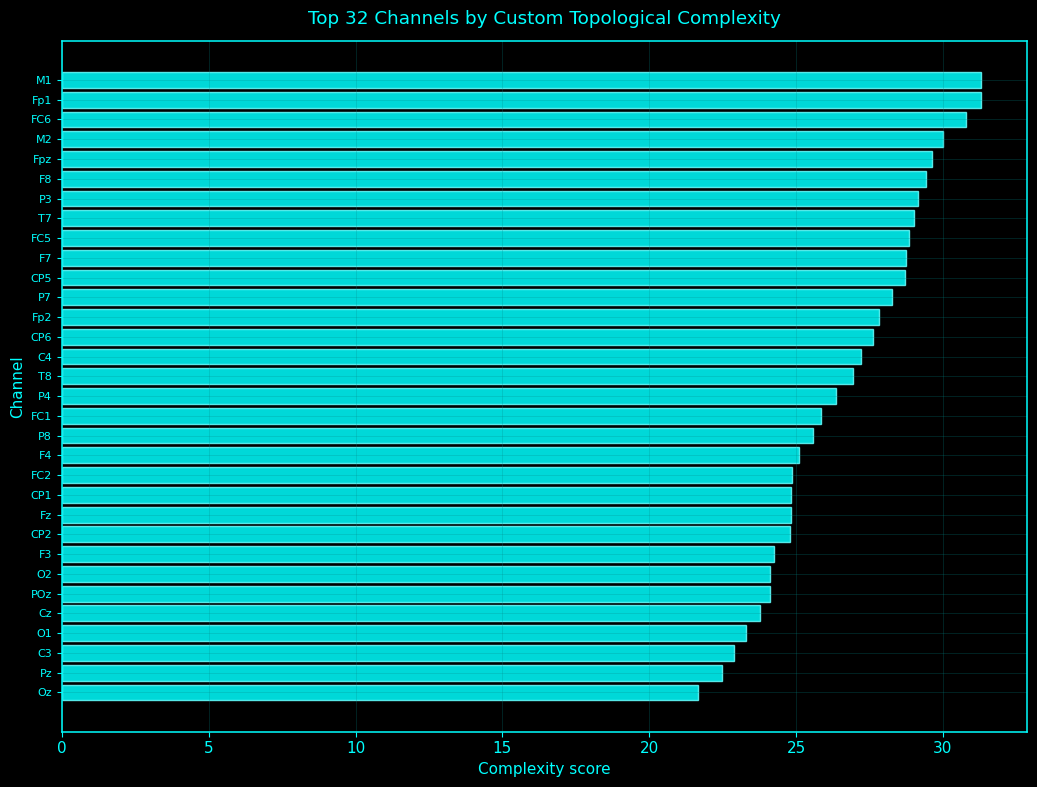

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/01_custom_topology_complexity_ranking_black_cyan.png


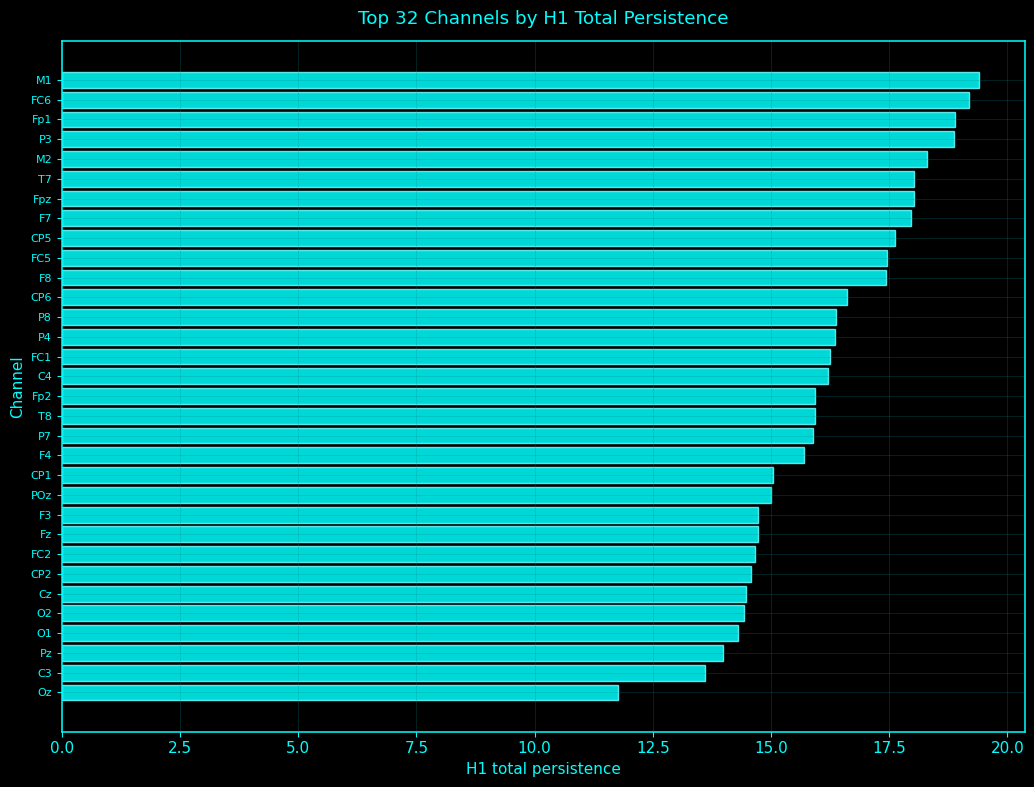

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/02_h1_total_persistence_ranking_black_cyan.png


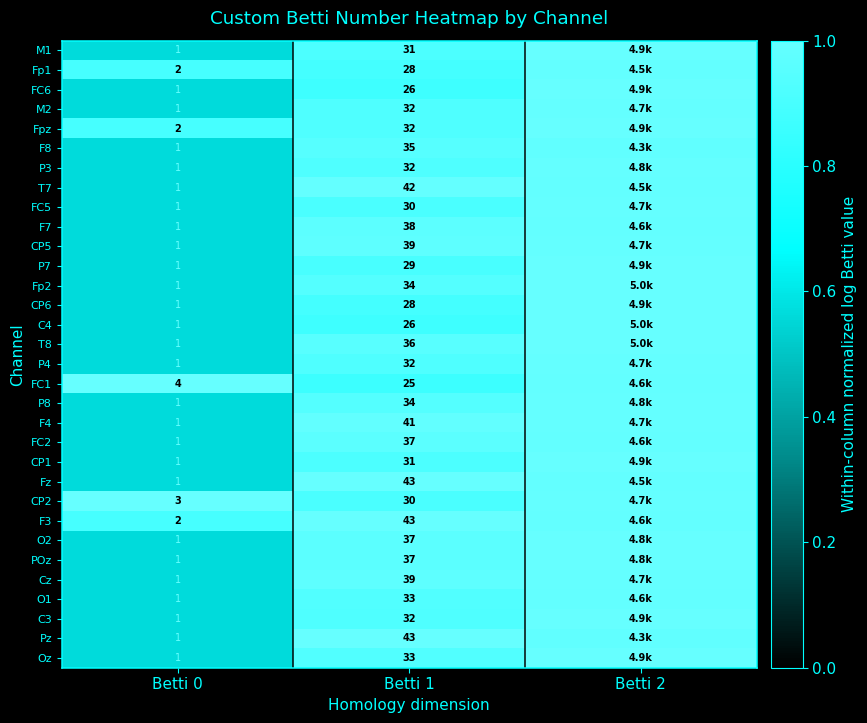

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/03_custom_betti_heatmap_fixed_height_black_cyan.png


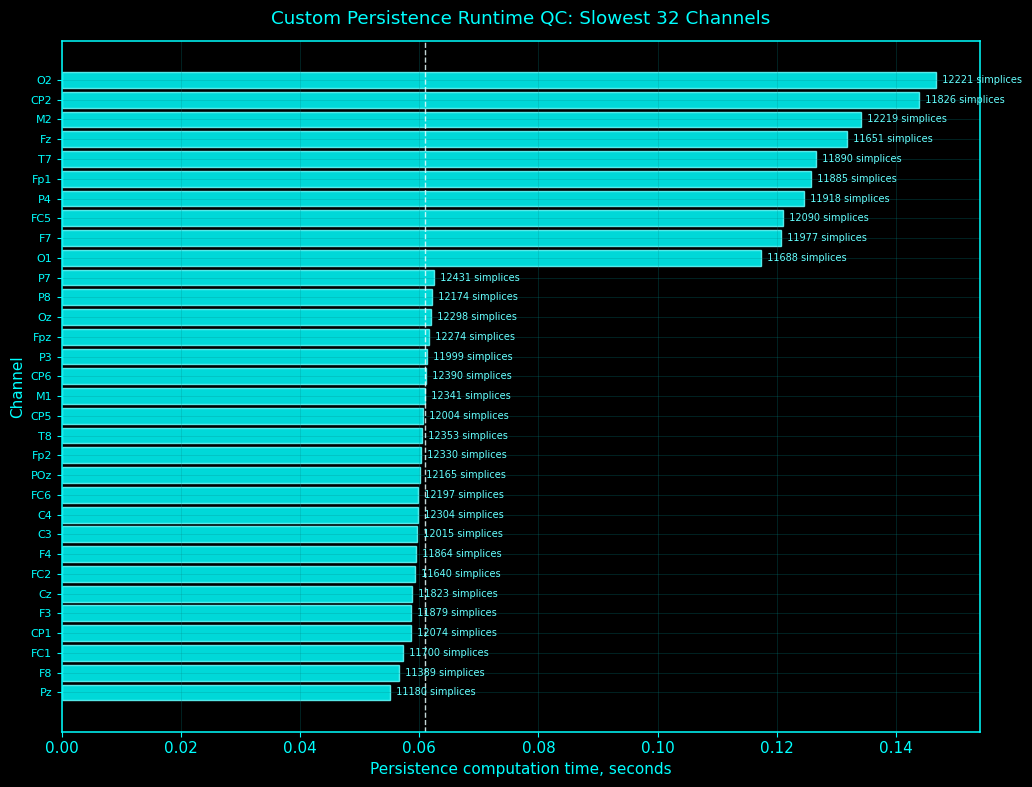

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/04_custom_persistence_runtime_qc_black_cyan.png


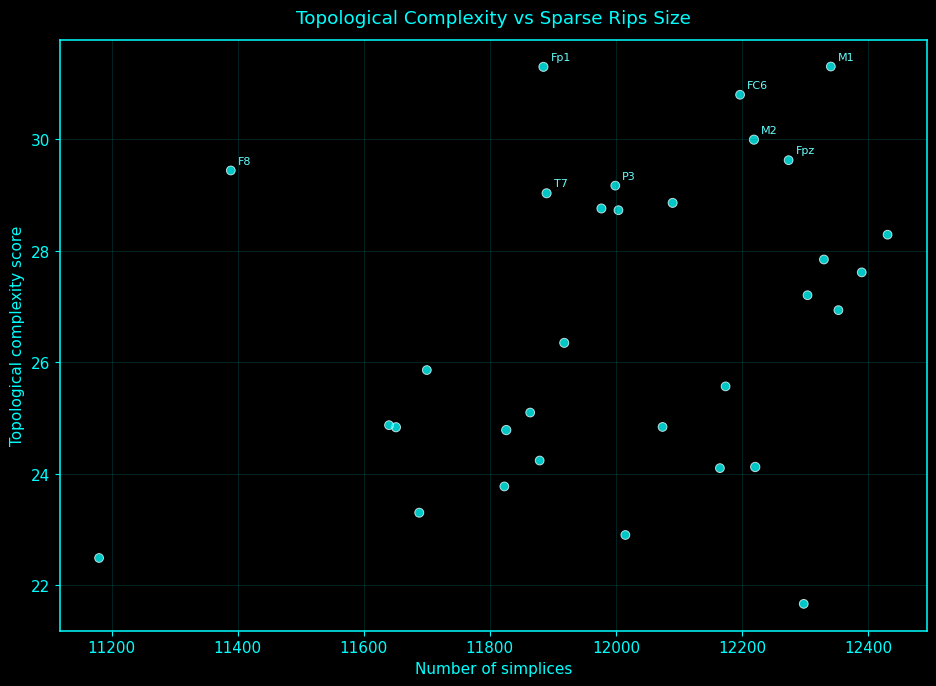

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/05_complexity_vs_sparse_rips_size_black_cyan.png


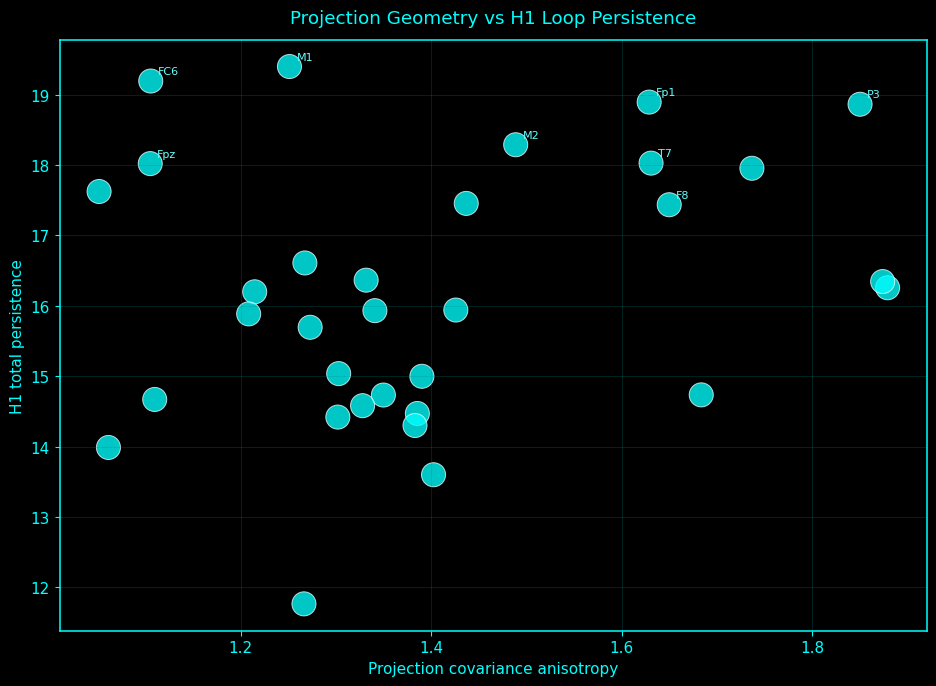

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/06_projection_geometry_vs_h1_topology_black_cyan.png


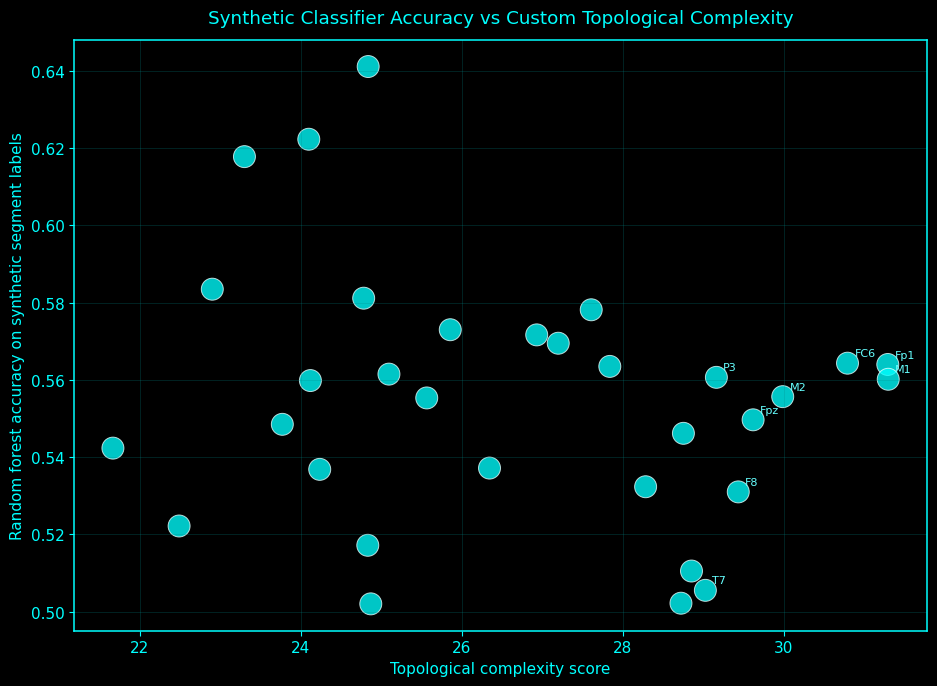

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/07_rf_accuracy_vs_topology_black_cyan.png


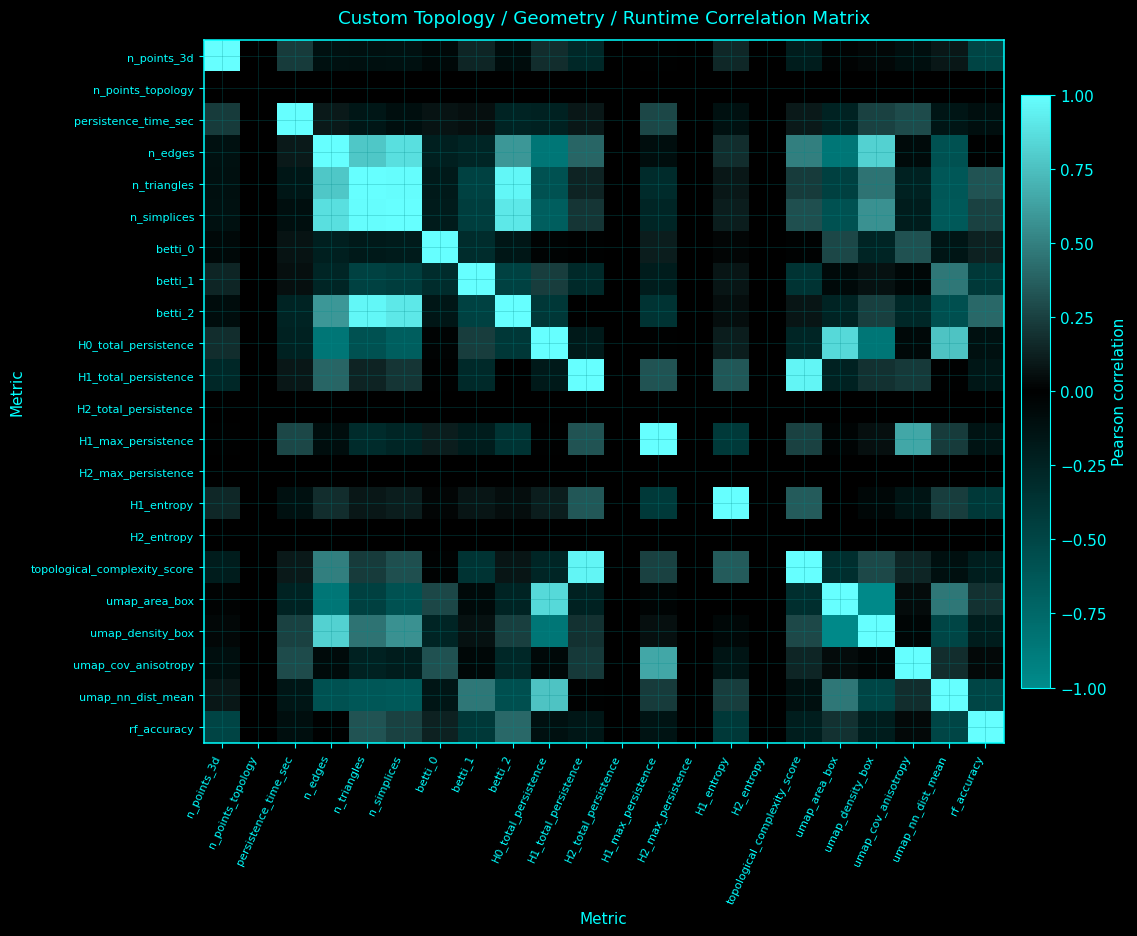

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/08_metric_correlation_matrix_black_cyan.png


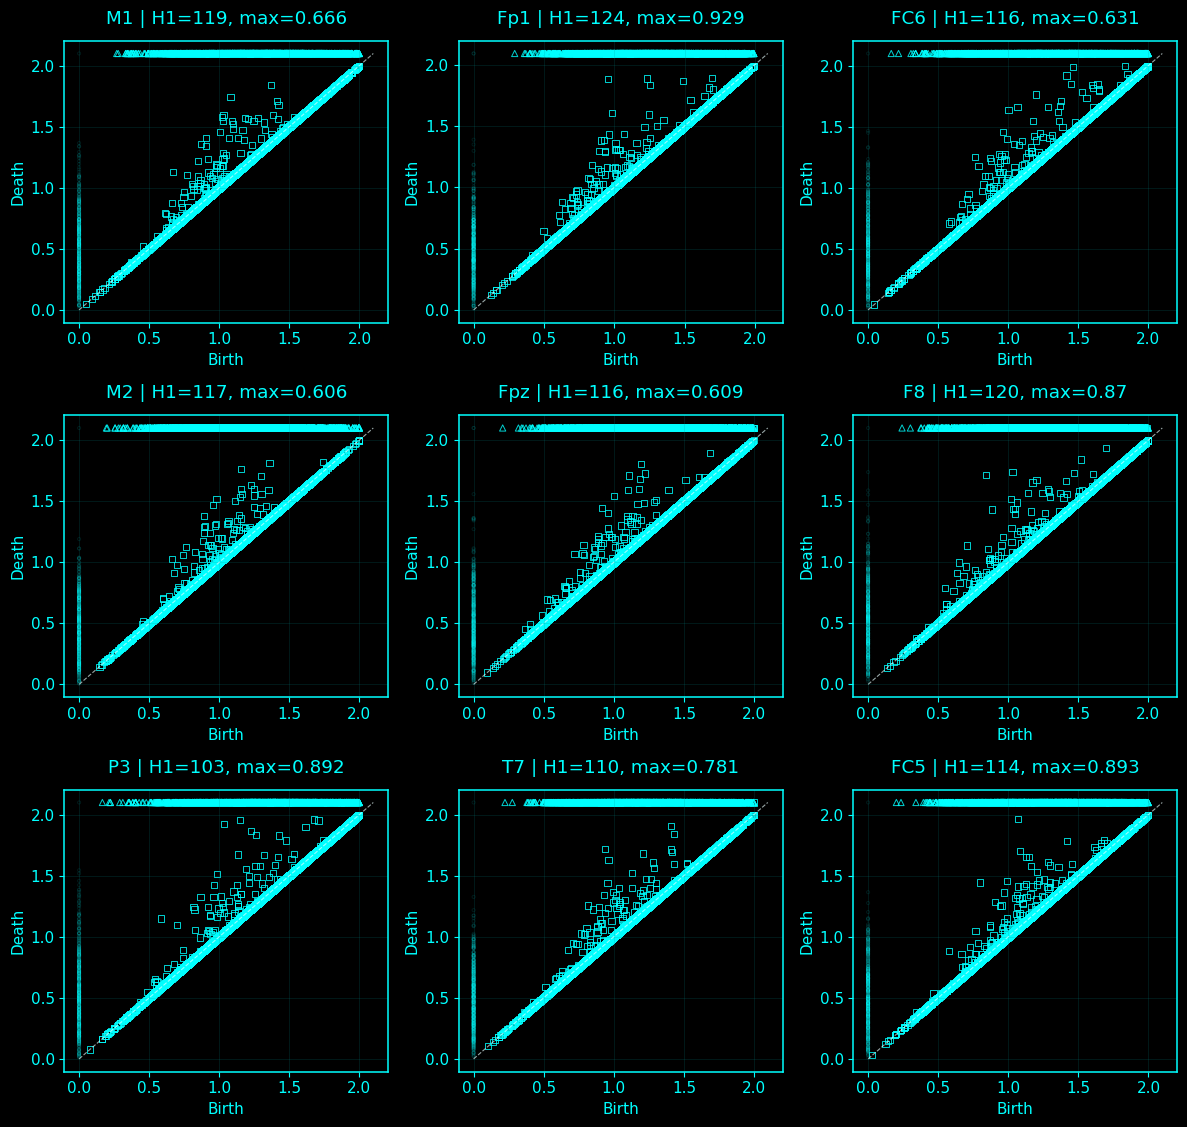

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/10_persistence_diagram_gallery_top_channels_black_cyan.png


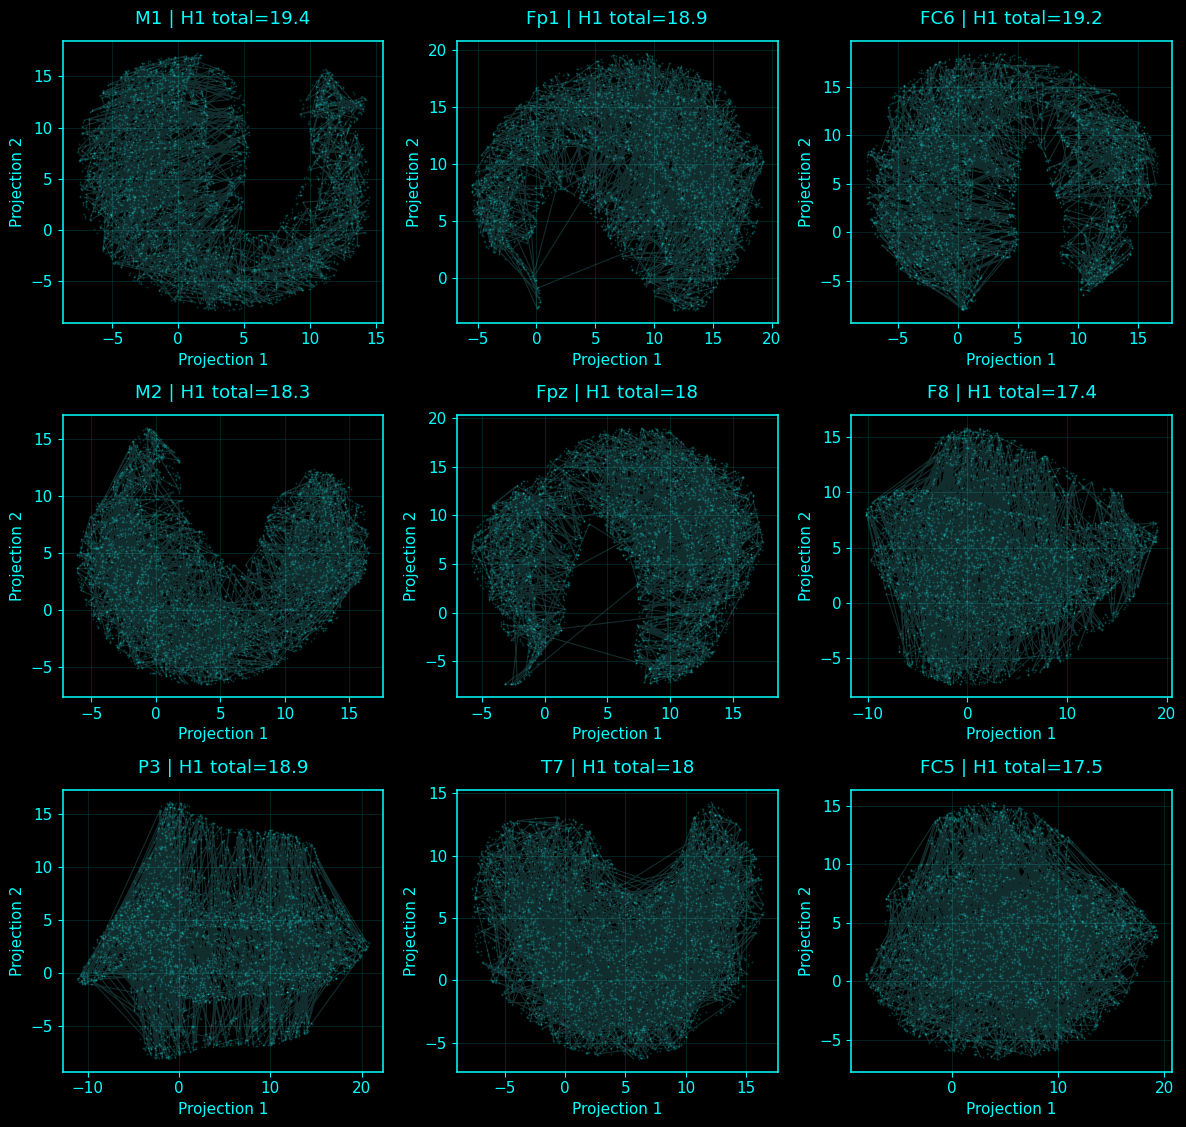

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/11_projection_gallery_top_channels_black_cyan.png


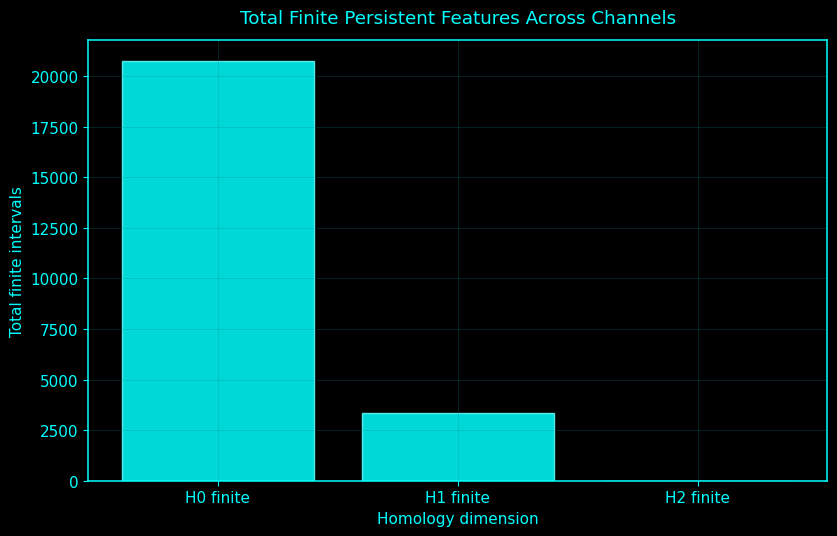

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/12_total_persistent_feature_counts_black_cyan.png


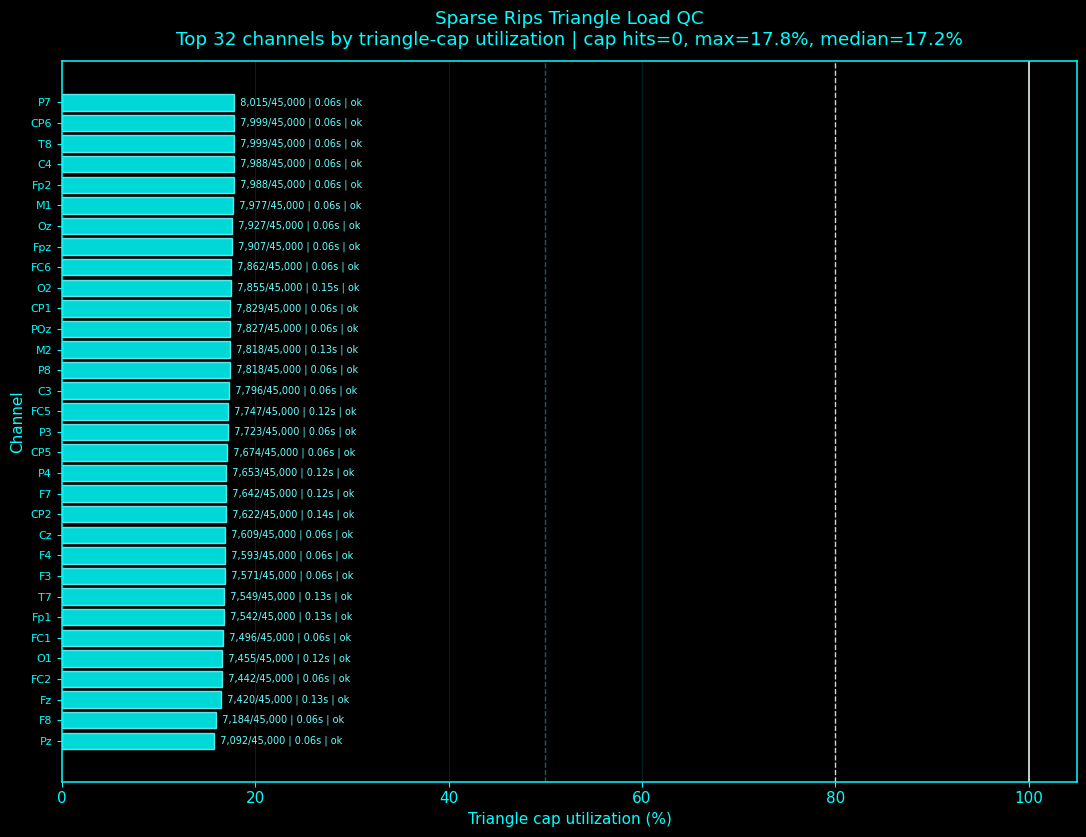

Saved plot: /home/a/projects/Complete-Neural-Signal-Analysis/plots/topology_from_3d_umap_custom_math_fast/expert_summary_plots/13_triangle_cap_qc_black_cyan.png

CUSTOM-MATH TOPOLOGY / PROJECTION SUMMARY
Successful channels: 32
FAST_OPTION: fast
Projection: PCA fallback
Persistence points per channel: 650
Sparse Rips k: 10
Rips max edge length: 2.0
Max triangles: 45000

Top 10 by custom topological complexity score:
channel  betti_0  betti_1  betti_2  H1_n_finite  H1_total_persistence  H1_max_persistence  topological_complexity_score  n_edges  n_triangles  persistence_time_sec  persistence_cache_reused  rf_accuracy
     M1        1       31     4943          119             19.401541            0.666126                     31.301541     3714         7977              0.060922                     False     0.560167
    Fp1        2       28     4525          124             18.895880            0.929328                     31.295880     3693         7542              0.125693           

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier

try:
    import umap.umap_ as umap
    _HAVE_UMAP = True
except Exception:
    umap = None
    _HAVE_UMAP = False

try:
    from sklearn.decomposition import PCA
    _HAVE_PCA = True
except Exception:
    PCA = None
    _HAVE_PCA = False

try:
    from scipy.spatial import cKDTree as KDTree
    _HAVE_KDTREE = True
except Exception:
    KDTree = None
    _HAVE_KDTREE = False

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False

base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
embedding_3d_dir = os.path.join(base_dir, "embedding_data", "3dembedding_data")
reuse_umap_dir = os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d")
topology_dir = os.path.join(base_dir, "topology_from_3d_umap_custom_math_fast")
umap_cache_dir = os.path.join(topology_dir, "umap_embeddings")
persistence_dir = os.path.join(topology_dir, "custom_persistence_npz")
plot_root_dir = os.path.join(base_dir, "plots", "topology_from_3d_umap_custom_math_fast")
expert_plot_dir = os.path.join(plot_root_dir, "expert_summary_plots")
optional_per_channel_plot_dir = os.path.join(plot_root_dir, "optional_per_channel_plots")

for d in [topology_dir, umap_cache_dir, persistence_dir, plot_root_dir, expert_plot_dir, optional_per_channel_plot_dir]:
    os.makedirs(d, exist_ok=True)

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

FAST_OPTION = "fast"
MAX_CHANNELS = None
REUSE_PERSISTENCE_CACHE = True
RECOMPUTE_PROJECTION = False
RUN_RANDOM_FOREST = True

if FAST_OPTION == "ultra":
    persistence_max_points = 350
    sparse_rips_k = 7
    rips_max_edge_length = 1.75
    max_triangles = 12000
    rf_estimators = 60
    rf_max_points = 12000
    umap_plot_max_points = 2500
    TOP_N_RANKED_PLOTS = 24
    TOP_N_GALLERY = 6
    TOP_N_LIFETIME_OVERLAY = 10
elif FAST_OPTION == "fast":
    persistence_max_points = 650
    sparse_rips_k = 10
    rips_max_edge_length = 2.0
    max_triangles = 45000
    rf_estimators = 90
    rf_max_points = 20000
    umap_plot_max_points = 4000
    TOP_N_RANKED_PLOTS = 32
    TOP_N_GALLERY = 9
    TOP_N_LIFETIME_OVERLAY = 14
elif FAST_OPTION == "balanced":
    persistence_max_points = 900
    sparse_rips_k = 14
    rips_max_edge_length = 2.0
    max_triangles = 120000
    rf_estimators = 120
    rf_max_points = 30000
    umap_plot_max_points = 5000
    TOP_N_RANKED_PLOTS = 32
    TOP_N_GALLERY = 9
    TOP_N_LIFETIME_OVERLAY = 16
elif FAST_OPTION == "full":
    persistence_max_points = 1500
    sparse_rips_k = 18
    rips_max_edge_length = 2.0
    max_triangles = 250000
    rf_estimators = 200
    rf_max_points = None
    umap_plot_max_points = 9000
    TOP_N_RANKED_PLOTS = 32
    TOP_N_GALLERY = 9
    TOP_N_LIFETIME_OVERLAY = 16
else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")

n_components_umap = 2
n_neighbors_umap = 15
min_dist_umap = 0.1
random_state_umap = 42
segment_length = 1000
test_size = 0.30
random_state_split = 42
rf_random_state = 42
SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True
SAVE_OPTIONAL_PER_CHANNEL_PLOTS = False
SHOW_OPTIONAL_PER_CHANNEL_PLOTS_IN_NOTEBOOK = False

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(42)

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(BLACK)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)
    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)
    ax.grid(True, alpha=0.25, color=ACCENT_DIM, linewidth=0.7)

def save_fig(fig, save_path, show_in_notebook=True):
    fig.tight_layout()
    if SAVE_PLOTS_TO_DISK and save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches="tight", facecolor=BLACK)
    if SHOW_PLOTS_IN_NOTEBOOK and show_in_notebook and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    plt.close(fig)

def short_label(x, max_len=24):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"

def standardize_columns(X):
    X = np.asarray(X, dtype=float)
    X = np.where(np.isfinite(X), X, np.nan)
    col_mean = np.nanmean(X, axis=0, keepdims=True)
    inds = np.where(~np.isfinite(X))
    if inds[0].size > 0:
        X[inds] = np.take(col_mean, inds[1])
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def subsample_rows_with_indices(X, max_points=None, rng=None):
    X = np.asarray(X)
    if rng is None:
        rng = np.random.default_rng()
    n = len(X)
    if max_points is None or n <= max_points:
        return X, np.arange(n)
    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx], idx

def make_synthetic_labels(n, segment_length=1000):
    num_segments = int(np.ceil(n / segment_length))
    labels = np.repeat(np.arange(num_segments) % 2, segment_length)[:n]
    return labels.astype(int)

def manual_train_test_split(X, y, test_size=0.3, random_state=42):
    X = np.asarray(X)
    y = np.asarray(y)
    n = len(X)
    if n < 3:
        raise ValueError("Need at least 3 samples for train/test split.")
    rng_local = np.random.default_rng(random_state)
    perm = rng_local.permutation(n)
    n_test = int(np.round(test_size * n))
    n_test = min(max(n_test, 1), n - 1)
    test_idx = perm[:n_test]
    train_idx = perm[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def manual_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(y_true) == 0:
        return np.nan
    return float(np.mean(y_true == y_pred))

def apply_projection(data, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    if _HAVE_UMAP:
        reducer = umap.UMAP(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric="euclidean",
            random_state=random_state,
            transform_seed=random_state,
            low_memory=True,
        )
        return reducer.fit_transform(data), "UMAP"
    if _HAVE_PCA:
        reducer = PCA(n_components=n_components, random_state=random_state)
        return reducer.fit_transform(data), "PCA_fallback"
    raise ImportError("Neither umap-learn nor sklearn PCA is available.")

def load_or_compute_projection(channel_name, X_std):
    reuse_path = os.path.join(reuse_umap_dir, f"umap_embedding_{channel_name}.npy")
    if not RECOMPUTE_PROJECTION and os.path.exists(reuse_path):
        try:
            emb = np.load(reuse_path)
            emb = np.asarray(emb, dtype=float)
            if emb.ndim == 2 and emb.shape[1] == 2 and emb.shape[0] == X_std.shape[0]:
                return emb, reuse_path, 0.0, True, "reuse_previous_umap"
        except Exception:
            pass
    cache_path = os.path.join(umap_cache_dir, f"projection_embedding_{channel_name}.npy")
    if not RECOMPUTE_PROJECTION and os.path.exists(cache_path):
        try:
            emb = np.load(cache_path)
            emb = np.asarray(emb, dtype=float)
            if emb.ndim == 2 and emb.shape[1] == 2 and emb.shape[0] == X_std.shape[0]:
                return emb, cache_path, 0.0, True, "local_projection_cache"
        except Exception:
            pass
    t0 = time.perf_counter()
    emb, projection_method = apply_projection(
        X_std,
        n_components=n_components_umap,
        n_neighbors=n_neighbors_umap,
        min_dist=min_dist_umap,
        random_state=random_state_umap,
    )
    elapsed = time.perf_counter() - t0
    np.save(cache_path, emb)
    return emb, cache_path, elapsed, False, projection_method

def finite_lifetimes(intervals):
    arr = np.asarray(intervals, dtype=float)
    if arr.size == 0:
        return np.array([], dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        return np.array([], dtype=float)
    birth = arr[:, 0]
    death = arr[:, 1]
    mask = np.isfinite(birth) & np.isfinite(death) & (death > birth)
    return death[mask] - birth[mask]

def persistent_entropy(lifetimes):
    lifetimes = np.asarray(lifetimes, dtype=float)
    lifetimes = lifetimes[np.isfinite(lifetimes) & (lifetimes > 0)]
    if lifetimes.size <= 1:
        return 0.0
    p = lifetimes / np.sum(lifetimes)
    return float(-np.sum(p * np.log(p)) / np.log(len(p)))

def interval_stats(intervals):
    life = finite_lifetimes(intervals)
    if life.size == 0:
        return {"n": 0, "total": 0.0, "mean": 0.0, "max": 0.0, "q90": 0.0, "entropy": 0.0}
    return {
        "n": int(life.size),
        "total": float(np.sum(life)),
        "mean": float(np.mean(life)),
        "max": float(np.max(life)),
        "q90": float(np.quantile(life, 0.90)),
        "entropy": persistent_entropy(life),
    }

def compute_umap_geometry_metrics(emb):
    emb = np.asarray(emb, dtype=float)
    if emb.ndim != 2 or emb.shape[1] != 2 or len(emb) < 3:
        return {
            "umap_x_range": np.nan,
            "umap_y_range": np.nan,
            "umap_area_box": np.nan,
            "umap_density_box": np.nan,
            "umap_cov_anisotropy": np.nan,
            "umap_nn_dist_mean": np.nan,
            "umap_nn_dist_median": np.nan,
        }
    x_range = float(np.max(emb[:, 0]) - np.min(emb[:, 0]))
    y_range = float(np.max(emb[:, 1]) - np.min(emb[:, 1]))
    area = float(max(x_range * y_range, 1e-12))
    density = float(len(emb) / area)
    cov = np.cov(emb.T)
    eig = np.linalg.eigvalsh(cov)
    eig = np.sort(np.maximum(eig, 1e-12))
    anisotropy = float(eig[-1] / eig[0])
    if _HAVE_KDTREE:
        tree = KDTree(emb)
        dists, _ = tree.query(emb, k=2)
        nn = dists[:, 1]
    else:
        sample, _ = subsample_rows_with_indices(emb, max_points=min(2500, len(emb)), rng=np.random.default_rng(123))
        dmat = np.sqrt(np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2))
        np.fill_diagonal(dmat, np.inf)
        nn = np.min(dmat, axis=1)
    return {
        "umap_x_range": x_range,
        "umap_y_range": y_range,
        "umap_area_box": area,
        "umap_density_box": density,
        "umap_cov_anisotropy": anisotropy,
        "umap_nn_dist_mean": float(np.mean(nn)),
        "umap_nn_dist_median": float(np.median(nn)),
    }

def pairwise_edges_bruteforce(points, max_edge_length):
    points = np.asarray(points, dtype=float)
    n = len(points)
    edges = {}
    for i in range(n):
        diffs = points[i + 1:] - points[i]
        dists = np.sqrt(np.einsum("ij,ij->i", diffs, diffs))
        js = np.where(dists <= max_edge_length)[0] + i + 1
        for j, d in zip(js, dists[js - i - 1]):
            edges[(i, j)] = float(d)
    return edges

def build_sparse_rips_complex(points, max_edge_length=2.0, k=14, max_triangles=120000):
    points = np.asarray(points, dtype=float)
    n = len(points)
    if n == 0:
        return [], [], False
    edges = {}
    if _HAVE_KDTREE and n > 1:
        tree = KDTree(points)
        qk = min(n, k + 1)
        try:
            dists, idxs = tree.query(points, k=qk, workers=-1)
        except TypeError:
            dists, idxs = tree.query(points, k=qk)
        dists = np.asarray(dists)
        idxs = np.asarray(idxs)
        if dists.ndim == 1:
            dists = dists[:, None]
            idxs = idxs[:, None]
        for i in range(n):
            for dist, j in zip(dists[i], idxs[i]):
                j = int(j)
                if j == i or j < 0 or j >= n:
                    continue
                if not np.isfinite(dist) or dist > max_edge_length:
                    continue
                a, b = sorted((i, j))
                if a != b:
                    old = edges.get((a, b), np.inf)
                    if dist < old:
                        edges[(a, b)] = float(dist)
    else:
        edges = pairwise_edges_bruteforce(points, max_edge_length=max_edge_length)
    edge_items = [(i, j, d) for (i, j), d in edges.items()]
    edge_items.sort(key=lambda x: (x[2], x[0], x[1]))
    adjacency = [set() for _ in range(n)]
    for i, j, d in edge_items:
        adjacency[i].add(j)
        adjacency[j].add(i)
    edge_len = {(i, j): d for i, j, d in edge_items}
    triangles = []
    triangle_cap_hit = False
    for i, j, dij in edge_items:
        if len(triangles) >= max_triangles:
            triangle_cap_hit = True
            break
        common = adjacency[i].intersection(adjacency[j])
        if len(common) == 0:
            continue
        for k3 in common:
            if k3 <= j:
                continue
            e1 = (min(i, j), max(i, j))
            e2 = (min(i, k3), max(i, k3))
            e3 = (min(j, k3), max(j, k3))
            if e1 not in edge_len or e2 not in edge_len or e3 not in edge_len:
                continue
            filt = max(edge_len[e1], edge_len[e2], edge_len[e3])
            if filt <= max_edge_length:
                triangles.append((i, j, k3, float(filt)))
                if len(triangles) >= max_triangles:
                    triangle_cap_hit = True
                    break
    triangles.sort(key=lambda x: (x[3], x[0], x[1], x[2]))
    return edge_items, triangles, triangle_cap_hit

def custom_persistent_homology_z2(points, max_edge_length=2.0, k=14, max_triangles=120000):
    points = np.asarray(points, dtype=float)
    n = len(points)
    edges, triangles, triangle_cap_hit = build_sparse_rips_complex(
        points,
        max_edge_length=max_edge_length,
        k=k,
        max_triangles=max_triangles,
    )
    simplices = []
    for i in range(n):
        simplices.append(((i,), 0, 0.0))
    for i, j, d in edges:
        simplices.append(((i, j), 1, float(d)))
    for i, j, k3, f in triangles:
        simplices.append(((i, j, k3), 2, float(f)))
    simplices.sort(key=lambda s: (s[2], s[1], s[0]))
    simplex_index = {s[0]: idx for idx, s in enumerate(simplices)}
    dims = np.array([s[1] for s in simplices], dtype=int)
    filtrations = np.array([s[2] for s in simplices], dtype=float)
    boundaries = []
    for vertices, dim, filt in simplices:
        if dim == 0:
            boundaries.append(set())
        elif dim == 1:
            i, j = vertices
            boundaries.append({simplex_index[(i,)], simplex_index[(j,)]})
        elif dim == 2:
            i, j, k3 = vertices
            e1 = tuple(sorted((i, j)))
            e2 = tuple(sorted((i, k3)))
            e3 = tuple(sorted((j, k3)))
            boundaries.append({simplex_index[e1], simplex_index[e2], simplex_index[e3]})
        else:
            boundaries.append(set())
    low_to_col = {}
    reduced_nonzero_cols = {}
    paired_birth_to_death = {}
    is_birth_col = np.zeros(len(simplices), dtype=bool)
    for j, boundary in enumerate(boundaries):
        col = set(boundary)
        while len(col) > 0:
            low = max(col)
            if low in low_to_col:
                col ^= reduced_nonzero_cols[low_to_col[low]]
            else:
                break
        if len(col) == 0:
            is_birth_col[j] = True
        else:
            low = max(col)
            low_to_col[low] = j
            reduced_nonzero_cols[j] = col
            paired_birth_to_death[low] = j
    intervals_by_dim = {0: [], 1: [], 2: []}
    for birth_idx, is_birth in enumerate(is_birth_col):
        if not is_birth:
            continue
        dim = int(dims[birth_idx])
        if dim not in intervals_by_dim:
            intervals_by_dim[dim] = []
        birth = float(filtrations[birth_idx])
        if birth_idx in paired_birth_to_death:
            death_idx = paired_birth_to_death[birth_idx]
            death = float(filtrations[death_idx])
        else:
            death = np.inf
        intervals_by_dim[dim].append([birth, death])
    for dim in intervals_by_dim:
        if len(intervals_by_dim[dim]) == 0:
            intervals_by_dim[dim] = np.empty((0, 2), dtype=float)
        else:
            intervals_by_dim[dim] = np.asarray(intervals_by_dim[dim], dtype=float)
    betti = []
    for dim in [0, 1, 2]:
        arr = intervals_by_dim.get(dim, np.empty((0, 2), dtype=float))
        if arr.size == 0:
            betti.append(0)
        else:
            betti.append(int(np.sum(~np.isfinite(arr[:, 1]))))
    diagnostics = {
        "n_vertices": int(n),
        "n_edges": int(len(edges)),
        "n_triangles": int(len(triangles)),
        "n_simplices": int(len(simplices)),
        "triangle_cap_hit": bool(triangle_cap_hit),
        "sparse_rips_k": int(k),
        "rips_max_edge_length": float(max_edge_length),
        "max_triangles": int(max_triangles),
    }
    return intervals_by_dim, betti, diagnostics

def persistence_cache_path(channel_name):
    cache_tag = f"custom_persistence_{channel_name}_mode-{FAST_OPTION}_n-{persistence_max_points}_k-{sparse_rips_k}_eps-{rips_max_edge_length}_tri-{max_triangles}.npz"
    cache_tag = cache_tag.replace(".", "p")
    return os.path.join(persistence_dir, cache_tag)

def load_persistence_cache(path):
    if not REUSE_PERSISTENCE_CACHE or not os.path.exists(path):
        return None
    try:
        data = np.load(path, allow_pickle=True)
        H0 = np.asarray(data["H0"], dtype=float)
        H1 = np.asarray(data["H1"], dtype=float)
        H2 = np.asarray(data["H2"], dtype=float)
        betti = np.asarray(data["betti"], dtype=int).tolist()
        ph_diag = {
            "n_vertices": int(data["n_vertices"]),
            "n_edges": int(data["n_edges"]),
            "n_triangles": int(data["n_triangles"]),
            "n_simplices": int(data["n_simplices"]),
            "triangle_cap_hit": bool(data["triangle_cap_hit"]),
            "sparse_rips_k": int(data["sparse_rips_k"]),
            "rips_max_edge_length": float(data["rips_max_edge_length"]),
            "max_triangles": int(data["max_triangles"]),
        }
        intervals_by_dim = {0: H0, 1: H1, 2: H2}
        return intervals_by_dim, betti, ph_diag
    except Exception:
        return None

def save_persistence_cache(path, intervals_by_dim, betti_numbers, topology_idx, channel_name, ph_diag):
    H0 = np.asarray(intervals_by_dim.get(0, np.empty((0, 2))), dtype=float)
    H1 = np.asarray(intervals_by_dim.get(1, np.empty((0, 2))), dtype=float)
    H2 = np.asarray(intervals_by_dim.get(2, np.empty((0, 2))), dtype=float)
    np.savez_compressed(
        path,
        H0=H0,
        H1=H1,
        H2=H2,
        betti=np.asarray(betti_numbers, dtype=int),
        n_points_topology=int(len(topology_idx)),
        topology_indices=topology_idx,
        channel=channel_name,
        n_vertices=int(ph_diag["n_vertices"]),
        n_edges=int(ph_diag["n_edges"]),
        n_triangles=int(ph_diag["n_triangles"]),
        n_simplices=int(ph_diag["n_simplices"]),
        triangle_cap_hit=bool(ph_diag["triangle_cap_hit"]),
        sparse_rips_k=int(ph_diag["sparse_rips_k"]),
        rips_max_edge_length=float(ph_diag["rips_max_edge_length"]),
        max_triangles=int(ph_diag["max_triangles"]),
    )

def fit_random_forest_diagnostic(projected_data):
    if not RUN_RANDOM_FOREST:
        return np.nan
    X_rf, _ = subsample_rows_with_indices(projected_data, max_points=rf_max_points, rng=np.random.default_rng(987))
    labels = make_synthetic_labels(len(X_rf), segment_length=segment_length)
    X_train, X_test, y_train, y_test = manual_train_test_split(
        X_rf,
        labels,
        test_size=test_size,
        random_state=random_state_split,
    )
    clf = RandomForestClassifier(
        n_estimators=rf_estimators,
        random_state=rf_random_state,
        n_jobs=-1,
        max_depth=None if FAST_OPTION in ["balanced", "full"] else 18,
        min_samples_leaf=1 if FAST_OPTION in ["balanced", "full"] else 2,
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return manual_accuracy(y_test, y_pred)

def plot_persistence_diagram_manual(intervals_by_dim, channel_name, save_path, show_in_notebook=False):
    fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor=BLACK)
    all_finite_deaths = []
    for dim in intervals_by_dim:
        arr = np.asarray(intervals_by_dim[dim], dtype=float)
        if arr.size == 0:
            continue
        finite_mask = np.isfinite(arr[:, 1])
        if np.any(finite_mask):
            all_finite_deaths.extend(arr[finite_mask, 1].tolist())
    max_finite = max(all_finite_deaths) if len(all_finite_deaths) > 0 else 1.0
    inf_cap = max_finite * 1.05
    markers = {0: "o", 1: "s", 2: "^"}
    for dim in range(3):
        arr = np.asarray(intervals_by_dim.get(dim, np.empty((0, 2))), dtype=float)
        if arr.size == 0:
            continue
        births = arr[:, 0]
        deaths = arr[:, 1].copy()
        deaths[~np.isfinite(deaths)] = inf_cap
        alpha = 0.18 if dim == 0 else 0.85
        size = 7 if dim == 0 else 24
        ax.scatter(
            births,
            deaths,
            s=size,
            marker=markers.get(dim, "o"),
            facecolors="none",
            edgecolors=ACCENT,
            linewidths=0.8,
            alpha=alpha,
            label=f"H{dim}",
        )
    lim = max(inf_cap, 1e-6)
    ax.plot([0, lim], [0, lim], linestyle="--", color=WHITE, alpha=0.75, linewidth=1.0)
    style_ax(ax, title=f"Custom Persistence Diagram | {channel_name}", xlabel="Birth", ylabel="Death")
    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)
    save_fig(fig, save_path, show_in_notebook=show_in_notebook)

def plot_betti_numbers(betti_numbers, channel_name, save_path, show_in_notebook=False):
    dims = [0, 1, 2]
    vals = list(betti_numbers)
    fig, ax = plt.subplots(figsize=(5.5, 4.0), facecolor=BLACK)
    ax.bar(dims, vals, color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    ax.set_xticks(dims)
    style_ax(ax, title=f"Custom Betti Numbers | {channel_name}", xlabel="Homology dimension", ylabel="Betti number")
    save_fig(fig, save_path, show_in_notebook=show_in_notebook)

def plot_topology_score_ranking(summary_df, save_path, top_n=32):
    df = summary_df.copy()
    df = df[np.isfinite(df["topological_complexity_score"])]
    if df.empty:
        return None
    df = df.sort_values("topological_complexity_score", ascending=False).head(top_n)
    df = df.sort_values("topological_complexity_score", ascending=True)
    y = np.arange(len(df))
    labels = [short_label(x, 22) for x in df["channel"]]
    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    ax.barh(y, df["topological_complexity_score"], color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=ACCENT, fontsize=8)
    style_ax(ax, title=f"Top {len(df)} Channels by Custom Topological Complexity", xlabel="Complexity score", ylabel="Channel")
    save_fig(fig, save_path)
    return save_path

def plot_h1_total_persistence_ranking(summary_df, save_path, top_n=32):
    df = summary_df.copy()
    df = df[np.isfinite(df["H1_total_persistence"])]
    if df.empty:
        return None
    df = df.sort_values("H1_total_persistence", ascending=False).head(top_n)
    df = df.sort_values("H1_total_persistence", ascending=True)
    y = np.arange(len(df))
    labels = [short_label(x, 22) for x in df["channel"]]
    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    ax.barh(y, df["H1_total_persistence"], color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=ACCENT, fontsize=8)
    style_ax(ax, title=f"Top {len(df)} Channels by H1 Total Persistence", xlabel="H1 total persistence", ylabel="Channel")
    save_fig(fig, save_path)
    return save_path

def plot_betti_heatmap(summary_df, save_path):
    df = summary_df.copy()
    needed = ["betti_0", "betti_1", "betti_2"]
    for c in needed:
        if c not in df.columns:
            return None
    if "topological_complexity_score" in df.columns:
        df = df.sort_values("topological_complexity_score", ascending=False)
    elif "H1_total_persistence" in df.columns:
        df = df.sort_values("H1_total_persistence", ascending=False)
    raw = df[needed].to_numpy(dtype=float)
    if raw.size == 0:
        return None
    log_raw = np.log1p(np.maximum(raw, 0))
    display_matrix = np.zeros_like(log_raw, dtype=float)
    for j in range(log_raw.shape[1]):
        col = log_raw[:, j]
        finite = col[np.isfinite(col)]
        if finite.size == 0:
            continue
        vmax = np.nanpercentile(finite, 95)
        vmax = max(vmax, 1e-12)
        display_matrix[:, j] = np.clip(col / vmax, 0, 1)
    betti_cmap = LinearSegmentedColormap.from_list("betti_black_cyan", [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT], N=256)
    fig_height = min(8.5, max(6.0, 0.23 * len(df)))
    fig, ax = plt.subplots(figsize=(8.8, fig_height))
    im = ax.imshow(display_matrix, aspect="auto", interpolation="nearest", cmap=betti_cmap, vmin=0, vmax=1)
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(["Betti 0", "Betti 1", "Betti 2"], color=ACCENT)
    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels([short_label(x, 18) for x in df["channel"]], color=ACCENT, fontsize=8)
    for i in range(raw.shape[0]):
        for j in range(raw.shape[1]):
            val = raw[i, j]
            if not np.isfinite(val):
                label = "NA"
            elif abs(val) >= 1000:
                label = f"{val/1000:.1f}k"
            else:
                label = f"{int(round(val))}"
            text_color = BLACK if display_matrix[i, j] > 0.62 else ACCENT_SOFT
            ax.text(j, i, label, ha="center", va="center", color=text_color, fontsize=7, fontweight="bold" if display_matrix[i, j] > 0.62 else "normal")
    style_ax(ax, title="Custom Betti Number Heatmap by Channel", xlabel="Homology dimension", ylabel="Channel")
    ax.grid(False)
    for x in [0.5, 1.5]:
        ax.axvline(x, color=BLACK, linewidth=1.2, alpha=0.9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Within-column normalized log Betti value", color=ACCENT)
    save_fig(fig, save_path)
    return save_path

def plot_runtime_ranking(summary_df, save_path, top_n=32):
    df = summary_df.copy()
    df = df[np.isfinite(df["persistence_time_sec"])]
    if df.empty:
        return None
    df = df.sort_values("persistence_time_sec", ascending=False).head(top_n)
    df = df.sort_values("persistence_time_sec", ascending=True)
    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(10.5, 8.0))
    ax.barh(y, df["persistence_time_sec"], color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels([short_label(x, 22) for x in df["channel"]], color=ACCENT, fontsize=8)
    med = df["persistence_time_sec"].median()
    ax.axvline(med, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.85)
    for yi, (_, row) in zip(y, df.iterrows()):
        ax.text(row["persistence_time_sec"], yi, f"  {int(row['n_simplices'])} simplices", va="center", ha="left", color=ACCENT_SOFT, fontsize=7)
    style_ax(ax, title=f"Custom Persistence Runtime QC: Slowest {len(df)} Channels", xlabel="Persistence computation time, seconds", ylabel="Channel")
    save_fig(fig, save_path)
    return save_path

def plot_complexity_vs_simplices(summary_df, save_path):
    df = summary_df.copy()
    df = df[np.isfinite(df["n_simplices"]) & np.isfinite(df["topological_complexity_score"]) & np.isfinite(df["persistence_time_sec"])]
    if df.empty:
        return None
    fig, ax = plt.subplots(figsize=(9.5, 7.0))
    sizes = np.clip(30 + 100 * df["persistence_time_sec"].to_numpy(), 40, 300)
    ax.scatter(df["n_simplices"], df["topological_complexity_score"], s=sizes, c=ACCENT, edgecolors=WHITE, linewidths=0.7, alpha=0.78)
    for _, r in df.sort_values("topological_complexity_score", ascending=False).head(8).iterrows():
        ax.annotate(str(r["channel"]), (r["n_simplices"], r["topological_complexity_score"]), xytext=(5, 5), textcoords="offset points", color=ACCENT_SOFT, fontsize=8)
    style_ax(ax, title="Topological Complexity vs Sparse Rips Size", xlabel="Number of simplices", ylabel="Topological complexity score")
    save_fig(fig, save_path)
    return save_path

def plot_umap_geometry_vs_topology(summary_df, save_path):
    df = summary_df.copy()
    required = ["umap_cov_anisotropy", "H1_total_persistence", "topological_complexity_score"]
    for c in required:
        if c not in df.columns:
            return None
    df = df[np.isfinite(df["umap_cov_anisotropy"]) & np.isfinite(df["H1_total_persistence"]) & np.isfinite(df["topological_complexity_score"])]
    if df.empty:
        return None
    fig, ax = plt.subplots(figsize=(9.5, 7.0))
    sizes = np.clip(60 + 35 * df["topological_complexity_score"].to_numpy(), 40, 300)
    ax.scatter(df["umap_cov_anisotropy"], df["H1_total_persistence"], s=sizes, c=ACCENT, edgecolors=WHITE, linewidths=0.7, alpha=0.78)
    for _, r in df.sort_values("topological_complexity_score", ascending=False).head(8).iterrows():
        ax.annotate(str(r["channel"]), (r["umap_cov_anisotropy"], r["H1_total_persistence"]), xytext=(5, 5), textcoords="offset points", color=ACCENT_SOFT, fontsize=8)
    style_ax(ax, title="Projection Geometry vs H1 Loop Persistence", xlabel="Projection covariance anisotropy", ylabel="H1 total persistence")
    save_fig(fig, save_path)
    return save_path

def plot_rf_accuracy_vs_topology(summary_df, save_path):
    df = summary_df.copy()
    df = df[np.isfinite(df["rf_accuracy"]) & np.isfinite(df["topological_complexity_score"]) & np.isfinite(df["H1_total_persistence"])]
    if df.empty:
        return None
    fig, ax = plt.subplots(figsize=(9.5, 7.0))
    sizes = np.clip(40 + 80 * df["H1_total_persistence"].to_numpy(), 40, 250)
    ax.scatter(df["topological_complexity_score"], df["rf_accuracy"], s=sizes, c=ACCENT, edgecolors=WHITE, linewidths=0.7, alpha=0.78)
    for _, r in df.sort_values("topological_complexity_score", ascending=False).head(8).iterrows():
        ax.annotate(str(r["channel"]), (r["topological_complexity_score"], r["rf_accuracy"]), xytext=(5, 5), textcoords="offset points", color=ACCENT_SOFT, fontsize=8)
    style_ax(ax, title="Synthetic Classifier Accuracy vs Custom Topological Complexity", xlabel="Topological complexity score", ylabel="Random forest accuracy on synthetic segment labels")
    save_fig(fig, save_path)
    return save_path

def plot_metric_correlation_matrix(summary_df, save_path):
    metric_cols = [
        "n_points_3d", "n_points_topology", "persistence_time_sec", "n_edges", "n_triangles", "n_simplices",
        "betti_0", "betti_1", "betti_2", "H0_total_persistence", "H1_total_persistence", "H2_total_persistence",
        "H1_max_persistence", "H2_max_persistence", "H1_entropy", "H2_entropy", "topological_complexity_score",
        "umap_area_box", "umap_density_box", "umap_cov_anisotropy", "umap_nn_dist_mean", "rf_accuracy",
    ]
    metric_cols = [c for c in metric_cols if c in summary_df.columns]
    if len(metric_cols) < 3:
        return None
    M = summary_df[metric_cols].apply(pd.to_numeric, errors="coerce")
    corr = M.corr()
    if corr.empty:
        return None
    fig, ax = plt.subplots(figsize=(11.5, 9.5))
    im = ax.imshow(corr.to_numpy(), aspect="auto", interpolation="nearest", cmap=CYAN_DIVERGING_CMAP, vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(metric_cols)))
    ax.set_yticks(np.arange(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=65, ha="right", color=ACCENT, fontsize=8)
    ax.set_yticklabels(metric_cols, color=ACCENT, fontsize=8)
    style_ax(ax, title="Custom Topology / Geometry / Runtime Correlation Matrix", xlabel="Metric", ylabel="Metric")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Pearson correlation", color=ACCENT)
    save_fig(fig, save_path)
    return save_path

def plot_h1_lifetime_overlay(summary_df, save_path, top_n=16):
    df = summary_df.copy()
    df = df[np.isfinite(df["H1_total_persistence"])]
    df = df.sort_values("H1_total_persistence", ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10.5, 7.0))
    plotted = 0
    for rank, (_, row) in enumerate(df.iterrows(), start=1):
        npz_path = row.get("persistence_path_abs", "")
        if not isinstance(npz_path, str) or not os.path.exists(npz_path):
            continue
        data = np.load(npz_path)
        H1 = np.asarray(data["H1"], dtype=float)
        life = finite_lifetimes(H1)
        life = life[np.isfinite(life) & (life > 0)]
        if life.size < 3:
            continue
        life = np.sort(life)[::-1]
        x = np.arange(1, len(life) + 1)
        alpha = max(0.25, 1.0 - 0.04 * rank)
        lw = 2.4 if rank <= 5 else 1.4
        ax.plot(x, life, color=ACCENT, linewidth=lw, alpha=alpha)
        if rank <= 8:
            ax.text(x[-1] + 0.15, life[-1], str(row["channel"]), color=ACCENT_SOFT, fontsize=8, va="center")
        plotted += 1
    if plotted == 0:
        plt.close(fig)
        return None
    style_ax(ax, title=f"H1 Lifetime Spectra Overlay: Top {plotted} Channels", xlabel="H1 feature rank, sorted by lifetime", ylabel="Persistence lifetime: death - birth")
    save_fig(fig, save_path)
    return save_path

def plot_persistence_diagram_gallery(summary_df, save_path, top_n=9):
    def _resolve_persistence_path(row):
        candidates = []

        p = row.get("persistence_path_abs", None)
        if isinstance(p, str) and len(p) > 0:
            candidates.append(p)

        f = row.get("persistence_file", None)
        if isinstance(f, str) and len(f) > 0:
            candidates.append(os.path.join(persistence_dir, f))

        ch = row.get("channel", None)

        if isinstance(ch, str) and len(ch) > 0:
            try:
                candidates.append(persistence_cache_path(ch))
            except Exception:
                pass

            candidates.extend([
                os.path.join(persistence_dir, f"custom_persistence_{ch}.npz"),
                os.path.join(persistence_dir, f"persistence_{ch}.npz"),
                os.path.join(persistence_dir, f"custom_persistence_{ch}_mode-{FAST_OPTION}_n-{persistence_max_points}_k-{sparse_rips_k}_eps-{str(rips_max_edge_length).replace('.', 'p')}_tri-{max_triangles}.npz"),
            ])

            try:
                import glob
                patterns = [
                    os.path.join(persistence_dir, f"custom_persistence_{ch}*.npz"),
                    os.path.join(persistence_dir, f"*persistence*{ch}*.npz"),
                    os.path.join(persistence_dir, f"*{ch}*.npz"),
                ]

                for pat in patterns:
                    matches = sorted(glob.glob(pat), key=lambda x: os.path.getmtime(x), reverse=True)
                    candidates.extend(matches)
            except Exception:
                pass

        seen = set()

        for cand in candidates:
            if not isinstance(cand, str):
                continue

            if cand in seen:
                continue

            seen.add(cand)

            if os.path.exists(cand):
                try:
                    data = np.load(cand)

                    if ("H0" in data.files) and ("H1" in data.files) and ("H2" in data.files):
                        return cand
                except Exception:
                    continue

        return None

    df = summary_df.copy()

    if "topological_complexity_score" in df.columns:
        df = df[np.isfinite(df["topological_complexity_score"])]
        df = df.sort_values("topological_complexity_score", ascending=False).head(top_n)
    elif "H1_total_persistence" in df.columns:
        df = df[np.isfinite(df["H1_total_persistence"])]
        df = df.sort_values("H1_total_persistence", ascending=False).head(top_n)
    else:
        df = df.head(top_n)

    if df.empty:
        return None

    resolved_paths = []

    for _, row in df.iterrows():
        resolved_paths.append(_resolve_persistence_path(row))

    df = df.copy()
    df["_resolved_persistence_path"] = resolved_paths

    has_any = df["_resolved_persistence_path"].notna().any()

    if not has_any:
        print(
            "Persistence gallery skipped: no usable .npz persistence files found. "
            "Check persistence_dir, FAST_OPTION, or rerun with REUSE_PERSISTENCE_CACHE=False once.",
            flush=True,
        )
        return None

    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    markers = {0: "o", 1: "s", 2: "^"}

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")

        npz_path = row.get("_resolved_persistence_path", None)
        channel = row.get("channel", "unknown")

        if not isinstance(npz_path, str) or not os.path.exists(npz_path):
            ax.text(
                0.5,
                0.5,
                "No persistence file found",
                color=ACCENT_SOFT,
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=10,
            )

            style_ax(
                ax,
                title=f"{channel} | file not found",
                xlabel="Birth",
                ylabel="Death",
            )

            continue

        try:
            data = np.load(npz_path)

            intervals_by_dim = {
                0: np.asarray(data["H0"], dtype=float),
                1: np.asarray(data["H1"], dtype=float),
                2: np.asarray(data["H2"], dtype=float),
            }

        except Exception as e:
            ax.text(
                0.5,
                0.5,
                f"Could not read npz\n{type(e).__name__}",
                color=ACCENT_SOFT,
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=9,
            )

            style_ax(
                ax,
                title=f"{channel} | read error",
                xlabel="Birth",
                ylabel="Death",
            )

            continue

        all_finite_deaths = []

        for dim, arr in intervals_by_dim.items():
            if arr.size == 0:
                continue

            if arr.ndim != 2 or arr.shape[1] != 2:
                continue

            finite_mask = np.isfinite(arr[:, 1])

            if np.any(finite_mask):
                all_finite_deaths.extend(arr[finite_mask, 1].tolist())

        max_finite = max(all_finite_deaths) if len(all_finite_deaths) > 0 else 1.0
        inf_cap = max_finite * 1.05

        plotted_any = False

        for dim in range(3):
            arr = intervals_by_dim.get(dim, np.empty((0, 2)),)

            if arr.size == 0:
                continue

            if arr.ndim != 2 or arr.shape[1] != 2:
                continue

            births = arr[:, 0]
            deaths = arr[:, 1].copy()
            deaths[~np.isfinite(deaths)] = inf_cap

            alpha = 0.10 if dim == 0 else 0.82
            size = 5 if dim == 0 else 20

            ax.scatter(
                births,
                deaths,
                s=size,
                marker=markers.get(dim, "o"),
                facecolors="none",
                edgecolors=ACCENT,
                linewidths=0.7,
                alpha=alpha,
                label=f"H{dim}",
            )

            plotted_any = True

        lim = max(inf_cap, 1e-6)

        ax.plot(
            [0, lim],
            [0, lim],
            linestyle="--",
            color=WHITE,
            alpha=0.65,
            linewidth=0.8,
        )

        if plotted_any:
            h1_life = finite_lifetimes(intervals_by_dim.get(1, np.empty((0, 2))))
            h2_life = finite_lifetimes(intervals_by_dim.get(2, np.empty((0, 2))))

            title = (
                f"{channel} | "
                f"H1={len(h1_life)}, max={np.max(h1_life) if len(h1_life) else 0:.3g}"
            )

            if len(h2_life):
                title += f" | H2={len(h2_life)}"
        else:
            title = f"{channel} | empty intervals"

        style_ax(
            ax,
            title=title,
            xlabel="Birth",
            ylabel="Death",
        )

        ax.grid(True, alpha=0.18, color=ACCENT_DIM)

    save_fig(fig, save_path)

    return save_path

def plot_projection_gallery(summary_df, save_path, top_n=9):
    df = summary_df.copy()
    df = df[np.isfinite(df["topological_complexity_score"])]
    df = df.sort_values("topological_complexity_score", ascending=False).head(top_n)
    if df.empty:
        return None
    n = len(df)
    ncols = 3
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.8 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)
    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")
    local_rng = np.random.default_rng(123)
    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")
        projection_path = row.get("projection_path_abs", "")
        if not isinstance(projection_path, str) or not os.path.exists(projection_path):
            ax.set_title(f"{row['channel']} | missing projection", color=ACCENT)
            continue
        emb = np.load(projection_path)
        emb = np.asarray(emb, dtype=float)
        emb_plot, idx = subsample_rows_with_indices(emb, max_points=umap_plot_max_points, rng=local_rng)
        ax.scatter(emb_plot[:, 0], emb_plot[:, 1], s=1.8, c=ACCENT, alpha=0.22, linewidths=0)
        step = max(1, len(emb_plot) // 1000)
        ax.plot(emb_plot[::step, 0], emb_plot[::step, 1], color=ACCENT_SOFT, alpha=0.18, linewidth=0.8)
        style_ax(ax, title=f"{row['channel']} | H1 total={row['H1_total_persistence']:.3g}", xlabel="Projection 1", ylabel="Projection 2")
    save_fig(fig, save_path)
    return save_path

def plot_persistent_feature_counts(summary_df, save_path):
    df = summary_df.copy()
    count_cols = ["H0_n_finite", "H1_n_finite", "H2_n_finite"]
    count_cols = [c for c in count_cols if c in df.columns]
    if len(count_cols) == 0:
        return None
    totals = df[count_cols].sum(axis=0)
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    labels = ["H0 finite", "H1 finite", "H2 finite"][:len(totals)]
    ax.bar(labels, totals.values, color=ACCENT, edgecolor=ACCENT_SOFT, alpha=0.85)
    style_ax(ax, title="Total Finite Persistent Features Across Channels", xlabel="Homology dimension", ylabel="Total finite intervals")
    save_fig(fig, save_path)
    return save_path

def plot_triangle_cap_flags(summary_df, save_path, top_n=32):
    df = summary_df.copy()
    required = ["channel", "n_triangles", "max_triangles", "triangle_cap_hit"]
    for c in required:
        if c not in df.columns:
            return None
    df = df[np.isfinite(df["n_triangles"]) & np.isfinite(df["max_triangles"]) & (df["max_triangles"] > 0)].copy()
    if df.empty:
        return None
    df["triangle_cap_utilization_pct"] = 100.0 * df["n_triangles"] / df["max_triangles"]
    if "n_edges" in df.columns:
        df["triangles_per_edge"] = df["n_triangles"] / np.maximum(df["n_edges"], 1)
    else:
        df["triangles_per_edge"] = np.nan
    if "persistence_time_sec" in df.columns:
        df["persistence_time_sec"] = pd.to_numeric(df["persistence_time_sec"], errors="coerce")
    else:
        df["persistence_time_sec"] = np.nan
    df = df.sort_values("triangle_cap_utilization_pct", ascending=False).head(top_n)
    df = df.sort_values("triangle_cap_utilization_pct", ascending=True)
    y = np.arange(len(df))
    labels = [short_label(x, 22) for x in df["channel"]]
    fig_height = min(8.5, max(6.0, 0.27 * len(df)))
    fig, ax = plt.subplots(figsize=(11.0, fig_height))
    bar_colors = []
    edge_colors = []
    for hit in df["triangle_cap_hit"].astype(bool).to_numpy():
        if hit:
            bar_colors.append(ACCENT_SOFT)
            edge_colors.append(WHITE)
        else:
            bar_colors.append(ACCENT)
            edge_colors.append(ACCENT_SOFT)
    ax.barh(y, df["triangle_cap_utilization_pct"], color=bar_colors, edgecolor=edge_colors, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, color=ACCENT, fontsize=8)
    ax.axvline(50, color=ACCENT_DIM, linestyle="--", linewidth=1.0, alpha=0.75)
    ax.axvline(80, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.85)
    ax.axvline(100, color=WHITE, linestyle="-", linewidth=1.2, alpha=0.95)
    for yi, (_, row) in zip(y, df.iterrows()):
        cap_label = "CAP" if bool(row["triangle_cap_hit"]) else "ok"
        tri_label = f"{int(row['n_triangles']):,}/{int(row['max_triangles']):,}"
        time_val = row.get("persistence_time_sec", np.nan)
        label = f"  {tri_label} | {time_val:.2f}s | {cap_label}" if np.isfinite(time_val) else f"  {tri_label} | {cap_label}"
        ax.text(row["triangle_cap_utilization_pct"], yi, label, va="center", ha="left", color=ACCENT_SOFT, fontsize=7)
    cap_hits = int(df["triangle_cap_hit"].astype(bool).sum())
    max_util = float(df["triangle_cap_utilization_pct"].max())
    median_util = float(df["triangle_cap_utilization_pct"].median())
    style_ax(
        ax,
        title=(
            "Sparse Rips Triangle Load QC\n"
            f"Top {len(df)} channels by triangle-cap utilization | cap hits={cap_hits}, max={max_util:.1f}%, median={median_util:.1f}%"
        ),
        xlabel="Triangle cap utilization (%)",
        ylabel="Channel",
    )
    ax.set_xlim(0, max(105, df["triangle_cap_utilization_pct"].max() * 1.18))
    ax.grid(True, axis="x", alpha=0.25, color=ACCENT_DIM)
    ax.grid(False, axis="y")
    save_fig(fig, save_path)
    return save_path

def make_expert_plots(summary_df):
    plot_paths = []
    plot_specs = [
        (plot_topology_score_ranking, os.path.join(expert_plot_dir, "01_custom_topology_complexity_ranking_black_cyan.png"), {"top_n": TOP_N_RANKED_PLOTS}),
        (plot_h1_total_persistence_ranking, os.path.join(expert_plot_dir, "02_h1_total_persistence_ranking_black_cyan.png"), {"top_n": TOP_N_RANKED_PLOTS}),
        (plot_betti_heatmap, os.path.join(expert_plot_dir, "03_custom_betti_heatmap_fixed_height_black_cyan.png"), {}),
        (plot_runtime_ranking, os.path.join(expert_plot_dir, "04_custom_persistence_runtime_qc_black_cyan.png"), {"top_n": TOP_N_RANKED_PLOTS}),
        (plot_complexity_vs_simplices, os.path.join(expert_plot_dir, "05_complexity_vs_sparse_rips_size_black_cyan.png"), {}),
        (plot_umap_geometry_vs_topology, os.path.join(expert_plot_dir, "06_projection_geometry_vs_h1_topology_black_cyan.png"), {}),
        (plot_rf_accuracy_vs_topology, os.path.join(expert_plot_dir, "07_rf_accuracy_vs_topology_black_cyan.png"), {}),
        (plot_metric_correlation_matrix, os.path.join(expert_plot_dir, "08_metric_correlation_matrix_black_cyan.png"), {}),
        (plot_h1_lifetime_overlay, os.path.join(expert_plot_dir, "09_h1_lifetime_overlay_black_cyan.png"), {"top_n": TOP_N_LIFETIME_OVERLAY}),
        (plot_persistence_diagram_gallery, os.path.join(expert_plot_dir, "10_persistence_diagram_gallery_top_channels_black_cyan.png"), {"top_n": TOP_N_GALLERY}),
        (plot_projection_gallery, os.path.join(expert_plot_dir, "11_projection_gallery_top_channels_black_cyan.png"), {"top_n": TOP_N_GALLERY}),
        (plot_persistent_feature_counts, os.path.join(expert_plot_dir, "12_total_persistent_feature_counts_black_cyan.png"), {}),
        (plot_triangle_cap_flags, os.path.join(expert_plot_dir, "13_triangle_cap_qc_black_cyan.png"), {}),
    ]
    for fn, path, kwargs in plot_specs:
        try:
            result = fn(summary_df, path, **kwargs)
            if result is not None:
                plot_paths.append(result)
                print(f"Saved plot: {result}", flush=True)
        except Exception as e:
            print(f"Plot failed: {fn.__name__} | {type(e).__name__}: {e}", flush=True)
    return plot_paths

def save_summary_text(summary_df, summary_txt):
    with open(summary_txt, "w") as f:
        f.write("Custom-math topology from 3D embeddings after projection\n")
        f.write("======================================================\n\n")
        f.write("Persistent homology implementation: custom sparse Vietoris-Rips over Z2\n")
        f.write("H0 is graph-component persistence on the sparse Rips graph.\n")
        f.write("H1 is computed from edges and triangle boundaries using column reduction over Z2.\n")
        f.write("H2 is estimated from zero-reduced triangle columns; no tetrahedra are used, so H2 is conservative/diagnostic.\n\n")
        f.write(f"base_dir: {base_dir}\n")
        f.write(f"embedding_3d_dir: {embedding_3d_dir}\n")
        f.write(f"reuse_umap_dir: {reuse_umap_dir}\n")
        f.write(f"topology_dir: {topology_dir}\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"REUSE_PERSISTENCE_CACHE: {REUSE_PERSISTENCE_CACHE}\n")
        f.write(f"projection_method_available_umap: {_HAVE_UMAP}\n")
        f.write(f"projection_method_available_pca: {_HAVE_PCA}\n")
        f.write(f"persistence_max_points: {persistence_max_points}\n")
        f.write(f"sparse_rips_k: {sparse_rips_k}\n")
        f.write(f"rips_max_edge_length: {rips_max_edge_length}\n")
        f.write(f"max_triangles: {max_triangles}\n")
        f.write(f"segment_length: {segment_length}\n")
        f.write(f"test_size: {test_size}\n")
        f.write(f"rf_estimators: {rf_estimators}\n")
        f.write(f"rf_max_points: {rf_max_points}\n\n")
        if len(summary_df) > 0:
            f.write("Per-channel summary:\n")
            for _, row in summary_df.iterrows():
                f.write(
                    f"{row['channel']}: "
                    f"Betti=({row['betti_0']},{row['betti_1']},{row['betti_2']}), "
                    f"H0/H1/H2 finite=({row['H0_n_finite']},{row['H1_n_finite']},{row['H2_n_finite']}), "
                    f"H1_total={row['H1_total_persistence']:.6g}, "
                    f"H1_max={row['H1_max_persistence']:.6g}, "
                    f"score={row['topological_complexity_score']:.6g}, "
                    f"edges={row['n_edges']}, "
                    f"triangles={row['n_triangles']}, "
                    f"simplices={row['n_simplices']}, "
                    f"triangle_cap_hit={row['triangle_cap_hit']}, "
                    f"RF_acc={row['rf_accuracy']:.4f}, "
                    f"projection_source={row['projection_source_type']}, "
                    f"projection_time={row['projection_time_sec']:.2f}s, "
                    f"persistence_time={row['persistence_time_sec']:.2f}s, "
                    f"cache_reused={row['persistence_cache_reused']}\n"
                )

def print_expert_console_summary(summary_df):
    print("\n" + "=" * 92, flush=True)
    print("CUSTOM-MATH TOPOLOGY / PROJECTION SUMMARY", flush=True)
    print("=" * 92, flush=True)
    if summary_df.empty:
        print("No successful channels.", flush=True)
        return
    print(f"Successful channels: {len(summary_df)}", flush=True)
    print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
    print(f"Projection: {'UMAP' if _HAVE_UMAP else 'PCA fallback'}", flush=True)
    print(f"Persistence points per channel: {persistence_max_points}", flush=True)
    print(f"Sparse Rips k: {sparse_rips_k}", flush=True)
    print(f"Rips max edge length: {rips_max_edge_length}", flush=True)
    print(f"Max triangles: {max_triangles}", flush=True)
    cols = [
        "channel", "betti_0", "betti_1", "betti_2", "H1_n_finite", "H1_total_persistence",
        "H1_max_persistence", "topological_complexity_score", "n_edges", "n_triangles",
        "persistence_time_sec", "persistence_cache_reused", "rf_accuracy",
    ]
    cols = [c for c in cols if c in summary_df.columns]
    print("\nTop 10 by custom topological complexity score:", flush=True)
    print(summary_df.sort_values("topological_complexity_score", ascending=False)[cols].head(10).to_string(index=False), flush=True)
    print("\nTop 10 by H1 total persistence:", flush=True)
    print(summary_df.sort_values("H1_total_persistence", ascending=False)[cols].head(10).to_string(index=False), flush=True)
    print("\nRuntime summary:", flush=True)
    runtime_cols = [
        "channel", "persistence_time_sec", "n_edges", "n_triangles", "n_simplices",
        "triangle_cap_hit", "n_points_topology", "projection_reused", "projection_time_sec",
        "persistence_cache_reused",
    ]
    runtime_cols = [c for c in runtime_cols if c in summary_df.columns]
    print(summary_df.sort_values("persistence_time_sec", ascending=False)[runtime_cols].head(10).to_string(index=False), flush=True)

summary_rows = []
channels_to_process = eeg_channel_names[:MAX_CHANNELS] if MAX_CHANNELS is not None else eeg_channel_names

print("Running custom-math topology from 3D projection pipeline", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"GUDHI used: False", flush=True)
print(f"UMAP available: {_HAVE_UMAP}", flush=True)
print(f"PCA fallback available: {_HAVE_PCA}", flush=True)
print(f"cKDTree available: {_HAVE_KDTREE}", flush=True)
print(f"Notebook plot display: {SHOW_PLOTS_IN_NOTEBOOK}", flush=True)
print(f"Save plots to disk: {SAVE_PLOTS_TO_DISK}", flush=True)
print(f"Optional per-channel plots enabled: {SAVE_OPTIONAL_PER_CHANNEL_PLOTS}", flush=True)
print(f"Persistence cache reuse: {REUSE_PERSISTENCE_CACHE}", flush=True)
print(f"Channels to process: {len(channels_to_process)}", flush=True)

pipeline_start = time.perf_counter()

for_channel_count = len(channels_to_process)

for channel_idx, channel_name in enumerate(channels_to_process, start=1):
    channel_start = time.perf_counter()
    file_path = os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")
    if not os.path.exists(file_path):
        print(f"Missing file for {channel_name}: {file_path}", flush=True)
        continue
    try:
        channel_data_3d = np.load(file_path)
        channel_data_3d = np.asarray(channel_data_3d, dtype=float)
        if channel_data_3d.ndim != 2 or channel_data_3d.shape[1] != 3:
            print(f"Skipping {channel_name}: expected shape (N, 3), got {channel_data_3d.shape}", flush=True)
            continue
        X3 = standardize_columns(channel_data_3d)
        print(f"\n[{channel_idx}/{for_channel_count}] Processing {channel_name} | 3D shape={X3.shape}", flush=True)
        projected_data, projection_path_used, projection_time, projection_reused, projection_source_type = load_or_compute_projection(channel_name, X3)
        if projected_data.ndim != 2 or projected_data.shape[1] != 2:
            print(f"Skipping {channel_name}: bad projection shape {projected_data.shape}", flush=True)
            continue
        geom = compute_umap_geometry_metrics(projected_data)
        reduced_topology, topology_idx = subsample_rows_with_indices(projected_data, max_points=persistence_max_points, rng=rng)
        persistence_npz_path = persistence_cache_path(channel_name)
        cached = load_persistence_cache(persistence_npz_path)
        persistence_cache_reused = cached is not None
        if cached is not None:
            t0 = time.perf_counter()
            intervals_by_dim, betti_numbers, ph_diag = cached
            persistence_time = time.perf_counter() - t0
        else:
            t0 = time.perf_counter()
            intervals_by_dim, betti_numbers, ph_diag = custom_persistent_homology_z2(
                reduced_topology,
                max_edge_length=rips_max_edge_length,
                k=sparse_rips_k,
                max_triangles=max_triangles,
            )
            persistence_time = time.perf_counter() - t0
            save_persistence_cache(persistence_npz_path, intervals_by_dim, betti_numbers, topology_idx, channel_name, ph_diag)
        H0 = np.asarray(intervals_by_dim.get(0, np.empty((0, 2))), dtype=float)
        H1 = np.asarray(intervals_by_dim.get(1, np.empty((0, 2))), dtype=float)
        H2 = np.asarray(intervals_by_dim.get(2, np.empty((0, 2))), dtype=float)
        if SAVE_OPTIONAL_PER_CHANNEL_PLOTS:
            persistence_plot_path = os.path.join(optional_per_channel_plot_dir, f"Custom_Persistence_{channel_name}.png")
            plot_persistence_diagram_manual(intervals_by_dim, channel_name, persistence_plot_path, show_in_notebook=SHOW_OPTIONAL_PER_CHANNEL_PLOTS_IN_NOTEBOOK)
            betti_plot_path = os.path.join(optional_per_channel_plot_dir, f"Custom_Betti_{channel_name}.png")
            plot_betti_numbers(betti_numbers, channel_name, betti_plot_path, show_in_notebook=SHOW_OPTIONAL_PER_CHANNEL_PLOTS_IN_NOTEBOOK)
        accuracy = fit_random_forest_diagnostic(projected_data)
        H0_stats = interval_stats(H0)
        H1_stats = interval_stats(H1)
        H2_stats = interval_stats(H2)
        topological_complexity_score = (
            H1_stats["total"]
            + 0.50 * H2_stats["total"]
            + 0.10 * H1_stats["n"]
            + 0.05 * H2_stats["n"]
        )
        channel_elapsed = time.perf_counter() - channel_start
        print(f"Custom Betti numbers for {channel_name}: {tuple(betti_numbers)}", flush=True)
        print(f"H1 total persistence for {channel_name}: {H1_stats['total']:.6g}", flush=True)
        print(f"Topological complexity score for {channel_name}: {topological_complexity_score:.6g}", flush=True)
        print(f"Edges / triangles / simplices: {ph_diag['n_edges']} / {ph_diag['n_triangles']} / {ph_diag['n_simplices']}", flush=True)
        print(f"Triangle cap hit: {ph_diag['triangle_cap_hit']}", flush=True)
        print(f"Model accuracy for {channel_name}: {accuracy:.4f}", flush=True)
        print(f"Persistence cache reused: {persistence_cache_reused}", flush=True)
        print(f"Persistence time for {channel_name}: {persistence_time:.3f}s", flush=True)
        print(f"Channel elapsed time for {channel_name}: {channel_elapsed:.3f}s", flush=True)
        row = {
            "channel": channel_name,
            "n_points_3d": int(X3.shape[0]),
            "n_points_projection": int(projected_data.shape[0]),
            "n_points_topology": int(reduced_topology.shape[0]),
            "projection_reused": bool(projection_reused),
            "projection_source_type": projection_source_type,
            "projection_time_sec": float(projection_time),
            "persistence_time_sec": float(persistence_time),
            "persistence_cache_reused": bool(persistence_cache_reused),
            "channel_elapsed_sec": float(channel_elapsed),
            "n_vertices": int(ph_diag["n_vertices"]),
            "n_edges": int(ph_diag["n_edges"]),
            "n_triangles": int(ph_diag["n_triangles"]),
            "n_simplices": int(ph_diag["n_simplices"]),
            "triangle_cap_hit": bool(ph_diag["triangle_cap_hit"]),
            "sparse_rips_k": int(ph_diag["sparse_rips_k"]),
            "rips_max_edge_length": float(ph_diag["rips_max_edge_length"]),
            "max_triangles": int(ph_diag["max_triangles"]),
            "betti_0": int(betti_numbers[0]),
            "betti_1": int(betti_numbers[1]),
            "betti_2": int(betti_numbers[2]),
            "n_H0_intervals": int(len(H0)),
            "n_H1_intervals": int(len(H1)),
            "n_H2_intervals": int(len(H2)),
            "H0_n_finite": H0_stats["n"],
            "H0_total_persistence": H0_stats["total"],
            "H0_mean_persistence": H0_stats["mean"],
            "H0_max_persistence": H0_stats["max"],
            "H0_q90_persistence": H0_stats["q90"],
            "H0_entropy": H0_stats["entropy"],
            "H1_n_finite": H1_stats["n"],
            "H1_total_persistence": H1_stats["total"],
            "H1_mean_persistence": H1_stats["mean"],
            "H1_max_persistence": H1_stats["max"],
            "H1_q90_persistence": H1_stats["q90"],
            "H1_entropy": H1_stats["entropy"],
            "H2_n_finite": H2_stats["n"],
            "H2_total_persistence": H2_stats["total"],
            "H2_mean_persistence": H2_stats["mean"],
            "H2_max_persistence": H2_stats["max"],
            "H2_q90_persistence": H2_stats["q90"],
            "H2_entropy": H2_stats["entropy"],
            "topological_complexity_score": float(topological_complexity_score),
            "rf_accuracy": float(accuracy),
            "projection_source": os.path.basename(projection_path_used),
            "projection_path_abs": projection_path_used,
            "persistence_file": os.path.basename(persistence_npz_path),
            "persistence_path_abs": persistence_npz_path,
        }
        row.update(geom)
        summary_rows.append(row)
    except Exception as e:
        print(f"ERROR processing {channel_name}: {type(e).__name__}: {e}", flush=True)

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(topology_dir, f"custom_topology_summary_from_3d_projection_{FAST_OPTION}.csv")
summary_txt = os.path.join(topology_dir, f"custom_topology_summary_from_3d_projection_{FAST_OPTION}.txt")

summary_df.to_csv(summary_csv, index=False)
save_summary_text(summary_df, summary_txt)

if len(summary_df) > 0:
    print("\nGenerating custom-math expert black/cyan plots...", flush=True)
    plot_paths = make_expert_plots(summary_df)
else:
    plot_paths = []

pipeline_elapsed = time.perf_counter() - pipeline_start

print_expert_console_summary(summary_df)
print("\nSaved summary CSV:", summary_csv, flush=True)
print("Saved summary TXT:", summary_txt, flush=True)
print("\nSaved expert plots:", flush=True)

for p in plot_paths:
    print(" ", p, flush=True)

print(f"\nTotal pipeline elapsed time: {pipeline_elapsed / 60:.2f} min", flush=True)
print("Done.", flush=True)

### Weighted Undirected Network

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis leverages graph theory to investigate the structural properties of EEG data. By constructing a weighted graph from the EEG correlation matrix, we can compute various network metrics to understand the connectivity and modularity of brain activity.</p>
        <h2>Graph Construction</h2>
        <p>The first step involves standardizing the EEG data using z-scores and then calculating the correlation matrix to quantify the relationships between EEG channels.</p>
        <p><strong>Formula:</strong></p>
        \[
        Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}
        \]
        where \(Z_{ij}\) is the z-scored value, \(X_{ij}\) is the original EEG value, \(\mu_j\) is the mean, and \(\sigma_j\) is the standard deviation of channel \(j\).</p>
        <p>The correlation matrix is then computed:</p>
        \[
        R_{ij} = \frac{\text{Cov}(Z_i, Z_j)}{\sigma_{Z_i} \sigma_{Z_j}}
        \]
        <p>We construct a weighted graph \(G\) from the correlation matrix by adding nodes for each EEG channel and edges weighted by the correlation values that exceed a threshold.</p>
        <h2>Clustering Coefficient</h2>
        <p>The clustering coefficient measures the degree to which nodes in the graph tend to cluster together. It is given by:</p>
        <p><strong>Formula:</strong></p>
        \[
        C = \frac{1}{N} \sum_{i=1}^{N} \frac{2e_i}{k_i(k_i-1)}
        \]
        where \(e_i\) is the number of edges connecting the neighbors of node \(i\), and \(k_i\) is the degree of node \(i\).</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Modularity</h2>
        <p>Modularity quantifies the strength of division of a network into communities. Higher modularity indicates a stronger community structure.</p>
        <p><strong>Formula:</strong></p>
        \[
        Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)
        \]
        where \(A_{ij}\) is the adjacency matrix, \(k_i\) and \(k_j\) are the degrees of nodes \(i\) and \(j\), \(m\) is the number of edges, and \(\delta\) is the Kronecker delta function indicating whether nodes \(i\) and \(j\) are in the same community.</p>
        <h2>Small-Worldness</h2>
        <p>Small-world properties are assessed using two metrics: sigma (\(\sigma\)) and omega (\(\omega\)).</p>
        <p><strong>Formula:</strong></p>
m        \[
        \sigma = \frac{C / C_{\text{rand}}}{L / L_{\text{rand}}}
        \]
        \[
        \omega = \frac{L_{\text{rand}}}{L} - \frac{C}{C_{\text{latt}}}
        \]
        where \(C\) and \(L\) are the clustering coefficient and average shortest path length of the network, \(C_{\text{rand}}\) and \(L_{\text{rand}}\) are those of a random network, and \(C_{\text{latt}}\) is the clustering coefficient of a lattice network.</p>
        <h2>Global Efficiency</h2>
        <p>Global efficiency measures how efficiently information is exchanged over the network. It is the average of the inverse shortest path length.</p>
        <p><strong>Formula:</strong></p>
        \[
        E_{\text{glob}} = \frac{1}{N(N-1)} \sum_{i \neq j} \frac{1}{d_{ij}}
        \]
        where \(d_{ij}\) is the shortest path length between nodes \(i\) and \(j\).</p>
        <h2>Assortativity</h2>
        <p>Assortativity measures the tendency of nodes to connect with similar nodes. It is computed as the Pearson correlation coefficient of degrees between pairs of linked nodes.</p>
        <p><strong>Formula:</strong></p>
        \[
        r = \frac{\sum_{jk} jk(e_{jk} - q_j q_k)}{\sigma_q^2}
        \]
        where \(e_{jk}\) is the joint probability distribution of the degrees of nodes at either end of a link, and \(q_j\) is the distribution of the remaining degree.</p>
        <h2>Results and Conclusion</h2>
        <p>After computing these metrics, we gain insights into the structural properties of the EEG network. The clustering coefficient indicates local connectivity, modularity reveals community structure, small-worldness metrics compare the EEG network to idealized networks, global efficiency assesses information exchange, and assortativity reveals connectivity patterns.</p>
        <p>This graph-theoretical analysis provides a comprehensive framework for understanding the complex interactions within the brain, as captured by EEG data.</p>
    </div>
</div>


Running custom expert EEG graph theory analysis
NetworkX used: False
FAST_OPTION: fast
EEG_data_path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Threshold: 0.5
Small-world random references: 12


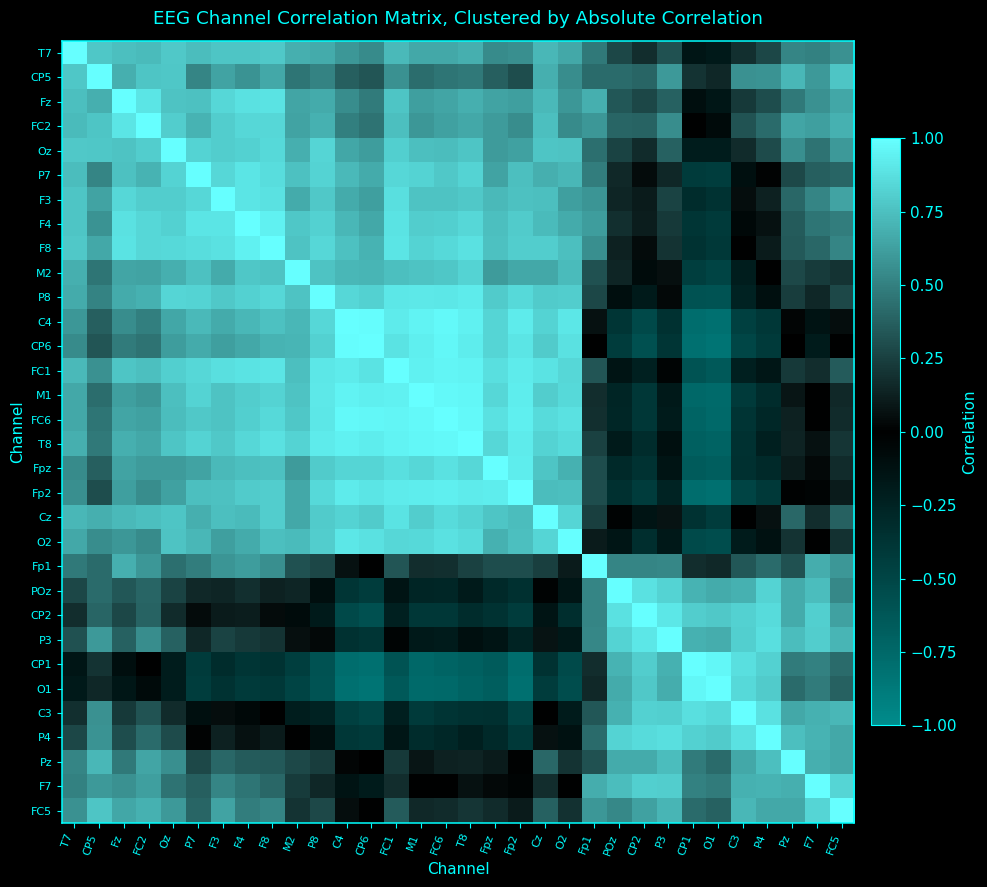

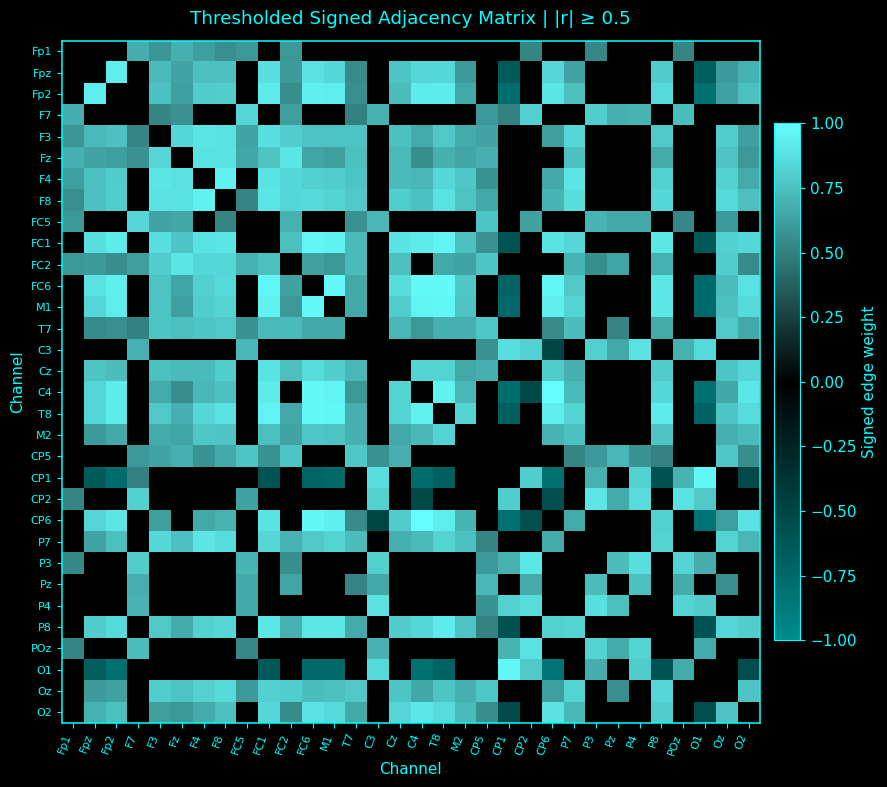

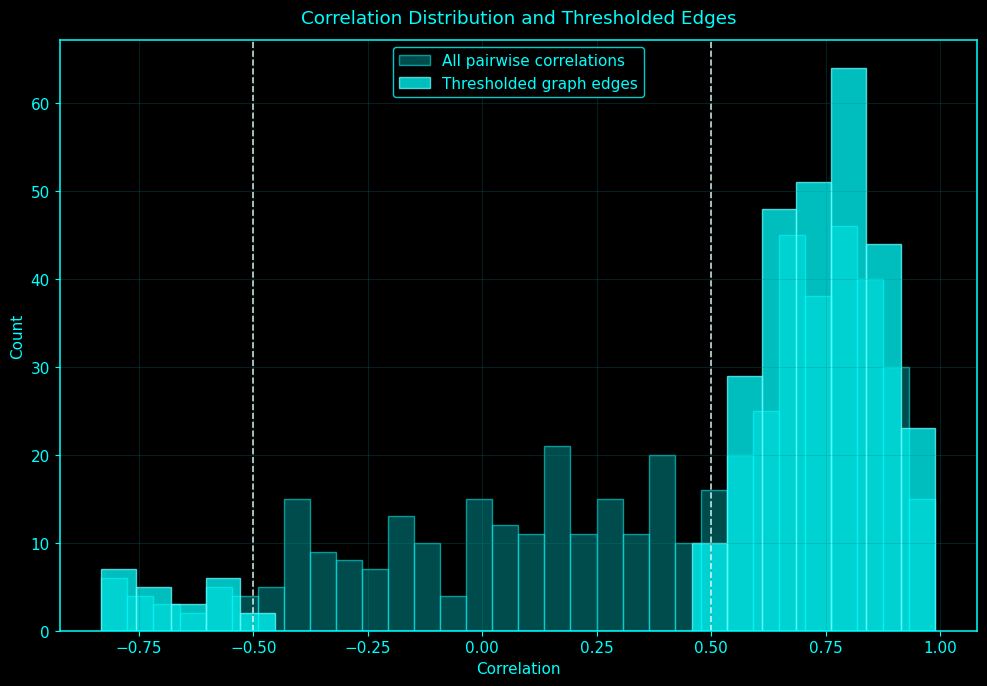

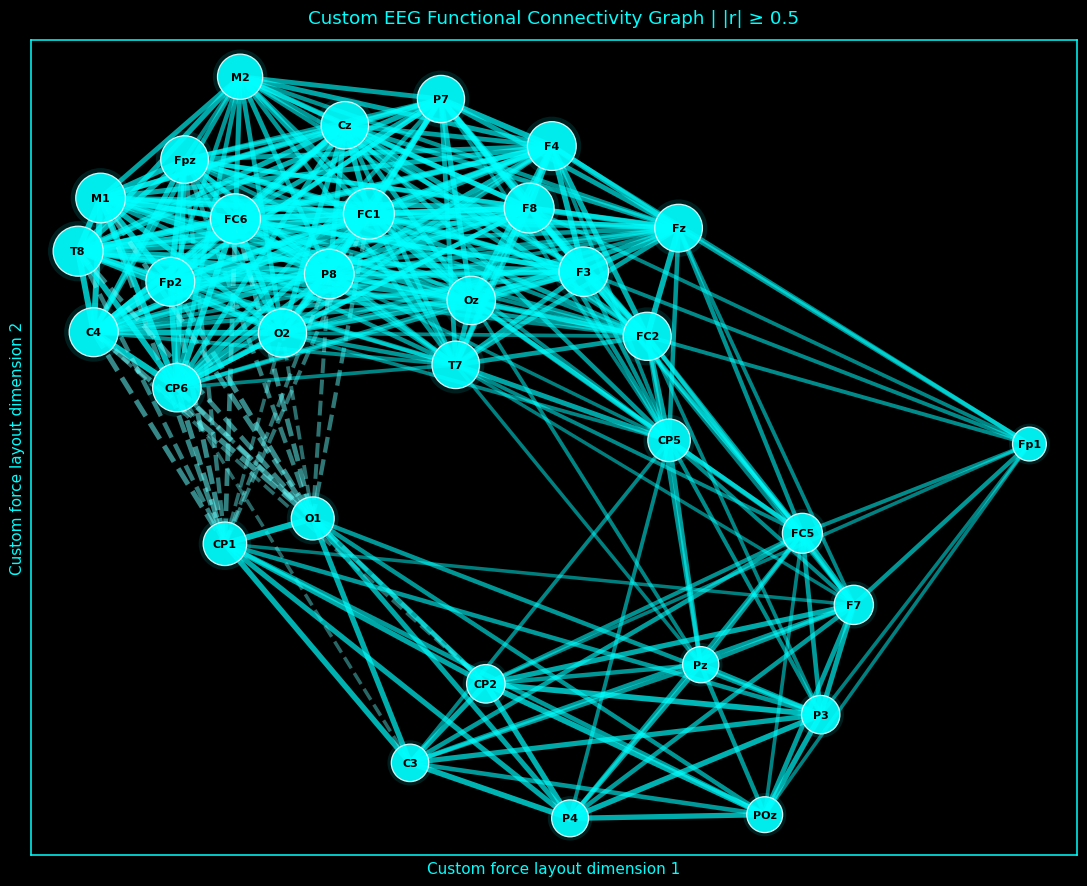

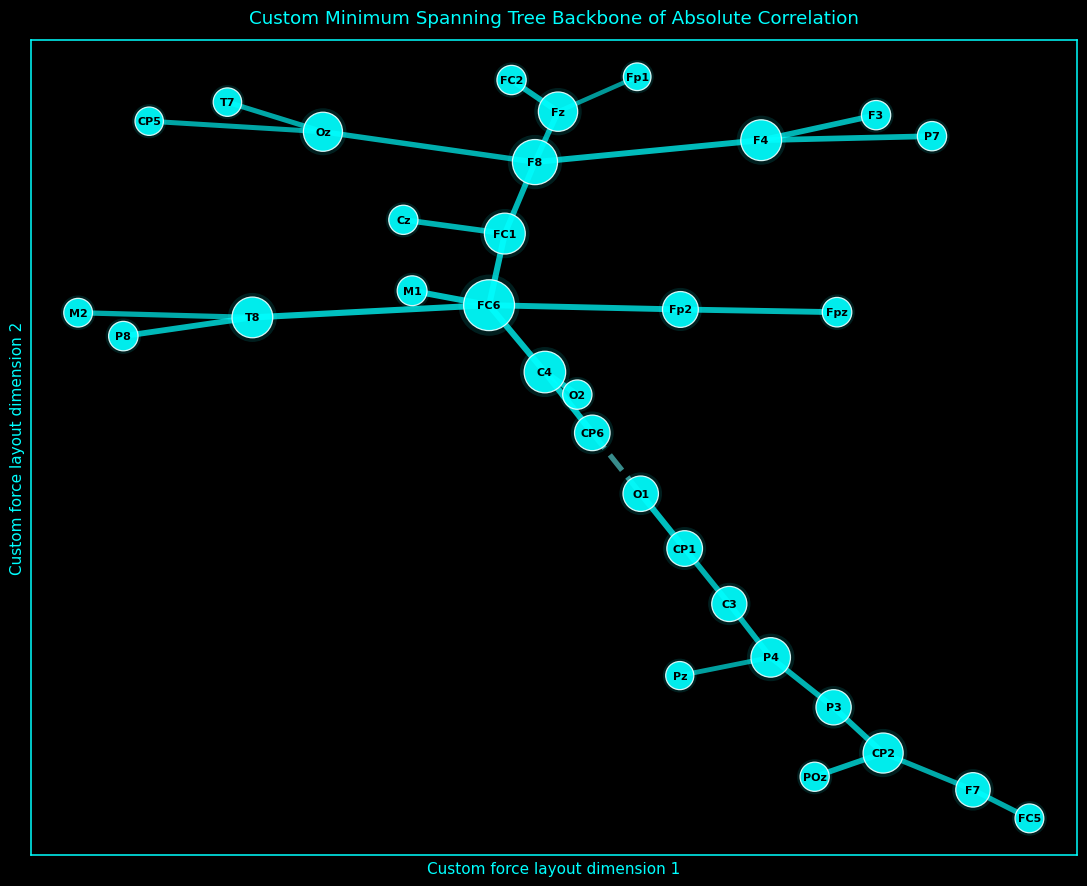

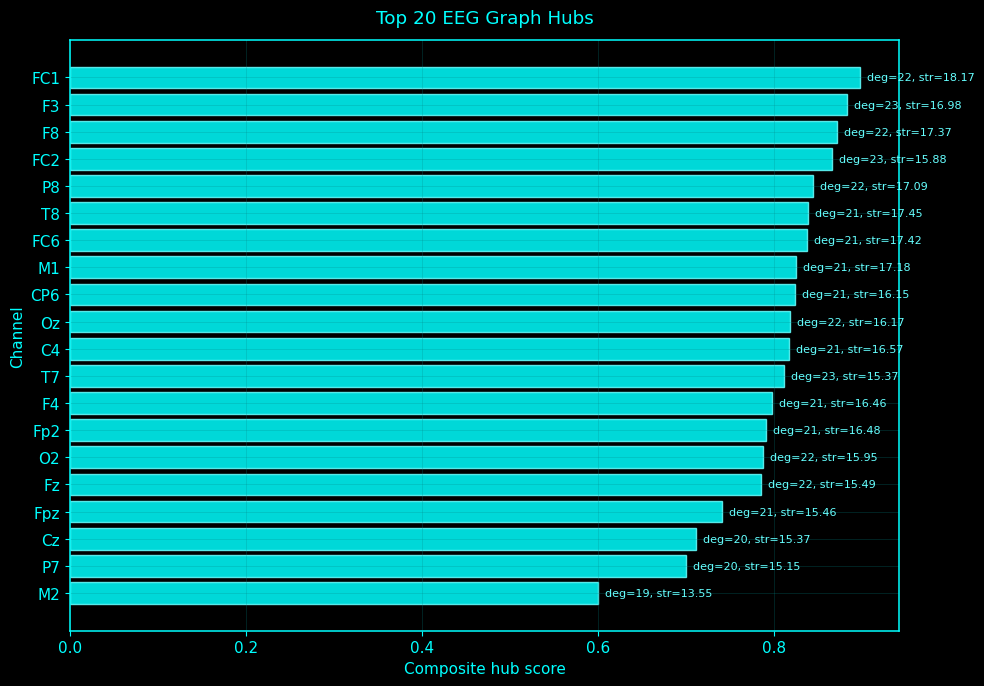

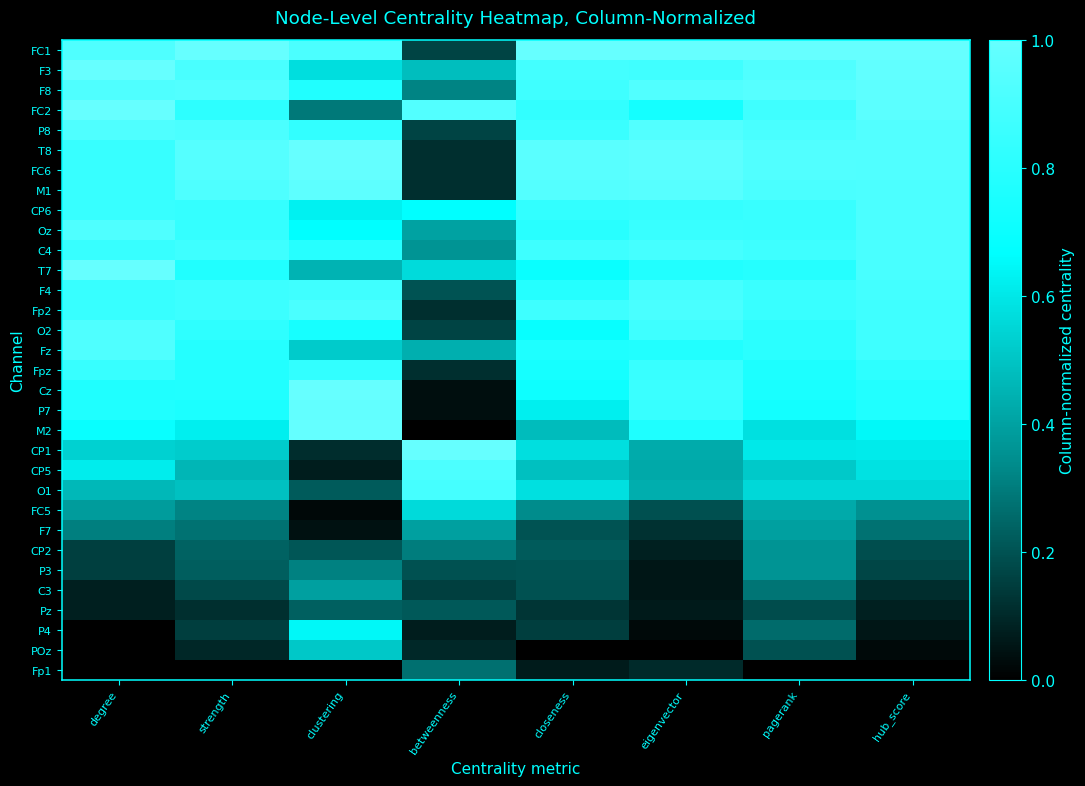

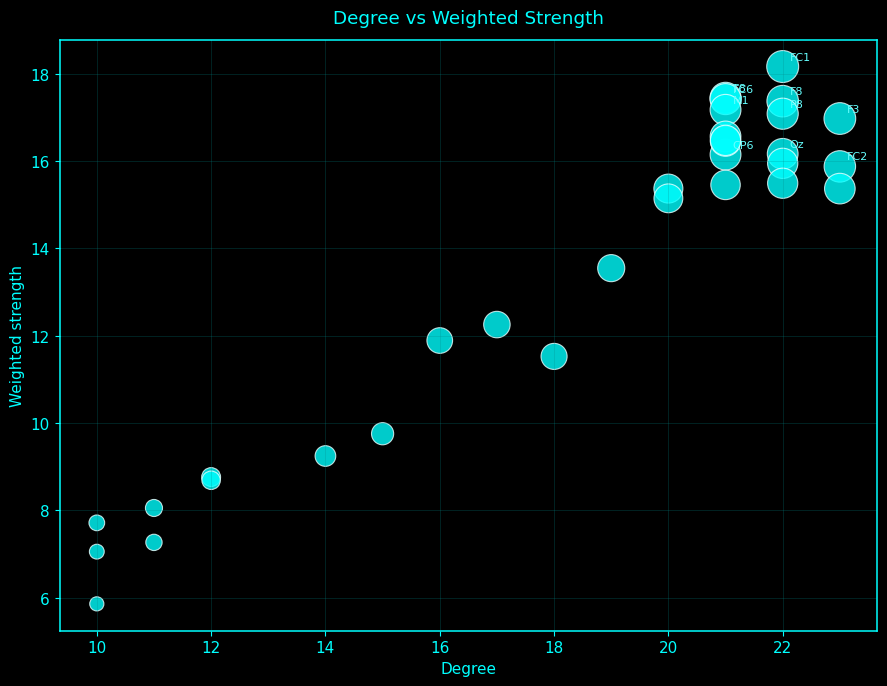

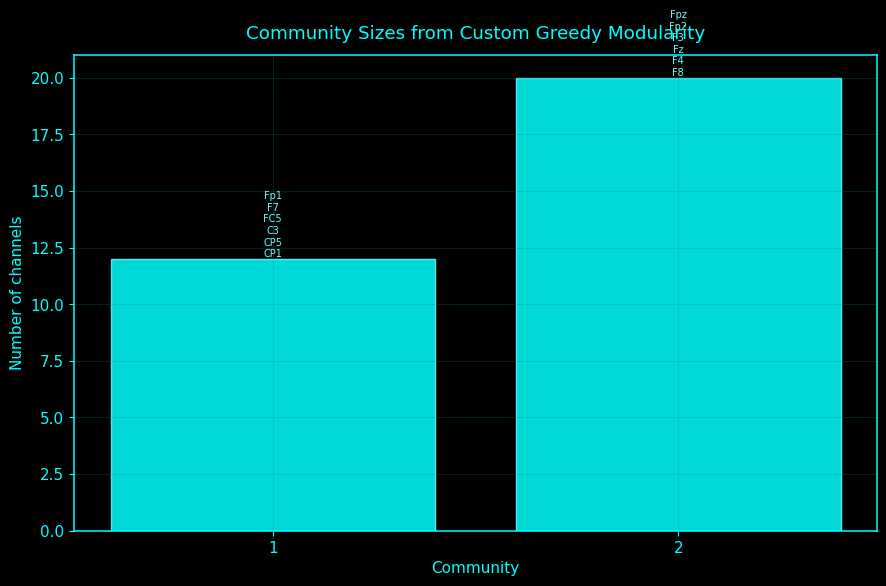

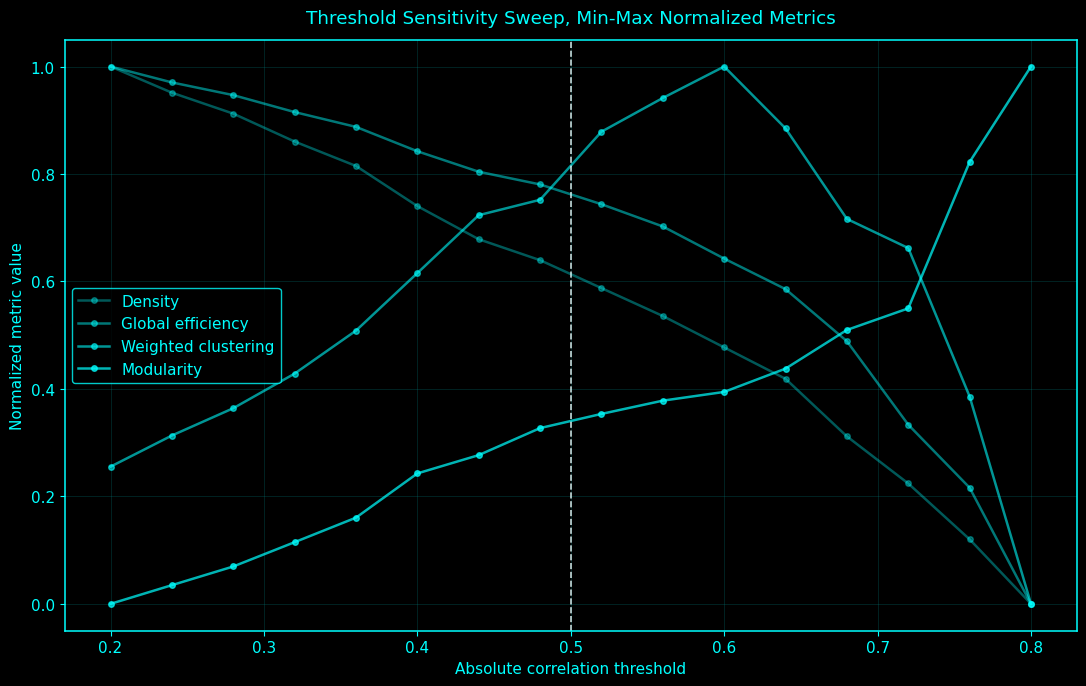

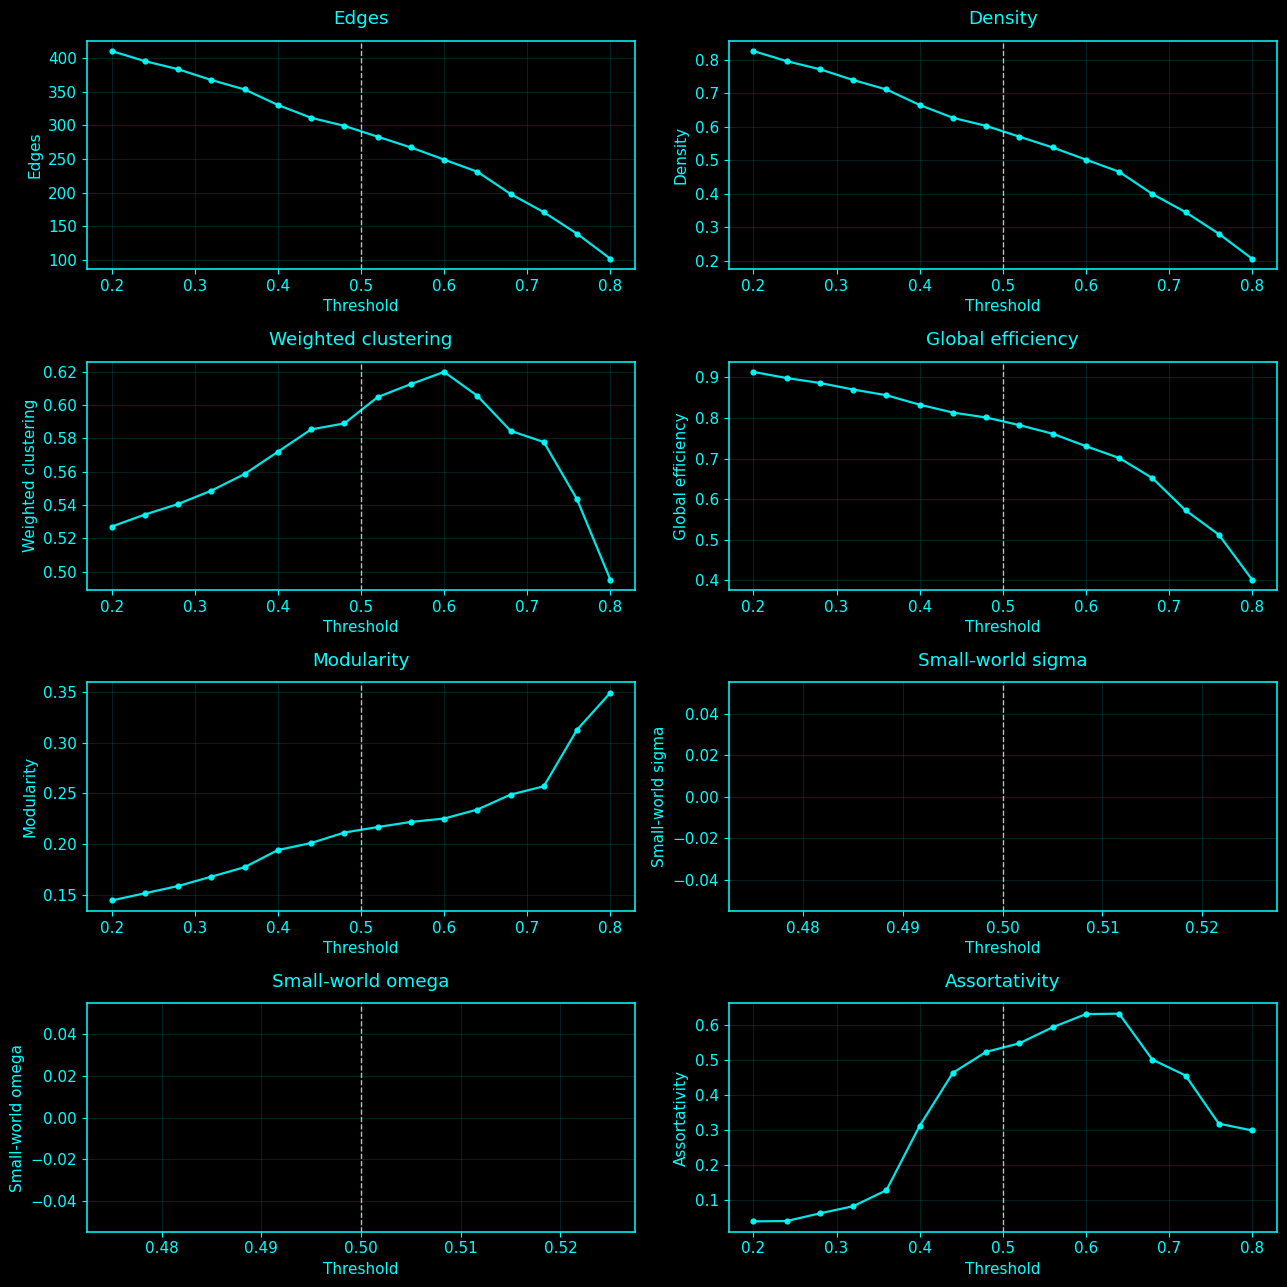

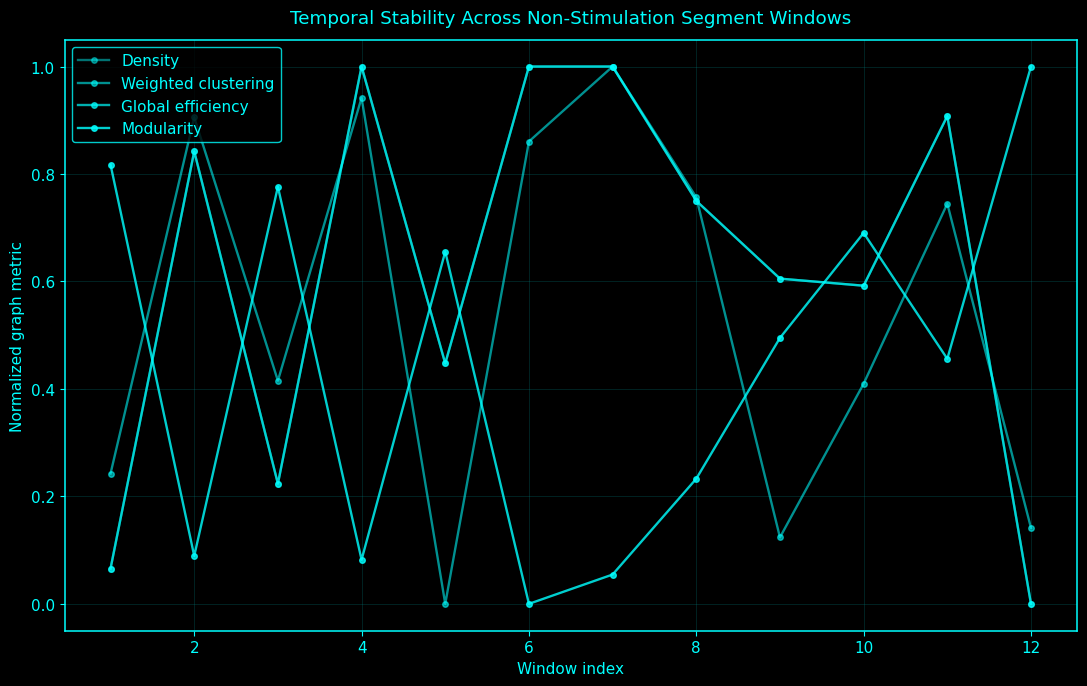


CUSTOM EXPERT EEG GRAPH THEORY SUMMARY

Global metrics:
n_nodes: 32
n_edges: 292
density: 0.5887096774193549
weighted_clustering: 0.5923931237580022
transitivity: 0.8068309070548713
modularity: 0.21493431994746273
n_communities: 2
global_efficiency: 0.7930107526881721
local_efficiency: 0.8874281578055955
assortativity: 0.5405361484564948
avg_shortest_path_unweighted_lcc: 1.4193548387096775
small_world_sigma: 1.260816161912444
small_world_omega: -0.14665481805739367

Top 10 hubs:
channel  degree  strength  clustering  betweenness  eigenvector  pagerank  hub_score
    FC1      22 18.167952    0.702004     0.007242     0.243262  0.038581   0.897477
     F3      23 16.976951    0.590948     0.020170     0.216641  0.037020   0.883608
     F8      22 17.374441    0.656649     0.013529     0.228331  0.037435   0.871610
    FC2      23 15.879758    0.497795     0.038829     0.185895  0.035824   0.865496
     P8      22 17.086855    0.675590     0.007242     0.229748  0.036545   0.844360
     

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from scipy.spatial.distance import squareform
    from scipy.cluster.hierarchy import linkage, leaves_list
    _HAVE_SCIPY_CLUSTER = True
except Exception:
    squareform = None
    linkage = None
    leaves_list = None
    _HAVE_SCIPY_CLUSTER = False

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_data_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

results_dir = os.path.join(base_dir, "results", "eeg_graph_theory_custom_math")
plots_dir = os.path.join(base_dir, "plots", "eeg_graph_theory_custom_math")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)


FAST_OPTION = "fast"

if FAST_OPTION == "ultra":
    threshold = 0.55
    threshold_grid = np.round(np.linspace(0.25, 0.75, 11), 3)
    n_random_smallworld = 6
    random_swap_factor = 4
    n_layout_iterations = 350
    bootstrap_windows = 8
    run_threshold_sweep = True
    run_temporal_stability = False
    run_smallworld_for_sweep = False
elif FAST_OPTION == "fast":
    threshold = 0.50
    threshold_grid = np.round(np.linspace(0.20, 0.80, 16), 3)
    n_random_smallworld = 12
    random_swap_factor = 8
    n_layout_iterations = 650
    bootstrap_windows = 12
    run_threshold_sweep = True
    run_temporal_stability = True
    run_smallworld_for_sweep = False
elif FAST_OPTION == "balanced":
    threshold = 0.50
    threshold_grid = np.round(np.linspace(0.15, 0.85, 29), 3)
    n_random_smallworld = 25
    random_swap_factor = 12
    n_layout_iterations = 1000
    bootstrap_windows = 20
    run_threshold_sweep = True
    run_temporal_stability = True
    run_smallworld_for_sweep = True
elif FAST_OPTION == "full":
    threshold = 0.50
    threshold_grid = np.round(np.linspace(0.10, 0.90, 41), 3)
    n_random_smallworld = 50
    random_swap_factor = 20
    n_layout_iterations = 1600
    bootstrap_windows = 32
    run_threshold_sweep = True
    run_temporal_stability = True
    run_smallworld_for_sweep = True
else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


sampling_rate = 1000
start_time = 814.571
end_time = 921.515

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6", "P7",
    "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(42)


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if grid:
        ax.grid(True, alpha=0.25, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)


def save_fig(fig, path, show=True):
    fig.tight_layout()

    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)

    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)

    plt.close(fig)


def short_label(x, max_len=22):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"


def safe_zscore(X):
    X = np.asarray(X, dtype=float)
    X = np.where(np.isfinite(X), X, np.nan)

    col_mean = np.nanmean(X, axis=0, keepdims=True)
    bad = np.where(~np.isfinite(X))

    if bad[0].size > 0:
        X[bad] = np.take(col_mean, bad[1])

    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12

    return (X - mu) / sd


def load_eeg_segment():
    EEG_data = np.load(EEG_data_path, allow_pickle=True)
    EEG_data = np.asarray(EEG_data, dtype=float)

    if EEG_data.ndim != 2:
        raise ValueError(f"Expected EEG data to be 2D, got shape {EEG_data.shape}")

    n_channels = min(EEG_data.shape[1], len(eeg_channel_names))
    EEG_data = EEG_data[:, :n_channels]
    channel_names = eeg_channel_names[:n_channels]

    start_index = max(0, int(start_time * sampling_rate))
    end_index = min(EEG_data.shape[0], int(end_time * sampling_rate))

    if end_index <= start_index:
        raise ValueError(
            f"Invalid segment: start_index={start_index}, end_index={end_index}, "
            f"data length={EEG_data.shape[0]}"
        )

    return EEG_data[start_index:end_index, :], channel_names, start_index, end_index


def compute_corr_matrix(EEG_segment):
    EEG_z = safe_zscore(EEG_segment)
    C = np.corrcoef(EEG_z.T)
    C = np.asarray(C, dtype=float)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    C = np.clip(C, -1.0, 1.0)
    np.fill_diagonal(C, 1.0)
    return EEG_z, C


def adjacency_from_corr(C, threshold=0.5, mode="absolute"):
    C = np.asarray(C, dtype=float)
    n = C.shape[0]

    W = np.zeros((n, n), dtype=float)
    S = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i + 1, n):
            r = float(C[i, j])

            if mode == "absolute":
                keep = abs(r) >= threshold
            elif mode == "positive":
                keep = r >= threshold
            elif mode == "negative":
                keep = r <= -threshold
            else:
                raise ValueError("mode must be 'absolute', 'positive', or 'negative'.")

            if keep:
                W[i, j] = abs(r)
                W[j, i] = abs(r)
                S[i, j] = r
                S[j, i] = r

    return W, S


def binary_adjacency(W):
    return (np.asarray(W) > 0).astype(int)


def edge_list_from_W(W):
    W = np.asarray(W, dtype=float)
    edges = []

    n = W.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            if W[i, j] > 0:
                edges.append((i, j, float(W[i, j])))

    return edges


def connected_components(W):
    B = binary_adjacency(W)
    n = B.shape[0]
    seen = np.zeros(n, dtype=bool)
    comps = []

    for s in range(n):
        if seen[s]:
            continue

        stack = [s]
        seen[s] = True
        comp = []

        while stack:
            u = stack.pop()
            comp.append(u)

            for v in np.where(B[u] > 0)[0]:
                if not seen[v]:
                    seen[v] = True
                    stack.append(v)

        comps.append(comp)

    return comps


def largest_component_indices(W):
    comps = connected_components(W)

    if len(comps) == 0:
        return np.array([], dtype=int)

    return np.asarray(max(comps, key=len), dtype=int)


def shortest_path_matrix(W, weighted=False):
    W = np.asarray(W, dtype=float)
    n = W.shape[0]

    D = np.full((n, n), np.inf, dtype=float)
    np.fill_diagonal(D, 0.0)

    mask = W > 0

    if weighted:
        D[mask] = 1.0 / (W[mask] + 1e-12)
    else:
        D[mask] = 1.0

    for k in range(n):
        D = np.minimum(D, D[:, [k]] + D[[k], :])

    return D


def average_shortest_path_lcc(W, weighted=False):
    idx = largest_component_indices(W)

    if len(idx) < 2:
        return np.nan

    D = shortest_path_matrix(W[np.ix_(idx, idx)], weighted=weighted)
    mask = np.isfinite(D) & (D > 0)

    if not np.any(mask):
        return np.nan

    return float(np.mean(D[mask]))


def global_efficiency(W):
    D = shortest_path_matrix(W, weighted=False)
    n = D.shape[0]

    if n < 2:
        return np.nan

    mask = np.isfinite(D) & (D > 0)
    inv = np.zeros_like(D)
    inv[mask] = 1.0 / D[mask]

    return float(np.sum(inv) / (n * (n - 1)))


def local_efficiency(W):
    B = binary_adjacency(W)
    n = B.shape[0]
    vals = []

    for i in range(n):
        neigh = np.where(B[i] > 0)[0]

        if len(neigh) < 2:
            vals.append(0.0)
            continue

        subW = W[np.ix_(neigh, neigh)]
        vals.append(global_efficiency(subW))

    return float(np.mean(vals)) if len(vals) else np.nan


def weighted_clustering_coefficients(W):
    W = np.asarray(W, dtype=float)
    n = W.shape[0]
    B = binary_adjacency(W)
    max_w = np.max(W) if np.max(W) > 0 else 1.0
    Wn = W / max_w

    C = np.zeros(n, dtype=float)

    for i in range(n):
        neigh = np.where(B[i] > 0)[0]
        k = len(neigh)

        if k < 2:
            C[i] = 0.0
            continue

        total = 0.0

        for a in range(k):
            for b in range(a + 1, k):
                j = neigh[a]
                h = neigh[b]

                if Wn[j, h] > 0:
                    total += (Wn[i, j] * Wn[i, h] * Wn[j, h]) ** (1.0 / 3.0)

        C[i] = 2.0 * total / (k * (k - 1))

    return C


def average_weighted_clustering(W):
    C = weighted_clustering_coefficients(W)
    return float(np.mean(C)) if C.size else np.nan


def transitivity(W):
    B = binary_adjacency(W)
    degrees = B.sum(axis=1)
    triples = np.sum(degrees * (degrees - 1) / 2)

    if triples <= 0:
        return 0.0

    triangles = np.trace(B @ B @ B) / 6.0

    return float(3.0 * triangles / triples)


def graph_density(W):
    n = W.shape[0]

    if n < 2:
        return np.nan

    m = len(edge_list_from_W(W))

    return float(2 * m / (n * (n - 1)))


def assortativity_by_degree(W):
    B = binary_adjacency(W)
    deg = B.sum(axis=1)
    xs = []
    ys = []

    n = B.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            if B[i, j]:
                xs.extend([deg[i], deg[j]])
                ys.extend([deg[j], deg[i]])

    if len(xs) < 2:
        return np.nan

    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    if np.std(xs) == 0 or np.std(ys) == 0:
        return np.nan

    return float(np.corrcoef(xs, ys)[0, 1])


def modularity_value(W, labels):
    W = np.asarray(W, dtype=float)
    labels = np.asarray(labels)
    m2 = np.sum(W)

    if m2 <= 0:
        return np.nan

    k = W.sum(axis=1)
    Q = 0.0
    n = W.shape[0]

    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                Q += W[i, j] - (k[i] * k[j] / m2)

    return float(Q / m2)


def greedy_modularity_custom(W):
    W = np.asarray(W, dtype=float)
    n = W.shape[0]

    if np.sum(W) <= 0:
        return np.arange(n), [[i] for i in range(n)], np.nan

    communities = [[i] for i in range(n)]
    labels = np.arange(n)
    current_Q = modularity_value(W, labels)

    improved = True

    while improved and len(communities) > 1:
        improved = False
        best_Q = current_Q
        best_pair = None

        for a in range(len(communities)):
            for b in range(a + 1, len(communities)):
                test_comms = [list(c) for c in communities]
                test_comms[a] = test_comms[a] + test_comms[b]
                del test_comms[b]

                test_labels = np.zeros(n, dtype=int)

                for ci, comm in enumerate(test_comms):
                    for node in comm:
                        test_labels[node] = ci

                Q = modularity_value(W, test_labels)

                if np.isfinite(Q) and Q > best_Q + 1e-10:
                    best_Q = Q
                    best_pair = (a, b)

        if best_pair is not None:
            a, b = best_pair
            communities[a] = communities[a] + communities[b]
            del communities[b]

            labels = np.zeros(n, dtype=int)

            for ci, comm in enumerate(communities):
                for node in comm:
                    labels[node] = ci

            current_Q = best_Q
            improved = True

    return labels, communities, float(current_Q)


def eigenvector_centrality(W, max_iter=500, tol=1e-10):
    W = np.asarray(W, dtype=float)
    n = W.shape[0]

    if np.sum(W) <= 0:
        return np.zeros(n)

    x = np.ones(n) / np.sqrt(n)

    for _ in range(max_iter):
        x_new = W @ x
        norm = np.linalg.norm(x_new)

        if norm == 0:
            return np.zeros(n)

        x_new = x_new / norm

        if np.linalg.norm(x_new - x) < tol:
            break

        x = x_new

    return np.abs(x)


def pagerank_custom(W, alpha=0.85, max_iter=300, tol=1e-10):
    W = np.asarray(W, dtype=float)
    n = W.shape[0]

    if n == 0:
        return np.array([])

    row_sum = W.sum(axis=1)
    P = np.zeros_like(W, dtype=float)

    for i in range(n):
        if row_sum[i] > 0:
            P[i] = W[i] / row_sum[i]
        else:
            P[i] = np.ones(n) / n

    pr = np.ones(n) / n

    for _ in range(max_iter):
        pr_new = alpha * (P.T @ pr) + (1 - alpha) / n

        if np.linalg.norm(pr_new - pr, 1) < tol:
            pr = pr_new
            break

        pr = pr_new

    return pr


def betweenness_unweighted(W):
    B = binary_adjacency(W)
    n = B.shape[0]
    CB = np.zeros(n, dtype=float)

    for s in range(n):
        stack = []
        pred = [[] for _ in range(n)]
        sigma = np.zeros(n, dtype=float)
        dist = -np.ones(n, dtype=int)

        sigma[s] = 1.0
        dist[s] = 0

        queue = [s]
        qhead = 0

        while qhead < len(queue):
            v = queue[qhead]
            qhead += 1
            stack.append(v)

            for w in np.where(B[v] > 0)[0]:
                if dist[w] < 0:
                    queue.append(w)
                    dist[w] = dist[v] + 1

                if dist[w] == dist[v] + 1:
                    sigma[w] += sigma[v]
                    pred[w].append(v)

        delta = np.zeros(n, dtype=float)

        while stack:
            w = stack.pop()

            for v in pred[w]:
                if sigma[w] > 0:
                    delta[v] += (sigma[v] / sigma[w]) * (1.0 + delta[w])

            if w != s:
                CB[w] += delta[w]

    CB /= 2.0

    if n > 2:
        CB *= 2.0 / ((n - 1) * (n - 2))

    return CB


def closeness_weighted(W):
    D = shortest_path_matrix(W, weighted=True)
    n = D.shape[0]
    vals = np.zeros(n, dtype=float)

    for i in range(n):
        mask = np.isfinite(D[i]) & (D[i] > 0)

        if not np.any(mask):
            vals[i] = 0.0
        else:
            reachable = np.sum(mask)
            vals[i] = (reachable / np.sum(D[i, mask])) * (reachable / max(n - 1, 1))

    return vals


def graph_metrics(W, label="absolute", threshold_value=np.nan, compute_smallworld=True):
    W = np.asarray(W, dtype=float)
    n = W.shape[0]
    edges = edge_list_from_W(W)
    degrees = binary_adjacency(W).sum(axis=1)
    strengths = W.sum(axis=1)

    labels, communities, Q = greedy_modularity_custom(W)

    comps = connected_components(W)
    largest = max([len(c) for c in comps]) if len(comps) else 0

    out = {
        "label": label,
        "threshold": float(threshold_value),
        "n_nodes": int(n),
        "n_edges": int(len(edges)),
        "density": graph_density(W),
        "n_components": int(len(comps)),
        "largest_component_size": int(largest),
        "mean_degree": float(np.mean(degrees)) if n else np.nan,
        "median_degree": float(np.median(degrees)) if n else np.nan,
        "max_degree": float(np.max(degrees)) if n else np.nan,
        "mean_strength": float(np.mean(strengths)) if n else np.nan,
        "median_strength": float(np.median(strengths)) if n else np.nan,
        "max_strength": float(np.max(strengths)) if n else np.nan,
        "weighted_clustering": average_weighted_clustering(W),
        "transitivity": transitivity(W),
        "modularity": Q,
        "n_communities": int(len(communities)),
        "global_efficiency": global_efficiency(W),
        "local_efficiency": local_efficiency(W),
        "assortativity": assortativity_by_degree(W),
        "avg_shortest_path_unweighted_lcc": average_shortest_path_lcc(W, weighted=False),
        "avg_shortest_path_weighted_lcc": average_shortest_path_lcc(W, weighted=True),
    }

    if compute_smallworld:
        out.update(smallworld_metrics(W))
    else:
        out.update({
            "small_world_sigma": np.nan,
            "small_world_omega": np.nan,
            "C_rand_mean": np.nan,
            "L_rand_mean": np.nan,
            "C_latt": np.nan,
            "L_latt": np.nan,
        })

    return out, labels, communities


def double_edge_swap_binary(B, nswap=100, max_tries=2000, seed=42):
    rng_local = np.random.default_rng(seed)
    B = np.asarray(B, dtype=int).copy()
    n = B.shape[0]

    edges = [(i, j) for i in range(n) for j in range(i + 1, n) if B[i, j]]

    if len(edges) < 2:
        return B

    edge_set = set(edges)
    swaps = 0
    tries = 0

    while swaps < nswap and tries < max_tries:
        tries += 1

        e1_idx, e2_idx = rng_local.choice(len(edges), size=2, replace=False)
        a, b = edges[e1_idx]
        c, d = edges[e2_idx]

        if len({a, b, c, d}) < 4:
            continue

        if rng_local.random() < 0.5:
            new1 = tuple(sorted((a, d)))
            new2 = tuple(sorted((c, b)))
        else:
            new1 = tuple(sorted((a, c)))
            new2 = tuple(sorted((b, d)))

        if new1[0] == new1[1] or new2[0] == new2[1]:
            continue

        if new1 in edge_set or new2 in edge_set:
            continue

        old1 = tuple(sorted((a, b)))
        old2 = tuple(sorted((c, d)))

        edge_set.remove(old1)
        edge_set.remove(old2)
        edge_set.add(new1)
        edge_set.add(new2)

        edges[e1_idx] = new1
        edges[e2_idx] = new2

        swaps += 1

    B2 = np.zeros_like(B)

    for i, j in edge_set:
        B2[i, j] = 1
        B2[j, i] = 1

    return B2


def lattice_binary_graph(n, m):
    B = np.zeros((n, n), dtype=int)

    if n < 2 or m <= 0:
        return B

    edges_added = 0
    radius = 1

    while edges_added < m and radius < n:
        for i in range(n):
            if edges_added >= m:
                break

            j = (i + radius) % n

            if i == j:
                continue

            a, b = sorted((i, j))

            if B[a, b] == 0:
                B[a, b] = 1
                B[b, a] = 1
                edges_added += 1

        radius += 1

    return B


def smallworld_metrics(W):
    B = binary_adjacency(W)
    n = B.shape[0]
    m = int(np.sum(B) // 2)

    if n < 4 or m < 2:
        return {
            "small_world_sigma": np.nan,
            "small_world_omega": np.nan,
            "C_rand_mean": np.nan,
            "L_rand_mean": np.nan,
            "C_latt": np.nan,
            "L_latt": np.nan,
        }

    C = transitivity(B)
    L = average_shortest_path_lcc(B, weighted=False)

    C_rand_vals = []
    L_rand_vals = []

    for r in range(n_random_smallworld):
        Br = double_edge_swap_binary(
            B,
            nswap=max(1, random_swap_factor * m),
            max_tries=max(100, random_swap_factor * m * 25),
            seed=1000 + r,
        )

        C_rand_vals.append(transitivity(Br))
        L_rand_vals.append(average_shortest_path_lcc(Br, weighted=False))

    C_rand_vals = np.asarray(C_rand_vals, dtype=float)
    L_rand_vals = np.asarray(L_rand_vals, dtype=float)

    C_rand = np.nanmean(C_rand_vals)
    L_rand = np.nanmean(L_rand_vals)

    Bl = lattice_binary_graph(n, m)
    C_latt = transitivity(Bl)
    L_latt = average_shortest_path_lcc(Bl, weighted=False)

    sigma = np.nan
    omega = np.nan

    if np.isfinite(C) and np.isfinite(L) and np.isfinite(C_rand) and np.isfinite(L_rand):
        if C_rand > 0 and L_rand > 0 and L > 0:
            sigma = float((C / C_rand) / (L / L_rand))

    if np.isfinite(L_rand) and np.isfinite(L) and np.isfinite(C) and np.isfinite(C_latt):
        if L > 0 and C_latt > 0:
            omega = float((L_rand / L) - (C / C_latt))

    return {
        "small_world_sigma": sigma,
        "small_world_omega": omega,
        "C_rand_mean": float(C_rand),
        "L_rand_mean": float(L_rand),
        "C_latt": float(C_latt),
        "L_latt": float(L_latt),
    }


def node_centrality_table(W, S, channel_names):
    W = np.asarray(W, dtype=float)
    B = binary_adjacency(W)

    degrees = B.sum(axis=1)
    strengths = W.sum(axis=1)
    clustering = weighted_clustering_coefficients(W)
    betweenness = betweenness_unweighted(W)
    closeness = closeness_weighted(W)
    eigen = eigenvector_centrality(W)
    pagerank = pagerank_custom(W)

    rows = []

    for i, ch in enumerate(channel_names):
        rows.append({
            "channel": ch,
            "degree": int(degrees[i]),
            "strength": float(strengths[i]),
            "clustering": float(clustering[i]),
            "betweenness": float(betweenness[i]),
            "closeness": float(closeness[i]),
            "eigenvector": float(eigen[i]),
            "pagerank": float(pagerank[i]),
        })

    df = pd.DataFrame(rows)

    cols = ["degree", "strength", "clustering", "betweenness", "closeness", "eigenvector", "pagerank"]

    for c in cols:
        vals = df[c].to_numpy(dtype=float)
        finite = vals[np.isfinite(vals)]

        if finite.size == 0 or np.nanmax(finite) == np.nanmin(finite):
            df[c + "_rank_score"] = 0.0
        else:
            df[c + "_rank_score"] = (vals - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)

    df["hub_score"] = (
        0.30 * df["strength_rank_score"]
        + 0.25 * df["degree_rank_score"]
        + 0.20 * df["eigenvector_rank_score"]
        + 0.15 * df["pagerank_rank_score"]
        + 0.10 * df["betweenness_rank_score"]
    )

    return df.sort_values("hub_score", ascending=False)


def community_table(labels, communities, channel_names):
    rows = []

    for ci, comm in enumerate(communities, start=1):
        for idx in sorted(comm):
            rows.append({
                "channel": channel_names[idx],
                "community": ci,
                "community_size": len(comm),
            })

    return pd.DataFrame(rows)


def threshold_sweep_metrics(C, channel_names, thresholds):
    rows = []

    for th in thresholds:
        W, S = adjacency_from_corr(C, threshold=th, mode="absolute")
        row, _, _ = graph_metrics(
            W,
            label="absolute",
            threshold_value=th,
            compute_smallworld=run_smallworld_for_sweep,
        )
        rows.append(row)

    return pd.DataFrame(rows)


def mst_from_corr(C):
    C = np.asarray(C, dtype=float)
    n = C.shape[0]

    edges = []

    for i in range(n):
        for j in range(i + 1, n):
            abs_r = abs(float(C[i, j]))
            distance = 1.0 - abs_r
            edges.append((distance, i, j, abs_r, float(C[i, j])))

    edges.sort(key=lambda x: x[0])

    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra = find(a)
        rb = find(b)

        if ra == rb:
            return False

        parent[rb] = ra
        return True

    W = np.zeros((n, n), dtype=float)
    S = np.zeros((n, n), dtype=float)

    for dist, i, j, abs_r, r in edges:
        if union(i, j):
            W[i, j] = abs_r
            W[j, i] = abs_r
            S[i, j] = r
            S[j, i] = r

        if np.sum(W > 0) // 2 == n - 1:
            break

    return W, S


def force_layout(W, iterations=800, seed=42):
    rng_local = np.random.default_rng(seed)
    W = np.asarray(W, dtype=float)
    n = W.shape[0]

    if n == 0:
        return np.empty((0, 2))

    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = np.column_stack([np.cos(theta), np.sin(theta)])
    pos += 0.05 * rng_local.normal(size=pos.shape)

    area = 4.0
    k = np.sqrt(area / max(n, 1))
    temperature = 0.08

    edges = edge_list_from_W(W)

    for it in range(iterations):
        disp = np.zeros_like(pos)

        for i in range(n):
            delta = pos[i] - pos
            dist = np.linalg.norm(delta, axis=1) + 1e-9
            repulse = (k * k / dist)[:, None] * (delta / dist[:, None])
            repulse[i] = 0
            disp[i] += np.sum(repulse, axis=0)

        for i, j, w in edges:
            delta = pos[i] - pos[j]
            dist = np.linalg.norm(delta) + 1e-9
            attract = (dist * dist / k) * (delta / dist) * (0.35 + 1.2 * w)
            disp[i] -= attract
            disp[j] += attract

        lengths = np.linalg.norm(disp, axis=1) + 1e-9
        step = disp / lengths[:, None] * np.minimum(lengths, temperature)[:, None]
        pos += step

        temperature *= 0.995

    pos -= pos.mean(axis=0, keepdims=True)
    scale = np.max(np.linalg.norm(pos, axis=1))

    if scale > 0:
        pos /= scale

    return pos


def plot_corr_heatmap(C, channel_names, path):
    M = np.asarray(C, dtype=float)

    if _HAVE_SCIPY_CLUSTER:
        try:
            dist = 1.0 - np.abs(M)
            np.fill_diagonal(dist, 0.0)
            condensed = squareform(dist, checks=False)
            Z = linkage(condensed, method="average")
            order = leaves_list(Z)
        except Exception:
            order = np.arange(len(channel_names))
    else:
        order = np.arange(len(channel_names))

    M_ord = M[np.ix_(order, order)]
    labels_ord = [channel_names[i] for i in order]

    fig, ax = plt.subplots(figsize=(10, 9))

    im = ax.imshow(
        M_ord,
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(labels_ord)))
    ax.set_yticks(np.arange(len(labels_ord)))
    ax.set_xticklabels(labels_ord, rotation=70, ha="right", fontsize=8, color=ACCENT)
    ax.set_yticklabels(labels_ord, fontsize=8, color=ACCENT)

    style_ax(
        ax,
        title="EEG Channel Correlation Matrix, Clustered by Absolute Correlation",
        xlabel="Channel",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Correlation", color=ACCENT)

    save_fig(fig, path)
    return path


def plot_adjacency_heatmap(S, channel_names, path):
    fig, ax = plt.subplots(figsize=(9, 8))

    im = ax.imshow(
        S,
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(channel_names)))
    ax.set_yticks(np.arange(len(channel_names)))
    ax.set_xticklabels(channel_names, rotation=70, ha="right", fontsize=8, color=ACCENT)
    ax.set_yticklabels(channel_names, fontsize=8, color=ACCENT)

    style_ax(
        ax,
        title=f"Thresholded Signed Adjacency Matrix | |r| ≥ {threshold}",
        xlabel="Channel",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Signed edge weight", color=ACCENT)

    save_fig(fig, path)
    return path


def plot_edge_distribution(C, W, path):
    vals = []
    n = C.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            vals.append(float(C[i, j]))

    vals = np.asarray(vals, dtype=float)

    edge_vals = []

    for i, j, w in edge_list_from_W(W):
        edge_vals.append(float(C[i, j]))

    edge_vals = np.asarray(edge_vals, dtype=float)

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.hist(
        vals,
        bins=32,
        color=ACCENT_DIM,
        edgecolor=ACCENT,
        alpha=0.55,
        label="All pairwise correlations",
    )

    if edge_vals.size:
        ax.hist(
            edge_vals,
            bins=24,
            color=ACCENT,
            edgecolor=ACCENT_SOFT,
            alpha=0.75,
            label="Thresholded graph edges",
        )

    ax.axvline(threshold, color=WHITE, linestyle="--", linewidth=1.2, alpha=0.85)
    ax.axvline(-threshold, color=WHITE, linestyle="--", linewidth=1.2, alpha=0.85)

    style_ax(
        ax,
        title="Correlation Distribution and Thresholded Edges",
        xlabel="Correlation",
        ylabel="Count",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)
    return path


def plot_manual_network(W, S, channel_names, communities, path, title):
    fig, ax = plt.subplots(figsize=(11, 9))

    W = np.asarray(W, dtype=float)
    S = np.asarray(S, dtype=float)

    if np.sum(W > 0) == 0:
        ax.text(
            0.5,
            0.5,
            "No edges at selected threshold",
            ha="center",
            va="center",
            color=ACCENT,
            transform=ax.transAxes,
        )
        style_ax(ax, title=title, grid=False)
        save_fig(fig, path)
        return path

    pos = force_layout(W, iterations=n_layout_iterations, seed=42)
    strengths = W.sum(axis=1)
    max_strength = np.max(strengths) if np.max(strengths) > 0 else 1.0

    for i, j, w in edge_list_from_W(W):
        x = [pos[i, 0], pos[j, 0]]
        y = [pos[i, 1], pos[j, 1]]
        sign = S[i, j]

        if sign >= 0:
            color = ACCENT
            linestyle = "-"
            alpha = 0.22 + 0.55 * w
        else:
            color = ACCENT_SOFT
            linestyle = "--"
            alpha = 0.18 + 0.45 * w

        ax.plot(
            x,
            y,
            color=color,
            linewidth=0.5 + 4.0 * w,
            alpha=min(alpha, 0.9),
            linestyle=linestyle,
            zorder=1,
        )

    node_sizes = 240 + 1100 * strengths / (max_strength + 1e-12)

    ax.scatter(
        pos[:, 0],
        pos[:, 1],
        s=node_sizes * 1.45,
        c=ACCENT,
        alpha=0.12,
        linewidths=0,
        zorder=2,
    )

    ax.scatter(
        pos[:, 0],
        pos[:, 1],
        s=node_sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.9,
        alpha=0.92,
        zorder=3,
    )

    for i, ch in enumerate(channel_names):
        ax.text(
            pos[i, 0],
            pos[i, 1],
            ch,
            ha="center",
            va="center",
            color=BLACK,
            fontsize=8,
            fontweight="bold",
            zorder=4,
        )

    style_ax(
        ax,
        title=title,
        xlabel="Custom force layout dimension 1",
        ylabel="Custom force layout dimension 2",
        grid=False,
    )

    ax.set_xticks([])
    ax.set_yticks([])

    save_fig(fig, path)
    return path


def plot_hub_ranking(node_df, path, top_n=20):
    df = node_df.sort_values("hub_score", ascending=False).head(top_n)
    df = df.sort_values("hub_score", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))

    y = np.arange(len(df))

    ax.barh(
        y,
        df["hub_score"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.85,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT)

    for yi, (_, row) in zip(y, df.iterrows()):
        ax.text(
            row["hub_score"],
            yi,
            f"  deg={int(row['degree'])}, str={row['strength']:.2f}",
            va="center",
            ha="left",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title=f"Top {len(df)} EEG Graph Hubs",
        xlabel="Composite hub score",
        ylabel="Channel",
    )

    save_fig(fig, path)
    return path


def plot_centrality_heatmap(node_df, path):
    cols = ["degree", "strength", "clustering", "betweenness", "closeness", "eigenvector", "pagerank", "hub_score"]
    df = node_df.copy().sort_values("hub_score", ascending=False)

    M = df[cols].to_numpy(dtype=float)
    M_norm = np.zeros_like(M, dtype=float)

    for j in range(M.shape[1]):
        col = M[:, j]
        finite = col[np.isfinite(col)]

        if finite.size == 0 or np.nanmax(finite) == np.nanmin(finite):
            continue

        M_norm[:, j] = (col - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)

    fig, ax = plt.subplots(figsize=(11, 8))

    im = ax.imshow(
        M_norm,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols, rotation=55, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Node-Level Centrality Heatmap, Column-Normalized",
        xlabel="Centrality metric",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Column-normalized centrality", color=ACCENT)

    save_fig(fig, path)
    return path


def plot_degree_strength_scatter(node_df, path):
    df = node_df.copy()

    fig, ax = plt.subplots(figsize=(9, 7))

    sizes = np.clip(80 + 500 * df["hub_score"].to_numpy(), 60, 600)

    ax.scatter(
        df["degree"],
        df["strength"],
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.8,
        alpha=0.80,
    )

    for _, row in df.sort_values("hub_score", ascending=False).head(10).iterrows():
        ax.annotate(
            row["channel"],
            (row["degree"], row["strength"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Degree vs Weighted Strength",
        xlabel="Degree",
        ylabel="Weighted strength",
    )

    save_fig(fig, path)
    return path


def plot_community_membership(community_df, path):
    if community_df.empty:
        return None

    counts = community_df.groupby("community")["channel"].count().reset_index(name="size")

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.bar(
        counts["community"].astype(str),
        counts["size"],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.85,
    )

    for _, row in counts.iterrows():
        members = community_df[community_df["community"] == row["community"]]["channel"].tolist()
        ax.text(
            str(row["community"]),
            row["size"],
            "\n".join(members[:6]),
            ha="center",
            va="bottom",
            color=ACCENT_SOFT,
            fontsize=7,
        )

    style_ax(
        ax,
        title="Community Sizes from Custom Greedy Modularity",
        xlabel="Community",
        ylabel="Number of channels",
    )

    save_fig(fig, path)
    return path


def plot_threshold_sweep(sweep_df, path):
    if sweep_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(11, 7))

    metrics = [
        ("density", "Density"),
        ("global_efficiency", "Global efficiency"),
        ("weighted_clustering", "Weighted clustering"),
        ("modularity", "Modularity"),
        ("small_world_sigma", "Small-world sigma"),
    ]

    for idx, (col, label) in enumerate(metrics):
        if col not in sweep_df.columns:
            continue

        y = sweep_df[col].to_numpy(dtype=float)
        finite = y[np.isfinite(y)]

        if finite.size == 0:
            continue

        if np.nanmax(finite) != np.nanmin(finite):
            y_plot = (y - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)
        else:
            y_plot = y

        ax.plot(
            sweep_df["threshold"],
            y_plot,
            marker="o",
            linewidth=1.8,
            markersize=4,
            color=ACCENT,
            alpha=0.35 + 0.12 * idx,
            label=label,
        )

    ax.axvline(threshold, color=WHITE, linestyle="--", linewidth=1.2, alpha=0.85)

    style_ax(
        ax,
        title="Threshold Sensitivity Sweep, Min-Max Normalized Metrics",
        xlabel="Absolute correlation threshold",
        ylabel="Normalized metric value",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)
    return path


def plot_sweep_raw_panels(sweep_df, path):
    if sweep_df.empty:
        return None

    metric_cols = [
        ("n_edges", "Edges"),
        ("density", "Density"),
        ("weighted_clustering", "Weighted clustering"),
        ("global_efficiency", "Global efficiency"),
        ("modularity", "Modularity"),
        ("small_world_sigma", "Small-world sigma"),
        ("small_world_omega", "Small-world omega"),
        ("assortativity", "Assortativity"),
    ]

    fig, axes = plt.subplots(4, 2, figsize=(13, 13), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax, (col, title) in zip(axes.ravel(), metric_cols):
        if col in sweep_df.columns:
            ax.plot(
                sweep_df["threshold"],
                sweep_df[col],
                marker="o",
                color=ACCENT,
                linewidth=1.6,
                markersize=3.5,
                alpha=0.9,
            )

            ax.axvline(threshold, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

        style_ax(
            ax,
            title=title,
            xlabel="Threshold",
            ylabel=title,
        )

    save_fig(fig, path)
    return path


def bootstrap_window_metrics(EEG_z, channel_names, n_windows=12):
    n = EEG_z.shape[0]
    window_len = max(100, n // n_windows)

    rows = []

    for w in range(n_windows):
        s = w * window_len
        e = min(n, s + window_len)

        if e - s < 100:
            continue

        Xw = EEG_z[s:e, :]
        Cw = np.corrcoef(Xw.T)
        Cw = np.nan_to_num(Cw, nan=0.0, posinf=0.0, neginf=0.0)
        np.fill_diagonal(Cw, 1.0)

        Ww, Sw = adjacency_from_corr(Cw, threshold=threshold, mode="absolute")

        row, _, _ = graph_metrics(
            Ww,
            label=f"window_{w+1}",
            threshold_value=threshold,
            compute_smallworld=False,
        )

        row["window"] = w + 1
        row["start_sample"] = s
        row["end_sample"] = e
        row["start_sec_relative"] = s / sampling_rate
        row["end_sec_relative"] = e / sampling_rate

        rows.append(row)

    return pd.DataFrame(rows)


def plot_temporal_stability(window_df, path):
    if window_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(11, 7))

    metrics = [
        ("density", "Density"),
        ("weighted_clustering", "Weighted clustering"),
        ("global_efficiency", "Global efficiency"),
        ("modularity", "Modularity"),
    ]

    for idx, (col, label) in enumerate(metrics):
        if col not in window_df.columns:
            continue

        y = window_df[col].to_numpy(dtype=float)
        finite = y[np.isfinite(y)]

        if finite.size == 0:
            continue

        if np.nanmax(finite) != np.nanmin(finite):
            y_plot = (y - np.nanmin(finite)) / (np.nanmax(finite) - np.nanmin(finite) + 1e-12)
        else:
            y_plot = y

        ax.plot(
            window_df["window"],
            y_plot,
            marker="o",
            linewidth=1.7,
            markersize=4,
            color=ACCENT,
            alpha=0.45 + 0.12 * idx,
            label=label,
        )

    style_ax(
        ax,
        title="Temporal Stability Across Non-Stimulation Segment Windows",
        xlabel="Window index",
        ylabel="Normalized graph metric",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)
    return path


def save_outputs(metrics_df, node_df, community_df, sweep_df, window_df):
    metrics_csv = os.path.join(results_dir, "custom_graph_global_metrics.csv")
    node_csv = os.path.join(results_dir, "custom_graph_node_centralities.csv")
    community_csv = os.path.join(results_dir, "custom_graph_communities.csv")
    sweep_csv = os.path.join(results_dir, "custom_graph_threshold_sweep.csv")
    window_csv = os.path.join(results_dir, "custom_graph_window_stability.csv")
    txt_path = os.path.join(results_dir, "custom_graph_theory_summary.txt")

    metrics_df.to_csv(metrics_csv, index=False)
    node_df.to_csv(node_csv, index=False)

    if not community_df.empty:
        community_df.to_csv(community_csv, index=False)

    if not sweep_df.empty:
        sweep_df.to_csv(sweep_csv, index=False)

    if not window_df.empty:
        window_df.to_csv(window_csv, index=False)

    with open(txt_path, "w") as f:
        f.write("Custom Expert EEG Graph Theory Analysis\n")
        f.write("======================================\n\n")
        f.write("No NetworkX used. All graph metrics computed manually with NumPy.\n\n")
        f.write(f"base_dir: {base_dir}\n")
        f.write(f"EEG_data_path: {EEG_data_path}\n")
        f.write(f"sampling_rate: {sampling_rate}\n")
        f.write(f"start_time: {start_time}\n")
        f.write(f"end_time: {end_time}\n")
        f.write(f"threshold: {threshold}\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"n_random_smallworld: {n_random_smallworld}\n")
        f.write(f"random_swap_factor: {random_swap_factor}\n\n")

        if len(metrics_df):
            row = metrics_df.iloc[0]

            f.write("Global metrics:\n")

            for col in metrics_df.columns:
                f.write(f"{col}: {row[col]}\n")

        f.write("\nTop hubs:\n")

        for _, row in node_df.sort_values("hub_score", ascending=False).head(10).iterrows():
            f.write(
                f"{row['channel']}: hub_score={row['hub_score']:.4f}, "
                f"degree={row['degree']}, strength={row['strength']:.4f}, "
                f"betweenness={row['betweenness']:.4f}, eigenvector={row['eigenvector']:.4f}\n"
            )

    return {
        "metrics_csv": metrics_csv,
        "node_csv": node_csv,
        "community_csv": community_csv,
        "sweep_csv": sweep_csv,
        "window_csv": window_csv,
        "summary_txt": txt_path,
    }


def print_summary(metrics_df, node_df, community_df):
    print("\n" + "=" * 88)
    print("CUSTOM EXPERT EEG GRAPH THEORY SUMMARY")
    print("=" * 88)

    if len(metrics_df):
        row = metrics_df.iloc[0]

        key_cols = [
            "n_nodes",
            "n_edges",
            "density",
            "weighted_clustering",
            "transitivity",
            "modularity",
            "n_communities",
            "global_efficiency",
            "local_efficiency",
            "assortativity",
            "avg_shortest_path_unweighted_lcc",
            "small_world_sigma",
            "small_world_omega",
        ]

        print("\nGlobal metrics:")

        for c in key_cols:
            if c in row.index:
                print(f"{c}: {row[c]}")

    print("\nTop 10 hubs:")

    cols = ["channel", "degree", "strength", "clustering", "betweenness", "eigenvector", "pagerank", "hub_score"]
    cols = [c for c in cols if c in node_df.columns]

    print(node_df.sort_values("hub_score", ascending=False)[cols].head(10).to_string(index=False))

    if not community_df.empty:
        print("\nCommunities:")

        for community_id, sub in community_df.groupby("community"):
            print(f"Community {community_id}: {', '.join(sub['channel'].tolist())}")


start_pipeline = time.perf_counter()

print("Running custom expert EEG graph theory analysis", flush=True)
print("NetworkX used: False", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG_data_path: {EEG_data_path}", flush=True)
print(f"Threshold: {threshold}", flush=True)
print(f"Small-world random references: {n_random_smallworld}", flush=True)

EEG_segment, channel_names, start_index, end_index = load_eeg_segment()
EEG_z, corr_matrix = compute_corr_matrix(EEG_segment)

W_abs, S_abs = adjacency_from_corr(corr_matrix, threshold=threshold, mode="absolute")
W_pos, S_pos = adjacency_from_corr(corr_matrix, threshold=threshold, mode="positive")
W_neg, S_neg = adjacency_from_corr(corr_matrix, threshold=threshold, mode="negative")

W_mst, S_mst = mst_from_corr(corr_matrix)

metrics_abs, community_labels, communities = graph_metrics(
    W_abs,
    label="absolute_thresholded",
    threshold_value=threshold,
    compute_smallworld=True,
)

metrics_pos, _, _ = graph_metrics(
    W_pos,
    label="positive_thresholded",
    threshold_value=threshold,
    compute_smallworld=False,
)

metrics_neg, _, _ = graph_metrics(
    W_neg,
    label="negative_thresholded",
    threshold_value=threshold,
    compute_smallworld=False,
)

metrics_abs["start_index"] = start_index
metrics_abs["end_index"] = end_index
metrics_abs["segment_samples"] = EEG_segment.shape[0]
metrics_abs["segment_seconds"] = EEG_segment.shape[0] / sampling_rate
metrics_abs["sampling_rate"] = sampling_rate
metrics_abs["start_time_sec"] = start_time
metrics_abs["end_time_sec"] = end_time
metrics_abs["FAST_OPTION"] = FAST_OPTION

metrics_df = pd.DataFrame([metrics_abs, metrics_pos, metrics_neg])

node_df = node_centrality_table(W_abs, S_abs, channel_names)
community_df = community_table(community_labels, communities, channel_names)

if run_threshold_sweep:
    sweep_df = threshold_sweep_metrics(corr_matrix, channel_names, threshold_grid)
else:
    sweep_df = pd.DataFrame()

if run_temporal_stability:
    window_df = bootstrap_window_metrics(EEG_z, channel_names, n_windows=bootstrap_windows)
else:
    window_df = pd.DataFrame()

output_paths = save_outputs(metrics_df, node_df, community_df, sweep_df, window_df)

plot_paths = []

plot_paths.append(plot_corr_heatmap(
    corr_matrix,
    channel_names,
    os.path.join(plots_dir, "01_correlation_heatmap_clustered_black_cyan.png"),
))

plot_paths.append(plot_adjacency_heatmap(
    S_abs,
    channel_names,
    os.path.join(plots_dir, "02_thresholded_signed_adjacency_black_cyan.png"),
))

plot_paths.append(plot_edge_distribution(
    corr_matrix,
    W_abs,
    os.path.join(plots_dir, "03_correlation_edge_distribution_black_cyan.png"),
))

plot_paths.append(plot_manual_network(
    W_abs,
    S_abs,
    channel_names,
    communities,
    os.path.join(plots_dir, "04_custom_force_functional_connectivity_network_black_cyan.png"),
    title=f"Custom EEG Functional Connectivity Graph | |r| ≥ {threshold}",
))

plot_paths.append(plot_manual_network(
    W_mst,
    S_mst,
    channel_names,
    [],
    os.path.join(plots_dir, "05_custom_mst_backbone_network_black_cyan.png"),
    title="Custom Minimum Spanning Tree Backbone of Absolute Correlation",
))

plot_paths.append(plot_hub_ranking(
    node_df,
    os.path.join(plots_dir, "06_custom_hub_ranking_black_cyan.png"),
    top_n=min(20, len(node_df)),
))

plot_paths.append(plot_centrality_heatmap(
    node_df,
    os.path.join(plots_dir, "07_custom_centrality_heatmap_black_cyan.png"),
))

plot_paths.append(plot_degree_strength_scatter(
    node_df,
    os.path.join(plots_dir, "08_degree_strength_scatter_black_cyan.png"),
))

plot_paths.append(plot_community_membership(
    community_df,
    os.path.join(plots_dir, "09_custom_community_membership_black_cyan.png"),
))

if not sweep_df.empty:
    plot_paths.append(plot_threshold_sweep(
        sweep_df,
        os.path.join(plots_dir, "10_threshold_sweep_normalized_black_cyan.png"),
    ))

    plot_paths.append(plot_sweep_raw_panels(
        sweep_df,
        os.path.join(plots_dir, "11_threshold_sweep_raw_panels_black_cyan.png"),
    ))

if not window_df.empty:
    plot_paths.append(plot_temporal_stability(
        window_df,
        os.path.join(plots_dir, "12_temporal_window_stability_black_cyan.png"),
    ))

plot_paths = [p for p in plot_paths if p is not None]

elapsed = time.perf_counter() - start_pipeline

print_summary(metrics_df, node_df, community_df)

print("\nSaved outputs:")

for k, v in output_paths.items():
    print(f"{k}: {v}")

print("\nSaved plots:")

for p in plot_paths:
    print(p)

print(f"\nTotal elapsed time: {elapsed / 60:.2f} min")
print("Done.")

### Homomorphisms and isomorphisms

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from scipy.signal import welch as scipy_welch
    _HAVE_SCIPY_WELCH = True
except Exception:
    scipy_welch = None
    _HAVE_SCIPY_WELCH = False

try:
    from sklearn.decomposition import PCA as SklearnPCA
    _HAVE_SKLEARN_PCA = True
except Exception:
    SklearnPCA = None
    _HAVE_SKLEARN_PCA = False

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
EEG_data_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

results_dir = os.path.join(base_dir, "results", "eeg_pca_welch_expert")
plots_dir = os.path.join(base_dir, "plots", "eeg_pca_welch_expert")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)


FAST_OPTION = "fast"

if FAST_OPTION == "ultra":
    max_time_plot_points = 6000
    nperseg = 512
    noverlap = 256
    pca_components = 6
    max_psd_freq = 120
    temporal_windows = 6
    spectrogram_channel_count = 4
    plot_all_channel_traces = False
elif FAST_OPTION == "fast":
    max_time_plot_points = 12000
    nperseg = 1024
    noverlap = 512
    pca_components = 8
    max_psd_freq = 150
    temporal_windows = 10
    spectrogram_channel_count = 6
    plot_all_channel_traces = True
elif FAST_OPTION == "balanced":
    max_time_plot_points = 24000
    nperseg = 2048
    noverlap = 1024
    pca_components = 10
    max_psd_freq = 200
    temporal_windows = 16
    spectrogram_channel_count = 8
    plot_all_channel_traces = True
elif FAST_OPTION == "full":
    max_time_plot_points = None
    nperseg = 4096
    noverlap = 2048
    pca_components = 12
    max_psd_freq = 250
    temporal_windows = 24
    spectrogram_channel_count = 10
    plot_all_channel_traces = True
else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


sampling_rate = 1000
start_time = 814.571
end_time = 921.515

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True

use_standardized_pca = True
use_detrended_psd = True

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6", "P7",
    "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

frequency_bands = {
    "delta_1_4": (1, 4),
    "theta_4_8": (4, 8),
    "alpha_8_13": (8, 13),
    "beta_13_30": (13, 30),
    "low_gamma_30_55": (30, 55),
    "high_gamma_65_100": (65, 100),
}

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})

rng = np.random.default_rng(42)


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if grid:
        ax.grid(True, alpha=0.25, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)


def save_fig(fig, path, show=True):
    fig.tight_layout()

    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor=BLACK)

    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)

    plt.close(fig)


def short_label(x, max_len=22):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"


def safe_zscore(X):
    X = np.asarray(X, dtype=float)
    X = np.where(np.isfinite(X), X, np.nan)

    col_mean = np.nanmean(X, axis=0, keepdims=True)
    bad = np.where(~np.isfinite(X))

    if bad[0].size > 0:
        X[bad] = np.take(col_mean, bad[1])

    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12

    return (X - mu) / sd


def robust_center(X):
    X = np.asarray(X, dtype=float)
    X = np.where(np.isfinite(X), X, np.nan)

    col_mean = np.nanmean(X, axis=0, keepdims=True)
    bad = np.where(~np.isfinite(X))

    if bad[0].size > 0:
        X[bad] = np.take(col_mean, bad[1])

    return X - np.mean(X, axis=0, keepdims=True)


def load_eeg_segment():
    EEG_data = np.load(EEG_data_path, allow_pickle=True)
    EEG_data = np.asarray(EEG_data, dtype=float)

    if EEG_data.ndim != 2:
        raise ValueError(f"Expected EEG data to be 2D, got shape {EEG_data.shape}")

    n_channels = min(EEG_data.shape[1], len(eeg_channel_names))
    EEG_data = EEG_data[:, :n_channels]
    channel_names = eeg_channel_names[:n_channels]

    start_index = max(0, int(start_time * sampling_rate))
    end_index = min(EEG_data.shape[0], int(end_time * sampling_rate))

    if end_index <= start_index:
        raise ValueError(
            f"Invalid segment: start_index={start_index}, end_index={end_index}, "
            f"data length={EEG_data.shape[0]}"
        )

    return EEG_data[start_index:end_index, :], channel_names, start_index, end_index


def downsample_for_plot(X, max_points=None):
    X = np.asarray(X)

    if max_points is None or X.shape[0] <= max_points:
        return X, np.arange(X.shape[0])

    step = int(np.ceil(X.shape[0] / max_points))
    idx = np.arange(0, X.shape[0], step)

    return X[idx], idx


def apply_pca_custom(data, n_components=3, standardize=True):
    X = safe_zscore(data) if standardize else robust_center(data)

    n_components = min(n_components, X.shape[1], X.shape[0])

    if _HAVE_SKLEARN_PCA:
        pca = SklearnPCA(n_components=n_components)
        scores = pca.fit_transform(X)
        components = pca.components_
        explained_variance = pca.explained_variance_
        explained_ratio = pca.explained_variance_ratio_
        mean = getattr(pca, "mean_", np.mean(X, axis=0))
        method = "sklearn_PCA"
    else:
        X_center = X - np.mean(X, axis=0, keepdims=True)
        U, S, Vt = np.linalg.svd(X_center, full_matrices=False)

        components = Vt[:n_components]
        scores = X_center @ components.T

        denom = max(X_center.shape[0] - 1, 1)
        explained_variance_all = (S ** 2) / denom
        total_variance = np.sum(explained_variance_all)

        explained_variance = explained_variance_all[:n_components]
        explained_ratio = explained_variance / (total_variance + 1e-12)
        mean = np.mean(X, axis=0)
        method = "manual_SVD_PCA"

    return {
        "scores": scores,
        "components": components,
        "explained_variance": explained_variance,
        "explained_ratio": explained_ratio,
        "cumulative_explained_ratio": np.cumsum(explained_ratio),
        "mean": mean,
        "method": method,
        "input_matrix": X,
    }


def manual_welch_1d(x, fs=1000, nperseg=1024, noverlap=512, detrend=True):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, np.nan)

    if np.any(~np.isfinite(x)):
        x = np.nan_to_num(x, nan=np.nanmean(x))

    n = len(x)

    if n < 8:
        raise ValueError("Signal too short for Welch PSD.")

    nperseg_use = min(int(nperseg), n)
    nperseg_use = max(8, nperseg_use)

    noverlap_use = min(int(noverlap), nperseg_use - 1)
    step = max(1, nperseg_use - noverlap_use)

    starts = np.arange(0, n - nperseg_use + 1, step)

    if starts.size == 0:
        starts = np.array([0])

    window = np.hanning(nperseg_use)

    if np.all(window == 0):
        window = np.ones(nperseg_use)

    scale = fs * np.sum(window ** 2)

    psd_segments = []

    for s in starts:
        seg = x[s:s + nperseg_use]

        if detrend:
            seg = seg - np.mean(seg)

        seg = seg * window
        fft_vals = np.fft.rfft(seg)
        Pxx = (np.abs(fft_vals) ** 2) / (scale + 1e-12)

        if nperseg_use % 2 == 0:
            if Pxx.size > 2:
                Pxx[1:-1] *= 2.0
        else:
            if Pxx.size > 1:
                Pxx[1:] *= 2.0

        psd_segments.append(Pxx)

    Pxx_mean = np.mean(np.asarray(psd_segments), axis=0)
    freqs = np.fft.rfftfreq(nperseg_use, d=1.0 / fs)

    return freqs, Pxx_mean


def compute_welch_psd(data, fs=1000, nperseg=1024, noverlap=512, detrend=True):
    X = np.asarray(data, dtype=float)
    psd_data = []
    freqs_ref = None

    for ch in range(X.shape[1]):
        x = X[:, ch]

        if _HAVE_SCIPY_WELCH:
            f, Pxx = scipy_welch(
                x,
                fs=fs,
                nperseg=min(nperseg, len(x)),
                noverlap=min(noverlap, max(min(nperseg, len(x)) - 1, 0)),
                detrend="constant" if detrend else False,
                scaling="density",
            )
        else:
            f, Pxx = manual_welch_1d(
                x,
                fs=fs,
                nperseg=nperseg,
                noverlap=noverlap,
                detrend=detrend,
            )

        if freqs_ref is None:
            freqs_ref = f

        psd_data.append(Pxx)

    return np.asarray(freqs_ref), np.asarray(psd_data)


def bandpower_from_psd(freqs, psd, bands):
    freqs = np.asarray(freqs, dtype=float)
    psd = np.asarray(psd, dtype=float)

    rows = []

    for ch_idx in range(psd.shape[0]):
        row = {"channel_index": ch_idx}

        total_mask = (freqs >= 1) & (freqs <= max_psd_freq)
        total_power = np.trapz(psd[ch_idx, total_mask], freqs[total_mask]) if np.any(total_mask) else np.nan
        row["total_power_1_to_max"] = float(total_power)

        for band_name, (lo, hi) in bands.items():
            mask = (freqs >= lo) & (freqs < hi)

            if np.any(mask):
                bp = np.trapz(psd[ch_idx, mask], freqs[mask])
            else:
                bp = np.nan

            row[f"{band_name}_power"] = float(bp)
            row[f"{band_name}_relative"] = float(bp / (total_power + 1e-12)) if np.isfinite(bp) else np.nan

        rows.append(row)

    return pd.DataFrame(rows)


def spectral_entropy_from_psd(freqs, psd, fmin=1, fmax=100):
    freqs = np.asarray(freqs)
    psd = np.asarray(psd)

    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.full(psd.shape[0], np.nan)

    P = psd[:, mask]
    P = np.maximum(P, 0)

    Psum = np.sum(P, axis=1, keepdims=True) + 1e-12
    probs = P / Psum

    ent = -np.sum(probs * np.log(probs + 1e-12), axis=1) / np.log(P.shape[1])

    return ent


def peak_frequency_from_psd(freqs, psd, fmin=1, fmax=100):
    freqs = np.asarray(freqs)
    psd = np.asarray(psd)

    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.full(psd.shape[0], np.nan)

    P = psd[:, mask]
    F = freqs[mask]
    idx = np.argmax(P, axis=1)

    return F[idx]


def spectral_edge_frequency(freqs, psd, edge=0.95, fmin=1, fmax=100):
    freqs = np.asarray(freqs)
    psd = np.asarray(psd)

    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.full(psd.shape[0], np.nan)

    F = freqs[mask]
    P = np.maximum(psd[:, mask], 0)

    edges = []

    for row in P:
        c = np.cumsum(row)

        if c[-1] <= 0:
            edges.append(np.nan)
        else:
            c = c / c[-1]
            idx = np.searchsorted(c, edge)
            idx = min(idx, len(F) - 1)
            edges.append(float(F[idx]))

    return np.asarray(edges)


def compute_spectral_features(freqs, psd, channel_names):
    band_df = bandpower_from_psd(freqs, psd, frequency_bands)
    band_df["channel"] = channel_names

    entropy = spectral_entropy_from_psd(freqs, psd, fmin=1, fmax=max_psd_freq)
    peak_freq = peak_frequency_from_psd(freqs, psd, fmin=1, fmax=max_psd_freq)
    edge_95 = spectral_edge_frequency(freqs, psd, edge=0.95, fmin=1, fmax=max_psd_freq)

    band_df["spectral_entropy_1_to_max"] = entropy
    band_df["peak_frequency_1_to_max"] = peak_freq
    band_df["spectral_edge_95_hz"] = edge_95

    alpha = band_df.get("alpha_8_13_power", pd.Series(np.nan, index=band_df.index)).to_numpy(dtype=float)
    theta = band_df.get("theta_4_8_power", pd.Series(np.nan, index=band_df.index)).to_numpy(dtype=float)
    beta = band_df.get("beta_13_30_power", pd.Series(np.nan, index=band_df.index)).to_numpy(dtype=float)
    gamma = band_df.get("low_gamma_30_55_power", pd.Series(np.nan, index=band_df.index)).to_numpy(dtype=float)

    band_df["theta_alpha_ratio"] = theta / (alpha + 1e-12)
    band_df["beta_alpha_ratio"] = beta / (alpha + 1e-12)
    band_df["gamma_beta_ratio"] = gamma / (beta + 1e-12)

    return band_df


def compute_pca_loading_table(pca_result, channel_names):
    components = np.asarray(pca_result["components"], dtype=float)
    rows = []

    for pc_idx in range(components.shape[0]):
        load = components[pc_idx]

        for ch_idx, ch in enumerate(channel_names):
            rows.append({
                "component": f"PC{pc_idx + 1}",
                "component_index": pc_idx + 1,
                "channel": ch,
                "loading": float(load[ch_idx]),
                "abs_loading": float(abs(load[ch_idx])),
                "explained_ratio": float(pca_result["explained_ratio"][pc_idx]),
            })

    return pd.DataFrame(rows)


def compute_temporal_bandpower_windows(EEG_data, channel_names, n_windows=10):
    n = EEG_data.shape[0]
    window_len = max(nperseg, n // max(n_windows, 1))

    rows = []

    for w in range(n_windows):
        s = w * window_len
        e = min(n, s + window_len)

        if e - s < max(128, nperseg // 2):
            continue

        Xw = EEG_data[s:e, :]
        fw, psdw = compute_welch_psd(
            Xw,
            fs=sampling_rate,
            nperseg=min(nperseg, Xw.shape[0]),
            noverlap=min(noverlap, max(min(nperseg, Xw.shape[0]) - 1, 0)),
            detrend=use_detrended_psd,
        )

        band_w = compute_spectral_features(fw, psdw, channel_names)
        band_w["window"] = w + 1
        band_w["start_sample"] = s
        band_w["end_sample"] = e
        band_w["start_sec_relative"] = s / sampling_rate
        band_w["end_sec_relative"] = e / sampling_rate

        rows.append(band_w)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


def plot_raw_eeg_offset(EEG_data, channel_names, path):
    Xp, idx = downsample_for_plot(EEG_data, max_time_plot_points)
    t = idx / sampling_rate

    if not plot_all_channel_traces:
        keep = min(12, Xp.shape[1])
        Xp = Xp[:, :keep]
        channel_names_plot = channel_names[:keep]
    else:
        channel_names_plot = channel_names

    Xz = safe_zscore(Xp)
    offset = 5.0

    fig_height = min(10.0, max(6.0, 0.28 * len(channel_names_plot)))
    fig, ax = plt.subplots(figsize=(13, fig_height))

    for i, ch in enumerate(channel_names_plot):
        ax.plot(
            t,
            Xz[:, i] + i * offset,
            color=ACCENT,
            linewidth=0.65,
            alpha=0.75,
        )

    ax.set_yticks(np.arange(len(channel_names_plot)) * offset)
    ax.set_yticklabels(channel_names_plot, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Original EEG Segment, Z-Scored and Vertically Offset",
        xlabel="Time from segment start (s)",
        ylabel="Channel",
    )

    save_fig(fig, path)
    return path


def plot_pca_scores(pca_result, path, n_components_to_plot=5):
    scores = pca_result["scores"]
    Xp, idx = downsample_for_plot(scores, max_time_plot_points)
    t = idx / sampling_rate

    n_comp = min(n_components_to_plot, Xp.shape[1])
    offset = 5.0

    fig, ax = plt.subplots(figsize=(13, 7))

    Xz = safe_zscore(Xp[:, :n_comp])

    for i in range(n_comp):
        ax.plot(
            t,
            Xz[:, i] + i * offset,
            color=ACCENT,
            linewidth=0.8,
            alpha=0.85,
            label=f"PC{i + 1}",
        )

    ax.set_yticks(np.arange(n_comp) * offset)
    ax.set_yticklabels([f"PC{i + 1}" for i in range(n_comp)], color=ACCENT)

    style_ax(
        ax,
        title="PCA Component Time Series, Z-Scored and Offset",
        xlabel="Time from segment start (s)",
        ylabel="PCA component",
    )

    save_fig(fig, path)
    return path


def plot_pca_explained_variance(pca_result, path):
    ratio = pca_result["explained_ratio"]
    cum = pca_result["cumulative_explained_ratio"]
    x = np.arange(1, len(ratio) + 1)

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.bar(
        x,
        ratio,
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.85,
        label="Individual variance",
    )

    ax.plot(
        x,
        cum,
        color=WHITE,
        marker="o",
        linewidth=2.0,
        label="Cumulative variance",
    )

    ax.set_xticks(x)

    style_ax(
        ax,
        title=f"PCA Explained Variance | Method: {pca_result['method']}",
        xlabel="Principal component",
        ylabel="Explained variance ratio",
    )

    ax.set_ylim(0, min(1.05, max(0.15, np.max(cum) * 1.08)))

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)
    return path


def plot_pca_loading_heatmap(pca_result, channel_names, path):
    components = np.asarray(pca_result["components"], dtype=float)
    n_comp = components.shape[0]

    fig, ax = plt.subplots(figsize=(12, max(4.5, 0.38 * n_comp + 4)))

    im = ax.imshow(
        components,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-np.max(np.abs(components)),
        vmax=np.max(np.abs(components)),
    )

    ax.set_xticks(np.arange(len(channel_names)))
    ax.set_xticklabels(channel_names, rotation=70, ha="right", fontsize=8, color=ACCENT)

    ax.set_yticks(np.arange(n_comp))
    ax.set_yticklabels([f"PC{i + 1}" for i in range(n_comp)], color=ACCENT)

    style_ax(
        ax,
        title="PCA Channel Loading Matrix",
        xlabel="EEG channel",
        ylabel="Principal component",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("PCA loading", color=ACCENT)

    save_fig(fig, path)
    return path


def plot_top_pca_loadings(loading_df, path, top_n=12):
    top = (
        loading_df.sort_values(["component_index", "abs_loading"], ascending=[True, False])
        .groupby("component")
        .head(top_n)
        .copy()
    )

    components = sorted(top["component_index"].unique())

    fig, axes = plt.subplots(len(components), 1, figsize=(11, max(4, 2.8 * len(components))), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax, comp_idx in zip(axes.ravel(), components):
        sub = top[top["component_index"] == comp_idx].sort_values("abs_loading", ascending=True)

        y = np.arange(len(sub))

        ax.barh(
            y,
            sub["loading"],
            color=ACCENT,
            edgecolor=ACCENT_SOFT,
            alpha=0.85,
        )

        ax.axvline(0, color=WHITE, linewidth=1.0, alpha=0.75)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["channel"], color=ACCENT, fontsize=8)

        ev = sub["explained_ratio"].iloc[0] if len(sub) else np.nan

        style_ax(
            ax,
            title=f"Top Channel Loadings for PC{comp_idx} | Explained ratio={ev:.3f}",
            xlabel="Signed loading",
            ylabel="Channel",
        )

    save_fig(fig, path)
    return path


def plot_psd_overlay(freqs, psd_data, channel_names, path):
    freqs = np.asarray(freqs)
    mask = (freqs >= 0.5) & (freqs <= max_psd_freq)

    fig, ax = plt.subplots(figsize=(12, 7))

    for i, ch in enumerate(channel_names):
        ax.semilogy(
            freqs[mask],
            psd_data[i, mask],
            color=ACCENT,
            linewidth=0.7,
            alpha=0.28,
        )

    mean_psd = np.nanmean(psd_data[:, mask], axis=0)
    median_psd = np.nanmedian(psd_data[:, mask], axis=0)

    ax.semilogy(
        freqs[mask],
        mean_psd,
        color=WHITE,
        linewidth=2.2,
        alpha=0.95,
        label="Mean PSD",
    )

    ax.semilogy(
        freqs[mask],
        median_psd,
        color=ACCENT_SOFT,
        linewidth=1.8,
        alpha=0.95,
        label="Median PSD",
    )

    for band_name, (lo, hi) in frequency_bands.items():
        if hi <= max_psd_freq:
            ax.axvspan(lo, hi, color=ACCENT, alpha=0.035)

    style_ax(
        ax,
        title="Welch Power Spectral Density Across Channels",
        xlabel="Frequency (Hz)",
        ylabel="PSD",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)
    return path


def plot_psd_heatmap(freqs, psd_data, channel_names, path):
    freqs = np.asarray(freqs)
    mask = (freqs >= 0.5) & (freqs <= max_psd_freq)

    P = np.log10(psd_data[:, mask] + 1e-20)

    fig, ax = plt.subplots(figsize=(12, 8))

    vmin = np.nanpercentile(P, 5)
    vmax = np.nanpercentile(P, 98)

    im = ax.imshow(
        P,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        extent=[freqs[mask][0], freqs[mask][-1], len(channel_names) - 0.5, -0.5],
    )

    ax.set_yticks(np.arange(len(channel_names)))
    ax.set_yticklabels(channel_names, color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Channel-Frequency PSD Heatmap, log10 Power",
        xlabel="Frequency (Hz)",
        ylabel="Channel",
        grid=False,
    )

    for band_name, (lo, hi) in frequency_bands.items():
        if lo <= max_psd_freq:
            ax.axvline(lo, color=WHITE, linewidth=0.6, alpha=0.35)
            ax.text(
                lo,
                -1.1,
                band_name.split("_")[0],
                color=ACCENT_SOFT,
                fontsize=7,
                rotation=45,
                ha="left",
                va="bottom",
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("log10 PSD", color=ACCENT)

    save_fig(fig, path)
    return path


def plot_bandpower_heatmap(features_df, channel_names, path, relative=True):
    suffix = "_relative" if relative else "_power"
    band_cols = [f"{name}{suffix}" for name in frequency_bands.keys() if f"{name}{suffix}" in features_df.columns]

    M = features_df.set_index("channel").loc[channel_names, band_cols].to_numpy(dtype=float)

    if not relative:
        M_plot = np.log10(M + 1e-20)
        color_label = "log10 bandpower"
    else:
        M_plot = M
        color_label = "relative bandpower"

    fig, ax = plt.subplots(figsize=(11, 8))

    im = ax.imshow(
        M_plot,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=np.nanpercentile(M_plot, 2),
        vmax=np.nanpercentile(M_plot, 98),
    )

    labels = [c.replace(suffix, "").replace("_", " ") for c in band_cols]

    ax.set_xticks(np.arange(len(band_cols)))
    ax.set_xticklabels(labels, rotation=45, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(channel_names)))
    ax.set_yticklabels(channel_names, color=ACCENT, fontsize=8)

    title = "Relative Bandpower Heatmap" if relative else "Absolute Bandpower Heatmap"

    style_ax(
        ax,
        title=title,
        xlabel="Frequency band",
        ylabel="Channel",
        grid=False,
    )

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M[i, j]

            if np.isfinite(val):
                text = f"{val:.2f}" if relative else f"{val:.1e}"
                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    color=BLACK if M_plot[i, j] > np.nanpercentile(M_plot, 70) else ACCENT_SOFT,
                    fontsize=6,
                )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label(color_label, color=ACCENT)

    save_fig(fig, path)
    return path


def plot_spectral_feature_ranking(features_df, path):
    df = features_df.copy()

    rank_metric = "alpha_8_13_relative"

    if rank_metric not in df.columns:
        rank_metric = "total_power_1_to_max"

    df = df.sort_values(rank_metric, ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))

    y = np.arange(len(df))

    ax.barh(
        y,
        df[rank_metric],
        color=ACCENT,
        edgecolor=ACCENT_SOFT,
        alpha=0.85,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["channel"], color=ACCENT, fontsize=8)

    for yi, (_, row) in zip(y, df.iterrows()):
        pf = row.get("peak_frequency_1_to_max", np.nan)
        ent = row.get("spectral_entropy_1_to_max", np.nan)

        ax.text(
            row[rank_metric],
            yi,
            f"  peak={pf:.1f}Hz, H={ent:.2f}",
            color=ACCENT_SOFT,
            va="center",
            fontsize=7,
        )

    style_ax(
        ax,
        title=f"Channel Ranking by {rank_metric.replace('_', ' ')}",
        xlabel=rank_metric.replace("_", " "),
        ylabel="Channel",
    )

    save_fig(fig, path)
    return path


def plot_peak_frequency_vs_entropy(features_df, path):
    df = features_df.copy()

    fig, ax = plt.subplots(figsize=(9, 7))

    total = df["total_power_1_to_max"].to_numpy(dtype=float)
    total_scaled = total / (np.nanmax(total) + 1e-12)

    ax.scatter(
        df["peak_frequency_1_to_max"],
        df["spectral_entropy_1_to_max"],
        s=70 + 350 * total_scaled,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.8,
        alpha=0.82,
    )

    for _, row in df.iterrows():
        ax.annotate(
            row["channel"],
            (row["peak_frequency_1_to_max"], row["spectral_entropy_1_to_max"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    style_ax(
        ax,
        title="Peak Frequency vs Spectral Entropy",
        xlabel="Peak frequency, 1-max Hz",
        ylabel="Spectral entropy",
    )

    save_fig(fig, path)
    return path


def plot_pca_psd(freqs, pca_psd, path):
    freqs = np.asarray(freqs)
    mask = (freqs >= 0.5) & (freqs <= max_psd_freq)

    fig, ax = plt.subplots(figsize=(12, 7))

    for i in range(pca_psd.shape[0]):
        ax.semilogy(
            freqs[mask],
            pca_psd[i, mask],
            linewidth=1.7,
            alpha=max(0.35, 0.95 - 0.08 * i),
            color=ACCENT,
            label=f"PC{i + 1}",
        )

    style_ax(
        ax,
        title="Welch PSD of PCA Component Time Series",
        xlabel="Frequency (Hz)",
        ylabel="PSD",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)
    return path


def plot_temporal_bandpower(temporal_df, path):
    if temporal_df.empty:
        return None

    band_cols = [f"{name}_relative" for name in frequency_bands.keys() if f"{name}_relative" in temporal_df.columns]

    grouped = temporal_df.groupby("window")[band_cols].mean().reset_index()

    fig, ax = plt.subplots(figsize=(11, 7))

    for idx, col in enumerate(band_cols):
        y = grouped[col].to_numpy(dtype=float)

        ax.plot(
            grouped["window"],
            y,
            marker="o",
            linewidth=1.6,
            markersize=4,
            color=ACCENT,
            alpha=0.35 + 0.10 * idx,
            label=col.replace("_relative", "").replace("_", " "),
        )

    style_ax(
        ax,
        title="Temporal Stability of Mean Relative Bandpower",
        xlabel="Window",
        ylabel="Mean relative bandpower",
    )

    leg = ax.legend(loc="best", frameon=True)

    for text in leg.get_texts():
        text.set_color(ACCENT)

    save_fig(fig, path)
    return path


def plot_bandpower_variability(temporal_df, path):
    if temporal_df.empty:
        return None

    band_cols = [f"{name}_relative" for name in frequency_bands.keys() if f"{name}_relative" in temporal_df.columns]

    rows = []

    for ch, sub in temporal_df.groupby("channel"):
        row = {"channel": ch}

        for col in band_cols:
            vals = sub[col].to_numpy(dtype=float)
            row[col.replace("_relative", "_cv")] = float(np.nanstd(vals) / (np.nanmean(vals) + 1e-12))

        rows.append(row)

    var_df = pd.DataFrame(rows)
    cv_cols = [c for c in var_df.columns if c.endswith("_cv")]

    M = var_df.set_index("channel").loc[:, cv_cols].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(11, 8))

    im = ax.imshow(
        M,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=np.nanpercentile(M, 2),
        vmax=np.nanpercentile(M, 98),
    )

    ax.set_xticks(np.arange(len(cv_cols)))
    ax.set_xticklabels([c.replace("_cv", "").replace("_", " ") for c in cv_cols], rotation=45, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(var_df)))
    ax.set_yticklabels(var_df["channel"], color=ACCENT, fontsize=8)

    style_ax(
        ax,
        title="Temporal Variability of Relative Bandpower, Coefficient of Variation",
        xlabel="Frequency band",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("CV across windows", color=ACCENT)

    save_fig(fig, path)
    return path


def plot_pca_band_relationship(pca_result, features_df, path):
    loadings = np.abs(np.asarray(pca_result["components"], dtype=float))
    n_comp = loadings.shape[0]

    band_cols = [f"{name}_relative" for name in frequency_bands.keys() if f"{name}_relative" in features_df.columns]
    B = features_df[band_cols].to_numpy(dtype=float)

    R = np.zeros((n_comp, len(band_cols)), dtype=float)

    for pc in range(n_comp):
        for b in range(len(band_cols)):
            x = loadings[pc]
            y = B[:, b]

            if np.std(x) == 0 or np.std(y) == 0:
                R[pc, b] = np.nan
            else:
                R[pc, b] = np.corrcoef(x, y)[0, 1]

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(
        R,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(band_cols)))
    ax.set_xticklabels([c.replace("_relative", "").replace("_", " ") for c in band_cols], rotation=45, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(n_comp))
    ax.set_yticklabels([f"PC{i + 1}" for i in range(n_comp)], color=ACCENT)

    style_ax(
        ax,
        title="Relationship Between PCA Loading Magnitude and Channel Bandpower",
        xlabel="Relative bandpower feature",
        ylabel="Principal component",
        grid=False,
    )

    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            if np.isfinite(R[i, j]):
                ax.text(
                    j,
                    i,
                    f"{R[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color=BLACK if abs(R[i, j]) > 0.55 else ACCENT_SOFT,
                    fontsize=7,
                )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Correlation", color=ACCENT)

    save_fig(fig, path)
    return path


def save_outputs(pca_result, features_df, loading_df, temporal_df):
    pca_scores_path = os.path.join(results_dir, "pca_scores.npy")
    pca_components_path = os.path.join(results_dir, "pca_components.npy")
    pca_variance_csv = os.path.join(results_dir, "pca_explained_variance.csv")
    spectral_features_csv = os.path.join(results_dir, "spectral_features_by_channel.csv")
    pca_loadings_csv = os.path.join(results_dir, "pca_channel_loadings.csv")
    temporal_bandpower_csv = os.path.join(results_dir, "temporal_bandpower_windows.csv")
    summary_txt = os.path.join(results_dir, "pca_welch_expert_summary.txt")

    np.save(pca_scores_path, pca_result["scores"])
    np.save(pca_components_path, pca_result["components"])

    pca_var_df = pd.DataFrame({
        "component": [f"PC{i + 1}" for i in range(len(pca_result["explained_ratio"]))],
        "explained_variance": pca_result["explained_variance"],
        "explained_ratio": pca_result["explained_ratio"],
        "cumulative_explained_ratio": pca_result["cumulative_explained_ratio"],
    })

    pca_var_df.to_csv(pca_variance_csv, index=False)
    features_df.to_csv(spectral_features_csv, index=False)
    loading_df.to_csv(pca_loadings_csv, index=False)

    if not temporal_df.empty:
        temporal_df.to_csv(temporal_bandpower_csv, index=False)

    with open(summary_txt, "w") as f:
        f.write("Expert PCA + Welch EEG Spectral Analysis\n")
        f.write("=======================================\n\n")
        f.write(f"base_dir: {base_dir}\n")
        f.write(f"EEG_data_path: {EEG_data_path}\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"sampling_rate: {sampling_rate}\n")
        f.write(f"start_time: {start_time}\n")
        f.write(f"end_time: {end_time}\n")
        f.write(f"nperseg: {nperseg}\n")
        f.write(f"noverlap: {noverlap}\n")
        f.write(f"pca_components: {pca_components}\n")
        f.write(f"PCA method: {pca_result['method']}\n")
        f.write(f"scipy welch available: {_HAVE_SCIPY_WELCH}\n")
        f.write(f"sklearn PCA available: {_HAVE_SKLEARN_PCA}\n\n")

        f.write("Explained variance:\n")

        for i, val in enumerate(pca_result["explained_ratio"], start=1):
            f.write(f"PC{i}: explained_ratio={val:.6f}, cumulative={pca_result['cumulative_explained_ratio'][i-1]:.6f}\n")

        f.write("\nTop channels by alpha relative power:\n")

        if "alpha_8_13_relative" in features_df.columns:
            for _, row in features_df.sort_values("alpha_8_13_relative", ascending=False).head(10).iterrows():
                f.write(
                    f"{row['channel']}: alpha_relative={row['alpha_8_13_relative']:.6f}, "
                    f"peak_frequency={row['peak_frequency_1_to_max']:.3f}, "
                    f"spectral_entropy={row['spectral_entropy_1_to_max']:.6f}\n"
                )

    return {
        "pca_scores_npy": pca_scores_path,
        "pca_components_npy": pca_components_path,
        "pca_variance_csv": pca_variance_csv,
        "spectral_features_csv": spectral_features_csv,
        "pca_loadings_csv": pca_loadings_csv,
        "temporal_bandpower_csv": temporal_bandpower_csv,
        "summary_txt": summary_txt,
    }


def print_summary(pca_result, features_df, loading_df):
    print("\n" + "=" * 88)
    print("EXPERT PCA + WELCH EEG ANALYSIS SUMMARY")
    print("=" * 88)

    print(f"\nPCA method: {pca_result['method']}")
    print(f"scipy welch available: {_HAVE_SCIPY_WELCH}")
    print(f"sklearn PCA available: {_HAVE_SKLEARN_PCA}")

    print("\nPCA explained variance:")
    for i, val in enumerate(pca_result["explained_ratio"], start=1):
        print(f"PC{i}: explained={val:.4f}, cumulative={pca_result['cumulative_explained_ratio'][i-1]:.4f}")

    print("\nTop 10 channels by alpha relative power:")
    if "alpha_8_13_relative" in features_df.columns:
        cols = [
            "channel",
            "alpha_8_13_relative",
            "theta_4_8_relative",
            "beta_13_30_relative",
            "peak_frequency_1_to_max",
            "spectral_entropy_1_to_max",
            "theta_alpha_ratio",
            "beta_alpha_ratio",
        ]

        cols = [c for c in cols if c in features_df.columns]
        print(features_df.sort_values("alpha_8_13_relative", ascending=False)[cols].head(10).to_string(index=False))

    print("\nTop absolute PCA loadings by component:")
    cols = ["component", "channel", "loading", "abs_loading", "explained_ratio"]
    print(
        loading_df.sort_values(["component_index", "abs_loading"], ascending=[True, False])
        .groupby("component")
        .head(5)[cols]
        .to_string(index=False)
    )


start_pipeline = time.perf_counter()

print("Running expert PCA + Welch EEG spectral analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG_data_path: {EEG_data_path}", flush=True)
print(f"scipy Welch available: {_HAVE_SCIPY_WELCH}", flush=True)
print(f"sklearn PCA available: {_HAVE_SKLEARN_PCA}", flush=True)

EEG_data, channel_names, start_index, end_index = load_eeg_segment()

print(f"Loaded EEG segment shape: {EEG_data.shape}", flush=True)
print(f"Segment indices: {start_index} to {end_index}", flush=True)
print(f"Segment duration: {EEG_data.shape[0] / sampling_rate:.3f} seconds", flush=True)

pca_result = apply_pca_custom(
    EEG_data,
    n_components=pca_components,
    standardize=use_standardized_pca,
)

frequencies, psd_data = compute_welch_psd(
    EEG_data,
    fs=sampling_rate,
    nperseg=nperseg,
    noverlap=noverlap,
    detrend=use_detrended_psd,
)

pca_freqs, pca_psd = compute_welch_psd(
    pca_result["scores"],
    fs=sampling_rate,
    nperseg=nperseg,
    noverlap=noverlap,
    detrend=use_detrended_psd,
)

features_df = compute_spectral_features(
    frequencies,
    psd_data,
    channel_names,
)

loading_df = compute_pca_loading_table(
    pca_result,
    channel_names,
)

temporal_df = compute_temporal_bandpower_windows(
    EEG_data,
    channel_names,
    n_windows=temporal_windows,
)

output_paths = save_outputs(
    pca_result,
    features_df,
    loading_df,
    temporal_df,
)

plot_paths = []

plot_paths.append(plot_raw_eeg_offset(
    EEG_data,
    channel_names,
    os.path.join(plots_dir, "01_raw_eeg_offset_black_cyan.png"),
))

plot_paths.append(plot_pca_scores(
    pca_result,
    os.path.join(plots_dir, "02_pca_component_time_series_black_cyan.png"),
    n_components_to_plot=min(5, pca_components),
))

plot_paths.append(plot_pca_explained_variance(
    pca_result,
    os.path.join(plots_dir, "03_pca_explained_variance_black_cyan.png"),
))

plot_paths.append(plot_pca_loading_heatmap(
    pca_result,
    channel_names,
    os.path.join(plots_dir, "04_pca_loading_heatmap_black_cyan.png"),
))

plot_paths.append(plot_top_pca_loadings(
    loading_df,
    os.path.join(plots_dir, "05_top_pca_channel_loadings_black_cyan.png"),
    top_n=10,
))

plot_paths.append(plot_psd_overlay(
    frequencies,
    psd_data,
    channel_names,
    os.path.join(plots_dir, "06_welch_psd_overlay_black_cyan.png"),
))

plot_paths.append(plot_psd_heatmap(
    frequencies,
    psd_data,
    channel_names,
    os.path.join(plots_dir, "07_psd_heatmap_black_cyan.png"),
))

plot_paths.append(plot_bandpower_heatmap(
    features_df,
    channel_names,
    os.path.join(plots_dir, "08_relative_bandpower_heatmap_black_cyan.png"),
    relative=True,
))

plot_paths.append(plot_bandpower_heatmap(
    features_df,
    channel_names,
    os.path.join(plots_dir, "09_absolute_bandpower_heatmap_black_cyan.png"),
    relative=False,
))

plot_paths.append(plot_spectral_feature_ranking(
    features_df,
    os.path.join(plots_dir, "10_spectral_feature_ranking_black_cyan.png"),
))

plot_paths.append(plot_peak_frequency_vs_entropy(
    features_df,
    os.path.join(plots_dir, "11_peak_frequency_vs_entropy_black_cyan.png"),
))

plot_paths.append(plot_pca_psd(
    pca_freqs,
    pca_psd,
    os.path.join(plots_dir, "12_pca_component_psd_black_cyan.png"),
))

plot_paths.append(plot_temporal_bandpower(
    temporal_df,
    os.path.join(plots_dir, "13_temporal_bandpower_stability_black_cyan.png"),
))

plot_paths.append(plot_bandpower_variability(
    temporal_df,
    os.path.join(plots_dir, "14_bandpower_temporal_variability_black_cyan.png"),
))

plot_paths.append(plot_pca_band_relationship(
    pca_result,
    features_df,
    os.path.join(plots_dir, "15_pca_bandpower_relationship_black_cyan.png"),
))

plot_paths = [p for p in plot_paths if p is not None]

elapsed = time.perf_counter() - start_pipeline

print_summary(
    pca_result,
    features_df,
    loading_df,
)

print("\nSaved outputs:")
for k, v in output_paths.items():
    print(f"{k}: {v}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print(f"\nTotal elapsed time: {elapsed / 60:.2f} min")
print("Done.")

Running expert PCA + Welch EEG spectral analysis
FAST_OPTION: fast
EEG_data_path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
scipy Welch available: True
sklearn PCA available: True
Loaded EEG segment shape: (106944, 32)
Segment indices: 814571 to 921515
Segment duration: 106.944 seconds


AttributeError: module 'numpy' has no attribute 'trapz'


Running H1 Persistence Landscapes with ripser backend | ULTRA
Channels: 32
max_points=55, radius_quantile=0.12
landscape_levels=3, grid=100
expert_plots=True, render_all_images=True
Output: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_landscapes/h1_persistence_landscapes_ultra_ripser_presampled

[01/32 Fp1] loading + pre-subsampling to 55 points
    trying: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/tsne_umap_from_3d/umap_embedding_Fp1.npy
[01/32 Fp1] source shape=(106936, 2), sampled shape=(55, 2)
[01/32 Fp1] standardized shape=(55, 2); computing radius
[01/32 Fp1] estimating threshold complex size
[01/32 Fp1] ripser H0/H1
[01/32 Fp1] done 0.00s | edges=179, triangles=341, H1 finite=4, H1 landscape=7

[02/32 Fpz] loading + pre-subsampling to 55 points
    trying: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/tsne_umap_from_3d/umap_embedding_Fpz.npy
[02/32 Fpz] source shape=(106936, 2), sampled shape=(55, 2)
[02/32 Fpz] s

,channel,source_path,source_shape,backend,n_points,n_edges_at_radius,n_triangles_at_radius,radius,n_h0_finite,n_h1_finite,...,landscape_l1,landscape_l2,landscape_linf,landscape_entropy,dominant_landscape_level,landscape_center_of_mass,n_intervals_landscape,mean_lifetime,max_lifetime,total_lifetime
0,Fz,/home/a/projects/Complete-Neural-Signal-Analys...,"(106938, 2)",ripser,55,179,236,0.455401,54,2,...,0.009521,0.022003,0.087732,0.143965,1,0.356882,6,0.057033,0.176090,0.342200
1,C3,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser,55,179,276,0.447375,53,6,...,0.009112,0.018644,0.070175,0.828569,1,0.370904,8,0.051286,0.141655,0.410291
2,FC2,/home/a/projects/Complete-Neural-Signal-Analys...,"(106938, 2)",ripser,55,179,229,0.436861,54,4,...,0.008376,0.016605,0.061289,0.720928,1,0.367022,7,0.058422,0.126551,0.408954
3,Pz,/home/a/projects/Complete-Neural-Signal-Analys...,"(106938, 2)",ripser,55,179,245,0.425180,52,5,...,0.006390,0.015313,0.063454,0.166172,1,0.340097,6,0.046528,0.129834,0.279169
4,FC6,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser,55,179,251,0.434744,53,2,...,0.007113,0.014560,0.053931,0.737209,1,0.345252,6,0.062462,0.108016,0.374775
5,F7,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser,55,179,230,0.416395,54,6,...,0.006827,0.013972,0.052029,0.740760,1,0.344334,11,0.039943,0.105024,0.439378
6,P3,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser,55,179,252,0.405905,53,4,...,0.004407,0.012963,0.060899,0.049610,1,0.315956,5,0.041120,0.125281,0.205599
7,F3,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser,55,179,244,0.420224,53,2,...,0.004733,0.012281,0.053644,0.316902,1,0.353576,5,0.046404,0.110467,0.232022
8,FC5,/home/a/projects/Complete-Neural-Signal-Analys...,"(106940, 2)",ripser,55,179,224,0.434162,54,8,...,0.005570,0.010931,0.037298,0.825340,1,0.371306,12,0.035999,0.075860,0.431985
9,Fp1,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser,55,179,341,0.351704,51,4,...,0.003440,0.009591,0.048103,0.234960,1,0.275366,7,0.031484,0.097653,0.220389



Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_landscapes/h1_persistence_landscapes_ultra_ripser_presampled/persistence_landscape_summary.csv
Saved landscape NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_landscapes/h1_persistence_landscapes_ultra_ripser_presampled/persistence_landscapes_h1.npz


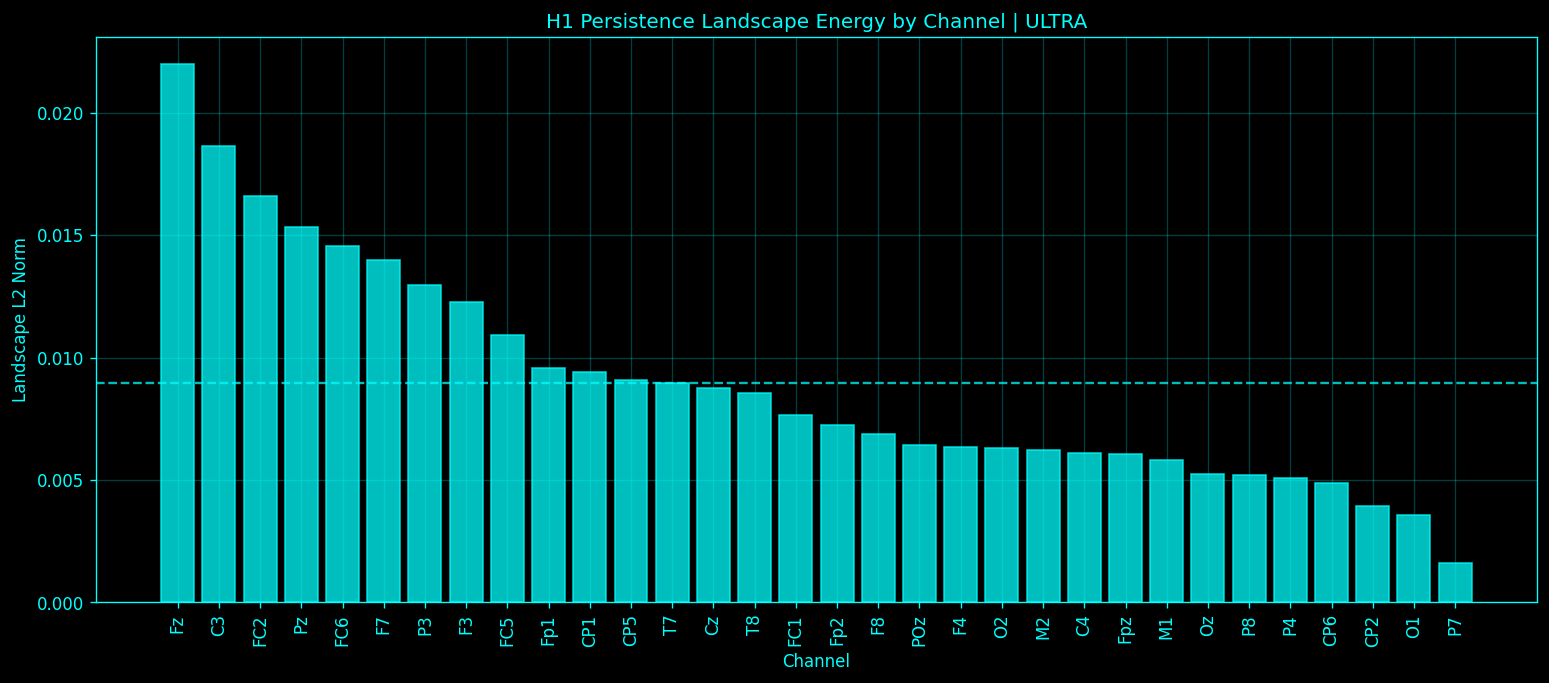

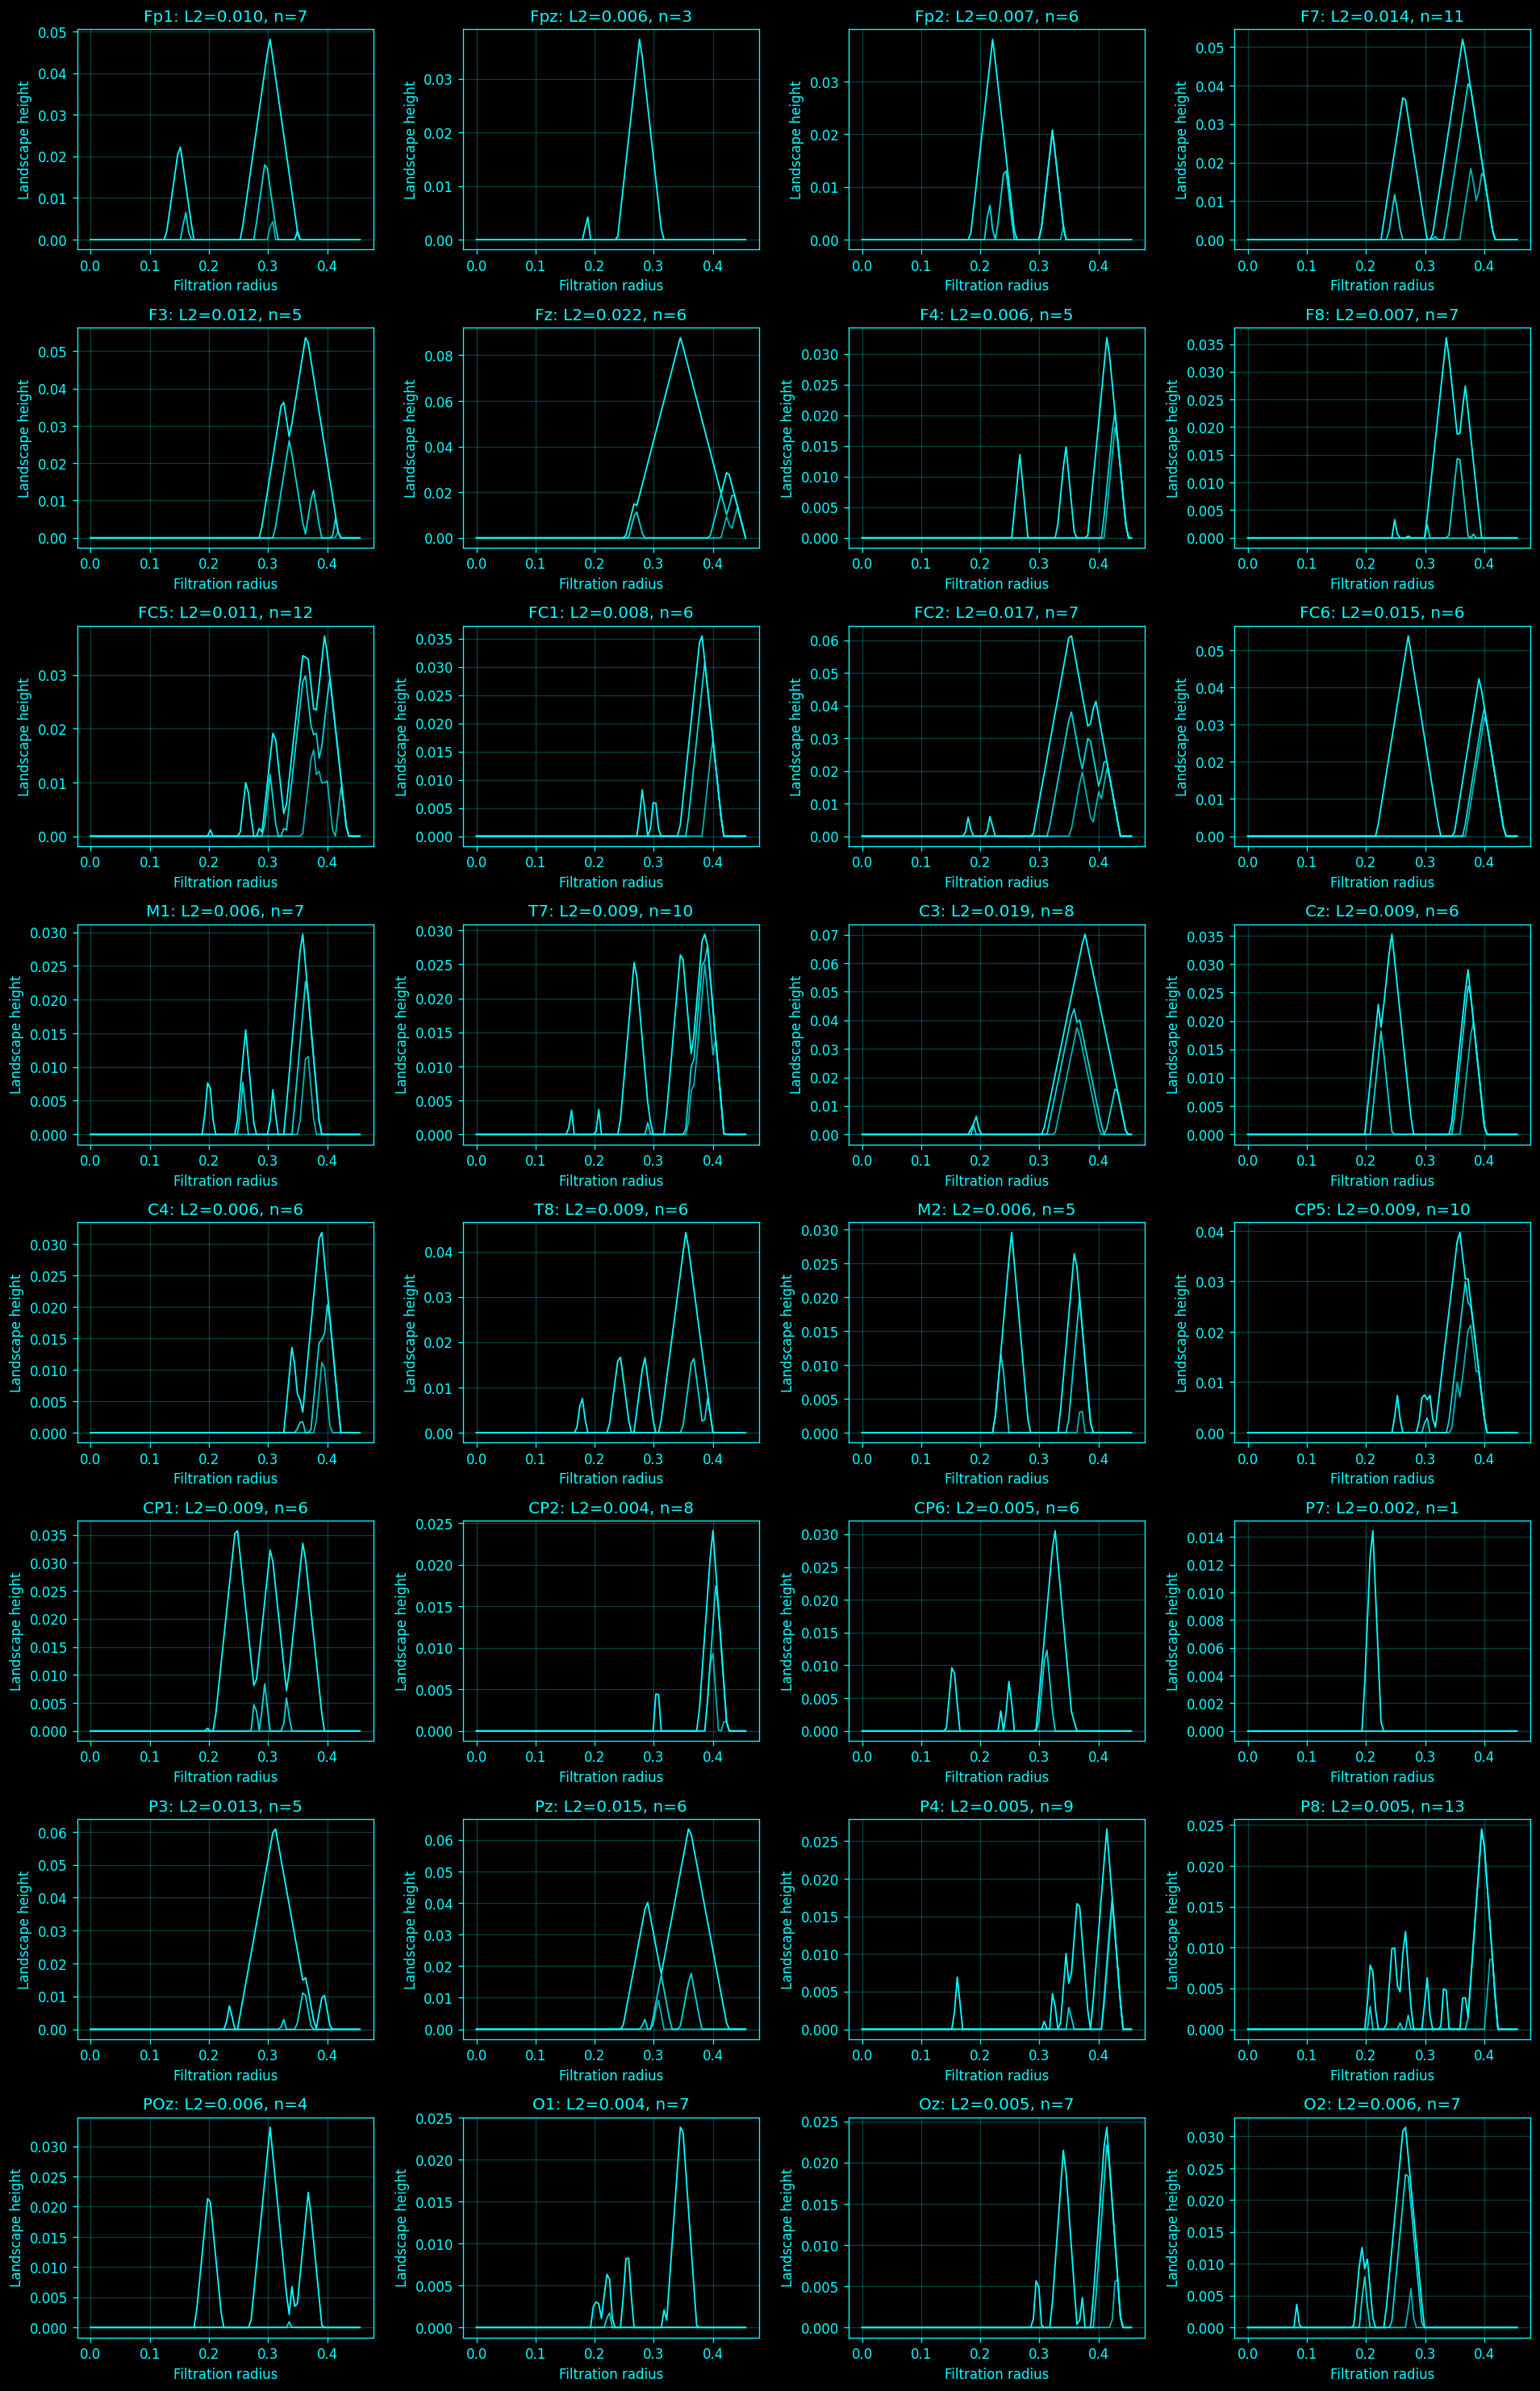

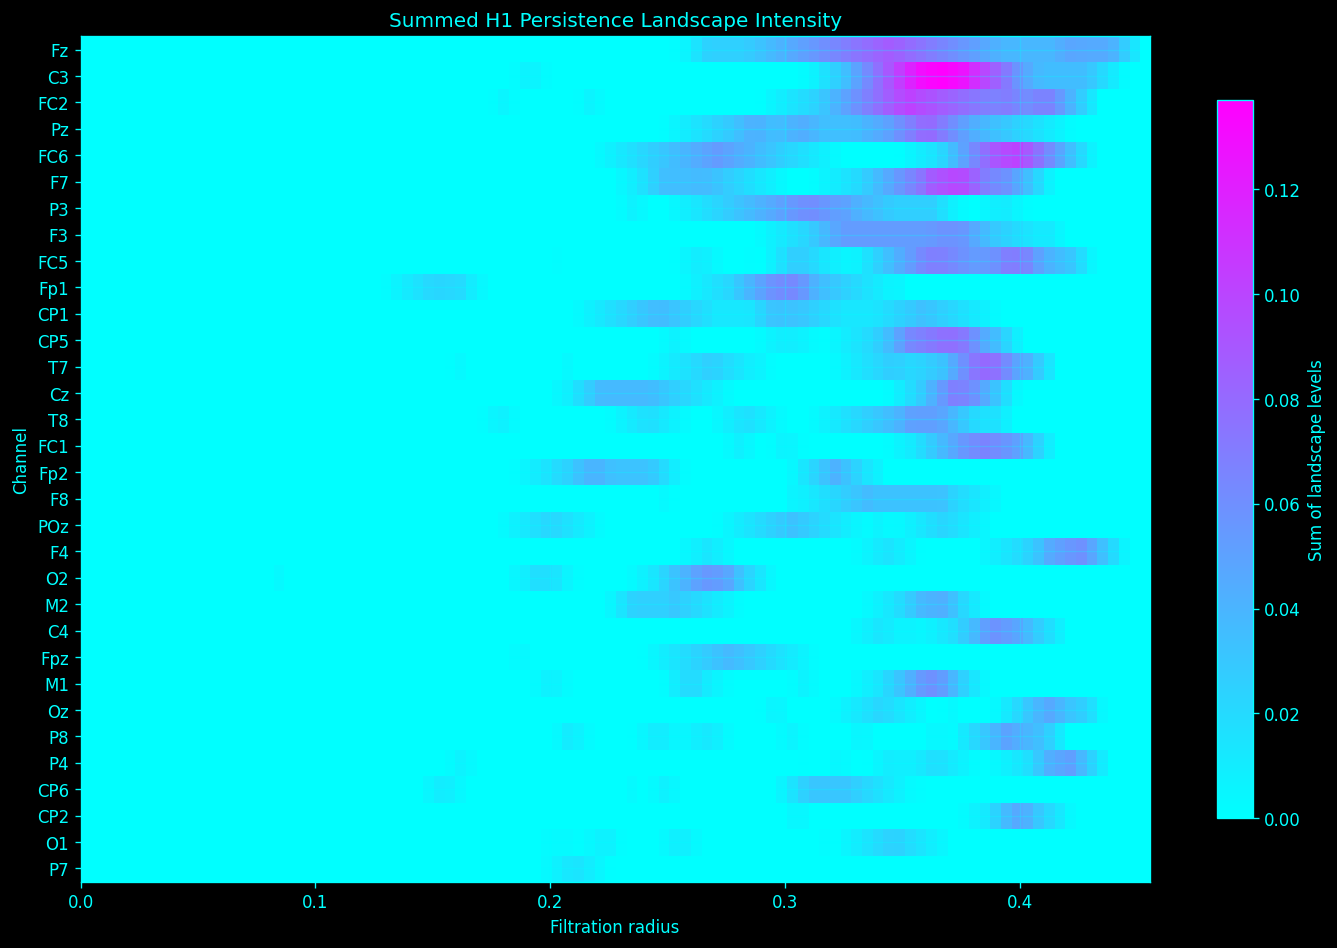

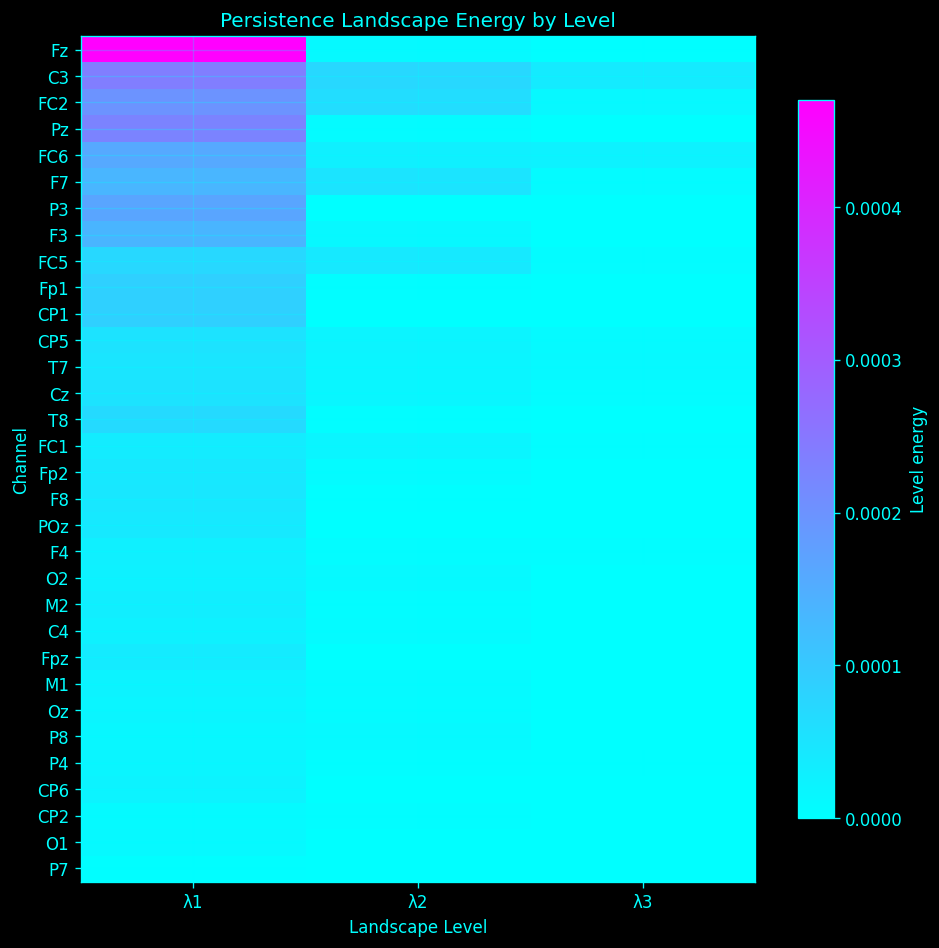

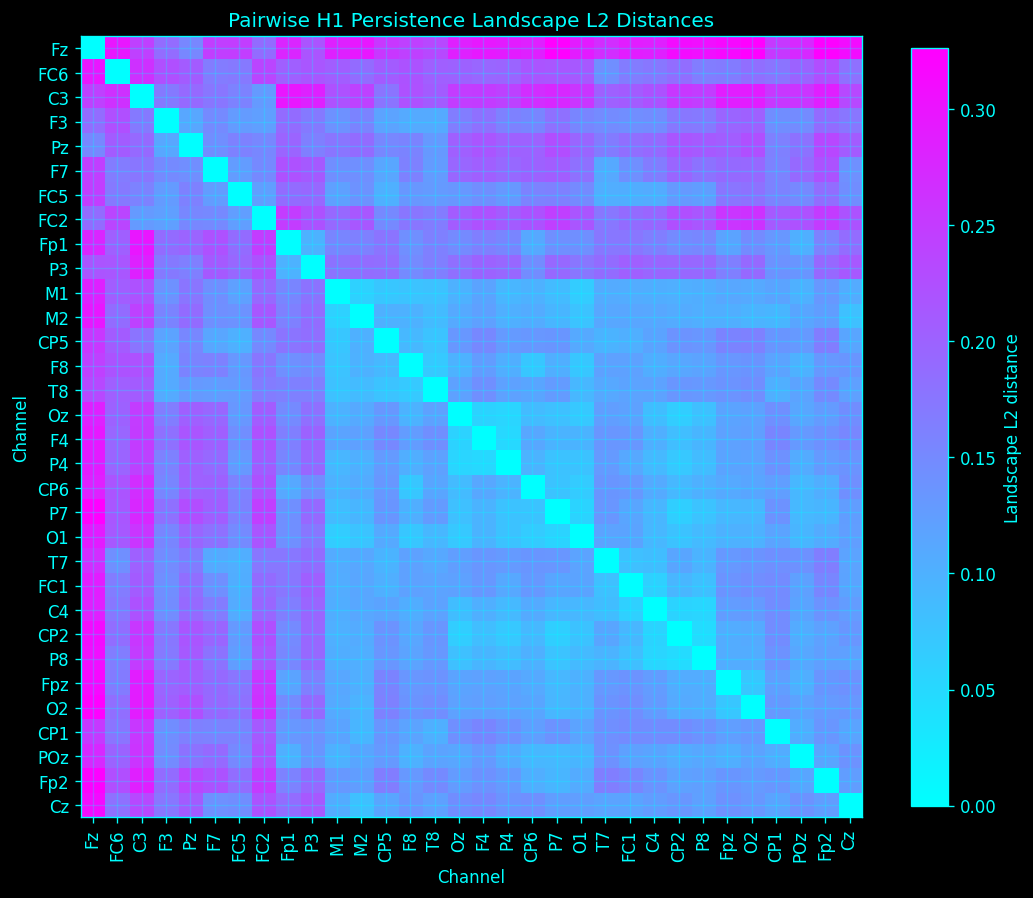

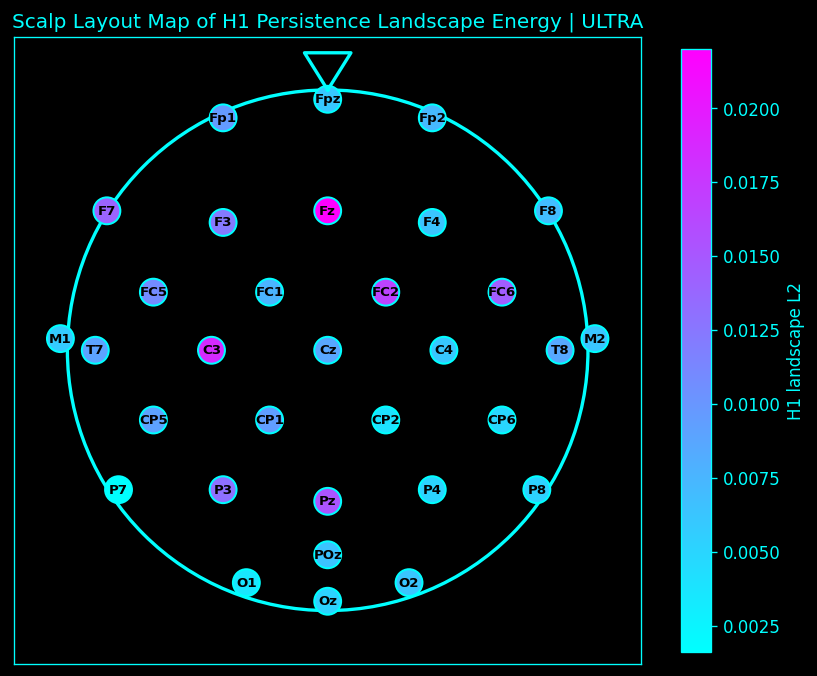

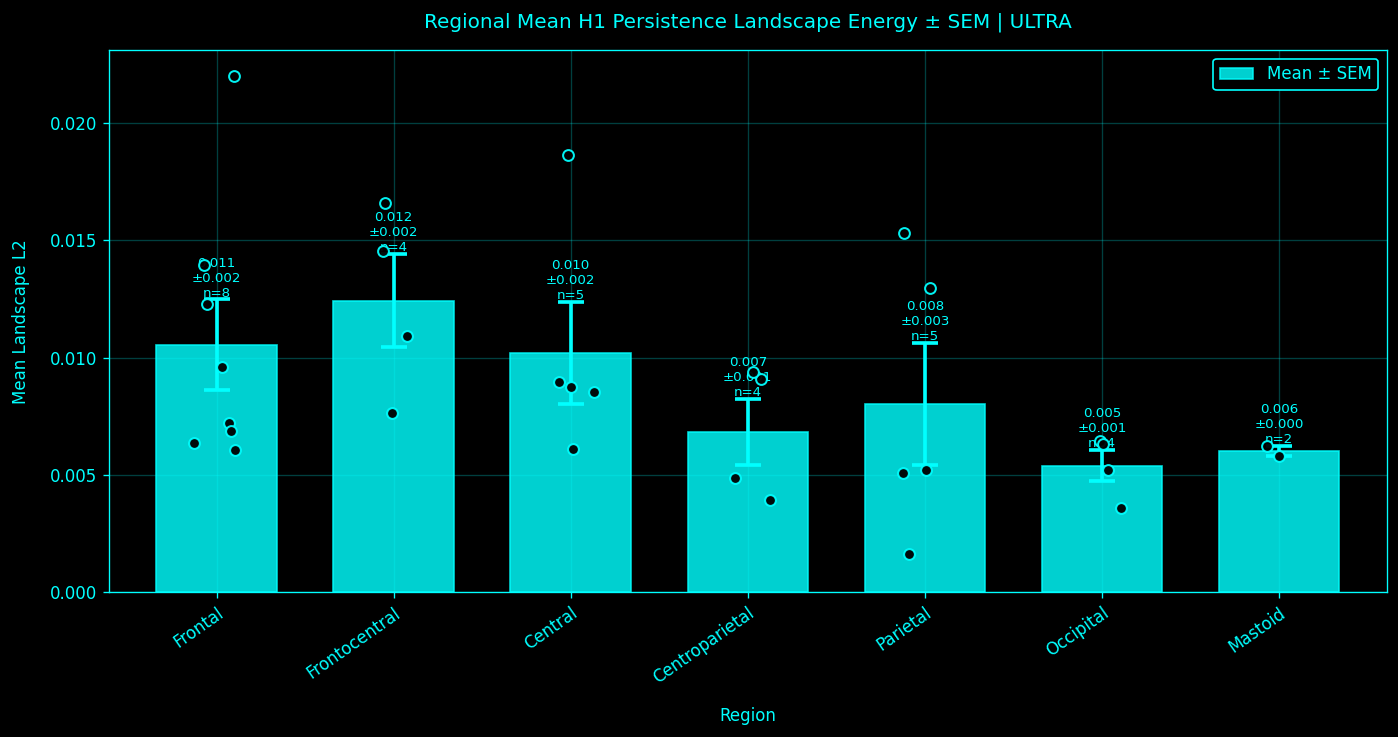

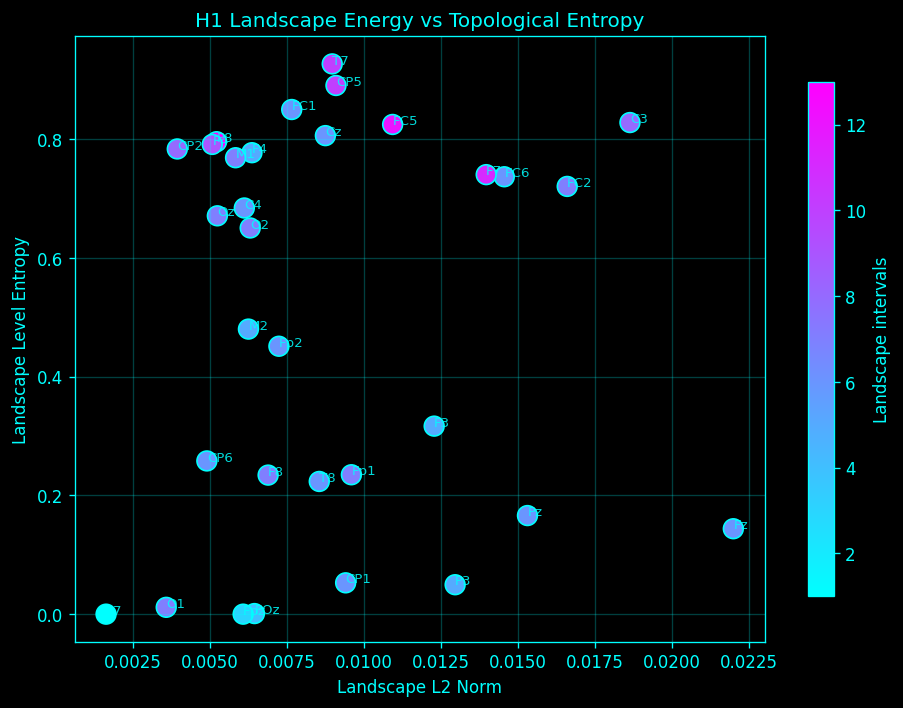

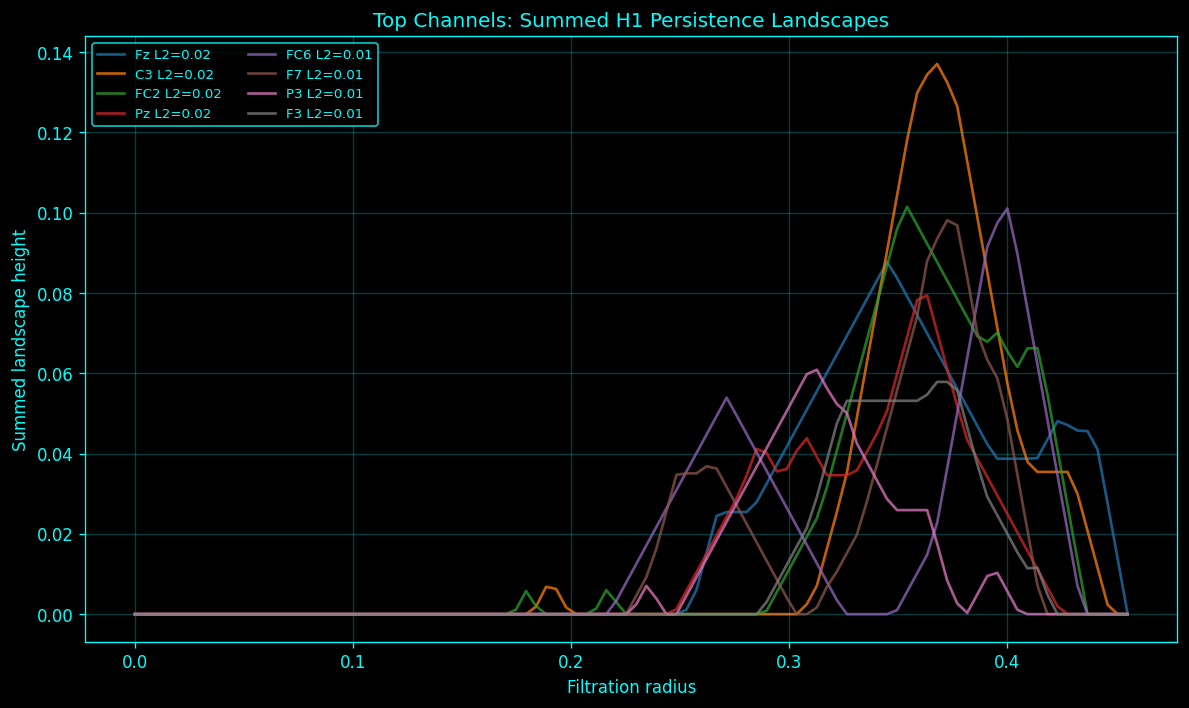

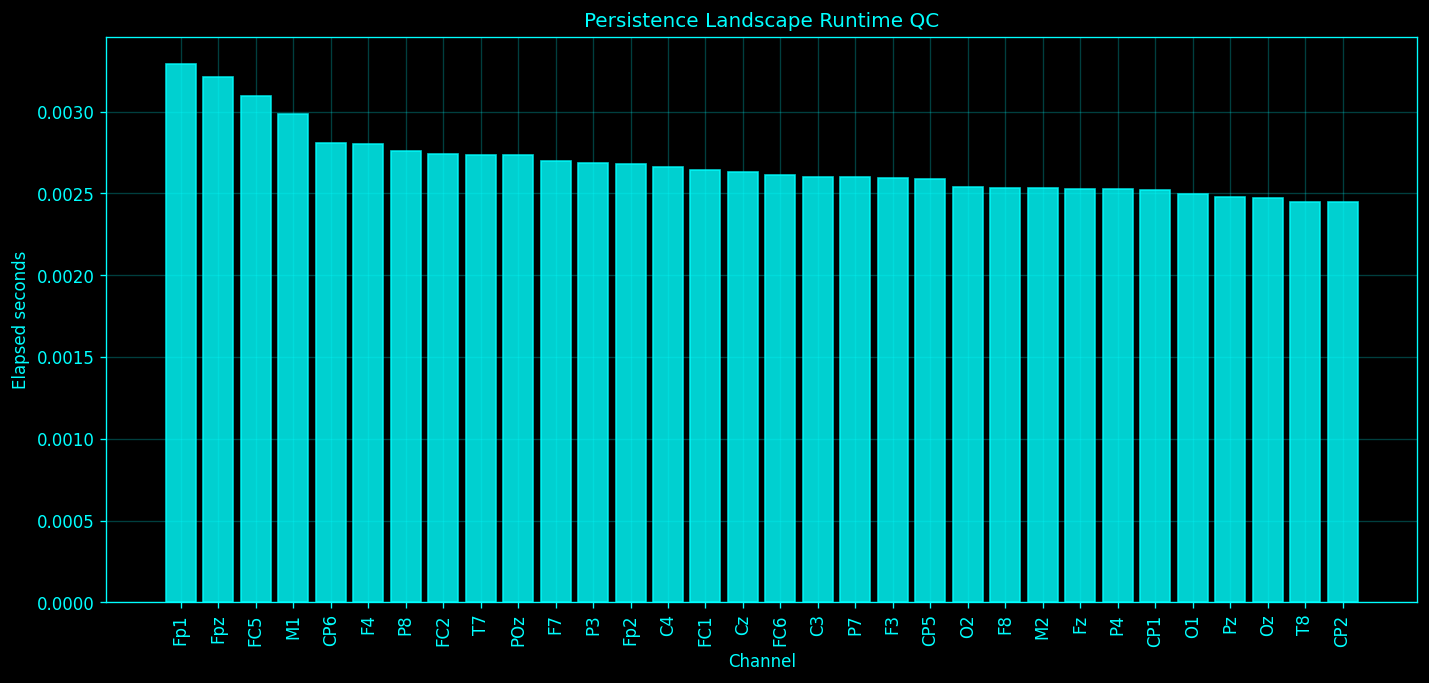

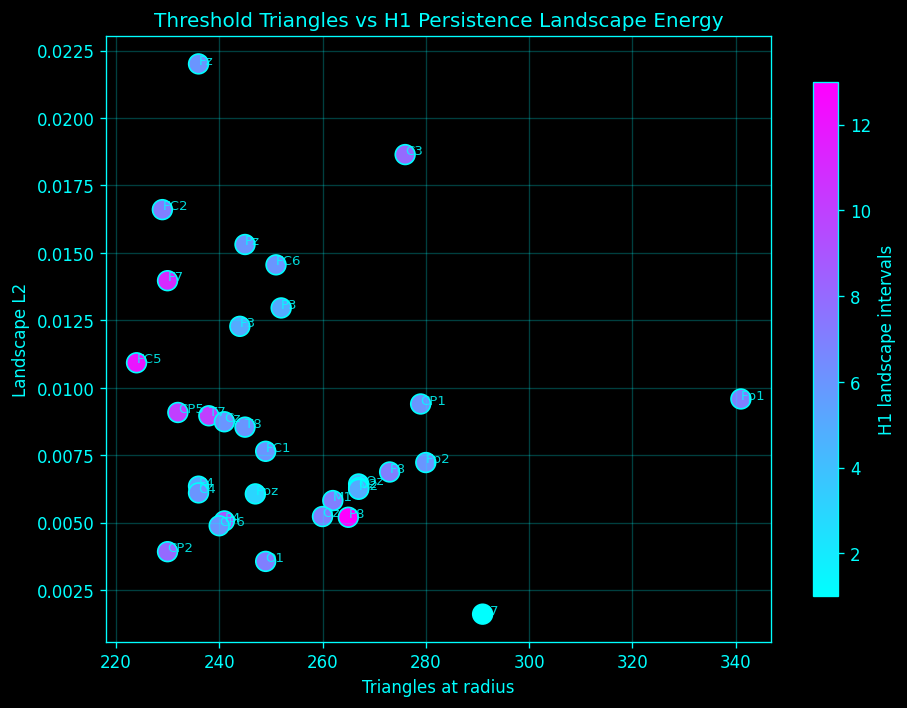


Expert plots saved and rendered from: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_landscapes/h1_persistence_landscapes_ultra_ripser_presampled/expert_plots
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_landscapes/h1_persistence_landscapes_ultra_ripser_presampled/expert_plots/regional_h1_landscape_summary.csv

Finished H1 Persistence Landscapes in 3.78s
Mode: ultra
Backend: ripser_presampled
Channels completed: 32
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_landscapes/h1_persistence_landscapes_ultra_ripser_presampled/persistence_landscape_summary.csv
Landscape NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_landscapes/h1_persistence_landscapes_ultra_ripser_presampled/persistence_landscapes_h1.npz
Pairwise distance CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_landscapes/h1_persistence_landscapes_ultra_ripser_presampled/h1

In [3]:
import os
import sys
import time
import numpy as np
# NumPy compatibility: newer NumPy versions use np.trapezoid instead of np.trapz.
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid
import pandas as pd
import matplotlib.pyplot as plt

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["VECLIB_MAXIMUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

try:
    from IPython.display import display, Image
    HAVE_IPYTHON = True
except Exception:
    HAVE_IPYTHON = False

try:
    from ripser import ripser
except Exception as exc:
    raise ImportError(
        "ripser is not installed. Run this in a separate notebook cell first:\n\n"
        "!pip install ripser persim\n\n"
        "Then rerun this Persistence Landscapes cell."
    ) from exc


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
out_dir = os.path.join(base_dir, "topology_persistence_landscapes")
os.makedirs(out_dir, exist_ok=True)

FAST_OPTION = "ultra"  # options: "ultra", "fast", "balanced", "full"

MAX_CHANNELS_TO_PROCESS = None
RENDER_ALL_IMAGES_INLINE = True
SAVE_PLOTS_TO_DISK = True
MAKE_EXPERT_PLOTS = True
INLINE_IMAGE_WIDTH = 950
VERBOSE_PROGRESS = True

MODE_CONFIGS = {
    "ultra": {
        "max_points": 55,
        "max_dims": 3,
        "radius_quantile": 0.12,
        "landscape_levels": 3,
        "landscape_grid_size": 100,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 8,
        "plot_dpi": 120,
    },
    "fast": {
        "max_points": 90,
        "max_dims": 3,
        "radius_quantile": 0.15,
        "landscape_levels": 4,
        "landscape_grid_size": 160,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 8,
        "plot_dpi": 130,
    },
    "balanced": {
        "max_points": 130,
        "max_dims": 3,
        "radius_quantile": 0.18,
        "landscape_levels": 6,
        "landscape_grid_size": 220,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 10,
        "plot_dpi": 140,
    },
    "full": {
        "max_points": 180,
        "max_dims": 3,
        "radius_quantile": 0.22,
        "landscape_levels": 8,
        "landscape_grid_size": 320,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 12,
        "plot_dpi": 150,
    },
}

if FAST_OPTION not in MODE_CONFIGS:
    raise ValueError("FAST_OPTION must be one of: ultra, fast, balanced, full")

cfg = MODE_CONFIGS[FAST_OPTION]

MAX_POINTS = cfg["max_points"]
MAX_DIMS = cfg["max_dims"]
RADIUS_QUANTILE = cfg["radius_quantile"]
LANDSCAPE_LEVELS = cfg["landscape_levels"]
LANDSCAPE_GRID_SIZE = cfg["landscape_grid_size"]
CAP_ESSENTIAL_H1 = cfg["cap_essential_h1"]
TOP_CHANNELS_TO_OVERLAY = cfg["top_channels_to_overlay"]
PLOT_DPI = cfg["plot_dpi"]

mode_out_dir = os.path.join(out_dir, f"h1_persistence_landscapes_{FAST_OPTION}_ripser_presampled")
os.makedirs(mode_out_dir, exist_ok=True)

eeg_channels = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if MAX_CHANNELS_TO_PROCESS is not None:
    eeg_channels = eeg_channels[:MAX_CHANNELS_TO_PROCESS]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})


def log(msg):
    if VERBOSE_PROGRESS:
        print(msg, flush=True)


def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)


def style_colorbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)


def save_render_close(fig, path, width=INLINE_IMAGE_WIDTH):
    if SAVE_PLOTS_TO_DISK:
        fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight", facecolor=BG)

    plt.close(fig)

    if RENDER_ALL_IMAGES_INLINE and HAVE_IPYTHON and os.path.exists(path):
        display(Image(filename=path, width=width))


def load_channel_embedding_sampled(ch_name, max_points=55, seed=7):
    candidate_paths = [
        os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d", f"umap_embedding_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d", f"tsne_embedding_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "3dembedding_data", f"3dembedded_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "2dembedding_data", f"2dembedded_{ch_name}.npy"),
    ]

    rng = np.random.default_rng(seed)

    for path in candidate_paths:
        if not os.path.exists(path):
            continue

        log(f"    trying: {path}")

        try:
            X = np.load(path, mmap_mode="r", allow_pickle=False)
        except Exception as exc:
            log(f"    skipped non-memmappable or nonnumeric file: {os.path.basename(path)} | {exc}")
            continue

        if X.ndim != 2:
            log(f"    skipped because ndim={X.ndim}")
            continue

        original_shape = tuple(X.shape)

        try:
            if X.shape[0] >= X.shape[1]:
                n_samples = X.shape[0]
                n_features = X.shape[1]

                if n_samples < 10 or n_features < 2:
                    log(f"    skipped bad shape: {original_shape}")
                    continue

                sample_n = min(max_points, n_samples)
                idx = np.sort(rng.choice(n_samples, size=sample_n, replace=False))
                X_small = np.asarray(X[idx, :], dtype=np.float64)

            else:
                n_samples = X.shape[1]
                n_features = X.shape[0]

                if n_samples < 10 or n_features < 2:
                    log(f"    skipped bad transposed shape: {original_shape}")
                    continue

                sample_n = min(max_points, n_samples)
                idx = np.sort(rng.choice(n_samples, size=sample_n, replace=False))
                X_small = np.asarray(X[:, idx].T, dtype=np.float64)

        except Exception as exc:
            log(f"    failed while sampling {os.path.basename(path)} | {exc}")
            continue

        X_small = X_small[np.all(np.isfinite(X_small), axis=1)]

        if X_small.shape[0] >= 10 and X_small.shape[1] >= 2:
            return X_small, path, original_shape

        log(f"    sampled data unusable: sampled_shape={X_small.shape}")

    return None, None, None


def standardize_point_cloud_small(X, max_dims=3):
    X = np.asarray(X, dtype=np.float64)
    X = X[np.all(np.isfinite(X), axis=1)]

    if X.shape[0] < 10:
        return None

    X = X - np.mean(X, axis=0, keepdims=True)

    if X.shape[1] > max_dims:
        _U, _S, Vt = np.linalg.svd(X, full_matrices=False)
        X = X @ Vt[:max_dims].T

    X = X / (np.std(X, axis=0, keepdims=True) + 1e-12)

    D = pdist(X)
    positive = D[D > 0]

    if len(positive) > 0:
        X = X / (np.nanmedian(positive) + 1e-12)

    return X


def estimate_complex_counts(X, radius):
    D = squareform(pdist(X))
    A = (D <= radius) & (D > 0)

    n_edges = int(np.sum(A) // 2)

    if A.shape[0] <= 300:
        A_int = A.astype(np.int64)
        n_triangles = int(np.trace(A_int @ A_int @ A_int) // 6)
    else:
        n_triangles = np.nan

    return n_edges, n_triangles


def run_h1_ripser(X, radius):
    result = ripser(
        X,
        maxdim=1,
        thresh=float(radius),
        coeff=2,
        do_cocycles=False,
    )

    diagrams = result["dgms"]

    h0 = diagrams[0] if len(diagrams) > 0 else np.empty((0, 2), dtype=float)
    h1 = diagrams[1] if len(diagrams) > 1 else np.empty((0, 2), dtype=float)

    return h0, h1


def split_finite_essential(diagram):
    diagram = np.asarray(diagram, dtype=float)

    if diagram.size == 0:
        return np.empty((0, 2), dtype=float), np.empty((0, 2), dtype=float)

    finite = diagram[
        np.isfinite(diagram[:, 0])
        & np.isfinite(diagram[:, 1])
        & (diagram[:, 1] > diagram[:, 0])
    ]

    essential = diagram[
        np.isfinite(diagram[:, 0])
        & np.isinf(diagram[:, 1])
    ]

    return finite, essential


def clean_intervals_for_landscape(
    finite_intervals,
    essential_intervals=None,
    cap_essential=True,
    cap_value=None,
):
    finite = []
    capped_count = 0

    if finite_intervals is not None:
        for b, d in finite_intervals:
            if np.isfinite(b) and np.isfinite(d) and d > b:
                finite.append((float(b), float(d)))

    if cap_essential and essential_intervals is not None and cap_value is not None:
        for b, _d in essential_intervals:
            if np.isfinite(b) and np.isfinite(cap_value) and cap_value > b:
                finite.append((float(b), float(cap_value)))
                capped_count += 1

    if len(finite) == 0:
        return np.empty((0, 2), dtype=float), capped_count

    return np.asarray(finite, dtype=float), capped_count


def persistence_landscape(intervals, grid, n_levels=4):
    intervals = np.asarray(intervals, dtype=float)
    landscapes = np.zeros((n_levels, len(grid)), dtype=float)

    if intervals.size == 0:
        return landscapes

    intervals = intervals[
        np.isfinite(intervals[:, 0])
        & np.isfinite(intervals[:, 1])
        & (intervals[:, 1] > intervals[:, 0])
    ]

    if len(intervals) == 0:
        return landscapes

    b = intervals[:, 0][:, None]
    d = intervals[:, 1][:, None]
    t = grid[None, :]

    tents = np.maximum(0.0, np.minimum(t - b, d - t))
    sorted_vals = np.sort(tents, axis=0)[::-1]

    n_fill = min(n_levels, sorted_vals.shape[0])
    landscapes[:n_fill, :] = sorted_vals[:n_fill, :]

    return landscapes


def landscape_features(landscapes, grid, intervals):
    level_l1 = np.trapz(np.abs(landscapes), grid, axis=1)
    level_l2 = np.sqrt(np.trapz(landscapes ** 2, grid, axis=1))
    level_energy = level_l2 ** 2

    total_l1 = float(np.sum(level_l1))
    total_l2 = float(np.sqrt(np.sum(level_energy)))
    linf = float(np.nanmax(landscapes)) if landscapes.size else 0.0

    if np.sum(level_energy) > 0:
        p = level_energy / np.sum(level_energy)
        entropy = float(-np.sum(p[p > 0] * np.log(p[p > 0])))
        dominant_level = int(np.argmax(level_energy) + 1)
    else:
        entropy = 0.0
        dominant_level = np.nan

    summed_landscape = np.sum(landscapes, axis=0)
    summed_area = np.trapz(summed_landscape, grid)

    if summed_area > 0:
        center_of_mass = float(np.trapz(grid * summed_landscape, grid) / summed_area)
    else:
        center_of_mass = np.nan

    if intervals is not None and len(intervals) > 0:
        lifetimes = intervals[:, 1] - intervals[:, 0]
        mean_lifetime = float(np.nanmean(lifetimes))
        max_lifetime = float(np.nanmax(lifetimes))
        total_lifetime = float(np.nansum(lifetimes))
        n_intervals = int(len(intervals))
    else:
        mean_lifetime = np.nan
        max_lifetime = np.nan
        total_lifetime = 0.0
        n_intervals = 0

    return {
        "landscape_l1": total_l1,
        "landscape_l2": total_l2,
        "landscape_linf": linf,
        "landscape_entropy": entropy,
        "dominant_landscape_level": dominant_level,
        "landscape_center_of_mass": center_of_mass,
        "n_intervals_landscape": n_intervals,
        "mean_lifetime": mean_lifetime,
        "max_lifetime": max_lifetime,
        "total_lifetime": total_lifetime,
    }


log("\n" + "=" * 72)
log(f"Running H1 Persistence Landscapes with ripser backend | {FAST_OPTION.upper()}")
log(f"Channels: {len(eeg_channels)}")
log(f"max_points={MAX_POINTS}, radius_quantile={RADIUS_QUANTILE}")
log(f"landscape_levels={LANDSCAPE_LEVELS}, grid={LANDSCAPE_GRID_SIZE}")
log(f"expert_plots={MAKE_EXPERT_PLOTS}, render_all_images={RENDER_ALL_IMAGES_INLINE}")
log(f"Output: {mode_out_dir}")
log("=" * 72)

rows = []
landscape_store = {}
interval_store = {}
diagnostics = {}
loaded_channels = []

global_t_min = 0.0
global_t_max = None

overall_t0 = time.time()

for ch_idx, ch_name in enumerate(eeg_channels, start=1):
    t0 = time.time()
    prefix = f"[{ch_idx:02d}/{len(eeg_channels)} {ch_name}]"

    log(f"\n{prefix} loading + pre-subsampling to {MAX_POINTS} points")

    X_small, source_path, original_shape = load_channel_embedding_sampled(
        ch_name,
        max_points=MAX_POINTS,
        seed=100 + ch_idx,
    )

    if X_small is None:
        log(f"{prefix} WARNING: no usable embedding found; skipping")
        continue

    log(f"{prefix} source shape={original_shape}, sampled shape={X_small.shape}")

    X = standardize_point_cloud_small(X_small, max_dims=MAX_DIMS)

    if X is None:
        log(f"{prefix} WARNING: invalid sampled embedding; skipping")
        continue

    log(f"{prefix} standardized shape={X.shape}; computing radius")

    D_flat = pdist(X)
    positive = D_flat[D_flat > 0]

    if len(positive) == 0:
        log(f"{prefix} WARNING: zero-distance cloud; skipping")
        continue

    radius = float(np.quantile(positive, RADIUS_QUANTILE))

    log(f"{prefix} estimating threshold complex size")
    n_edges, n_triangles = estimate_complex_counts(X, radius)

    log(f"{prefix} ripser H0/H1")
    h0_diag, h1_diag = run_h1_ripser(X, radius)

    h0_finite, h0_essential = split_finite_essential(h0_diag)
    h1_finite, h1_essential = split_finite_essential(h1_diag)

    h1_intervals, n_capped_h1 = clean_intervals_for_landscape(
        h1_finite,
        essential_intervals=h1_essential,
        cap_essential=CAP_ESSENTIAL_H1,
        cap_value=radius,
    )

    elapsed = time.time() - t0

    interval_store[ch_name] = {
        "H0_finite": h0_finite,
        "H0_essential": h0_essential,
        "H1_finite": h1_finite,
        "H1_essential": h1_essential,
        "H1_landscape": h1_intervals,
    }

    diagnostics[ch_name] = {
        "channel": ch_name,
        "source_path": source_path,
        "source_shape": str(original_shape),
        "backend": "ripser",
        "n_points": int(X.shape[0]),
        "n_edges_at_radius": int(n_edges),
        "n_triangles_at_radius": int(n_triangles) if np.isfinite(n_triangles) else np.nan,
        "radius": radius,
        "n_h0_finite": int(len(h0_finite)),
        "n_h1_finite": int(len(h1_finite)),
        "n_h1_essential": int(len(h1_essential)),
        "n_h1_capped_for_landscape": int(n_capped_h1),
        "n_h1_landscape_intervals": int(len(h1_intervals)),
        "elapsed_sec": elapsed,
    }

    if len(h1_intervals) > 0:
        max_death = np.nanmax(h1_intervals[:, 1])
        global_t_max = max_death if global_t_max is None else max(global_t_max, max_death)

    loaded_channels.append(ch_name)

    log(
        f"{prefix} done {elapsed:.2f}s | "
        f"edges={n_edges}, triangles={n_triangles}, "
        f"H1 finite={len(h1_finite)}, H1 landscape={len(h1_intervals)}"
    )

if len(loaded_channels) == 0:
    raise RuntimeError("No usable embeddings found. Check embedding_data paths.")

if global_t_max is None or not np.isfinite(global_t_max) or global_t_max <= 0:
    global_t_max = 1.0

log("\nBuilding landscapes")
landscape_grid = np.linspace(global_t_min, global_t_max, LANDSCAPE_GRID_SIZE)

for ch_name in loaded_channels:
    h1_intervals = interval_store[ch_name]["H1_landscape"]

    landscapes = persistence_landscape(
        h1_intervals,
        landscape_grid,
        n_levels=LANDSCAPE_LEVELS,
    )

    landscape_store[ch_name] = landscapes

    rows.append({
        **diagnostics[ch_name],
        **landscape_features(landscapes, landscape_grid, h1_intervals),
    })

results_df = (
    pd.DataFrame(rows)
    .sort_values("landscape_l2", ascending=False)
    .reset_index(drop=True)
)

csv_path = os.path.join(mode_out_dir, "persistence_landscape_summary.csv")
results_df.to_csv(csv_path, index=False)

npz_path = os.path.join(mode_out_dir, "persistence_landscapes_h1.npz")

save_dict = {
    "channels": np.asarray(loaded_channels),
    "landscape_grid": landscape_grid,
    "fast_option": np.asarray([FAST_OPTION]),
    "backend": np.asarray(["ripser_presampled"]),
}

for ch_name in loaded_channels:
    save_dict[f"{ch_name}_landscape"] = landscape_store[ch_name]

    for key, val in interval_store[ch_name].items():
        save_dict[f"{ch_name}_{key}"] = val

np.savez(npz_path, **save_dict)

print("\nPersistence Landscape Summary:")
if HAVE_IPYTHON:
    display(results_df)
else:
    print(results_df)

log(f"\nSaved summary CSV: {csv_path}")
log(f"Saved landscape NPZ: {npz_path}")

plot_df = results_df.copy().sort_values("landscape_l2", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax)

x_pos = np.arange(len(plot_df))
y = plot_df["landscape_l2"].to_numpy(dtype=float)

ax.bar(x_pos, y, color=ACCENT, edgecolor=ACCENT, alpha=0.75)

if np.any(np.isfinite(y)):
    ax.axhline(np.nanmean(y), color=ACCENT, linestyle="--", linewidth=1.4, alpha=0.75)

ax.set_title(f"H1 Persistence Landscape Energy by Channel | {FAST_OPTION.upper()}")
ax.set_xlabel("Channel")
ax.set_ylabel("Landscape L2 Norm")
ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["channel"], rotation=90)

ranking_path = os.path.join(mode_out_dir, "01_h1_landscape_l2_ranking.png")
plt.tight_layout()
save_render_close(fig, ranking_path)

n_cols = 4
n_rows = int(np.ceil(len(loaded_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.1 * n_rows),
    facecolor=BG,
)

axes = np.asarray(axes).reshape(-1)

for ax_idx, ch_name in enumerate(loaded_channels):
    ax = axes[ax_idx]
    style_ax(ax)

    L = landscape_store[ch_name]
    l2_val = results_df.loc[results_df["channel"] == ch_name, "landscape_l2"].values[0]
    n_intervals = results_df.loc[results_df["channel"] == ch_name, "n_intervals_landscape"].values[0]

    for level_idx in range(L.shape[0]):
        alpha = max(0.25, 1.0 - level_idx * 0.15)
        ax.plot(landscape_grid, L[level_idx], color=ACCENT, linewidth=1.1, alpha=alpha)

    ax.set_title(f"{ch_name}: L2={l2_val:.3f}, n={int(n_intervals)}")
    ax.set_xlabel("Filtration radius")
    ax.set_ylabel("Landscape height")

for j in range(len(loaded_channels), len(axes)):
    axes[j].axis("off")

all_landscapes_path = os.path.join(mode_out_dir, "02_all_channels_h1_persistence_landscapes.png")
plt.tight_layout()
save_render_close(fig, all_landscapes_path, width=1100)

heat_channels = plot_df["channel"].tolist()

landscape_intensity = np.asarray([
    np.sum(landscape_store[ch_name], axis=0)
    for ch_name in heat_channels
], dtype=float)

fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    landscape_intensity,
    aspect="auto",
    interpolation="nearest",
    cmap="cool",
    extent=[
        landscape_grid[0],
        landscape_grid[-1],
        len(heat_channels) - 0.5,
        -0.5,
    ],
)

ax.set_title("Summed H1 Persistence Landscape Intensity")
ax.set_xlabel("Filtration radius")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(heat_channels)))
ax.set_yticklabels(heat_channels)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Sum of landscape levels")

heatmap_path = os.path.join(mode_out_dir, "03_h1_landscape_intensity_heatmap.png")
plt.tight_layout()
save_render_close(fig, heatmap_path)

level_energy_matrix = np.asarray([
    np.trapz(landscape_store[ch_name] ** 2, landscape_grid, axis=1)
    for ch_name in heat_channels
], dtype=float)

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    level_energy_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap="cool",
)

ax.set_title("Persistence Landscape Energy by Level")
ax.set_xlabel("Landscape Level")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(LANDSCAPE_LEVELS))
ax.set_xticklabels([f"λ{i + 1}" for i in range(LANDSCAPE_LEVELS)])
ax.set_yticks(np.arange(len(heat_channels)))
ax.set_yticklabels(heat_channels)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Level energy")

level_energy_path = os.path.join(mode_out_dir, "04_landscape_level_energy_heatmap.png")
plt.tight_layout()
save_render_close(fig, level_energy_path)

channels_for_dist = loaded_channels
n_ch = len(channels_for_dist)

flat_landscapes = np.asarray([
    landscape_store[ch].reshape(-1)
    for ch in channels_for_dist
], dtype=float)

dist_mat = np.zeros((n_ch, n_ch), dtype=float)

for i in range(n_ch):
    for j in range(i + 1, n_ch):
        dist = float(np.linalg.norm(flat_landscapes[i] - flat_landscapes[j]))
        dist_mat[i, j] = dist
        dist_mat[j, i] = dist

dist_csv_path = os.path.join(mode_out_dir, "h1_landscape_pairwise_l2_distance.csv")
pd.DataFrame(dist_mat, index=channels_for_dist, columns=channels_for_dist).to_csv(dist_csv_path)

if n_ch >= 3 and np.any(dist_mat > 0):
    condensed = dist_mat[np.triu_indices(n_ch, k=1)]
    Z = linkage(condensed, method="average")
    order = leaves_list(Z)
else:
    order = np.arange(n_ch)

ordered_dist = dist_mat[np.ix_(order, order)]
ordered_channels = [channels_for_dist[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    ordered_dist,
    aspect="equal",
    interpolation="nearest",
    cmap="cool",
)

ax.set_title("Pairwise H1 Persistence Landscape L2 Distances")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(n_ch))
ax.set_xticklabels(ordered_channels, rotation=90)
ax.set_yticks(np.arange(n_ch))
ax.set_yticklabels(ordered_channels)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Landscape L2 distance")

dist_path = os.path.join(mode_out_dir, "05_h1_landscape_pairwise_distance_heatmap.png")
plt.tight_layout()
save_render_close(fig, dist_path)

if MAKE_EXPERT_PLOTS:
    expert_dir = os.path.join(mode_out_dir, "expert_plots")
    os.makedirs(expert_dir, exist_ok=True)

    landscape_l2_map = dict(zip(results_df["channel"], results_df["landscape_l2"]))

    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),
        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),
        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),
        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),
        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),
        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in landscape_l2_map and np.isfinite(landscape_l2_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(landscape_l2_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG)
    style_ax(ax)

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)
    ax.plot([0.00, -0.10, 0.10, 0.00], [1.12, 1.28, 1.28, 1.12], color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.2,
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BG,
            fontweight="bold",
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    style_colorbar(cbar, "H1 landscape L2")

    ax.set_title(f"Scalp Layout Map of H1 Persistence Landscape Energy | {FAST_OPTION.upper()}")
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "06_h1_landscape_scalp_map.png")
    plt.tight_layout()
    save_render_close(fig, scalp_path, width=760)

    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in landscape_l2_map and np.isfinite(landscape_l2_map[ch]):
                vals_region.append(landscape_l2_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "landscape_l2": landscape_l2_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_landscape_l2": float(np.mean(vals_region)),
            "std_landscape_l2": float(np.std(vals_region, ddof=1)) if len(vals_region) > 1 else 0.0,
            "sem_landscape_l2": (
                float(np.std(vals_region, ddof=1) / np.sqrt(len(vals_region)))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": int(len(vals_region)),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_h1_landscape_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
    style_ax(ax)

    x_region = np.arange(len(region_df))

    ax.bar(
        x_region,
        region_df["mean_landscape_l2"],
        yerr=region_df["sem_landscape_l2"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
        width=0.68,
        capsize=8,
        error_kw={
            "elinewidth": 2.2,
            "capthick": 2.2,
            "ecolor": ACCENT,
            "alpha": 1.0,
        },
        label="Mean ± SEM",
    )

    rng = np.random.default_rng(7)

    for i, region_name in enumerate(region_df["region"]):
        vals = region_points_df.loc[
            region_points_df["region"] == region_name,
            "landscape_l2",
        ].to_numpy(dtype=float)

        jitter = rng.uniform(-0.13, 0.13, size=len(vals))

        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=42,
            facecolors=BG,
            edgecolors=ACCENT,
            linewidths=1.2,
            alpha=0.95,
            zorder=4,
        )

    for i, row in region_df.iterrows():
        y_val = row["mean_landscape_l2"]
        sem = row["sem_landscape_l2"]

        ax.text(
            i,
            y_val + sem,
            f"{y_val:.3f}\n±{sem:.3f}\nn={int(row['n_channels'])}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=ACCENT,
        )

    ax.set_title(f"Regional Mean H1 Persistence Landscape Energy ± SEM | {FAST_OPTION.upper()}", pad=14)
    ax.set_xlabel("Region", labelpad=12)
    ax.set_ylabel("Mean Landscape L2", labelpad=12)
    ax.set_xticks(x_region)
    ax.set_xticklabels(region_df["region"], rotation=35, ha="right", rotation_mode="anchor")
    ax.margins(x=0.04)
    ax.legend(loc="best", framealpha=1.0)

    region_path = os.path.join(expert_dir, "07_regional_h1_landscape_summary.png")
    plt.tight_layout(pad=2.0)
    save_render_close(fig, region_path)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        results_df["landscape_l2"],
        results_df["landscape_entropy"],
        c=results_df["n_intervals_landscape"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0,
    )

    for _, row in results_df.iterrows():
        if np.isfinite(row["landscape_l2"]) and np.isfinite(row["landscape_entropy"]):
            ax.text(
                row["landscape_l2"],
                row["landscape_entropy"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85,
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    style_colorbar(cbar, "Landscape intervals")

    ax.set_title("H1 Landscape Energy vs Topological Entropy")
    ax.set_xlabel("Landscape L2 Norm")
    ax.set_ylabel("Landscape Level Entropy")

    entropy_path = os.path.join(expert_dir, "08_landscape_energy_vs_entropy.png")
    plt.tight_layout()
    save_render_close(fig, entropy_path)

    top_channels = results_df.head(min(TOP_CHANNELS_TO_OVERLAY, len(results_df)))["channel"].tolist()

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
    style_ax(ax)

    for ch_name in top_channels:
        L_sum = np.sum(landscape_store[ch_name], axis=0)
        l2_val = landscape_l2_map[ch_name]

        ax.plot(
            landscape_grid,
            L_sum,
            linewidth=1.6,
            alpha=0.75,
            label=f"{ch_name} L2={l2_val:.2f}",
        )

    ax.set_title("Top Channels: Summed H1 Persistence Landscapes")
    ax.set_xlabel("Filtration radius")
    ax.set_ylabel("Summed landscape height")
    ax.legend(fontsize=8, ncol=2)

    top_path = os.path.join(expert_dir, "09_top_channels_summed_landscapes.png")
    plt.tight_layout()
    save_render_close(fig, top_path)

    qc_df = results_df.copy().sort_values("elapsed_sec", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 5.8), facecolor=BG)
    style_ax(ax)

    x_qc = np.arange(len(qc_df))

    ax.bar(
        x_qc,
        qc_df["elapsed_sec"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
    )

    ax.set_title("Persistence Landscape Runtime QC")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Elapsed seconds")
    ax.set_xticks(x_qc)
    ax.set_xticklabels(qc_df["channel"], rotation=90)

    qc_path = os.path.join(expert_dir, "10_runtime_qc.png")
    plt.tight_layout()
    save_render_close(fig, qc_path)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)
    
    sc = ax.scatter(
        results_df["n_triangles_at_radius"],
        results_df["landscape_l2"],
        c=results_df["n_h1_landscape_intervals"],
        s=140,
        cmap="cool",
        edgecolor=ACCENT,
        linewidth=1.0,
    )
    
    for _, row in results_df.iterrows():
        ax.text(
            row["n_triangles_at_radius"],
            row["landscape_l2"],
            row["channel"],
            fontsize=8,
            color=ACCENT,
            alpha=0.85,
        )
    
    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    style_colorbar(cbar, "H1 landscape intervals")
    
    ax.set_title("Threshold Triangles vs H1 Persistence Landscape Energy")
    ax.set_xlabel("Triangles at radius")
    ax.set_ylabel("Landscape L2")
    
    size_qc_path = os.path.join(expert_dir, "11_threshold_triangles_vs_landscape_energy.png")
    plt.tight_layout()
    save_render_close(fig, size_qc_path)

    log(f"\nExpert plots saved and rendered from: {expert_dir}")
    log(f"Regional summary CSV: {region_csv_path}")

elapsed_total = time.time() - overall_t0

log("\n" + "=" * 72)
log(f"Finished H1 Persistence Landscapes in {elapsed_total:.2f}s")
log(f"Mode: {FAST_OPTION}")
log(f"Backend: ripser_presampled")
log(f"Channels completed: {len(loaded_channels)}")
log(f"Summary CSV: {csv_path}")
log(f"Landscape NPZ: {npz_path}")
log(f"Pairwise distance CSV: {dist_csv_path}")
log(f"Output directory: {mode_out_dir}")
log("=" * 72)


Running H1 Persistence Images with ripser backend | ULTRA
Channels: 32
max_points=55, radius_quantile=0.12
image bins=48 x 48
sigma_frac=0.035, weight_power=1.0
expert_plots=True, render_all_images=True
Output: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_images/h1_persistence_images_ultra_ripser_presampled

[01/32 Fp1] loading + pre-subsampling to 55 points
    trying: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/tsne_umap_from_3d/umap_embedding_Fp1.npy
[01/32 Fp1] source shape=(106936, 2), sampled shape=(55, 2)
[01/32 Fp1] standardized shape=(55, 2); computing radius
[01/32 Fp1] estimating threshold complex size
[01/32 Fp1] ripser H0/H1
[01/32 Fp1] done 0.07s | edges=179, triangles=220, H1 finite=4, H1 image intervals=6

[02/32 Fpz] loading + pre-subsampling to 55 points
    trying: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/tsne_umap_from_3d/umap_embedding_Fpz.npy
[02/32 Fpz] source shape=(106936, 2), sampled shape=(5

,channel,source_path,source_shape,backend,n_points,n_edges_at_radius,n_triangles_at_radius,radius,n_h0_finite,n_h1_finite,...,image_linf,image_entropy,image_center_birth,image_center_persistence,image_peak_birth,image_peak_persistence,n_intervals_image,mean_persistence,max_persistence,total_persistence
0,Cz,/home/a/projects/Complete-Neural-Signal-Analys...,"(106940, 2)",ripser_presampled,55,179,222,0.428920,53,8,...,0.151283,5.409710,0.334551,0.073316,0.341827,0.084532,12,0.047941,0.104519,0.575288
1,CP1,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,264,0.417338,53,2,...,0.156191,4.918078,0.283292,0.102622,0.321720,0.099234,4,0.096635,0.129348,0.386540
2,F4,/home/a/projects/Complete-Neural-Signal-Analys...,"(106938, 2)",ripser_presampled,55,179,237,0.434332,54,4,...,0.116210,5.150372,0.306539,0.078936,0.301612,0.058805,5,0.075018,0.106796,0.375090
3,P8,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,258,0.397423,54,5,...,0.102452,5.174126,0.315380,0.058003,0.331774,0.058805,9,0.038823,0.085973,0.349409
4,Fpz,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,226,0.411882,53,4,...,0.157848,5.263490,0.321852,0.058390,0.331774,0.080857,8,0.040399,0.082802,0.323192
5,P3,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,236,0.448107,53,4,...,0.112755,5.335504,0.364706,0.068936,0.331774,0.113935,8,0.046350,0.113941,0.370804
6,T7,/home/a/projects/Complete-Neural-Signal-Analys...,"(106940, 2)",ripser_presampled,55,179,266,0.428021,54,3,...,0.152663,5.028752,0.283854,0.105330,0.271451,0.154363,5,0.055854,0.154232,0.279272
7,F8,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,250,0.423237,54,9,...,0.094756,5.499048,0.320900,0.063165,0.321720,0.095558,9,0.042164,0.095972,0.379477
8,C3,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,274,0.420034,53,5,...,0.103424,5.418260,0.315356,0.053002,0.351881,0.066156,9,0.038534,0.079596,0.346807
9,M2,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,241,0.404072,53,4,...,0.101767,5.506309,0.283101,0.068113,0.211129,0.102909,7,0.053232,0.102327,0.372626



Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_images/h1_persistence_images_ultra_ripser_presampled/persistence_image_summary.csv
Saved persistence image NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_images/h1_persistence_images_ultra_ripser_presampled/persistence_images_h1.npz


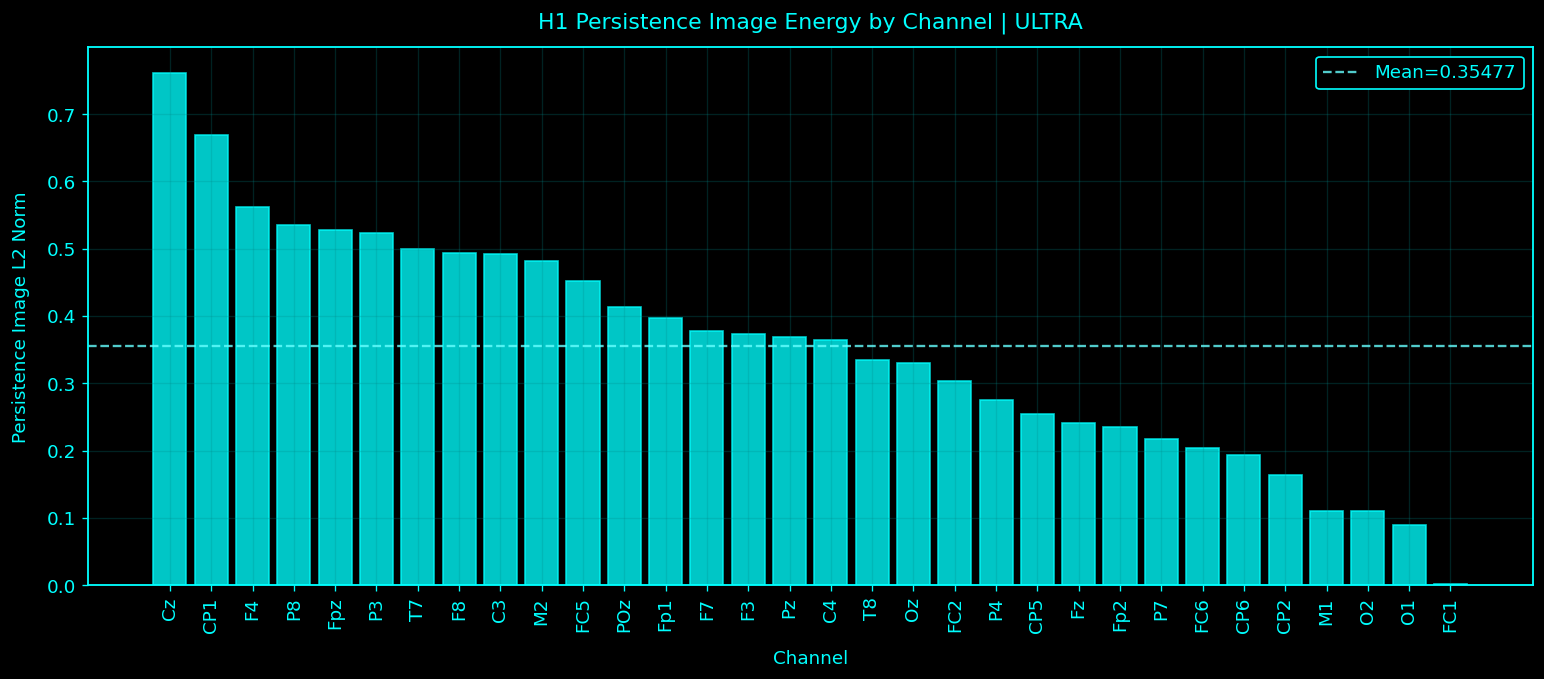

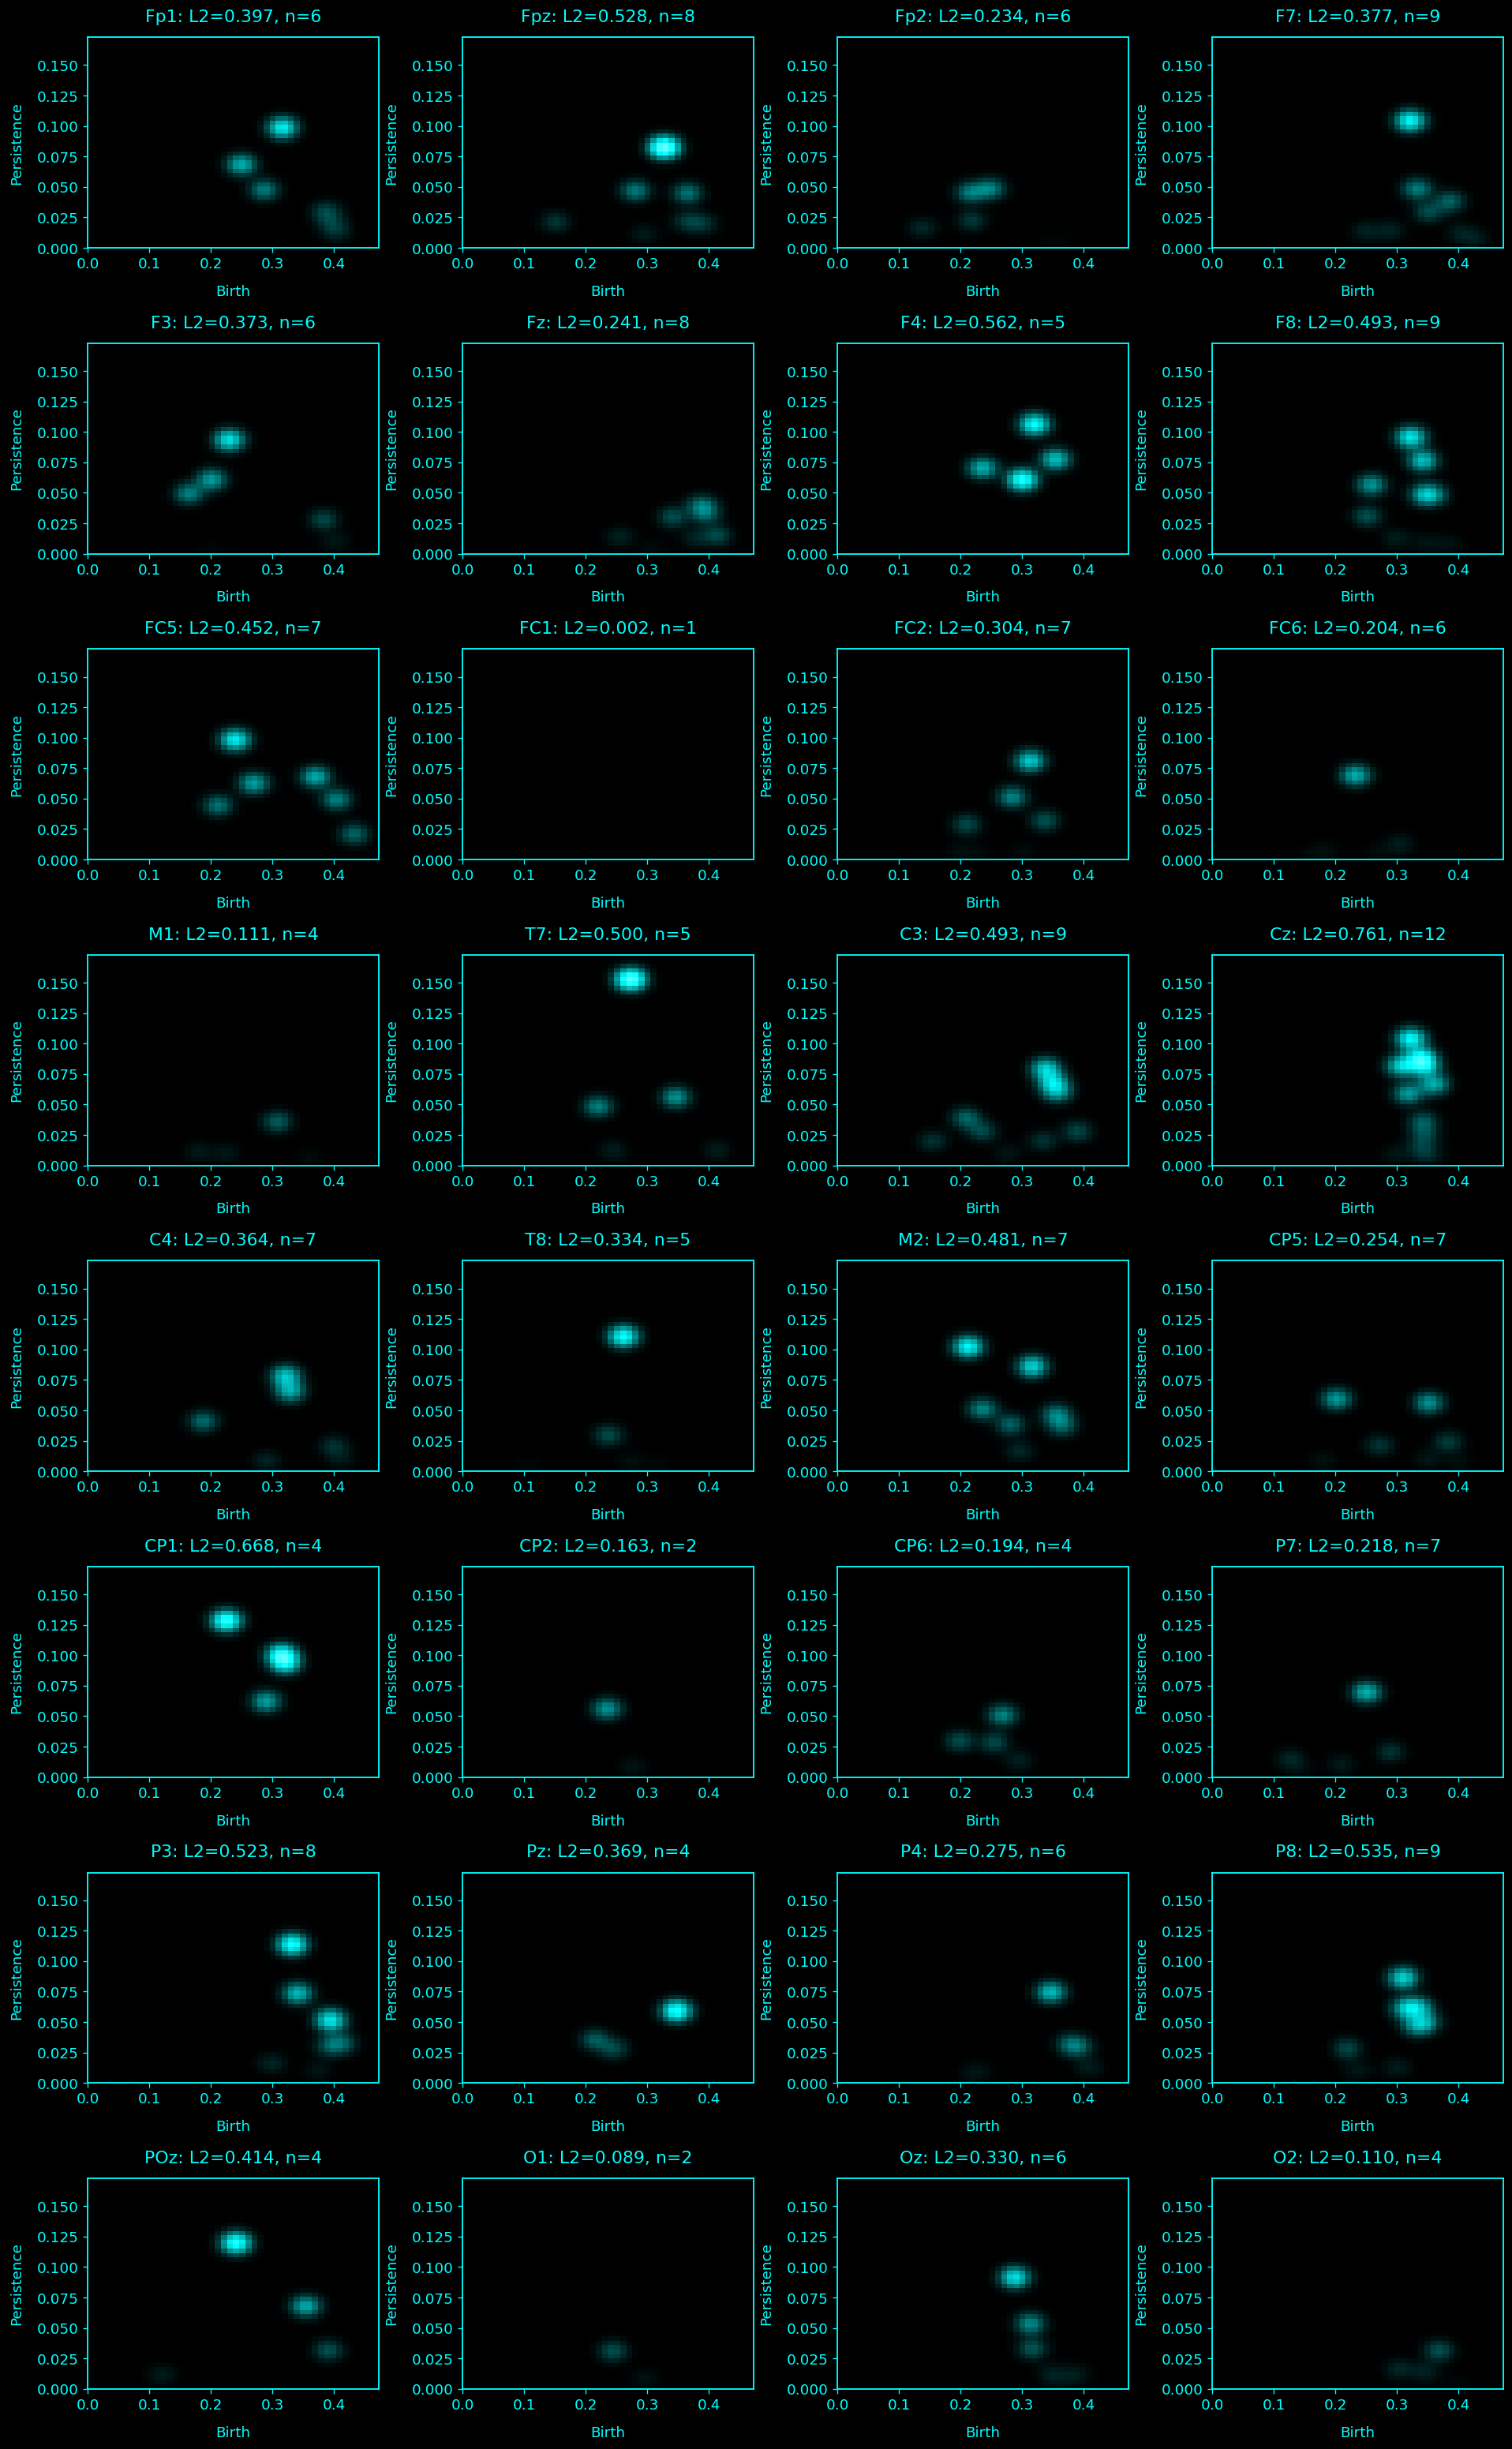

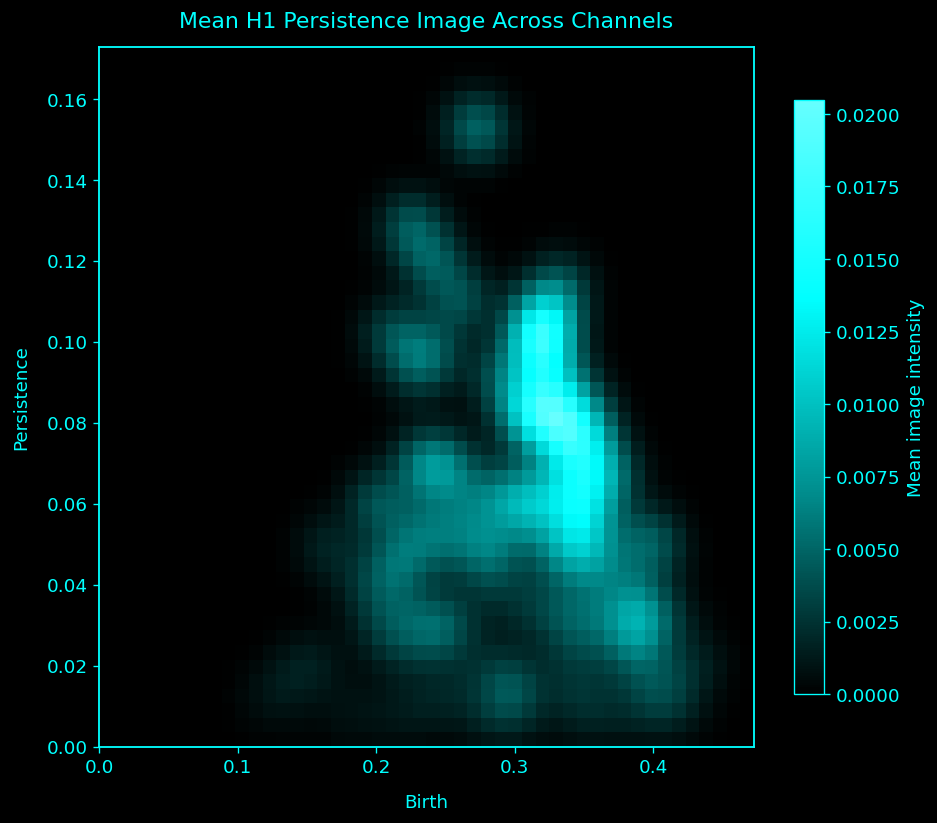

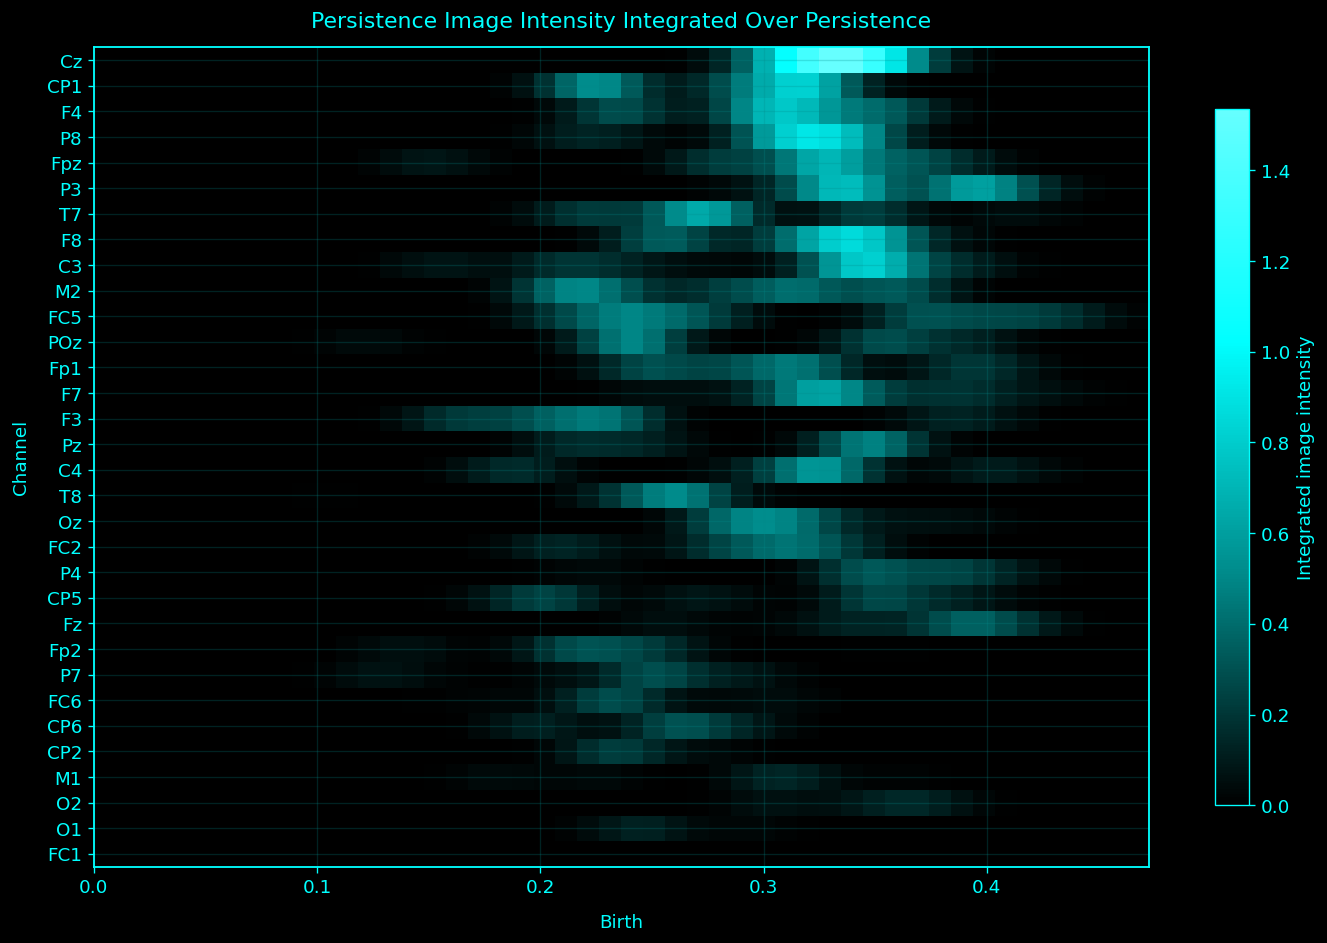

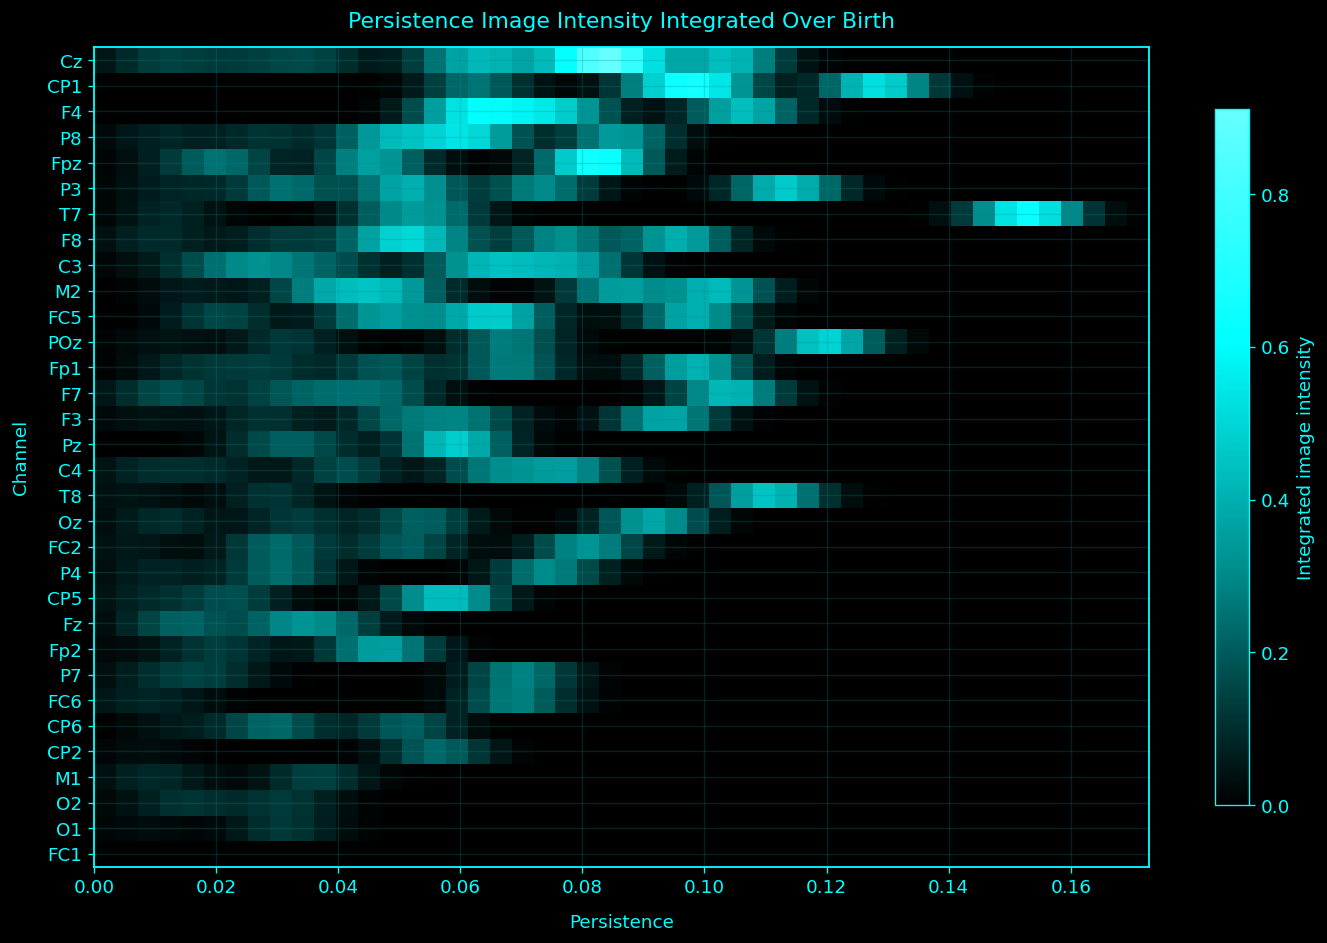

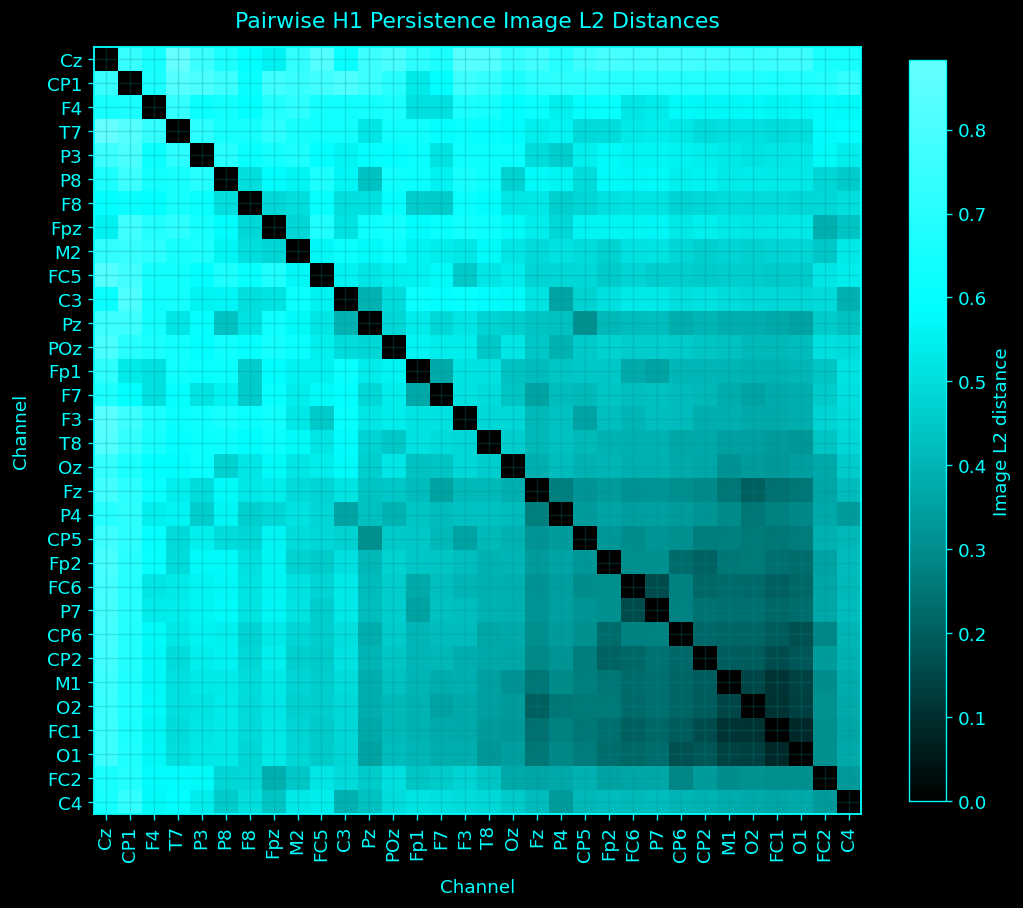

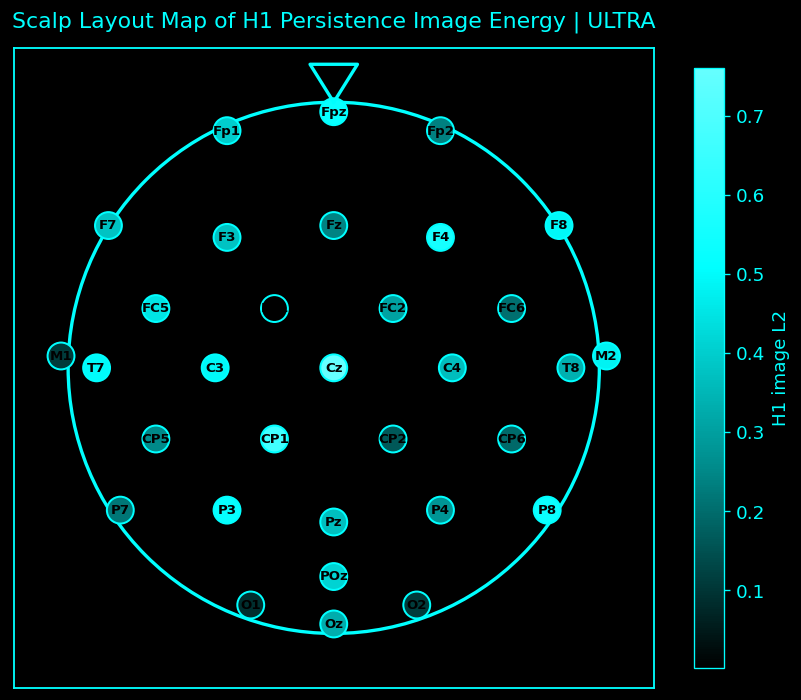

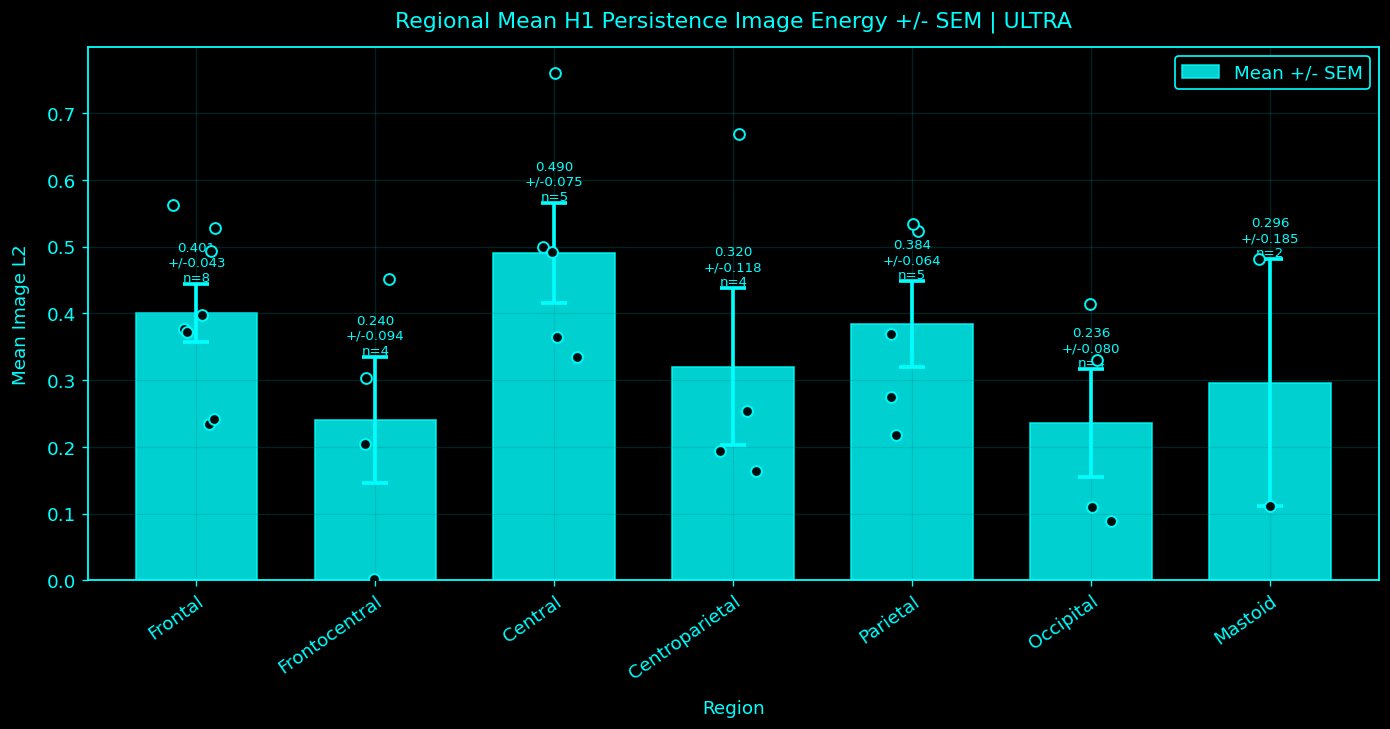

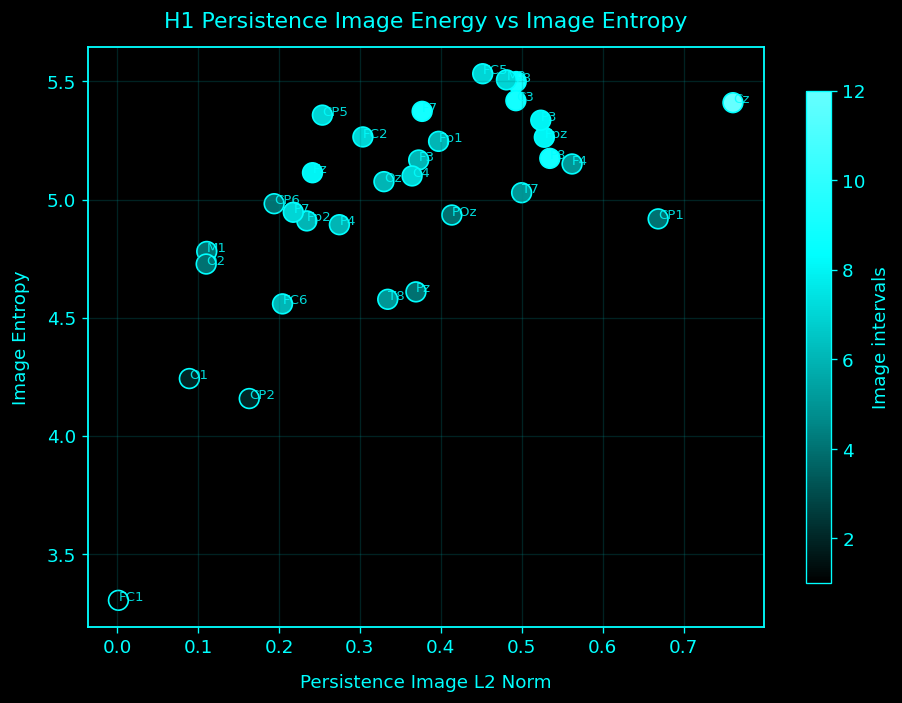

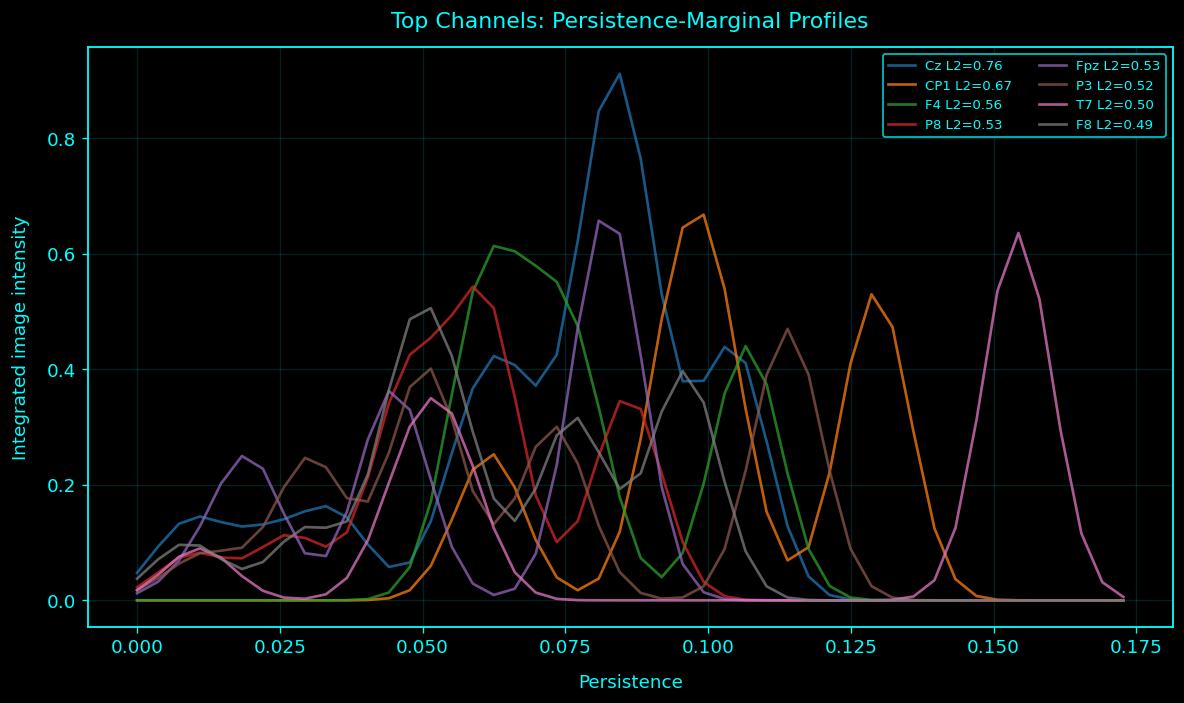

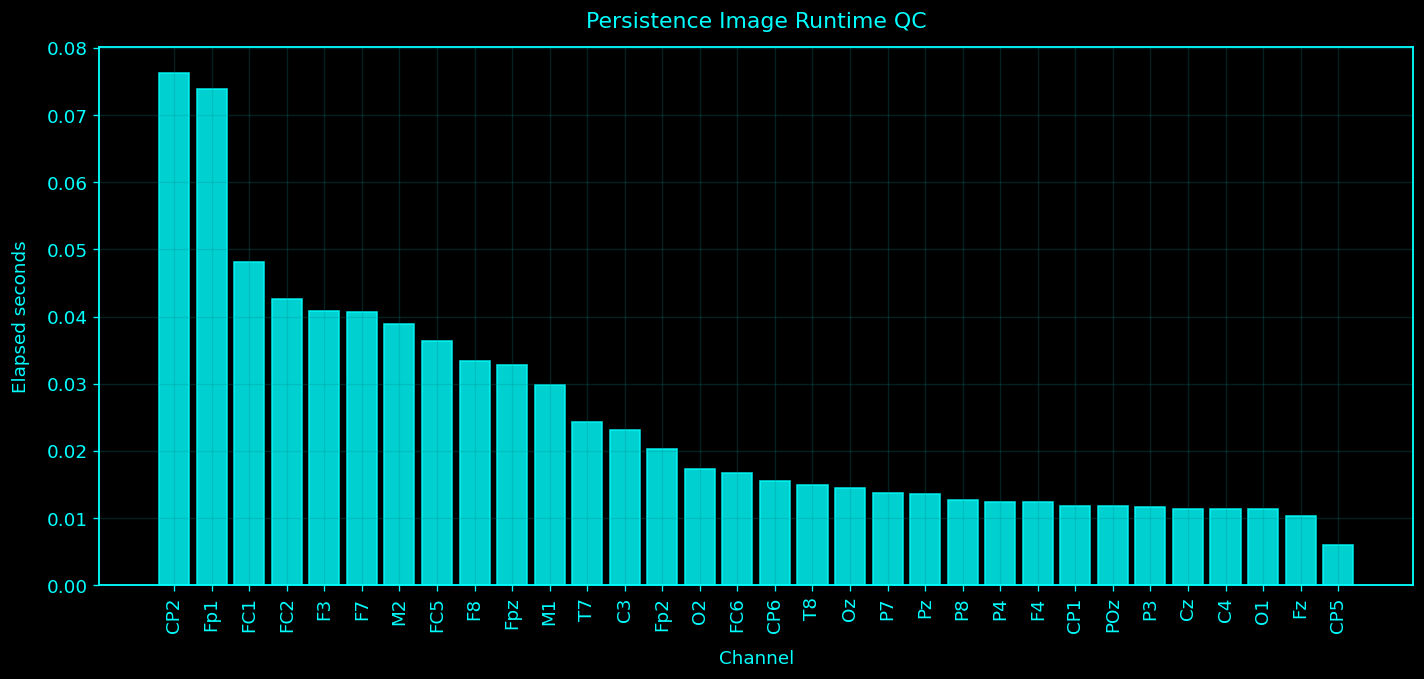

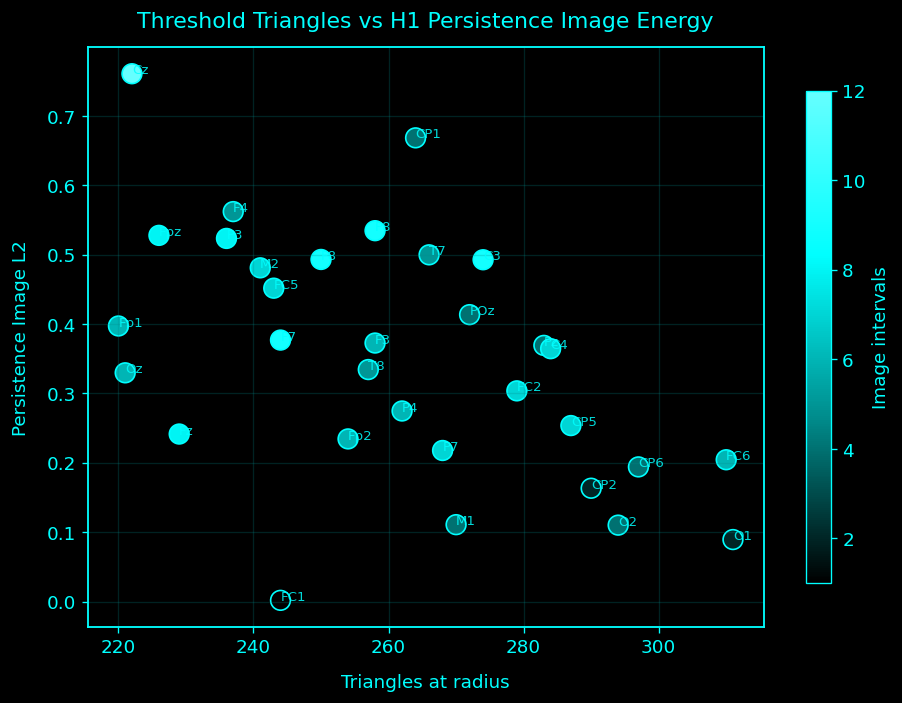


Expert plots saved and rendered from: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_images/h1_persistence_images_ultra_ripser_presampled/expert_plots
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_images/h1_persistence_images_ultra_ripser_presampled/expert_plots/regional_h1_persistence_image_summary.csv

Finished H1 Persistence Images in 4.80s
Mode: ultra
Backend: ripser_presampled
Channels completed: 32
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_images/h1_persistence_images_ultra_ripser_presampled/persistence_image_summary.csv
Persistence image NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_images/h1_persistence_images_ultra_ripser_presampled/persistence_images_h1.npz
Pairwise distance CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_images/h1_persistence_images_ultra_ripser_presampled/h1_persistence_image_pairwise_l2_dista

In [1]:
import os
import sys
import time
import numpy as np

# NumPy compatibility: newer NumPy versions may not expose np.trapz.
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["VECLIB_MAXIMUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

try:
    from IPython.display import display, Image
    HAVE_IPYTHON = True
except Exception:
    HAVE_IPYTHON = False

try:
    from ripser import ripser
except Exception as exc:
    raise ImportError(
        "ripser is not installed. Run this in a separate notebook cell first:\n\n"
        "!pip install ripser persim\n\n"
        "Then rerun this Persistence Images cell."
    ) from exc


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
out_dir = os.path.join(base_dir, "topology_persistence_images")
os.makedirs(out_dir, exist_ok=True)

FAST_OPTION = "ultra"  # options: "ultra", "fast", "balanced", "full"

MAX_CHANNELS_TO_PROCESS = None
RENDER_ALL_IMAGES_INLINE = True
SAVE_PLOTS_TO_DISK = True
MAKE_EXPERT_PLOTS = True
INLINE_IMAGE_WIDTH = 950
VERBOSE_PROGRESS = True

MODE_CONFIGS = {
    "ultra": {
        "max_points": 55,
        "max_dims": 3,
        "radius_quantile": 0.12,
        "image_birth_bins": 48,
        "image_persistence_bins": 48,
        "gaussian_sigma_frac": 0.035,
        "weight_power": 1.0,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 8,
        "plot_dpi": 120,
    },
    "fast": {
        "max_points": 90,
        "max_dims": 3,
        "radius_quantile": 0.15,
        "image_birth_bins": 64,
        "image_persistence_bins": 64,
        "gaussian_sigma_frac": 0.030,
        "weight_power": 1.0,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 8,
        "plot_dpi": 130,
    },
    "balanced": {
        "max_points": 130,
        "max_dims": 3,
        "radius_quantile": 0.18,
        "image_birth_bins": 80,
        "image_persistence_bins": 80,
        "gaussian_sigma_frac": 0.027,
        "weight_power": 1.0,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 10,
        "plot_dpi": 140,
    },
    "full": {
        "max_points": 180,
        "max_dims": 3,
        "radius_quantile": 0.22,
        "image_birth_bins": 110,
        "image_persistence_bins": 110,
        "gaussian_sigma_frac": 0.024,
        "weight_power": 1.0,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 12,
        "plot_dpi": 150,
    },
}

if FAST_OPTION not in MODE_CONFIGS:
    raise ValueError("FAST_OPTION must be one of: ultra, fast, balanced, full")

cfg = MODE_CONFIGS[FAST_OPTION]

MAX_POINTS = cfg["max_points"]
MAX_DIMS = cfg["max_dims"]
RADIUS_QUANTILE = cfg["radius_quantile"]
IMAGE_BIRTH_BINS = cfg["image_birth_bins"]
IMAGE_PERSISTENCE_BINS = cfg["image_persistence_bins"]
GAUSSIAN_SIGMA_FRAC = cfg["gaussian_sigma_frac"]
WEIGHT_POWER = cfg["weight_power"]
CAP_ESSENTIAL_H1 = cfg["cap_essential_h1"]
TOP_CHANNELS_TO_OVERLAY = cfg["top_channels_to_overlay"]
PLOT_DPI = cfg["plot_dpi"]

mode_out_dir = os.path.join(out_dir, f"h1_persistence_images_{FAST_OPTION}_ripser_presampled")
os.makedirs(mode_out_dir, exist_ok=True)

eeg_channels = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if MAX_CHANNELS_TO_PROCESS is not None:
    eeg_channels = eeg_channels[:MAX_CHANNELS_TO_PROCESS]

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})


def log(msg):
    if VERBOSE_PROGRESS:
        print(msg, flush=True)


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT, labelpad=10)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT, labelpad=10)

    if grid:
        ax.grid(True, color=ACCENT_DIM, alpha=0.25, linewidth=0.8)


def style_colorbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)


def save_render_close(fig, path, width=INLINE_IMAGE_WIDTH):
    if SAVE_PLOTS_TO_DISK:
        fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight", facecolor=BLACK)

    plt.close(fig)

    if RENDER_ALL_IMAGES_INLINE and HAVE_IPYTHON and os.path.exists(path):
        display(Image(filename=path, width=width))


def load_channel_embedding_sampled(ch_name, max_points=55, seed=7):
    candidate_paths = [
        os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d", f"umap_embedding_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d", f"tsne_embedding_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "3dembedding_data", f"3dembedded_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "2dembedding_data", f"2dembedded_{ch_name}.npy"),
    ]

    rng = np.random.default_rng(seed)

    for path in candidate_paths:
        if not os.path.exists(path):
            continue

        log(f"    trying: {path}")

        try:
            X = np.load(path, mmap_mode="r", allow_pickle=False)
        except Exception as exc:
            log(f"    skipped non-memmappable or nonnumeric file: {os.path.basename(path)} | {exc}")
            continue

        if X.ndim != 2:
            log(f"    skipped because ndim={X.ndim}")
            continue

        original_shape = tuple(X.shape)

        try:
            if X.shape[0] >= X.shape[1]:
                n_samples = X.shape[0]
                n_features = X.shape[1]

                if n_samples < 10 or n_features < 2:
                    log(f"    skipped bad shape: {original_shape}")
                    continue

                sample_n = min(max_points, n_samples)
                idx = np.sort(rng.choice(n_samples, size=sample_n, replace=False))
                X_small = np.asarray(X[idx, :], dtype=np.float64)

            else:
                n_samples = X.shape[1]
                n_features = X.shape[0]

                if n_samples < 10 or n_features < 2:
                    log(f"    skipped bad transposed shape: {original_shape}")
                    continue

                sample_n = min(max_points, n_samples)
                idx = np.sort(rng.choice(n_samples, size=sample_n, replace=False))
                X_small = np.asarray(X[:, idx].T, dtype=np.float64)

        except Exception as exc:
            log(f"    failed while sampling {os.path.basename(path)} | {exc}")
            continue

        X_small = X_small[np.all(np.isfinite(X_small), axis=1)]

        if X_small.shape[0] >= 10 and X_small.shape[1] >= 2:
            return X_small, path, original_shape

        log(f"    sampled data unusable: sampled_shape={X_small.shape}")

    return None, None, None


def standardize_point_cloud_small(X, max_dims=3):
    X = np.asarray(X, dtype=np.float64)
    X = X[np.all(np.isfinite(X), axis=1)]

    if X.shape[0] < 10:
        return None

    X = X - np.mean(X, axis=0, keepdims=True)

    if X.shape[1] > max_dims:
        _U, _S, Vt = np.linalg.svd(X, full_matrices=False)
        X = X @ Vt[:max_dims].T

    X = X / (np.std(X, axis=0, keepdims=True) + 1e-12)

    D = pdist(X)
    positive = D[D > 0]

    if len(positive) > 0:
        X = X / (np.nanmedian(positive) + 1e-12)

    return X


def estimate_complex_counts(X, radius):
    D = squareform(pdist(X))
    A = (D <= radius) & (D > 0)

    n_edges = int(np.sum(A) // 2)

    if A.shape[0] <= 300:
        A_int = A.astype(np.int64)
        n_triangles = int(np.trace(A_int @ A_int @ A_int) // 6)
    else:
        n_triangles = np.nan

    return n_edges, n_triangles


def run_h1_ripser(X, radius):
    result = ripser(
        X,
        maxdim=1,
        thresh=float(radius),
        coeff=2,
        do_cocycles=False,
    )

    diagrams = result["dgms"]

    h0 = diagrams[0] if len(diagrams) > 0 else np.empty((0, 2), dtype=float)
    h1 = diagrams[1] if len(diagrams) > 1 else np.empty((0, 2), dtype=float)

    return h0, h1


def split_finite_essential(diagram):
    diagram = np.asarray(diagram, dtype=float)

    if diagram.size == 0:
        return np.empty((0, 2), dtype=float), np.empty((0, 2), dtype=float)

    finite = diagram[
        np.isfinite(diagram[:, 0])
        & np.isfinite(diagram[:, 1])
        & (diagram[:, 1] > diagram[:, 0])
    ]

    essential = diagram[
        np.isfinite(diagram[:, 0])
        & np.isinf(diagram[:, 1])
    ]

    return finite, essential


def clean_intervals_for_image(
    finite_intervals,
    essential_intervals=None,
    cap_essential=True,
    cap_value=None,
):
    finite = []
    capped_count = 0

    if finite_intervals is not None:
        for b, d in finite_intervals:
            if np.isfinite(b) and np.isfinite(d) and d > b:
                finite.append((float(b), float(d)))

    if cap_essential and essential_intervals is not None and cap_value is not None:
        for b, _d in essential_intervals:
            if np.isfinite(b) and np.isfinite(cap_value) and cap_value > b:
                finite.append((float(b), float(cap_value)))
                capped_count += 1

    if len(finite) == 0:
        return np.empty((0, 2), dtype=float), capped_count

    return np.asarray(finite, dtype=float), capped_count


def intervals_to_birth_persistence(intervals):
    intervals = np.asarray(intervals, dtype=float)

    if intervals.size == 0:
        return np.empty((0, 2), dtype=float)

    intervals = intervals[
        np.isfinite(intervals[:, 0])
        & np.isfinite(intervals[:, 1])
        & (intervals[:, 1] > intervals[:, 0])
    ]

    if len(intervals) == 0:
        return np.empty((0, 2), dtype=float)

    births = intervals[:, 0]
    persistence = intervals[:, 1] - intervals[:, 0]

    return np.column_stack([births, persistence])


def persistence_image(
    birth_persistence_points,
    birth_grid,
    persistence_grid,
    sigma_birth,
    sigma_persistence,
    weight_power=1.0,
):
    points = np.asarray(birth_persistence_points, dtype=float)

    image = np.zeros((len(persistence_grid), len(birth_grid)), dtype=float)

    if points.size == 0:
        return image

    valid = (
        np.isfinite(points[:, 0])
        & np.isfinite(points[:, 1])
        & (points[:, 1] > 0)
    )
    points = points[valid]

    if len(points) == 0:
        return image

    B = birth_grid[None, :]
    P = persistence_grid[:, None]

    sigma_b2 = 2.0 * sigma_birth ** 2
    sigma_p2 = 2.0 * sigma_persistence ** 2

    for birth, persistence in points:
        weight = persistence ** weight_power
        gaussian = np.exp(-((B - birth) ** 2) / sigma_b2 - ((P - persistence) ** 2) / sigma_p2)
        image += weight * gaussian

    return image


def persistence_image_features(image, birth_grid, persistence_grid, bp_points):
    image = np.asarray(image, dtype=float)
    bp_points = np.asarray(bp_points, dtype=float)

    total_mass = float(np.sum(image))
    l1 = float(np.sum(np.abs(image)))
    l2 = float(np.sqrt(np.sum(image ** 2)))
    linf = float(np.nanmax(image)) if image.size else 0.0

    flat = image.ravel()

    if np.sum(flat) > 0:
        p = flat / np.sum(flat)
        entropy = float(-np.sum(p[p > 0] * np.log(p[p > 0])))

        birth_mesh, pers_mesh = np.meshgrid(birth_grid, persistence_grid)
        center_birth = float(np.sum(birth_mesh * image) / np.sum(image))
        center_persistence = float(np.sum(pers_mesh * image) / np.sum(image))

        max_idx = np.unravel_index(np.nanargmax(image), image.shape)
        peak_persistence = float(persistence_grid[max_idx[0]])
        peak_birth = float(birth_grid[max_idx[1]])
    else:
        entropy = 0.0
        center_birth = np.nan
        center_persistence = np.nan
        peak_birth = np.nan
        peak_persistence = np.nan

    if bp_points is not None and len(bp_points) > 0:
        persistence_values = bp_points[:, 1]
        n_intervals = int(len(bp_points))
        mean_persistence = float(np.nanmean(persistence_values))
        max_persistence = float(np.nanmax(persistence_values))
        total_persistence = float(np.nansum(persistence_values))
    else:
        n_intervals = 0
        mean_persistence = np.nan
        max_persistence = np.nan
        total_persistence = 0.0

    return {
        "image_mass": total_mass,
        "image_l1": l1,
        "image_l2": l2,
        "image_linf": linf,
        "image_entropy": entropy,
        "image_center_birth": center_birth,
        "image_center_persistence": center_persistence,
        "image_peak_birth": peak_birth,
        "image_peak_persistence": peak_persistence,
        "n_intervals_image": n_intervals,
        "mean_persistence": mean_persistence,
        "max_persistence": max_persistence,
        "total_persistence": total_persistence,
    }


log("\n" + "=" * 72)
log(f"Running H1 Persistence Images with ripser backend | {FAST_OPTION.upper()}")
log(f"Channels: {len(eeg_channels)}")
log(f"max_points={MAX_POINTS}, radius_quantile={RADIUS_QUANTILE}")
log(f"image bins={IMAGE_BIRTH_BINS} x {IMAGE_PERSISTENCE_BINS}")
log(f"sigma_frac={GAUSSIAN_SIGMA_FRAC}, weight_power={WEIGHT_POWER}")
log(f"expert_plots={MAKE_EXPERT_PLOTS}, render_all_images={RENDER_ALL_IMAGES_INLINE}")
log(f"Output: {mode_out_dir}")
log("=" * 72)

diagnostics = {}
interval_store = {}
bp_store = {}
loaded_channels = []

global_birth_max = None
global_persistence_max = None

overall_t0 = time.time()

for ch_idx, ch_name in enumerate(eeg_channels, start=1):
    t0 = time.time()
    prefix = f"[{ch_idx:02d}/{len(eeg_channels)} {ch_name}]"

    log(f"\n{prefix} loading + pre-subsampling to {MAX_POINTS} points")

    X_small, source_path, original_shape = load_channel_embedding_sampled(
        ch_name,
        max_points=MAX_POINTS,
        seed=200 + ch_idx,
    )

    if X_small is None:
        log(f"{prefix} WARNING: no usable embedding found; skipping")
        continue

    log(f"{prefix} source shape={original_shape}, sampled shape={X_small.shape}")

    X = standardize_point_cloud_small(X_small, max_dims=MAX_DIMS)

    if X is None:
        log(f"{prefix} WARNING: invalid sampled embedding; skipping")
        continue

    log(f"{prefix} standardized shape={X.shape}; computing radius")

    D_flat = pdist(X)
    positive = D_flat[D_flat > 0]

    if len(positive) == 0:
        log(f"{prefix} WARNING: zero-distance cloud; skipping")
        continue

    radius = float(np.quantile(positive, RADIUS_QUANTILE))

    log(f"{prefix} estimating threshold complex size")
    n_edges, n_triangles = estimate_complex_counts(X, radius)

    log(f"{prefix} ripser H0/H1")
    h0_diag, h1_diag = run_h1_ripser(X, radius)

    h0_finite, h0_essential = split_finite_essential(h0_diag)
    h1_finite, h1_essential = split_finite_essential(h1_diag)

    h1_intervals, n_capped_h1 = clean_intervals_for_image(
        h1_finite,
        essential_intervals=h1_essential,
        cap_essential=CAP_ESSENTIAL_H1,
        cap_value=radius,
    )

    bp_points = intervals_to_birth_persistence(h1_intervals)

    interval_store[ch_name] = {
        "H0_finite": h0_finite,
        "H0_essential": h0_essential,
        "H1_finite": h1_finite,
        "H1_essential": h1_essential,
        "H1_image_intervals": h1_intervals,
    }

    bp_store[ch_name] = bp_points

    if len(bp_points) > 0:
        ch_birth_max = float(np.nanmax(bp_points[:, 0]))
        ch_persistence_max = float(np.nanmax(bp_points[:, 1]))

        global_birth_max = ch_birth_max if global_birth_max is None else max(global_birth_max, ch_birth_max)
        global_persistence_max = (
            ch_persistence_max
            if global_persistence_max is None
            else max(global_persistence_max, ch_persistence_max)
        )

    elapsed = time.time() - t0

    diagnostics[ch_name] = {
        "channel": ch_name,
        "source_path": source_path,
        "source_shape": str(original_shape),
        "backend": "ripser_presampled",
        "n_points": int(X.shape[0]),
        "n_edges_at_radius": int(n_edges),
        "n_triangles_at_radius": int(n_triangles) if np.isfinite(n_triangles) else np.nan,
        "radius": radius,
        "n_h0_finite": int(len(h0_finite)),
        "n_h1_finite": int(len(h1_finite)),
        "n_h1_essential": int(len(h1_essential)),
        "n_h1_capped_for_image": int(n_capped_h1),
        "n_h1_image_intervals": int(len(h1_intervals)),
        "elapsed_sec": elapsed,
    }

    loaded_channels.append(ch_name)

    log(
        f"{prefix} done {elapsed:.2f}s | "
        f"edges={n_edges}, triangles={n_triangles}, "
        f"H1 finite={len(h1_finite)}, H1 image intervals={len(h1_intervals)}"
    )

if len(loaded_channels) == 0:
    raise RuntimeError("No usable embeddings found. Check embedding_data paths.")

if global_birth_max is None or not np.isfinite(global_birth_max) or global_birth_max <= 0:
    global_birth_max = 1.0

if global_persistence_max is None or not np.isfinite(global_persistence_max) or global_persistence_max <= 0:
    global_persistence_max = 1.0

birth_pad = max(1e-6, 0.08 * global_birth_max)
persistence_pad = max(1e-6, 0.12 * global_persistence_max)

birth_grid = np.linspace(0.0, global_birth_max + birth_pad, IMAGE_BIRTH_BINS)
persistence_grid = np.linspace(0.0, global_persistence_max + persistence_pad, IMAGE_PERSISTENCE_BINS)

birth_range = birth_grid[-1] - birth_grid[0]
persistence_range = persistence_grid[-1] - persistence_grid[0]

sigma_birth = max(1e-6, GAUSSIAN_SIGMA_FRAC * birth_range)
sigma_persistence = max(1e-6, GAUSSIAN_SIGMA_FRAC * persistence_range)

log("\nBuilding persistence images")
log(f"birth range: 0.0 to {birth_grid[-1]:.6f}")
log(f"persistence range: 0.0 to {persistence_grid[-1]:.6f}")
log(f"sigma_birth={sigma_birth:.6f}, sigma_persistence={sigma_persistence:.6f}")

image_store = {}
rows = []

for ch_name in loaded_channels:
    bp_points = bp_store[ch_name]

    img = persistence_image(
        bp_points,
        birth_grid=birth_grid,
        persistence_grid=persistence_grid,
        sigma_birth=sigma_birth,
        sigma_persistence=sigma_persistence,
        weight_power=WEIGHT_POWER,
    )

    image_store[ch_name] = img

    rows.append({
        **diagnostics[ch_name],
        **persistence_image_features(img, birth_grid, persistence_grid, bp_points),
    })

results_df = (
    pd.DataFrame(rows)
    .sort_values("image_l2", ascending=False)
    .reset_index(drop=True)
)

summary_csv_path = os.path.join(mode_out_dir, "persistence_image_summary.csv")
results_df.to_csv(summary_csv_path, index=False)

npz_path = os.path.join(mode_out_dir, "persistence_images_h1.npz")

save_dict = {
    "channels": np.asarray(loaded_channels),
    "birth_grid": birth_grid,
    "persistence_grid": persistence_grid,
    "fast_option": np.asarray([FAST_OPTION]),
    "backend": np.asarray(["ripser_presampled"]),
    "sigma_birth": np.asarray([sigma_birth]),
    "sigma_persistence": np.asarray([sigma_persistence]),
    "weight_power": np.asarray([WEIGHT_POWER]),
}

for ch_name in loaded_channels:
    save_dict[f"{ch_name}_persistence_image"] = image_store[ch_name]
    save_dict[f"{ch_name}_birth_persistence_points"] = bp_store[ch_name]

    for key, val in interval_store[ch_name].items():
        save_dict[f"{ch_name}_{key}"] = val

np.savez(npz_path, **save_dict)

print("\nPersistence Image Summary:")
if HAVE_IPYTHON:
    display(results_df)
else:
    print(results_df)

log(f"\nSaved summary CSV: {summary_csv_path}")
log(f"Saved persistence image NPZ: {npz_path}")

plot_df = results_df.copy().sort_values("image_l2", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BLACK)
style_ax(
    ax,
    title=f"H1 Persistence Image Energy by Channel | {FAST_OPTION.upper()}",
    xlabel="Channel",
    ylabel="Persistence Image L2 Norm",
)

x_pos = np.arange(len(plot_df))
y = plot_df["image_l2"].to_numpy(dtype=float)

ax.bar(x_pos, y, color=ACCENT, edgecolor=ACCENT, alpha=0.78)

if np.any(np.isfinite(y)):
    ax.axhline(
        np.nanmean(y),
        color=ACCENT_SOFT,
        linestyle="--",
        linewidth=1.4,
        alpha=0.8,
        label=f"Mean={np.nanmean(y):.5f}",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["channel"], rotation=90)
ax.legend(loc="best", framealpha=1.0)

ranking_path = os.path.join(mode_out_dir, "01_h1_persistence_image_l2_ranking.png")
plt.tight_layout()
save_render_close(fig, ranking_path)

n_cols = 4
n_rows = int(np.ceil(len(loaded_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.25 * n_rows),
    facecolor=BLACK,
)

axes = np.asarray(axes).reshape(-1)

image_vmax = np.nanmax([np.nanmax(image_store[ch]) for ch in loaded_channels])
if not np.isfinite(image_vmax) or image_vmax <= 0:
    image_vmax = 1.0

for ax_idx, ch_name in enumerate(loaded_channels):
    ax = axes[ax_idx]
    img = image_store[ch_name]

    l2_val = results_df.loc[results_df["channel"] == ch_name, "image_l2"].values[0]
    n_intervals = results_df.loc[results_df["channel"] == ch_name, "n_intervals_image"].values[0]

    style_ax(
        ax,
        title=f"{ch_name}: L2={l2_val:.3f}, n={int(n_intervals)}",
        xlabel="Birth",
        ylabel="Persistence",
        grid=False,
    )

    ax.imshow(
        img,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=image_vmax,
        extent=[
            birth_grid[0],
            birth_grid[-1],
            persistence_grid[0],
            persistence_grid[-1],
        ],
    )

for j in range(len(loaded_channels), len(axes)):
    axes[j].axis("off")

all_images_path = os.path.join(mode_out_dir, "02_all_channels_h1_persistence_images.png")
plt.tight_layout()
save_render_close(fig, all_images_path, width=1100)

mean_image = np.mean(
    np.asarray([image_store[ch] for ch in loaded_channels], dtype=float),
    axis=0,
)

fig, ax = plt.subplots(figsize=(8, 7), facecolor=BLACK)
style_ax(
    ax,
    title="Mean H1 Persistence Image Across Channels",
    xlabel="Birth",
    ylabel="Persistence",
    grid=False,
)

im = ax.imshow(
    mean_image,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
    extent=[
        birth_grid[0],
        birth_grid[-1],
        persistence_grid[0],
        persistence_grid[-1],
    ],
)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Mean image intensity")

mean_image_path = os.path.join(mode_out_dir, "03_mean_h1_persistence_image.png")
plt.tight_layout()
save_render_close(fig, mean_image_path)

heat_channels = plot_df["channel"].tolist()

integrated_birth_profile = np.asarray([
    np.sum(image_store[ch], axis=0)
    for ch in heat_channels
], dtype=float)

fig, ax = plt.subplots(figsize=(12, 8), facecolor=BLACK)
style_ax(
    ax,
    title="Persistence Image Intensity Integrated Over Persistence",
    xlabel="Birth",
    ylabel="Channel",
)

im = ax.imshow(
    integrated_birth_profile,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
    extent=[
        birth_grid[0],
        birth_grid[-1],
        len(heat_channels) - 0.5,
        -0.5,
    ],
)

ax.set_yticks(np.arange(len(heat_channels)))
ax.set_yticklabels(heat_channels)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Integrated image intensity")

birth_profile_path = os.path.join(mode_out_dir, "04_integrated_birth_profile_heatmap.png")
plt.tight_layout()
save_render_close(fig, birth_profile_path)

integrated_persistence_profile = np.asarray([
    np.sum(image_store[ch], axis=1)
    for ch in heat_channels
], dtype=float)

fig, ax = plt.subplots(figsize=(12, 8), facecolor=BLACK)
style_ax(
    ax,
    title="Persistence Image Intensity Integrated Over Birth",
    xlabel="Persistence",
    ylabel="Channel",
)

im = ax.imshow(
    integrated_persistence_profile,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
    extent=[
        persistence_grid[0],
        persistence_grid[-1],
        len(heat_channels) - 0.5,
        -0.5,
    ],
)

ax.set_yticks(np.arange(len(heat_channels)))
ax.set_yticklabels(heat_channels)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Integrated image intensity")

persistence_profile_path = os.path.join(mode_out_dir, "05_integrated_persistence_profile_heatmap.png")
plt.tight_layout()
save_render_close(fig, persistence_profile_path)

channels_for_dist = loaded_channels
n_ch = len(channels_for_dist)

flat_images = np.asarray([
    image_store[ch].reshape(-1)
    for ch in channels_for_dist
], dtype=float)

dist_mat = np.zeros((n_ch, n_ch), dtype=float)

for i in range(n_ch):
    for j in range(i + 1, n_ch):
        dist = float(np.linalg.norm(flat_images[i] - flat_images[j]))
        dist_mat[i, j] = dist
        dist_mat[j, i] = dist

dist_csv_path = os.path.join(mode_out_dir, "h1_persistence_image_pairwise_l2_distance.csv")
pd.DataFrame(dist_mat, index=channels_for_dist, columns=channels_for_dist).to_csv(dist_csv_path)

if n_ch >= 3 and np.any(dist_mat > 0):
    condensed = dist_mat[np.triu_indices(n_ch, k=1)]
    Z = linkage(condensed, method="average")
    order = leaves_list(Z)
else:
    order = np.arange(n_ch)

ordered_dist = dist_mat[np.ix_(order, order)]
ordered_channels = [channels_for_dist[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 8), facecolor=BLACK)
style_ax(
    ax,
    title="Pairwise H1 Persistence Image L2 Distances",
    xlabel="Channel",
    ylabel="Channel",
)

im = ax.imshow(
    ordered_dist,
    aspect="equal",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
)

ax.set_xticks(np.arange(n_ch))
ax.set_xticklabels(ordered_channels, rotation=90)
ax.set_yticks(np.arange(n_ch))
ax.set_yticklabels(ordered_channels)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Image L2 distance")

dist_path = os.path.join(mode_out_dir, "06_h1_persistence_image_pairwise_distance_heatmap.png")
plt.tight_layout()
save_render_close(fig, dist_path)

if MAKE_EXPERT_PLOTS:
    expert_dir = os.path.join(mode_out_dir, "expert_plots")
    os.makedirs(expert_dir, exist_ok=True)

    image_l2_map = dict(zip(results_df["channel"], results_df["image_l2"]))

    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),
        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),
        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),
        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),
        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),
        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in image_l2_map and np.isfinite(image_l2_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(image_l2_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BLACK)
    style_ax(
        ax,
        title=f"Scalp Layout Map of H1 Persistence Image Energy | {FAST_OPTION.upper()}",
        grid=False,
    )

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)
    ax.plot([0.00, -0.10, 0.10, 0.00], [1.12, 1.28, 1.28, 1.12], color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolor=ACCENT,
        linewidth=1.2,
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BLACK,
            fontweight="bold",
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    style_colorbar(cbar, "H1 image L2")

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "07_h1_persistence_image_scalp_map.png")
    plt.tight_layout()
    save_render_close(fig, scalp_path, width=760)

    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in image_l2_map and np.isfinite(image_l2_map[ch]):
                vals_region.append(image_l2_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "image_l2": image_l2_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_image_l2": float(np.mean(vals_region)),
            "std_image_l2": float(np.std(vals_region, ddof=1)) if len(vals_region) > 1 else 0.0,
            "sem_image_l2": (
                float(np.std(vals_region, ddof=1) / np.sqrt(len(vals_region)))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": int(len(vals_region)),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_h1_persistence_image_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    if len(region_df) > 0:
        fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BLACK)
        style_ax(
            ax,
            title=f"Regional Mean H1 Persistence Image Energy +/- SEM | {FAST_OPTION.upper()}",
            xlabel="Region",
            ylabel="Mean Image L2",
        )

        x_region = np.arange(len(region_df))

        ax.bar(
            x_region,
            region_df["mean_image_l2"],
            yerr=region_df["sem_image_l2"],
            color=ACCENT,
            edgecolor=ACCENT,
            alpha=0.82,
            width=0.68,
            capsize=8,
            error_kw={
                "elinewidth": 2.2,
                "capthick": 2.2,
                "ecolor": ACCENT,
                "alpha": 1.0,
            },
            label="Mean +/- SEM",
        )

        rng = np.random.default_rng(7)

        for i, region_name in enumerate(region_df["region"]):
            vals = region_points_df.loc[
                region_points_df["region"] == region_name,
                "image_l2",
            ].to_numpy(dtype=float)

            if len(vals) == 0:
                continue

            jitter = rng.uniform(-0.13, 0.13, size=len(vals))

            ax.scatter(
                np.full(len(vals), i) + jitter,
                vals,
                s=42,
                facecolors=BLACK,
                edgecolors=ACCENT,
                linewidths=1.2,
                alpha=0.95,
                zorder=4,
            )

        for i, row in region_df.iterrows():
            y_val = row["mean_image_l2"]
            sem = row["sem_image_l2"]

            ax.text(
                i,
                y_val + sem,
                f"{y_val:.3f}\n+/-{sem:.3f}\nn={int(row['n_channels'])}",
                ha="center",
                va="bottom",
                fontsize=8,
                color=ACCENT,
            )

        ax.set_xticks(x_region)
        ax.set_xticklabels(
            region_df["region"],
            rotation=35,
            ha="right",
            rotation_mode="anchor",
        )
        ax.margins(x=0.04)
        ax.legend(loc="best", framealpha=1.0)

        region_path = os.path.join(expert_dir, "08_regional_h1_persistence_image_summary.png")
        plt.tight_layout(pad=2.0)
        save_render_close(fig, region_path)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BLACK)
    style_ax(
        ax,
        title="H1 Persistence Image Energy vs Image Entropy",
        xlabel="Persistence Image L2 Norm",
        ylabel="Image Entropy",
    )

    sc = ax.scatter(
        results_df["image_l2"],
        results_df["image_entropy"],
        c=results_df["n_intervals_image"],
        s=140,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolor=ACCENT,
        linewidth=1.0,
    )

    for _, row in results_df.iterrows():
        if np.isfinite(row["image_l2"]) and np.isfinite(row["image_entropy"]):
            ax.text(
                row["image_l2"],
                row["image_entropy"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85,
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    style_colorbar(cbar, "Image intervals")

    entropy_path = os.path.join(expert_dir, "09_image_energy_vs_entropy.png")
    plt.tight_layout()
    save_render_close(fig, entropy_path)

    top_channels = results_df.head(min(TOP_CHANNELS_TO_OVERLAY, len(results_df)))["channel"].tolist()

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=BLACK)
    style_ax(
        ax,
        title="Top Channels: Persistence-Marginal Profiles",
        xlabel="Persistence",
        ylabel="Integrated image intensity",
    )

    for ch_name in top_channels:
        profile = np.sum(image_store[ch_name], axis=1)
        l2_val = image_l2_map[ch_name]

        ax.plot(
            persistence_grid,
            profile,
            linewidth=1.6,
            alpha=0.75,
            label=f"{ch_name} L2={l2_val:.2f}",
        )

    ax.legend(fontsize=8, ncol=2)

    top_path = os.path.join(expert_dir, "10_top_channels_persistence_profiles.png")
    plt.tight_layout()
    save_render_close(fig, top_path)

    qc_df = results_df.copy().sort_values("elapsed_sec", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 5.8), facecolor=BLACK)
    style_ax(
        ax,
        title="Persistence Image Runtime QC",
        xlabel="Channel",
        ylabel="Elapsed seconds",
    )

    x_qc = np.arange(len(qc_df))

    ax.bar(
        x_qc,
        qc_df["elapsed_sec"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
    )

    ax.set_xticks(x_qc)
    ax.set_xticklabels(qc_df["channel"], rotation=90)

    qc_path = os.path.join(expert_dir, "11_runtime_qc.png")
    plt.tight_layout()
    save_render_close(fig, qc_path)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BLACK)
    style_ax(
        ax,
        title="Threshold Triangles vs H1 Persistence Image Energy",
        xlabel="Triangles at radius",
        ylabel="Persistence Image L2",
    )

    sc = ax.scatter(
        results_df["n_triangles_at_radius"],
        results_df["image_l2"],
        c=results_df["n_intervals_image"],
        s=140,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolor=ACCENT,
        linewidth=1.0,
    )

    for _, row in results_df.iterrows():
        ax.text(
            row["n_triangles_at_radius"],
            row["image_l2"],
            row["channel"],
            fontsize=8,
            color=ACCENT,
            alpha=0.85,
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    style_colorbar(cbar, "Image intervals")

    size_qc_path = os.path.join(expert_dir, "12_threshold_triangles_vs_persistence_image_energy.png")
    plt.tight_layout()
    save_render_close(fig, size_qc_path)

    log(f"\nExpert plots saved and rendered from: {expert_dir}")
    log(f"Regional summary CSV: {region_csv_path}")

elapsed_total = time.time() - overall_t0

log("\n" + "=" * 72)
log(f"Finished H1 Persistence Images in {elapsed_total:.2f}s")
log(f"Mode: {FAST_OPTION}")
log(f"Backend: ripser_presampled")
log(f"Channels completed: {len(loaded_channels)}")
log(f"Summary CSV: {summary_csv_path}")
log(f"Persistence image NPZ: {npz_path}")
log(f"Pairwise distance CSV: {dist_csv_path}")
log(f"Output directory: {mode_out_dir}")
log("=" * 72)


Running H1 Persistence Silhouettes with ripser backend | ULTRA
Channels: 32
max_points=55, radius_quantile=0.12
silhouette_grid_size=140, weight_power=1.0
expert_plots=True, render_all_images=True
Output: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_silhouettes/h1_persistence_silhouettes_ultra_ripser_presampled

[01/32 Fp1] loading + pre-subsampling to 55 points
    trying: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/tsne_umap_from_3d/umap_embedding_Fp1.npy
[01/32 Fp1] source shape=(106936, 2), sampled shape=(55, 2)
[01/32 Fp1] standardized shape=(55, 2); computing radius
[01/32 Fp1] estimating threshold complex size
[01/32 Fp1] ripser H0/H1
[01/32 Fp1] done 0.00s | edges=179, triangles=289, H1 finite=3, H1 silhouette intervals=5

[02/32 Fpz] loading + pre-subsampling to 55 points
    trying: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/tsne_umap_from_3d/umap_embedding_Fpz.npy
[02/32 Fpz] source shape=(106936, 2), sampled

,channel,source_path,source_shape,backend,n_points,n_edges_at_radius,n_triangles_at_radius,radius,n_h0_finite,n_h1_finite,...,silhouette_l2,silhouette_energy,silhouette_linf,silhouette_entropy,silhouette_center_of_mass,silhouette_peak_radius,n_intervals_silhouette,mean_lifetime,max_lifetime,total_lifetime
0,Pz,/home/a/projects/Complete-Neural-Signal-Analys...,"(106938, 2)",ripser_presampled,55,179,239,0.462072,54,4,...,0.012257,1.502432e-04,0.047311,3.763188,0.381276,0.375641,6,0.048805,0.167865,0.292831
1,Oz,/home/a/projects/Complete-Neural-Signal-Analys...,"(106940, 2)",ripser_presampled,55,179,226,0.457960,52,4,...,0.011413,1.302637e-04,0.045996,3.682520,0.385933,0.392263,8,0.072056,0.167471,0.576447
2,M1,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,236,0.391619,53,2,...,0.009770,9.545770e-05,0.048548,3.343506,0.335607,0.335750,4,0.060637,0.116135,0.242549
3,Fz,/home/a/projects/Complete-Neural-Signal-Analys...,"(106938, 2)",ripser_presampled,55,179,263,0.439990,53,4,...,0.008648,7.479565e-05,0.036772,3.586331,0.373297,0.368993,6,0.056405,0.142199,0.338429
4,CP1,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,227,0.406329,54,1,...,0.007628,5.818735e-05,0.034306,3.467781,0.348252,0.345723,4,0.057668,0.122954,0.230671
5,C4,/home/a/projects/Complete-Neural-Signal-Analys...,"(106938, 2)",ripser_presampled,55,179,265,0.420482,54,3,...,0.007237,5.236776e-05,0.031962,3.440661,0.361704,0.359020,5,0.044426,0.120419,0.222129
6,C3,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,258,0.428407,54,4,...,0.006378,4.067786e-05,0.029026,3.422587,0.354346,0.349047,7,0.039904,0.114571,0.279331
7,P3,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,242,0.442125,51,5,...,0.006143,3.773088e-05,0.033956,3.143531,0.395116,0.395587,6,0.035647,0.096402,0.213883
8,POz,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,267,0.391435,53,3,...,0.005384,2.898871e-05,0.026404,3.350965,0.336898,0.335750,5,0.046217,0.108702,0.231086
9,FC6,/home/a/projects/Complete-Neural-Signal-Analys...,"(106936, 2)",ripser_presampled,55,179,241,0.437807,54,5,...,0.004605,2.120602e-05,0.023200,3.315598,0.389112,0.388938,7,0.030349,0.096983,0.212440



Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_silhouettes/h1_persistence_silhouettes_ultra_ripser_presampled/persistence_silhouette_summary.csv
Saved persistence silhouette NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_silhouettes/h1_persistence_silhouettes_ultra_ripser_presampled/persistence_silhouettes_h1.npz


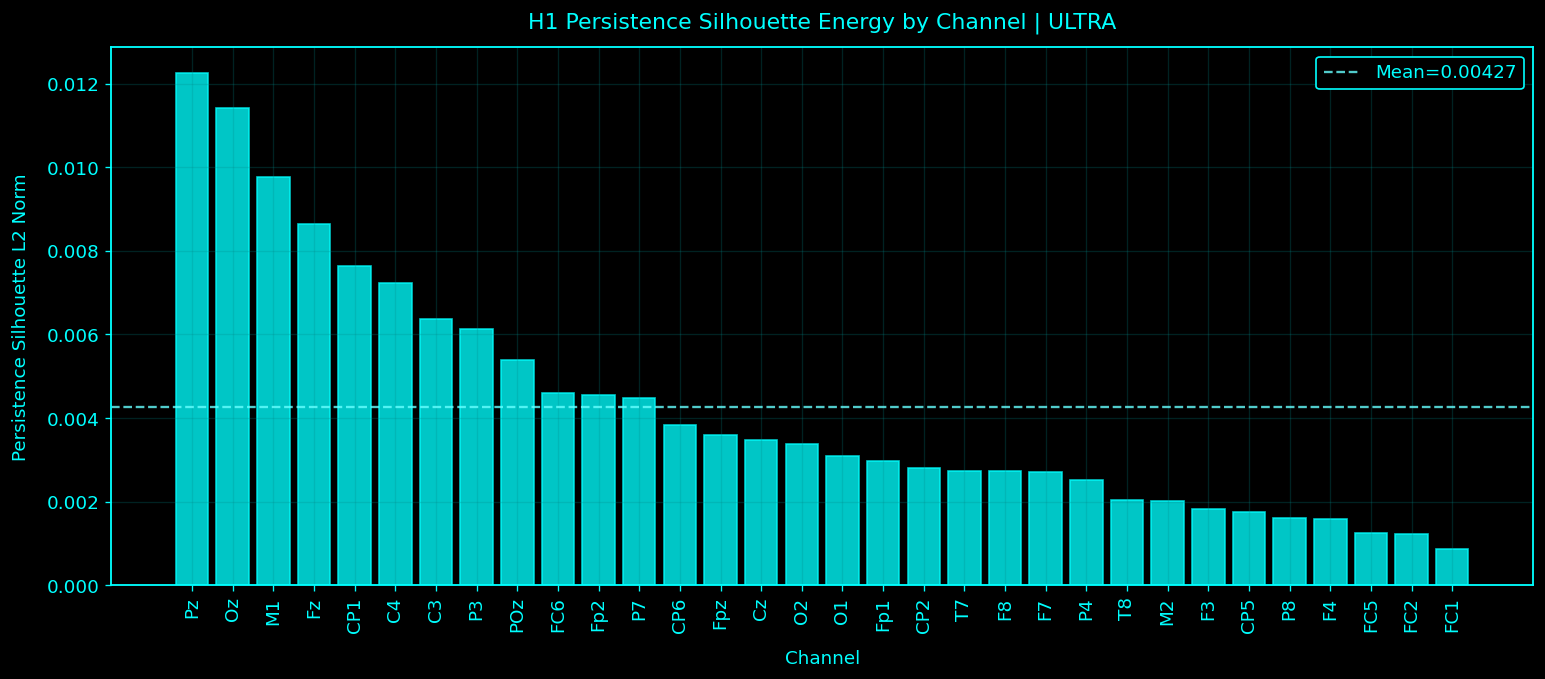

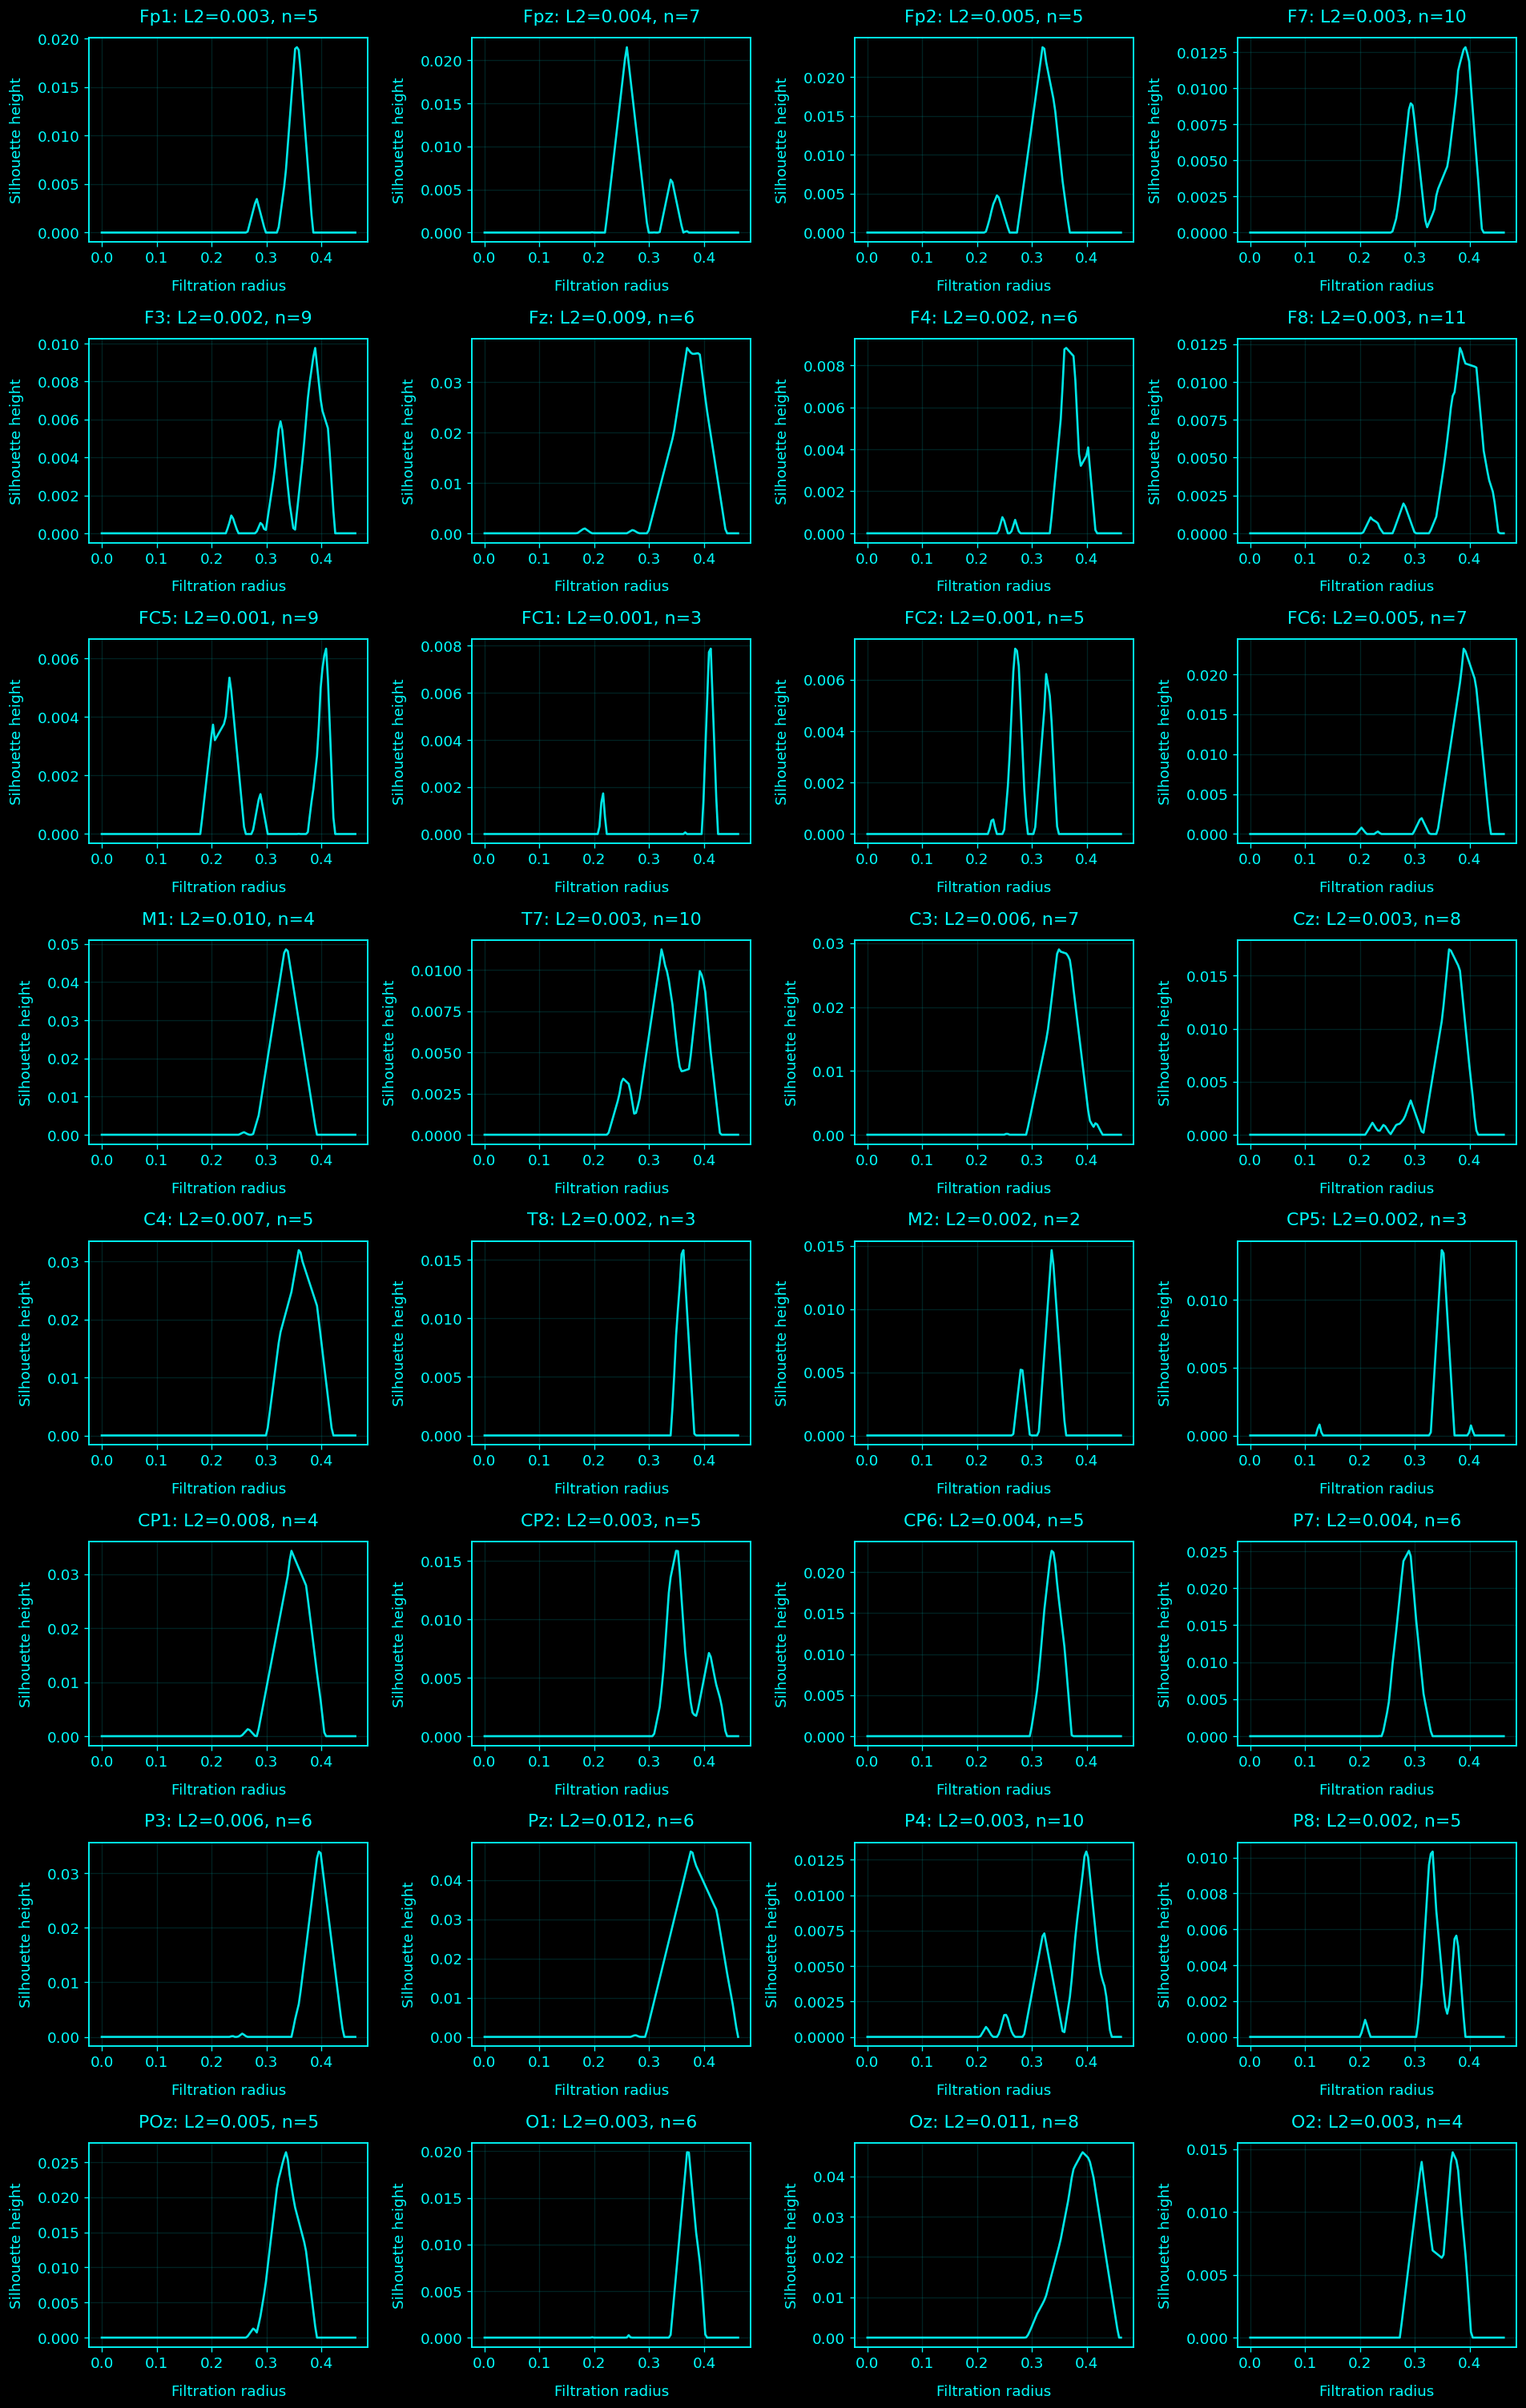

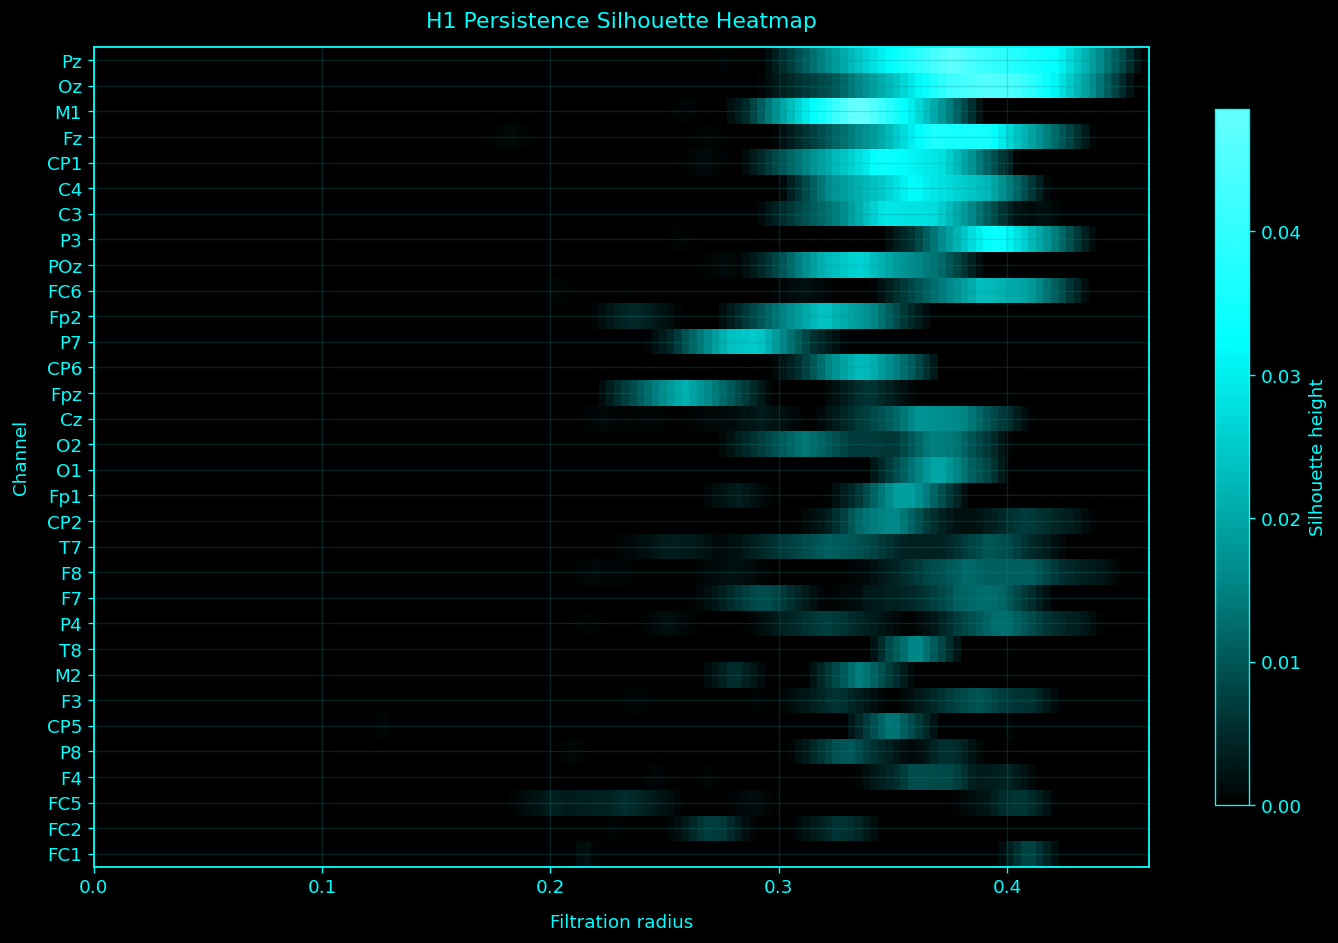

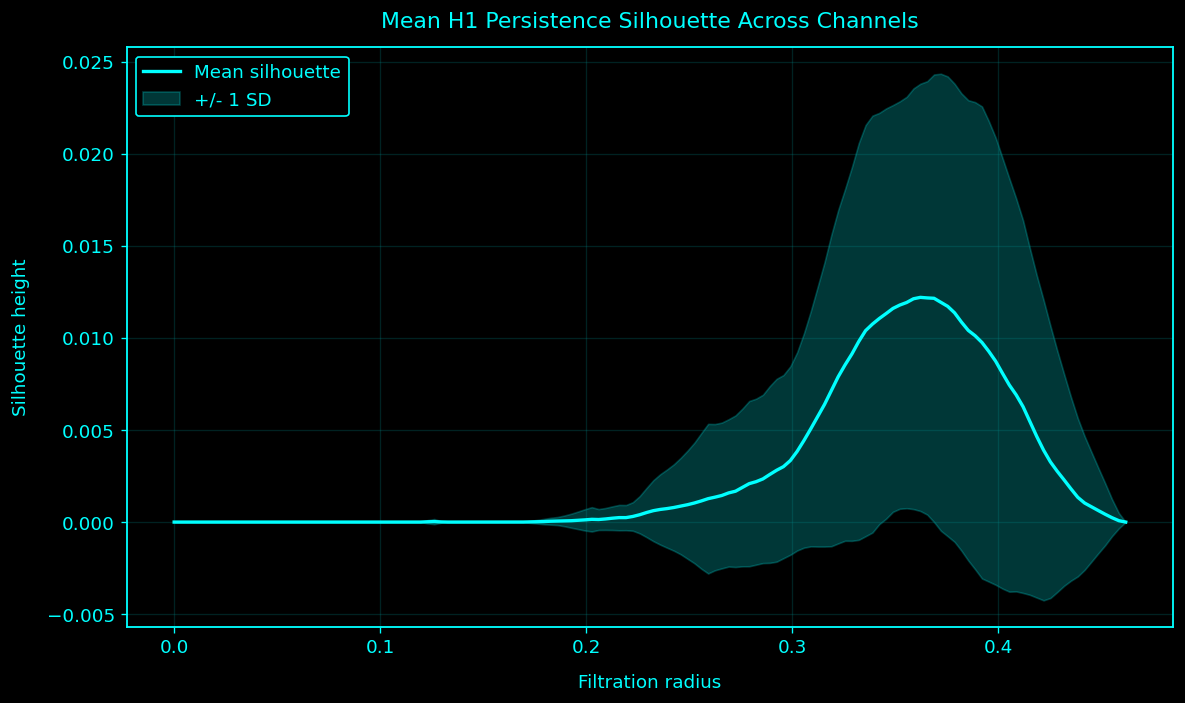

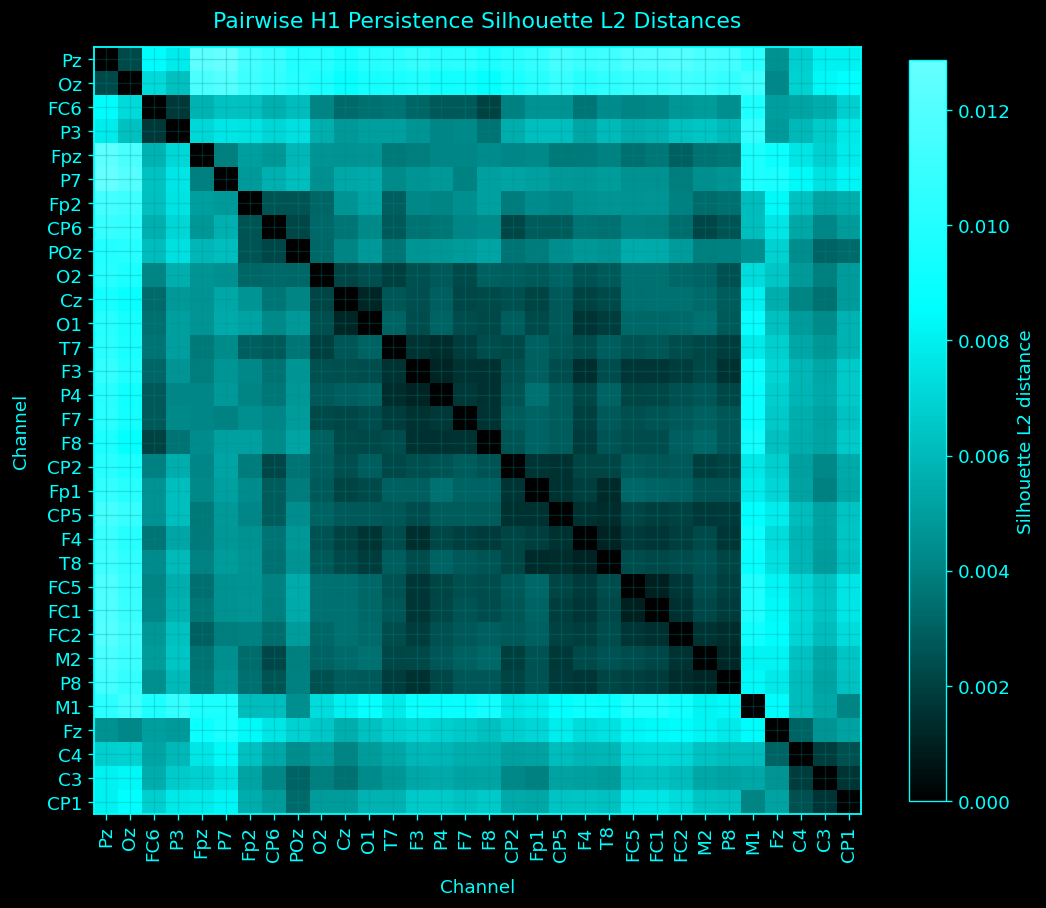

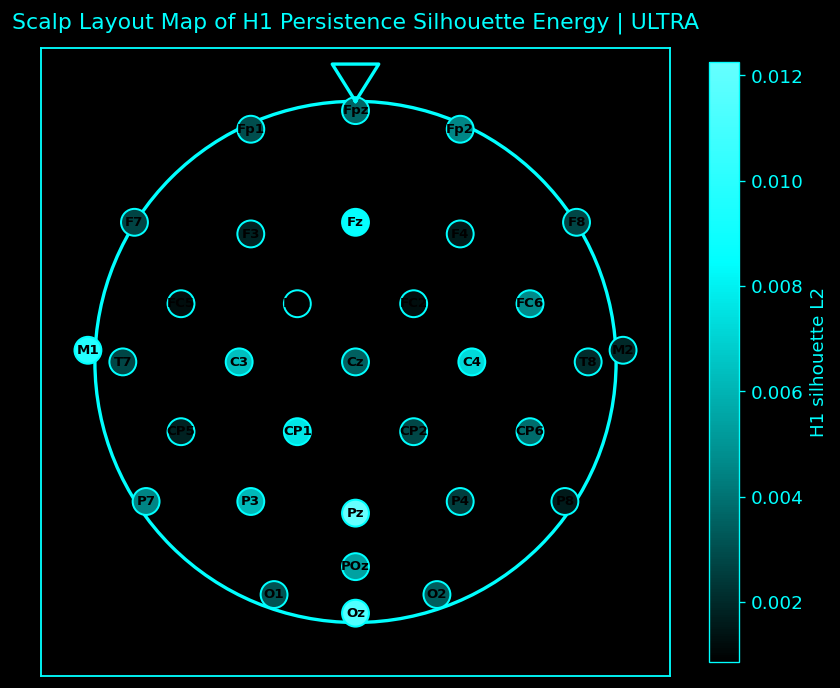

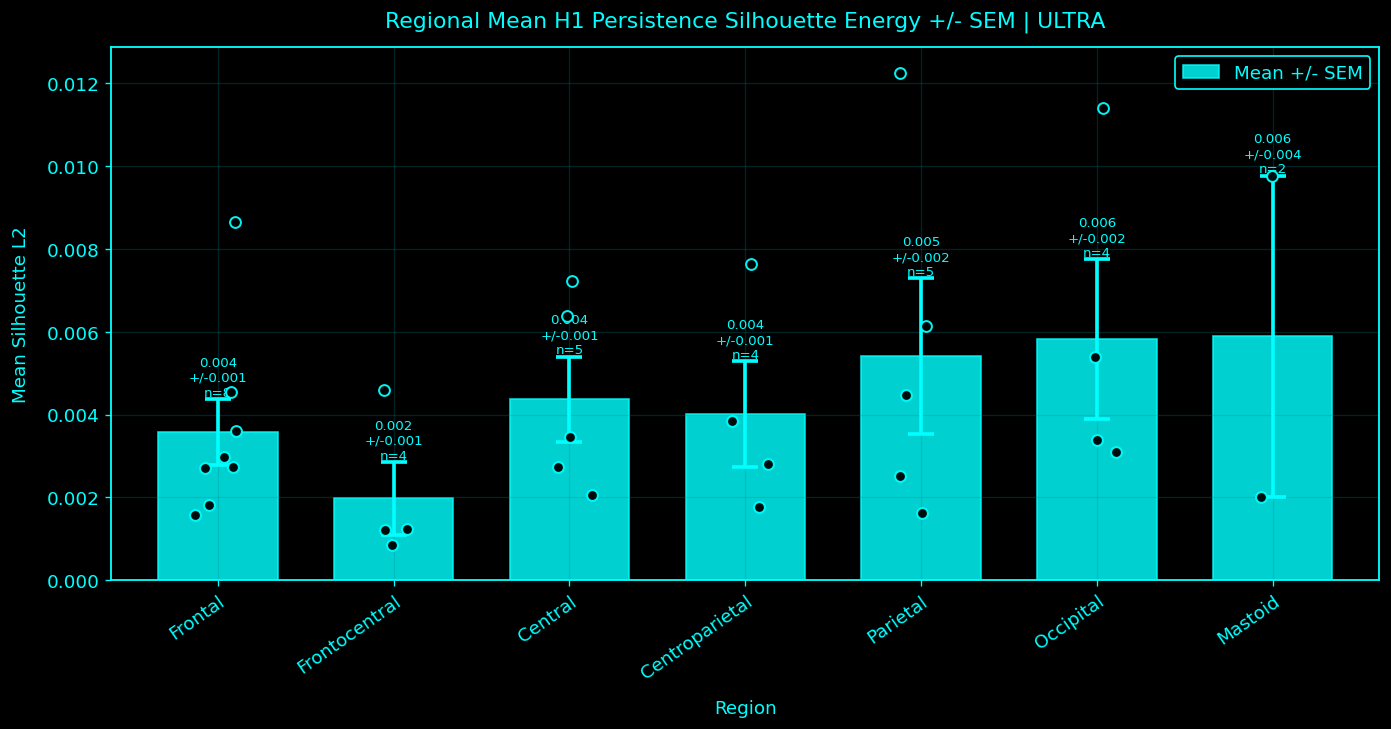

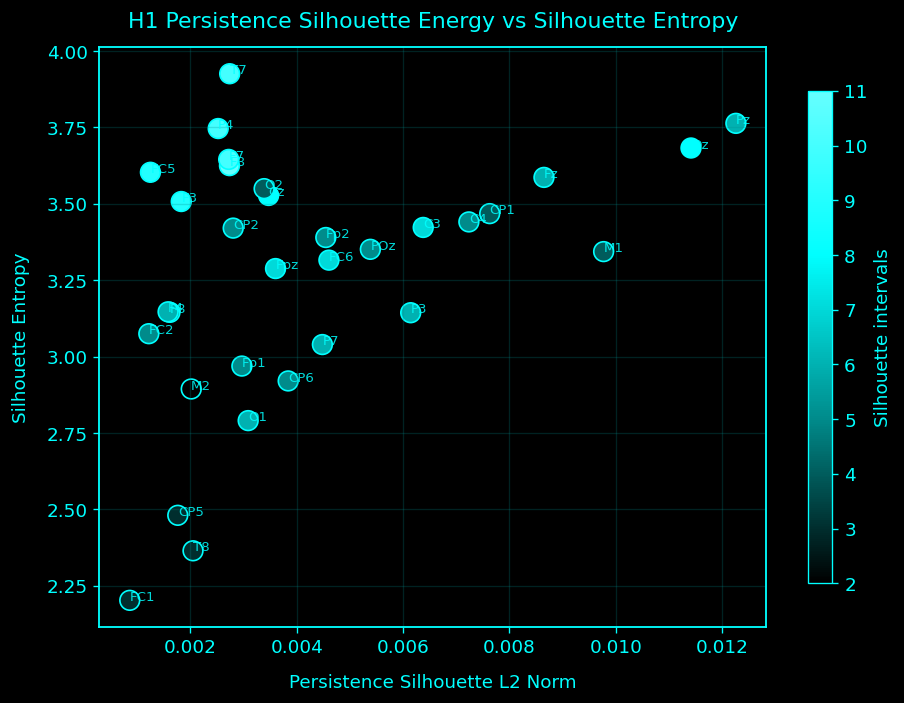

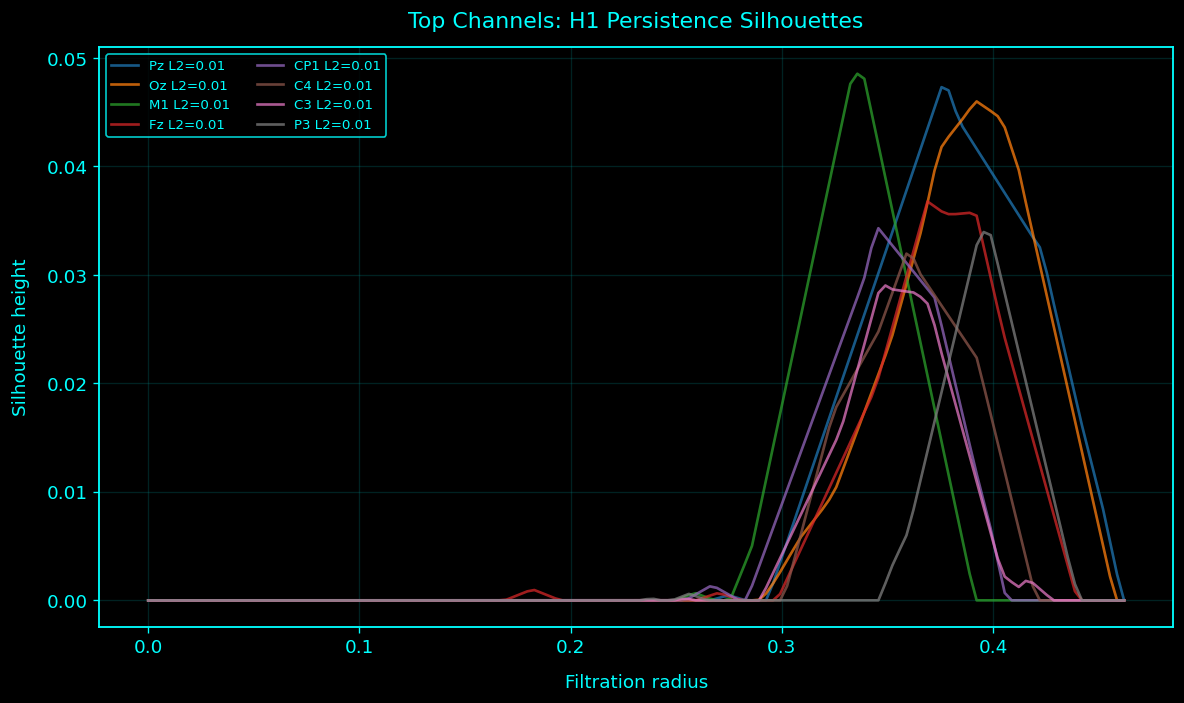

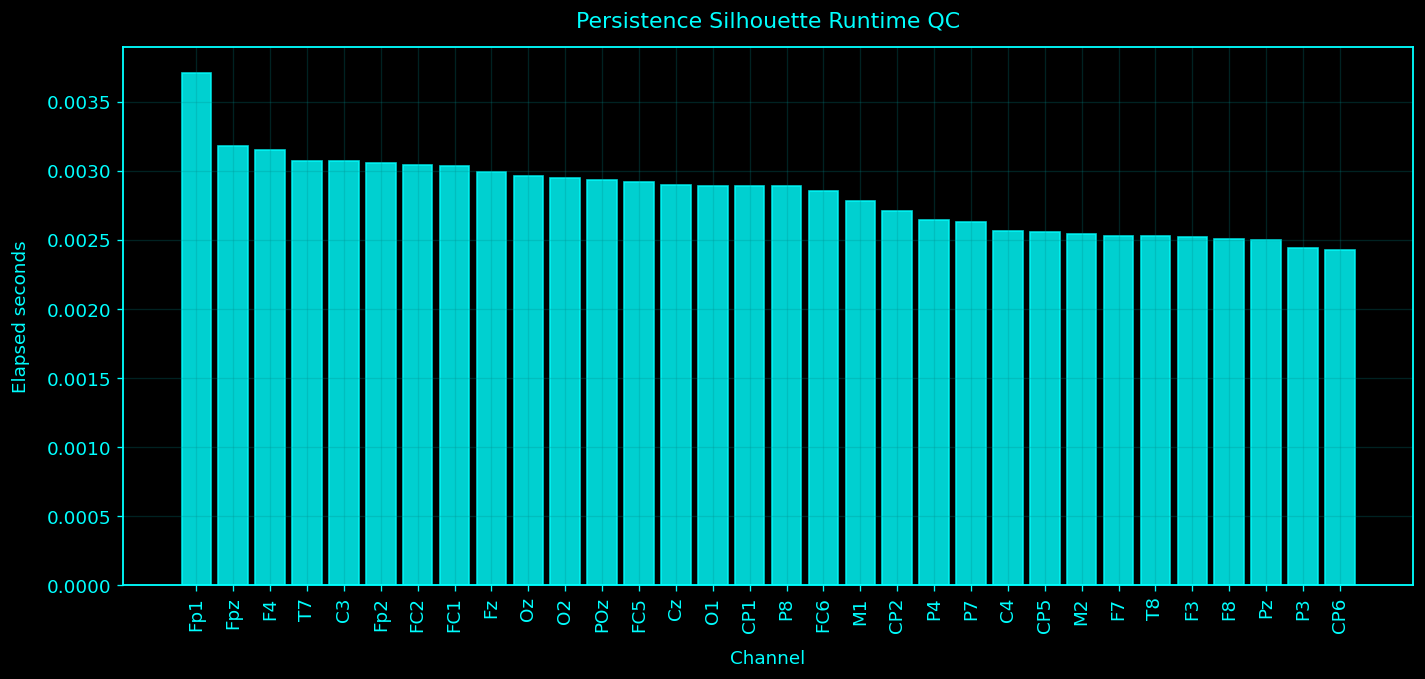

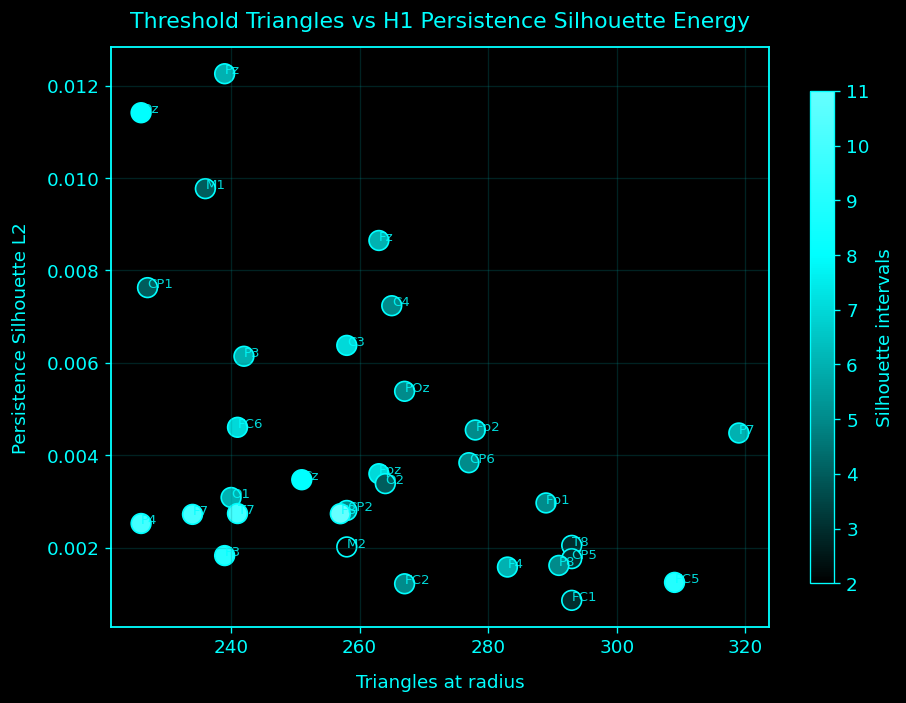


Expert plots saved and rendered from: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_silhouettes/h1_persistence_silhouettes_ultra_ripser_presampled/expert_plots
Regional summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_silhouettes/h1_persistence_silhouettes_ultra_ripser_presampled/expert_plots/regional_h1_persistence_silhouette_summary.csv

Finished H1 Persistence Silhouettes in 3.50s
Mode: ultra
Backend: ripser_presampled
Channels completed: 32
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_silhouettes/h1_persistence_silhouettes_ultra_ripser_presampled/persistence_silhouette_summary.csv
Persistence silhouette NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_silhouettes/h1_persistence_silhouettes_ultra_ripser_presampled/persistence_silhouettes_h1.npz
Pairwise distance CSV: /home/a/projects/Complete-Neural-Signal-Analysis/topology_persistence_silhouettes/h1_persistence

In [2]:
import os
import sys
import time
import numpy as np

# NumPy compatibility: newer NumPy versions may not expose np.trapz.
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["VECLIB_MAXIMUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

try:
    from IPython.display import display, Image
    HAVE_IPYTHON = True
except Exception:
    HAVE_IPYTHON = False

try:
    from ripser import ripser
except Exception as exc:
    raise ImportError(
        "ripser is not installed. Run this in a separate notebook cell first:\n\n"
        "!pip install ripser persim\n\n"
        "Then rerun this Persistence Silhouettes cell."
    ) from exc


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
out_dir = os.path.join(base_dir, "topology_persistence_silhouettes")
os.makedirs(out_dir, exist_ok=True)

FAST_OPTION = "ultra"  # options: "ultra", "fast", "balanced", "full"

MAX_CHANNELS_TO_PROCESS = None
RENDER_ALL_IMAGES_INLINE = True
SAVE_PLOTS_TO_DISK = True
MAKE_EXPERT_PLOTS = True
INLINE_IMAGE_WIDTH = 950
VERBOSE_PROGRESS = True

MODE_CONFIGS = {
    "ultra": {
        "max_points": 55,
        "max_dims": 3,
        "radius_quantile": 0.12,
        "silhouette_grid_size": 140,
        "silhouette_weight_power": 1.0,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 8,
        "plot_dpi": 120,
    },
    "fast": {
        "max_points": 90,
        "max_dims": 3,
        "radius_quantile": 0.15,
        "silhouette_grid_size": 220,
        "silhouette_weight_power": 1.0,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 8,
        "plot_dpi": 130,
    },
    "balanced": {
        "max_points": 130,
        "max_dims": 3,
        "radius_quantile": 0.18,
        "silhouette_grid_size": 320,
        "silhouette_weight_power": 1.0,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 10,
        "plot_dpi": 140,
    },
    "full": {
        "max_points": 180,
        "max_dims": 3,
        "radius_quantile": 0.22,
        "silhouette_grid_size": 450,
        "silhouette_weight_power": 1.0,
        "cap_essential_h1": True,
        "top_channels_to_overlay": 12,
        "plot_dpi": 150,
    },
}

if FAST_OPTION not in MODE_CONFIGS:
    raise ValueError("FAST_OPTION must be one of: ultra, fast, balanced, full")

cfg = MODE_CONFIGS[FAST_OPTION]

MAX_POINTS = cfg["max_points"]
MAX_DIMS = cfg["max_dims"]
RADIUS_QUANTILE = cfg["radius_quantile"]
SILHOUETTE_GRID_SIZE = cfg["silhouette_grid_size"]
SILHOUETTE_WEIGHT_POWER = cfg["silhouette_weight_power"]
CAP_ESSENTIAL_H1 = cfg["cap_essential_h1"]
TOP_CHANNELS_TO_OVERLAY = cfg["top_channels_to_overlay"]
PLOT_DPI = cfg["plot_dpi"]

mode_out_dir = os.path.join(out_dir, f"h1_persistence_silhouettes_{FAST_OPTION}_ripser_presampled")
os.makedirs(mode_out_dir, exist_ok=True)

eeg_channels = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

if MAX_CHANNELS_TO_PROCESS is not None:
    eeg_channels = eeg_channels[:MAX_CHANNELS_TO_PROCESS]

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})


def log(msg):
    if VERBOSE_PROGRESS:
        print(msg, flush=True)


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT, labelpad=10)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT, labelpad=10)

    if grid:
        ax.grid(True, color=ACCENT_DIM, alpha=0.25, linewidth=0.8)


def style_colorbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)


def save_render_close(fig, path, width=INLINE_IMAGE_WIDTH):
    if SAVE_PLOTS_TO_DISK:
        fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight", facecolor=BLACK)

    plt.close(fig)

    if RENDER_ALL_IMAGES_INLINE and HAVE_IPYTHON and os.path.exists(path):
        display(Image(filename=path, width=width))


def load_channel_embedding_sampled(ch_name, max_points=55, seed=7):
    candidate_paths = [
        os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d", f"umap_embedding_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d", f"tsne_embedding_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "3dembedding_data", f"3dembedded_{ch_name}.npy"),
        os.path.join(base_dir, "embedding_data", "2dembedding_data", f"2dembedded_{ch_name}.npy"),
    ]

    rng = np.random.default_rng(seed)

    for path in candidate_paths:
        if not os.path.exists(path):
            continue

        log(f"    trying: {path}")

        try:
            X = np.load(path, mmap_mode="r", allow_pickle=False)
        except Exception as exc:
            log(f"    skipped non-memmappable or nonnumeric file: {os.path.basename(path)} | {exc}")
            continue

        if X.ndim != 2:
            log(f"    skipped because ndim={X.ndim}")
            continue

        original_shape = tuple(X.shape)

        try:
            if X.shape[0] >= X.shape[1]:
                n_samples = X.shape[0]
                n_features = X.shape[1]

                if n_samples < 10 or n_features < 2:
                    log(f"    skipped bad shape: {original_shape}")
                    continue

                sample_n = min(max_points, n_samples)
                idx = np.sort(rng.choice(n_samples, size=sample_n, replace=False))
                X_small = np.asarray(X[idx, :], dtype=np.float64)

            else:
                n_samples = X.shape[1]
                n_features = X.shape[0]

                if n_samples < 10 or n_features < 2:
                    log(f"    skipped bad transposed shape: {original_shape}")
                    continue

                sample_n = min(max_points, n_samples)
                idx = np.sort(rng.choice(n_samples, size=sample_n, replace=False))
                X_small = np.asarray(X[:, idx].T, dtype=np.float64)

        except Exception as exc:
            log(f"    failed while sampling {os.path.basename(path)} | {exc}")
            continue

        X_small = X_small[np.all(np.isfinite(X_small), axis=1)]

        if X_small.shape[0] >= 10 and X_small.shape[1] >= 2:
            return X_small, path, original_shape

        log(f"    sampled data unusable: sampled_shape={X_small.shape}")

    return None, None, None


def standardize_point_cloud_small(X, max_dims=3):
    X = np.asarray(X, dtype=np.float64)
    X = X[np.all(np.isfinite(X), axis=1)]

    if X.shape[0] < 10:
        return None

    X = X - np.mean(X, axis=0, keepdims=True)

    if X.shape[1] > max_dims:
        _U, _S, Vt = np.linalg.svd(X, full_matrices=False)
        X = X @ Vt[:max_dims].T

    X = X / (np.std(X, axis=0, keepdims=True) + 1e-12)

    D = pdist(X)
    positive = D[D > 0]

    if len(positive) > 0:
        X = X / (np.nanmedian(positive) + 1e-12)

    return X


def estimate_complex_counts(X, radius):
    D = squareform(pdist(X))
    A = (D <= radius) & (D > 0)

    n_edges = int(np.sum(A) // 2)

    if A.shape[0] <= 300:
        A_int = A.astype(np.int64)
        n_triangles = int(np.trace(A_int @ A_int @ A_int) // 6)
    else:
        n_triangles = np.nan

    return n_edges, n_triangles


def run_h1_ripser(X, radius):
    result = ripser(
        X,
        maxdim=1,
        thresh=float(radius),
        coeff=2,
        do_cocycles=False,
    )

    diagrams = result["dgms"]

    h0 = diagrams[0] if len(diagrams) > 0 else np.empty((0, 2), dtype=float)
    h1 = diagrams[1] if len(diagrams) > 1 else np.empty((0, 2), dtype=float)

    return h0, h1


def split_finite_essential(diagram):
    diagram = np.asarray(diagram, dtype=float)

    if diagram.size == 0:
        return np.empty((0, 2), dtype=float), np.empty((0, 2), dtype=float)

    finite = diagram[
        np.isfinite(diagram[:, 0])
        & np.isfinite(diagram[:, 1])
        & (diagram[:, 1] > diagram[:, 0])
    ]

    essential = diagram[
        np.isfinite(diagram[:, 0])
        & np.isinf(diagram[:, 1])
    ]

    return finite, essential


def clean_intervals_for_silhouette(
    finite_intervals,
    essential_intervals=None,
    cap_essential=True,
    cap_value=None,
):
    finite = []
    capped_count = 0

    if finite_intervals is not None:
        for b, d in finite_intervals:
            if np.isfinite(b) and np.isfinite(d) and d > b:
                finite.append((float(b), float(d)))

    if cap_essential and essential_intervals is not None and cap_value is not None:
        for b, _d in essential_intervals:
            if np.isfinite(b) and np.isfinite(cap_value) and cap_value > b:
                finite.append((float(b), float(cap_value)))
                capped_count += 1

    if len(finite) == 0:
        return np.empty((0, 2), dtype=float), capped_count

    return np.asarray(finite, dtype=float), capped_count


def persistence_silhouette(intervals, grid, weight_power=1.0):
    intervals = np.asarray(intervals, dtype=float)
    silhouette = np.zeros(len(grid), dtype=float)

    if intervals.size == 0:
        return silhouette

    intervals = intervals[
        np.isfinite(intervals[:, 0])
        & np.isfinite(intervals[:, 1])
        & (intervals[:, 1] > intervals[:, 0])
    ]

    if len(intervals) == 0:
        return silhouette

    births = intervals[:, 0]
    deaths = intervals[:, 1]
    lifetimes = deaths - births

    weights = lifetimes ** weight_power
    weight_sum = float(np.sum(weights))

    if not np.isfinite(weight_sum) or weight_sum <= 0:
        weights = np.ones_like(lifetimes)
        weight_sum = float(np.sum(weights))

    t = grid[None, :]
    b = births[:, None]
    d = deaths[:, None]

    tents = np.maximum(0.0, np.minimum(t - b, d - t))
    weighted_tents = weights[:, None] * tents

    silhouette = np.sum(weighted_tents, axis=0) / weight_sum

    return silhouette


def silhouette_features(silhouette, grid, intervals):
    silhouette = np.asarray(silhouette, dtype=float)
    intervals = np.asarray(intervals, dtype=float)

    l1 = float(np.trapz(np.abs(silhouette), grid))
    l2 = float(np.sqrt(np.trapz(silhouette ** 2, grid)))
    energy = float(np.trapz(silhouette ** 2, grid))
    linf = float(np.nanmax(silhouette)) if silhouette.size else 0.0

    area = float(np.trapz(silhouette, grid))

    if area > 0:
        center = float(np.trapz(grid * silhouette, grid) / area)
        density = silhouette / (np.sum(silhouette) + 1e-12)
        entropy = float(-np.sum(density[density > 0] * np.log(density[density > 0])))
    else:
        center = np.nan
        entropy = 0.0

    if silhouette.size and np.any(np.isfinite(silhouette)):
        peak_idx = int(np.nanargmax(silhouette))
        peak_radius = float(grid[peak_idx])
    else:
        peak_radius = np.nan

    if intervals is not None and len(intervals) > 0:
        lifetimes = intervals[:, 1] - intervals[:, 0]
        n_intervals = int(len(intervals))
        mean_lifetime = float(np.nanmean(lifetimes))
        max_lifetime = float(np.nanmax(lifetimes))
        total_lifetime = float(np.nansum(lifetimes))
    else:
        n_intervals = 0
        mean_lifetime = np.nan
        max_lifetime = np.nan
        total_lifetime = 0.0

    return {
        "silhouette_l1": l1,
        "silhouette_l2": l2,
        "silhouette_energy": energy,
        "silhouette_linf": linf,
        "silhouette_entropy": entropy,
        "silhouette_center_of_mass": center,
        "silhouette_peak_radius": peak_radius,
        "n_intervals_silhouette": n_intervals,
        "mean_lifetime": mean_lifetime,
        "max_lifetime": max_lifetime,
        "total_lifetime": total_lifetime,
    }


def silhouette_l2_distance(s_a, s_b, grid):
    diff = np.asarray(s_a, dtype=float) - np.asarray(s_b, dtype=float)
    return float(np.sqrt(np.trapz(diff ** 2, grid)))


log("\n" + "=" * 72)
log(f"Running H1 Persistence Silhouettes with ripser backend | {FAST_OPTION.upper()}")
log(f"Channels: {len(eeg_channels)}")
log(f"max_points={MAX_POINTS}, radius_quantile={RADIUS_QUANTILE}")
log(f"silhouette_grid_size={SILHOUETTE_GRID_SIZE}, weight_power={SILHOUETTE_WEIGHT_POWER}")
log(f"expert_plots={MAKE_EXPERT_PLOTS}, render_all_images={RENDER_ALL_IMAGES_INLINE}")
log(f"Output: {mode_out_dir}")
log("=" * 72)

diagnostics = {}
interval_store = {}
loaded_channels = []

global_t_min = 0.0
global_t_max = None

overall_t0 = time.time()

for ch_idx, ch_name in enumerate(eeg_channels, start=1):
    t0 = time.time()
    prefix = f"[{ch_idx:02d}/{len(eeg_channels)} {ch_name}]"

    log(f"\n{prefix} loading + pre-subsampling to {MAX_POINTS} points")

    X_small, source_path, original_shape = load_channel_embedding_sampled(
        ch_name,
        max_points=MAX_POINTS,
        seed=300 + ch_idx,
    )

    if X_small is None:
        log(f"{prefix} WARNING: no usable embedding found; skipping")
        continue

    log(f"{prefix} source shape={original_shape}, sampled shape={X_small.shape}")

    X = standardize_point_cloud_small(X_small, max_dims=MAX_DIMS)

    if X is None:
        log(f"{prefix} WARNING: invalid sampled embedding; skipping")
        continue

    log(f"{prefix} standardized shape={X.shape}; computing radius")

    D_flat = pdist(X)
    positive = D_flat[D_flat > 0]

    if len(positive) == 0:
        log(f"{prefix} WARNING: zero-distance cloud; skipping")
        continue

    radius = float(np.quantile(positive, RADIUS_QUANTILE))

    log(f"{prefix} estimating threshold complex size")
    n_edges, n_triangles = estimate_complex_counts(X, radius)

    log(f"{prefix} ripser H0/H1")
    h0_diag, h1_diag = run_h1_ripser(X, radius)

    h0_finite, h0_essential = split_finite_essential(h0_diag)
    h1_finite, h1_essential = split_finite_essential(h1_diag)

    h1_intervals, n_capped_h1 = clean_intervals_for_silhouette(
        h1_finite,
        essential_intervals=h1_essential,
        cap_essential=CAP_ESSENTIAL_H1,
        cap_value=radius,
    )

    interval_store[ch_name] = {
        "H0_finite": h0_finite,
        "H0_essential": h0_essential,
        "H1_finite": h1_finite,
        "H1_essential": h1_essential,
        "H1_silhouette_intervals": h1_intervals,
    }

    if len(h1_intervals) > 0:
        max_death = float(np.nanmax(h1_intervals[:, 1]))
        global_t_max = max_death if global_t_max is None else max(global_t_max, max_death)

    elapsed = time.time() - t0

    diagnostics[ch_name] = {
        "channel": ch_name,
        "source_path": source_path,
        "source_shape": str(original_shape),
        "backend": "ripser_presampled",
        "n_points": int(X.shape[0]),
        "n_edges_at_radius": int(n_edges),
        "n_triangles_at_radius": int(n_triangles) if np.isfinite(n_triangles) else np.nan,
        "radius": radius,
        "n_h0_finite": int(len(h0_finite)),
        "n_h1_finite": int(len(h1_finite)),
        "n_h1_essential": int(len(h1_essential)),
        "n_h1_capped_for_silhouette": int(n_capped_h1),
        "n_h1_silhouette_intervals": int(len(h1_intervals)),
        "elapsed_sec": elapsed,
    }

    loaded_channels.append(ch_name)

    log(
        f"{prefix} done {elapsed:.2f}s | "
        f"edges={n_edges}, triangles={n_triangles}, "
        f"H1 finite={len(h1_finite)}, H1 silhouette intervals={len(h1_intervals)}"
    )

if len(loaded_channels) == 0:
    raise RuntimeError("No usable embeddings found. Check embedding_data paths.")

if global_t_max is None or not np.isfinite(global_t_max) or global_t_max <= 0:
    global_t_max = 1.0

silhouette_grid = np.linspace(global_t_min, global_t_max, SILHOUETTE_GRID_SIZE)

log("\nBuilding persistence silhouettes")
log(f"silhouette grid: {silhouette_grid[0]:.6f} to {silhouette_grid[-1]:.6f}")

silhouette_store = {}
rows = []

for ch_name in loaded_channels:
    h1_intervals = interval_store[ch_name]["H1_silhouette_intervals"]

    silhouette = persistence_silhouette(
        h1_intervals,
        silhouette_grid,
        weight_power=SILHOUETTE_WEIGHT_POWER,
    )

    silhouette_store[ch_name] = silhouette

    rows.append({
        **diagnostics[ch_name],
        **silhouette_features(silhouette, silhouette_grid, h1_intervals),
    })

results_df = (
    pd.DataFrame(rows)
    .sort_values("silhouette_l2", ascending=False)
    .reset_index(drop=True)
)

summary_csv_path = os.path.join(mode_out_dir, "persistence_silhouette_summary.csv")
results_df.to_csv(summary_csv_path, index=False)

npz_path = os.path.join(mode_out_dir, "persistence_silhouettes_h1.npz")

save_dict = {
    "channels": np.asarray(loaded_channels),
    "silhouette_grid": silhouette_grid,
    "fast_option": np.asarray([FAST_OPTION]),
    "backend": np.asarray(["ripser_presampled"]),
    "silhouette_weight_power": np.asarray([SILHOUETTE_WEIGHT_POWER]),
}

for ch_name in loaded_channels:
    save_dict[f"{ch_name}_silhouette"] = silhouette_store[ch_name]

    for key, val in interval_store[ch_name].items():
        save_dict[f"{ch_name}_{key}"] = val

np.savez(npz_path, **save_dict)

print("\nPersistence Silhouette Summary:")
if HAVE_IPYTHON:
    display(results_df)
else:
    print(results_df)

log(f"\nSaved summary CSV: {summary_csv_path}")
log(f"Saved persistence silhouette NPZ: {npz_path}")

plot_df = results_df.copy().sort_values("silhouette_l2", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BLACK)
style_ax(
    ax,
    title=f"H1 Persistence Silhouette Energy by Channel | {FAST_OPTION.upper()}",
    xlabel="Channel",
    ylabel="Persistence Silhouette L2 Norm",
)

x_pos = np.arange(len(plot_df))
y = plot_df["silhouette_l2"].to_numpy(dtype=float)

ax.bar(x_pos, y, color=ACCENT, edgecolor=ACCENT, alpha=0.78)

if np.any(np.isfinite(y)):
    ax.axhline(
        np.nanmean(y),
        color=ACCENT_SOFT,
        linestyle="--",
        linewidth=1.4,
        alpha=0.8,
        label=f"Mean={np.nanmean(y):.5f}",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["channel"], rotation=90)
ax.legend(loc="best", framealpha=1.0)

ranking_path = os.path.join(mode_out_dir, "01_h1_persistence_silhouette_l2_ranking.png")
plt.tight_layout()
save_render_close(fig, ranking_path)

n_cols = 4
n_rows = int(np.ceil(len(loaded_channels) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 3.15 * n_rows),
    facecolor=BLACK,
)

axes = np.asarray(axes).reshape(-1)

for ax_idx, ch_name in enumerate(loaded_channels):
    ax = axes[ax_idx]
    s = silhouette_store[ch_name]

    l2_val = results_df.loc[results_df["channel"] == ch_name, "silhouette_l2"].values[0]
    n_intervals = results_df.loc[results_df["channel"] == ch_name, "n_intervals_silhouette"].values[0]

    style_ax(
        ax,
        title=f"{ch_name}: L2={l2_val:.3f}, n={int(n_intervals)}",
        xlabel="Filtration radius",
        ylabel="Silhouette height",
    )

    ax.plot(
        silhouette_grid,
        s,
        color=ACCENT,
        linewidth=1.6,
        alpha=0.9,
    )

for j in range(len(loaded_channels), len(axes)):
    axes[j].axis("off")

all_silhouettes_path = os.path.join(mode_out_dir, "02_all_channels_h1_persistence_silhouettes.png")
plt.tight_layout()
save_render_close(fig, all_silhouettes_path, width=1100)

heat_channels = plot_df["channel"].tolist()

silhouette_matrix = np.asarray([
    silhouette_store[ch_name]
    for ch_name in heat_channels
], dtype=float)

fig, ax = plt.subplots(figsize=(12, 8), facecolor=BLACK)
style_ax(
    ax,
    title="H1 Persistence Silhouette Heatmap",
    xlabel="Filtration radius",
    ylabel="Channel",
)

im = ax.imshow(
    silhouette_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
    extent=[
        silhouette_grid[0],
        silhouette_grid[-1],
        len(heat_channels) - 0.5,
        -0.5,
    ],
)

ax.set_yticks(np.arange(len(heat_channels)))
ax.set_yticklabels(heat_channels)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Silhouette height")

heatmap_path = os.path.join(mode_out_dir, "03_h1_persistence_silhouette_heatmap.png")
plt.tight_layout()
save_render_close(fig, heatmap_path)

mean_silhouette = np.mean(
    np.asarray([silhouette_store[ch] for ch in loaded_channels], dtype=float),
    axis=0,
)

std_silhouette = np.std(
    np.asarray([silhouette_store[ch] for ch in loaded_channels], dtype=float),
    axis=0,
)

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BLACK)
style_ax(
    ax,
    title="Mean H1 Persistence Silhouette Across Channels",
    xlabel="Filtration radius",
    ylabel="Silhouette height",
)

ax.plot(
    silhouette_grid,
    mean_silhouette,
    color=ACCENT,
    linewidth=2.0,
    label="Mean silhouette",
)

ax.fill_between(
    silhouette_grid,
    mean_silhouette - std_silhouette,
    mean_silhouette + std_silhouette,
    color=ACCENT,
    alpha=0.22,
    label="+/- 1 SD",
)

ax.legend(loc="best", framealpha=1.0)

mean_silhouette_path = os.path.join(mode_out_dir, "04_mean_h1_persistence_silhouette.png")
plt.tight_layout()
save_render_close(fig, mean_silhouette_path)

channels_for_dist = loaded_channels
n_ch = len(channels_for_dist)

dist_mat = np.zeros((n_ch, n_ch), dtype=float)

for i in range(n_ch):
    for j in range(i + 1, n_ch):
        dist = silhouette_l2_distance(
            silhouette_store[channels_for_dist[i]],
            silhouette_store[channels_for_dist[j]],
            silhouette_grid,
        )
        dist_mat[i, j] = dist
        dist_mat[j, i] = dist

dist_csv_path = os.path.join(mode_out_dir, "h1_persistence_silhouette_pairwise_l2_distance.csv")
pd.DataFrame(dist_mat, index=channels_for_dist, columns=channels_for_dist).to_csv(dist_csv_path)

if n_ch >= 3 and np.any(dist_mat > 0):
    condensed = dist_mat[np.triu_indices(n_ch, k=1)]
    Z = linkage(condensed, method="average")
    order = leaves_list(Z)
else:
    order = np.arange(n_ch)

ordered_dist = dist_mat[np.ix_(order, order)]
ordered_channels = [channels_for_dist[i] for i in order]

fig, ax = plt.subplots(figsize=(9, 8), facecolor=BLACK)
style_ax(
    ax,
    title="Pairwise H1 Persistence Silhouette L2 Distances",
    xlabel="Channel",
    ylabel="Channel",
)

im = ax.imshow(
    ordered_dist,
    aspect="equal",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
)

ax.set_xticks(np.arange(n_ch))
ax.set_xticklabels(ordered_channels, rotation=90)
ax.set_yticks(np.arange(n_ch))
ax.set_yticklabels(ordered_channels)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
style_colorbar(cbar, "Silhouette L2 distance")

dist_path = os.path.join(mode_out_dir, "05_h1_persistence_silhouette_pairwise_distance_heatmap.png")
plt.tight_layout()
save_render_close(fig, dist_path)

if MAKE_EXPERT_PLOTS:
    expert_dir = os.path.join(mode_out_dir, "expert_plots")
    os.makedirs(expert_dir, exist_ok=True)

    silhouette_l2_map = dict(zip(results_df["channel"], results_df["silhouette_l2"]))

    scalp_xy = {
        "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.08), "Fp2": (0.45, 1.00),
        "F7": (-0.95, 0.60), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60),
        "F4": (0.45, 0.55), "F8": (0.95, 0.60),
        "FC5": (-0.75, 0.25), "FC1": (-0.25, 0.25),
        "FC2": (0.25, 0.25), "FC6": (0.75, 0.25),
        "M1": (-1.15, 0.05), "T7": (-1.00, 0.00), "C3": (-0.50, 0.00),
        "Cz": (0.00, 0.00), "C4": (0.50, 0.00), "T8": (1.00, 0.00),
        "M2": (1.15, 0.05),
        "CP5": (-0.75, -0.30), "CP1": (-0.25, -0.30),
        "CP2": (0.25, -0.30), "CP6": (0.75, -0.30),
        "P7": (-0.90, -0.60), "P3": (-0.45, -0.60), "Pz": (0.00, -0.65),
        "P4": (0.45, -0.60), "P8": (0.90, -0.60),
        "POz": (0.00, -0.88),
        "O1": (-0.35, -1.00), "Oz": (0.00, -1.08), "O2": (0.35, -1.00),
    }

    xs, ys, vals, labels = [], [], [], []

    for ch in eeg_channels:
        if ch in scalp_xy and ch in silhouette_l2_map and np.isfinite(silhouette_l2_map[ch]):
            xs.append(scalp_xy[ch][0])
            ys.append(scalp_xy[ch][1])
            vals.append(silhouette_l2_map[ch])
            labels.append(ch)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BLACK)
    style_ax(
        ax,
        title=f"Scalp Layout Map of H1 Persistence Silhouette Energy | {FAST_OPTION.upper()}",
        grid=False,
    )

    head = plt.Circle((0, 0), 1.12, fill=False, color=ACCENT, linewidth=2)
    ax.add_patch(head)
    ax.plot([0.00, -0.10, 0.10, 0.00], [1.12, 1.28, 1.28, 1.12], color=ACCENT, linewidth=2)

    sc = ax.scatter(
        xs,
        ys,
        c=vals,
        s=260,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolor=ACCENT,
        linewidth=1.2,
    )

    for x0, y0, label in zip(xs, ys, labels):
        ax.text(
            x0,
            y0,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color=BLACK,
            fontweight="bold",
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    style_colorbar(cbar, "H1 silhouette L2")

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    scalp_path = os.path.join(expert_dir, "06_h1_persistence_silhouette_scalp_map.png")
    plt.tight_layout()
    save_render_close(fig, scalp_path, width=760)

    regions = {
        "Frontal": ["Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
        "Frontocentral": ["FC5", "FC1", "FC2", "FC6"],
        "Central": ["T7", "C3", "Cz", "C4", "T8"],
        "Centroparietal": ["CP5", "CP1", "CP2", "CP6"],
        "Parietal": ["P7", "P3", "Pz", "P4", "P8"],
        "Occipital": ["POz", "O1", "Oz", "O2"],
        "Mastoid": ["M1", "M2"],
    }

    region_rows = []
    region_points = []

    for region_name, chans in regions.items():
        vals_region = []

        for ch in chans:
            if ch in silhouette_l2_map and np.isfinite(silhouette_l2_map[ch]):
                vals_region.append(silhouette_l2_map[ch])
                region_points.append({
                    "region": region_name,
                    "channel": ch,
                    "silhouette_l2": silhouette_l2_map[ch],
                })

        if len(vals_region) == 0:
            continue

        vals_region = np.asarray(vals_region, dtype=float)

        region_rows.append({
            "region": region_name,
            "mean_silhouette_l2": float(np.mean(vals_region)),
            "std_silhouette_l2": float(np.std(vals_region, ddof=1)) if len(vals_region) > 1 else 0.0,
            "sem_silhouette_l2": (
                float(np.std(vals_region, ddof=1) / np.sqrt(len(vals_region)))
                if len(vals_region) > 1 else 0.0
            ),
            "n_channels": int(len(vals_region)),
        })

    region_df = pd.DataFrame(region_rows)
    region_points_df = pd.DataFrame(region_points)

    region_csv_path = os.path.join(expert_dir, "regional_h1_persistence_silhouette_summary.csv")
    region_df.to_csv(region_csv_path, index=False)

    if len(region_df) > 0:
        fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BLACK)
        style_ax(
            ax,
            title=f"Regional Mean H1 Persistence Silhouette Energy +/- SEM | {FAST_OPTION.upper()}",
            xlabel="Region",
            ylabel="Mean Silhouette L2",
        )

        x_region = np.arange(len(region_df))

        ax.bar(
            x_region,
            region_df["mean_silhouette_l2"],
            yerr=region_df["sem_silhouette_l2"],
            color=ACCENT,
            edgecolor=ACCENT,
            alpha=0.82,
            width=0.68,
            capsize=8,
            error_kw={
                "elinewidth": 2.2,
                "capthick": 2.2,
                "ecolor": ACCENT,
                "alpha": 1.0,
            },
            label="Mean +/- SEM",
        )

        rng = np.random.default_rng(7)

        for i, region_name in enumerate(region_df["region"]):
            vals = region_points_df.loc[
                region_points_df["region"] == region_name,
                "silhouette_l2",
            ].to_numpy(dtype=float)

            if len(vals) == 0:
                continue

            jitter = rng.uniform(-0.13, 0.13, size=len(vals))

            ax.scatter(
                np.full(len(vals), i) + jitter,
                vals,
                s=42,
                facecolors=BLACK,
                edgecolors=ACCENT,
                linewidths=1.2,
                alpha=0.95,
                zorder=4,
            )

        for i, row in region_df.iterrows():
            y_val = row["mean_silhouette_l2"]
            sem = row["sem_silhouette_l2"]

            ax.text(
                i,
                y_val + sem,
                f"{y_val:.3f}\n+/-{sem:.3f}\nn={int(row['n_channels'])}",
                ha="center",
                va="bottom",
                fontsize=8,
                color=ACCENT,
            )

        ax.set_xticks(x_region)
        ax.set_xticklabels(
            region_df["region"],
            rotation=35,
            ha="right",
            rotation_mode="anchor",
        )
        ax.margins(x=0.04)
        ax.legend(loc="best", framealpha=1.0)

        region_path = os.path.join(expert_dir, "07_regional_h1_persistence_silhouette_summary.png")
        plt.tight_layout(pad=2.0)
        save_render_close(fig, region_path)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BLACK)
    style_ax(
        ax,
        title="H1 Persistence Silhouette Energy vs Silhouette Entropy",
        xlabel="Persistence Silhouette L2 Norm",
        ylabel="Silhouette Entropy",
    )

    sc = ax.scatter(
        results_df["silhouette_l2"],
        results_df["silhouette_entropy"],
        c=results_df["n_intervals_silhouette"],
        s=140,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolor=ACCENT,
        linewidth=1.0,
    )

    for _, row in results_df.iterrows():
        if np.isfinite(row["silhouette_l2"]) and np.isfinite(row["silhouette_entropy"]):
            ax.text(
                row["silhouette_l2"],
                row["silhouette_entropy"],
                row["channel"],
                fontsize=8,
                color=ACCENT,
                alpha=0.85,
            )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    style_colorbar(cbar, "Silhouette intervals")

    entropy_path = os.path.join(expert_dir, "08_silhouette_energy_vs_entropy.png")
    plt.tight_layout()
    save_render_close(fig, entropy_path)

    top_channels = results_df.head(min(TOP_CHANNELS_TO_OVERLAY, len(results_df)))["channel"].tolist()

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=BLACK)
    style_ax(
        ax,
        title="Top Channels: H1 Persistence Silhouettes",
        xlabel="Filtration radius",
        ylabel="Silhouette height",
    )

    for ch_name in top_channels:
        s = silhouette_store[ch_name]
        l2_val = silhouette_l2_map[ch_name]

        ax.plot(
            silhouette_grid,
            s,
            linewidth=1.6,
            alpha=0.75,
            label=f"{ch_name} L2={l2_val:.2f}",
        )

    ax.legend(fontsize=8, ncol=2)

    top_path = os.path.join(expert_dir, "09_top_channels_h1_persistence_silhouettes.png")
    plt.tight_layout()
    save_render_close(fig, top_path)

    qc_df = results_df.copy().sort_values("elapsed_sec", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 5.8), facecolor=BLACK)
    style_ax(
        ax,
        title="Persistence Silhouette Runtime QC",
        xlabel="Channel",
        ylabel="Elapsed seconds",
    )

    x_qc = np.arange(len(qc_df))

    ax.bar(
        x_qc,
        qc_df["elapsed_sec"],
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.82,
    )

    ax.set_xticks(x_qc)
    ax.set_xticklabels(qc_df["channel"], rotation=90)

    qc_path = os.path.join(expert_dir, "10_runtime_qc.png")
    plt.tight_layout()
    save_render_close(fig, qc_path)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BLACK)
    style_ax(
        ax,
        title="Threshold Triangles vs H1 Persistence Silhouette Energy",
        xlabel="Triangles at radius",
        ylabel="Persistence Silhouette L2",
    )

    sc = ax.scatter(
        results_df["n_triangles_at_radius"],
        results_df["silhouette_l2"],
        c=results_df["n_intervals_silhouette"],
        s=140,
        cmap=CYAN_SEQUENTIAL_CMAP,
        edgecolor=ACCENT,
        linewidth=1.0,
    )

    for _, row in results_df.iterrows():
        ax.text(
            row["n_triangles_at_radius"],
            row["silhouette_l2"],
            row["channel"],
            fontsize=8,
            color=ACCENT,
            alpha=0.85,
        )

    cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
    style_colorbar(cbar, "Silhouette intervals")

    size_qc_path = os.path.join(expert_dir, "11_threshold_triangles_vs_persistence_silhouette_energy.png")
    plt.tight_layout()
    save_render_close(fig, size_qc_path)

    log(f"\nExpert plots saved and rendered from: {expert_dir}")
    log(f"Regional summary CSV: {region_csv_path}")

elapsed_total = time.time() - overall_t0

log("\n" + "=" * 72)
log(f"Finished H1 Persistence Silhouettes in {elapsed_total:.2f}s")
log(f"Mode: {FAST_OPTION}")
log(f"Backend: ripser_presampled")
log(f"Channels completed: {len(loaded_channels)}")
log(f"Summary CSV: {summary_csv_path}")
log(f"Persistence silhouette NPZ: {npz_path}")
log(f"Pairwise distance CSV: {dist_csv_path}")
log(f"Output directory: {mode_out_dir}")
log("=" * 72)